# Advanced Rain Forecasting Models — Standalone (v2)

**Purpose.** Train and benchmark **Transformer**, **POD-SINDy**, and **Mamba**
forecast models against naive baselines and the operational **pySTEPS**
benchmark on the OpenMRG dataset (Gothenburg, Summer 2015).

**Date.** May 2026.

**Authors.** FieldSense lab, Tel Aviv University.

**Self-contained.** This notebook depends on **no other notebook**. It downloads
OpenMRG, generates radar maps, builds IDW and GMZ Commercial Microwave Link maps,
trains the estimation network, then trains every forecast model in 4 variants
(IDW/GMZ × single/multi step). Every download, extraction, training, and map
generation is cached on Drive — re-runs just `np.load` the existing outputs.

## Glossary

| Term | Definition |
|------|-----------|
| **CML** | Commercial Microwave Link — backhaul radio link between cellular towers. The rain-induced signal attenuation `A` (dB) lets us infer path-averaged rain rate `R` (mm/h). |
| **Rain Attenuation** | Reduction in signal power as a wave traverses a rainy path. Increases with rain rate, frequency, and path length. |
| **ITU-R Power-Law** | $A = a \cdot R^{b} \cdot L$ where $A$ is specific attenuation (dB), $R$ rain rate (mm/h), $L$ link length (km), and $(a, b)$ are frequency- and polarization-dependent coefficients from ITU-R P.838. |
| **IDW** | Inverse Distance Weighting: at every grid point, the estimated rain rate is a weighted average of nearby measurements with weights $w_i = 1/d_i^p$. Smooth but blurs peaks. |
| **GMZ** | Goldshtein–Messer–Zinevich tomographic CML reconstruction (pynncml). Treats each CML as a path integral and solves for the spatial rain field that best reproduces all observed attenuations. Sharper peaks than IDW. |
| **OpenMRG** | Open Microwave Rainfall Gothenburg — public dataset combining CML attenuations, rain gauges, and radar in Gothenburg, Sweden, summer 2015 (Andersson et al., 2023). |
| **pynncml** | Python toolbox for neural CML rain estimation (Habi et al.). Provides loaders, the two-step network, and GMZ reconstruction. |
| **SINDy** | Sparse Identification of Nonlinear Dynamics. Discovers $\dot{X} = \Theta(X)\,\Xi$ from data, where $\Theta$ is a library of candidate functions and $\Xi$ is a sparse coefficient matrix learned via STLSQ. |
| **Transformer** | Sequence model using self-attention: $\text{Attn}(Q,K,V) = \text{softmax}(QK^\top/\sqrt{d_k})\,V$. Encoder-only here. |
| **Mamba** | Structured state-space sequence model: $h'(t) = Ah(t) + Bx(t),\ y(t) = Ch(t)$. We use a simple SSM surrogate (GRU). |
| **pySTEPS** | Open-source probabilistic precipitation nowcasting library (Pulkkinen et al., 2019). Operational benchmark for radar-based 0–2 h forecasts; uses optical-flow advection of radar echoes. |
| **HSS** | Heidke Skill Score: $\text{HSS} = (\text{PC} - E) / (1 - E)$ where PC is proportion correct and E is the expected correct rate by chance. 1=perfect, 0=climatology, <0=worse than chance. |
| **Persistence Model** | Trivial forecast: $\hat{y}(t+h) = y(t)$. The "no-change" baseline. |
| **Single-Step** | One model per horizon. $h$ models for $h$ horizons. |
| **Multi-Step** | One model emits all horizons in a single forward pass (wider prediction head). |
| **Lookback Window** | Number of past frames used as input. Here $8$ frames = 2 hours at 15-min cadence. |
| **REGION_OF_INTEREST** | GMZ parameter — pixel-radius of each link's region of influence in the tomographic reconstruction grid. |
| **point_per_link** | GMZ parameter — number of sample points along each link's path used to discretize the path integral. |


## Part 0.1 — GPU & Google Drive setup

Mount Drive, define `base_path` and all output directories, detect the GPU,
and define the `exists()` helper used everywhere for caching.

**Inputs:** none.
**Outputs:** `device`, `base_path`, `RAW_DIR`, `DATA_DIR`, `PROCESSED_DIR`,
`MODELS_DIR`, `exists()` callable.


In [ ]:
import os, sys, warnings, time, math, pickle, hashlib, glob, json as _json
import torch
import numpy as np
import pandas as pd

from google.colab import drive
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

base_path     = "/content/drive/MyDrive/FieldSense_Project_v2"
DATA_DIR      = os.path.join(base_path, "data")
RAW_DIR       = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR    = os.path.join(base_path, "models")
for d in (RAW_DIR, PROCESSED_DIR, MODELS_DIR,
          os.path.join(DATA_DIR, "radar"),
          os.path.join(RAW_DIR, "openMRG")):
    os.makedirs(d, exist_ok=True)

def exists(p):
    return os.path.exists(p) and os.path.getsize(p) > 0

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB)")
else:
    device = torch.device("cpu")
    warnings.warn("NO GPU — switch the Colab runtime to GPU (T4 or L4).")
    print("GPU: NO (CPU only)")
print(f"torch: {torch.__version__}   device: {device}")
print(f"base_path: {base_path}")

Mounted at /content/drive
GPU: NVIDIA L4 (22.0 GB)
torch: 2.10.0+cu128   device: cuda:0
base_path: /content/drive/MyDrive/FieldSense_Project_v2


## Part 0.2 — Imports and pip installs

Install pynncml, pysteps, pysindy, wandb and other dependencies (no-op if
already present). Bring all the modules used throughout the notebook into
scope.


## Part 0.1b — Migration from v1 (cached files reuse, idempotent)

If you already ran `advanced_models_colab.ipynb` (v1) on this Drive, this
cell copies every reusable cached artifact to `base_path` so v2 can skip
the corresponding download / training / map-generation steps.

What gets migrated (all skip-if-already-in-v2):

| v1 source | v2 destination | Notes |
|-----------|---------------|-------|
| `best_estimation_model.pt` | `model2_cml_estimation.pt` | trained CML estimation NN |
| `radar_maps_15min.npy` | same name | 15-min radar field |
| `openmrg_*.pkl` | same names | pynncml dataset pickles |
| `idw_weights_*.npy` | same names | cached IDW weight matrices |
| `naive_radar_*.npy`, `naive_gauge_*.npy` | same | persistence baselines |
| `gauge_field_full.npy` | same | dense IDW gauge field |
| `model_cml_rain_per_link*.npy` | `cml_rain_per_link*.npy` | physical CML per-link rates |
| `model_cml.npy` (physical IDW) | `model1_physical.npy` | Model-1 (physical) |
| `estimation_per_link_1min.npy` | `model2_per_link_pred.npy` | Model-2 NN per-link |
| `estimation_cml.npy` (NN, IDW) | `model2_cml_estimation_maps_idw.npy` | Model-2 IDW maps |
| `estimation_cml_gmz.npy` (NN, GMZ) | `model2_cml_estimation_maps_gmz.npy` | Model-2 GMZ maps |
| `transformer_*_h*.pth`, `transformer_*_multi.pth` | renamed to `_idw` variants | v1 only used IDW |
| `mamba_*_h*.pth`, `mamba_*_multi.pth` | renamed to `_idw` variants | v1 only used IDW |
| `forecast_transformer_*.npy`, `forecast_mamba_*.npy`, `forecast_sindy_*.npy` | `..._single_idw_*` / `..._multi_idw.*` | predictions |
| `transformer_sweep_best.json`, `mamba_sweep_best.json` | same | sweep best configs |

**To disable migration**, set `MIGRATE_FROM_V1 = False` below.


In [ ]:
import shutil

MIGRATE_FROM_V1 = True
V1_BASE      = "/content/drive/MyDrive/FieldSense_Project"
V1_MODELS    = os.path.join(V1_BASE, "models")
V1_PROCESSED = os.path.join(V1_BASE, "data", "processed")

if not MIGRATE_FROM_V1:
    print("MIGRATE_FROM_V1 = False — skipping v1 migration.")
elif not os.path.isdir(V1_BASE):
    print(f"v1 base directory not found at {V1_BASE} — nothing to migrate.")
else:
    print(f"Migrating reusable v1 artifacts from {V1_BASE} ...")

    # (src_in_v1, dst_in_v2)
    pairs = []

    # ---- Trained estimation NN -----------------------------------------
    pairs.append((os.path.join(V1_MODELS,    "best_estimation_model.pt"),
                  os.path.join(MODELS_DIR,   "model2_cml_estimation.pt")))

    # ---- Radar maps + times --------------------------------------------
    for f in ("radar_maps_15min.npy", "radar_maps_15min_times.npy"):
        pairs.append((os.path.join(V1_PROCESSED, f), os.path.join(PROCESSED_DIR, f)))

    # ---- pynncml dataset pickles --------------------------------------
    for f in ("openmrg_full.pkl", "openmrg_train.pkl",
              "openmrg_val.pkl",  "openmrg_test.pkl"):
        pairs.append((os.path.join(V1_PROCESSED, f), os.path.join(PROCESSED_DIR, f)))

    # ---- IDW weight cache files (variable hash names) ------------------
    if os.path.isdir(V1_PROCESSED):
        for f in os.listdir(V1_PROCESSED):
            if f.startswith("idw_weights_") and f.endswith(".npy"):
                pairs.append((os.path.join(V1_PROCESSED, f),
                              os.path.join(PROCESSED_DIR, f)))

    # ---- Naive baselines (deterministic) ------------------------------
    for h in (15, 30, 45, 60):
        pairs.append((os.path.join(V1_PROCESSED, f"naive_radar_{h}min.npy"),
                      os.path.join(PROCESSED_DIR, f"naive_radar_{h}min.npy")))
        pairs.append((os.path.join(V1_PROCESSED, f"naive_gauge_{h}min.npy"),
                      os.path.join(PROCESSED_DIR, f"naive_gauge_{h}min.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "gauge_field_full.npy"),
                  os.path.join(PROCESSED_DIR, "gauge_field_full.npy")))

    # ---- Physical CML estimator (Model 1) -----------------------------
    pairs.append((os.path.join(V1_PROCESSED, "model_cml_rain_per_link.npy"),
                  os.path.join(PROCESSED_DIR, "cml_rain_per_link.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "model_cml_rain_per_link_times.npy"),
                  os.path.join(PROCESSED_DIR, "cml_rain_per_link_times.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "model_cml.npy"),
                  os.path.join(PROCESSED_DIR, "model1_physical.npy")))

    # ---- naive_h CML persistence ---------------------------------------
    for h in (15, 30, 45, 60):
        pairs.append((os.path.join(V1_PROCESSED, f"naive_h{h}min.npy"),
                      os.path.join(PROCESSED_DIR, f"naive_cml_{h}min.npy")))

    # ---- Estimation NN per-link + maps --------------------------------
    pairs.append((os.path.join(V1_PROCESSED, "estimation_per_link_1min.npy"),
                  os.path.join(PROCESSED_DIR, "model2_per_link_pred.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "estimation_cml.npy"),
                  os.path.join(PROCESSED_DIR, "model2_cml_estimation_maps_idw.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "estimation_cml_gmz.npy"),
                  os.path.join(PROCESSED_DIR, "model2_cml_estimation_maps_gmz.npy")))

    # ---- Transformer/Mamba sweep best configs --------------------------
    pairs.append((os.path.join(V1_MODELS, "transformer_sweep_best.json"),
                  os.path.join(MODELS_DIR, "transformer_sweep_best.json")))
    pairs.append((os.path.join(V1_MODELS, "mamba_sweep_best.json"),
                  os.path.join(MODELS_DIR, "mamba_sweep_best.json")))

    # ---- Transformer / Mamba checkpoints (v1 trained on IDW only) -----
    for h in (1, 2, 3, 4):
        pairs.append((os.path.join(V1_MODELS, f"transformer_h{h}.pth"),
                      os.path.join(MODELS_DIR, f"transformer_single_idw_h{h}.pt")))
        pairs.append((os.path.join(V1_MODELS, f"mamba_h{h}.pth"),
                      os.path.join(MODELS_DIR, f"mamba_single_idw_h{h}.pt")))
    pairs.append((os.path.join(V1_MODELS, "transformer_multi.pth"),
                  os.path.join(MODELS_DIR, "transformer_multi_idw.pt")))
    pairs.append((os.path.join(V1_MODELS, "mamba_multi.pth"),
                  os.path.join(MODELS_DIR, "mamba_multi_idw.pt")))

    # ---- Transformer / Mamba predictions (v1 = IDW input) -------------
    for h in (15, 30, 45, 60):
        pairs.append((os.path.join(V1_PROCESSED, f"forecast_transformer_h{h//15}.npy"),
                      os.path.join(PROCESSED_DIR, f"transformer_single_idw_{h}min.npy")))
        pairs.append((os.path.join(V1_PROCESSED, f"forecast_mamba_h{h//15}.npy"),
                      os.path.join(PROCESSED_DIR, f"mamba_single_idw_{h}min.npy")))
        pairs.append((os.path.join(V1_PROCESSED, f"forecast_sindy_h{h//15}.npy"),
                      os.path.join(PROCESSED_DIR, f"sindy_single_idw_{h}min.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "forecast_transformer_multi.npy"),
                  os.path.join(PROCESSED_DIR, "transformer_multi_idw.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "forecast_mamba_multi.npy"),
                  os.path.join(PROCESSED_DIR, "mamba_multi_idw.npy")))
    pairs.append((os.path.join(V1_PROCESSED, "forecast_sindy_multi.npy"),
                  os.path.join(PROCESSED_DIR, "sindy_multi_idw.npy")))

    # ---- SINDy fitted models (one per map_type in v2) -----------------
    pairs.append((os.path.join(V1_MODELS, "sindy_svd.pkl"),
                  os.path.join(MODELS_DIR, "sindy_single_idw.pkl")))
    pairs.append((os.path.join(V1_MODELS, "sindy_svd.pkl"),
                  os.path.join(MODELS_DIR, "sindy_multi_idw.pkl")))

    # ---- Execute migration --------------------------------------------
    copied, skipped, missing = 0, 0, 0
    for src_p, dst_p in pairs:
        name_dst = os.path.basename(dst_p)
        if not os.path.exists(src_p) or os.path.getsize(src_p) == 0:
            missing += 1
            continue
        if os.path.exists(dst_p) and os.path.getsize(dst_p) > 0:
            skipped += 1
            continue
        os.makedirs(os.path.dirname(dst_p), exist_ok=True)
        shutil.copy2(src_p, dst_p)
        sz_mb = os.path.getsize(dst_p) / 1024**2
        print(f"  copied  {name_dst:<55s}  ({sz_mb:>8.1f} MB)")
        copied += 1
    print(f"\nMigration done: copied={copied}  already-in-v2={skipped}  "
          f"v1-missing={missing}")
    if copied > 0:
        print("\nv2 will skip every step whose output is now present on Drive.")

Migrating reusable v1 artifacts from /content/drive/MyDrive/FieldSense_Project ...

Migration done: copied=0  already-in-v2=56  v1-missing=1


In [ ]:
import importlib, subprocess

PKGS = ["pynncml", "wandb", "netCDF4", "h5netcdf", "xarray", "tqdm",
        "pysindy", "scikit-learn", "scipy", "matplotlib", "pysteps"]
for pkg in PKGS:
    try:
        importlib.import_module(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from tqdm.auto import tqdm
import scipy.stats
from scipy.spatial import cKDTree
from scipy.interpolate import RegularGridInterpolator
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, confusion_matrix
import torch.nn as nn
import torch.nn.functional as F
import pynncml as pnc
import wandb
import pysindy as ps

# Patch xarray to default to netcdf4 (some Colab images need this).
if not getattr(xr, "_fs_patched", False):
    xr._fs_orig_open = xr.open_dataset
    def _fs_open(*a, **kw):
        kw.setdefault("engine", "netcdf4")
        return xr._fs_orig_open(*a, **kw)
    xr.open_dataset = _fs_open
    xr._fs_patched = True

print("Imports OK.")
print(f"  pynncml : {getattr(pnc, '__version__', 'unknown')}")
print(f"  pysindy : {getattr(ps, '__version__', 'unknown')}")
print(f"  wandb   : {getattr(wandb, '__version__', 'unknown')}")
try:
    import pysteps
    print(f"  pysteps : {pysteps.__version__}")
except Exception as e:
    print(f"  pysteps : import failed — {e}")

Installing pynncml ...
Installing pysindy ...
Installing scikit-learn ...
Installing pysteps ...
Imports OK.
  pynncml : 0.3.7
  pysindy : 2.1.0
  wandb   : 0.26.1
Pysteps configuration file found at: /usr/local/lib/python3.12/dist-packages/pysteps/pystepsrc

  pysteps : import failed — module 'pysteps' has no attribute '__version__'


## Part 0.3 — Time split definitions

**Primary split** is used for **all model training** in Parts 3–5C. It
divides the OpenMRG period into Train/Val/Test chronologically (no leakage).

| Split | Start | End | Days |
|-------|-------|-----|------|
| Train | 2015-06-01 | 2015-07-20 | 50 |
| Val   | 2015-07-21 | 2015-08-05 | 16 |
| Test  | 2015-08-06 | 2015-08-31 | 26 |

**Full-period split** (Part 5D) uses the **same** boundaries but applied to
the complete map arrays generated in Part 2. Same dates — the only
difference is whether we use the pynncml dataloader's internal split (which
mirrors the primary regime) or whether we index into our own pre-computed
`(T, H, W)` map arrays.

**Lookback / horizons** are global constants used throughout:

* `LOOKBACK_WINDOW = 8` frames = 2 hours of history (reference: Mamba_SIDNy_Trans.ipynb).
* `HORIZONS_STEPS = [1, 2, 3, 4]` → `HORIZONS_MIN = [15, 30, 45, 60]`.


In [ ]:
splits_cfg = {
    "Train": slice("2015-06-01", "2015-07-20"),
    "Val":   slice("2015-07-21", "2015-08-05"),
    "Test":  slice("2015-08-06", "2015-08-31"),
}
FULL_SLICE = slice("2015-06-01", "2015-08-31")

LOOKBACK_WINDOW = 8
HORIZONS_STEPS  = [1, 2, 3, 4]
HORIZONS_MIN    = [h * 15 for h in HORIZONS_STEPS]

# Reference GMZ parameters from Mamba_SIDNy_Trans.ipynb (line: region_of_interest=3, point_per_link=2)
REGION_OF_INTEREST = 3
POINT_PER_LINK     = 2

# Reference training constants
WINDOW_SIZE     = 32              # GRU training window (matches Naive_Interpulation.ipynb)
RNN_N_FEATURES  = 256
FINAL_EPOCHS_EST = 200            # CML estimation final training
THRESHOLD_WET   = 0.1             # mm/h, rain/no-rain threshold

print("Primary split (used for training):")
for nm, sl in splits_cfg.items():
    n15 = ((pd.Timestamp(sl.stop) + pd.Timedelta(days=1) - pd.Timestamp(sl.start))
           .total_seconds()) / (15 * 60)
    print(f"  {nm:<5s}: {sl.start} -> {sl.stop}   ({int(n15):,} 15-min slots)")
print(f"\nFull-period: {FULL_SLICE.start} -> {FULL_SLICE.stop}")
print(f"\nLookback window : {LOOKBACK_WINDOW} frames ({LOOKBACK_WINDOW*15} min of history)")
print(f"Horizons        : {HORIZONS_MIN} min  (steps {HORIZONS_STEPS})")
print(f"\nGMZ params (from Mamba_SIDNy_Trans.ipynb):")
print(f"  REGION_OF_INTEREST = {REGION_OF_INTEREST}")
print(f"  POINT_PER_LINK     = {POINT_PER_LINK}")

Primary split (used for training):
  Train: 2015-06-01 -> 2015-07-20   (4,800 15-min slots)
  Val  : 2015-07-21 -> 2015-08-05   (1,536 15-min slots)
  Test : 2015-08-06 -> 2015-08-31   (2,496 15-min slots)

Full-period: 2015-06-01 -> 2015-08-31

Lookback window : 8 frames (120 min of history)
Horizons        : [15, 30, 45, 60] min  (steps [1, 2, 3, 4])

GMZ params (from Mamba_SIDNy_Trans.ipynb):
  REGION_OF_INTEREST = 3
  POINT_PER_LINK     = 2


# PART 1 — DATA LOADING

OpenMRG contains three streams that we use:
* **CMLs** — ~214 microwave links with 1-min RSL/TSL.
* **Rain gauges** — ~10 stations with 1-min rain rates.
* **Radar** — single 2-D reflectivity field at 5-min cadence, 48×37 pixels.

We load each via pynncml (CML + gauges) or directly from NetCDF (radar).
Everything is cached on Drive after the first run.


## Part 1.1 — Download OpenMRG

pynncml's loader downloads the OpenMRG zip from Zenodo automatically on
first call to `loader_open_mrg_dataset(data_path=...)`. We don't fetch
manually because the Zenodo URL has changed before; deferring to pynncml
keeps the notebook future-proof.

**Inputs:** none.
**Outputs:** `DATA_DIR` populated with `cml/`, `gauge/`, `radar/` subfolders.


In [ ]:
# Check if extracted data already exists
cml_marker   = os.path.join(DATA_DIR, "cml", "cml.zip")
gauge_marker = os.path.join(DATA_DIR, "gauge")
radar_marker = os.path.join(DATA_DIR, "radar", "radar.nc")

print("OpenMRG status check:")
for label, p in [("CML zip", cml_marker), ("gauge dir", gauge_marker),
                 ("radar nc", radar_marker)]:
    print(f"  {label:<10s}: {p}   exists={exists(p) if not p.endswith('gauge') else os.path.exists(p)}")

if not (exists(cml_marker) and os.path.exists(gauge_marker) and exists(radar_marker)):
    print("\nSome OpenMRG components missing — pynncml will fetch them in Part 1.2.")
else:
    print("\nAll OpenMRG components already on Drive.")

OpenMRG status check:
  CML zip   : /content/drive/MyDrive/FieldSense_Project_v2/data/cml/cml.zip   exists=False
  gauge dir : /content/drive/MyDrive/FieldSense_Project_v2/data/gauge   exists=False
  radar nc  : /content/drive/MyDrive/FieldSense_Project_v2/data/radar/radar.nc   exists=True

Some OpenMRG components missing — pynncml will fetch them in Part 1.2.


## Part 1.2 — Download + extract OpenMRG (cached)

OpenMRG is delivered as nested zip files. `pynncml.loader_open_mrg_dataset`
handles both download and extraction transparently — the first call downloads
the bundle into `DATA_DIR`, extracts it, and constructs the dataset object.

We make this call **once here**, store the resulting dataset in our pickle
cache (`openmrg_full.pkl`), and **reuse it** in every later cell. This
avoids re-running the multi-minute pynncml builder every time.

**Inputs:** `DATA_DIR`.
**Outputs:**
* `_DATASET_MEMORY_CACHE` (dict) — in-memory dataset cache.
* `load_dataset_cached(time_slice, name)` — helper for later cells.
* `full_dataset` (the FULL-period pynncml dataset, pickled to Drive).


In [ ]:
# In-memory + on-disk cache for pynncml datasets.
_DATASET_MEMORY_CACHE = {}
_NORM_MEMORY_CACHE    = {}

def load_dataset_cached(time_slice, name):
    """
    Returns a pynncml dataset for the given time slice.
    1. In-memory cache hit -> instant return.
    2. On-disk pickle hit  -> ~few seconds load.
    3. Otherwise           -> calls pynncml.loader_open_mrg_dataset (downloads
                              + extracts on first ever call), then pickles.
    """
    if name in _DATASET_MEMORY_CACHE:
        return _DATASET_MEMORY_CACHE[name]
    cache_path = os.path.join(PROCESSED_DIR, f"openmrg_{name}.pkl")
    if exists(cache_path):
        t0 = time.time()
        with open(cache_path, "rb") as f:
            ds = pickle.load(f)
        print(f"  '{name}' loaded from pickle ({time.time()-t0:.1f} s)")
        _DATASET_MEMORY_CACHE[name] = ds
        return ds
    print(f"  Building '{name}' ({time_slice.start} -> {time_slice.stop}) "
          f"via pynncml (downloads + extracts on first call)...")
    t0 = time.time()
    ds = pnc.datasets.loader_open_mrg_dataset(data_path=DATA_DIR + "/",
                                                time_slice=time_slice)
    print(f"    built in {time.time()-t0:.1f} s")
    try:
        with open(cache_path, "wb") as f:
            pickle.dump(ds, f)
        print(f"    cached to {cache_path} ({os.path.getsize(cache_path)/1024**2:.1f} MB)")
    except Exception as e:
        print(f"    cache write failed: {e}")
    _DATASET_MEMORY_CACHE[name] = ds
    return ds


# Trigger download + extraction (once) by loading the FULL-period dataset.
print("Loading FULL-span dataset (downloads + extracts OpenMRG on first ever run) ...")
full_dataset = load_dataset_cached(FULL_SLICE, "full")
print(f"\nfull_dataset type: {type(full_dataset).__name__}")
print(f"  CMLs in link_set    : {len(list(full_dataset.link_set))}")
print(f"  gauges in point_set : {len(list(full_dataset.point_set))}")

Loading FULL-span dataset (downloads + extracts OpenMRG on first ever run) ...
  'full' loaded from pickle (45.4 s)

full_dataset type: LinkDataset
  CMLs in link_set    : 214
  gauges in point_set : 9


## Part 1.3 — CML inventory + per-split cache pre-warming

`full_dataset` is already loaded by Part 1.2. Here we:

1. Pre-warm `openmrg_train.pkl`, `openmrg_val.pkl`, `openmrg_test.pkl` on
   Drive — three short pynncml builds. Later cells call
   `load_dataset_cached(splits_cfg["Train"], "train")` and the per-split
   pickles return in ~1 s instead of building from scratch.
2. Build the CML inventory: midpoint coords, lengths, frequencies for all links.

**ITU-R rain attenuation reference:**
$$A = a \cdot R^{b} \cdot L$$
where $A$ is total path attenuation (dB), $R$ rain rate (mm/h), $L$ length
(km), $(a, b)$ depend on frequency and polarization (ITU-R P.838).

**Inputs:** `full_dataset` (from Part 1.2), `splits_cfg`.
**Outputs:** per-split pickles on Drive, `links` (Python list),
`link_lons`, `link_lats` arrays.


In [ ]:
# Helpers were defined in Part 1.2; just pre-warm per-split caches now.
print("Pre-warming per-split caches (Train / Val / Test) ...")
for nm, sl in splits_cfg.items():
    load_dataset_cached(sl, nm.lower())

# CML inventory — derived from full_dataset (no extra loader call).
links = list(full_dataset.link_set)
link_lons, link_lats = [], []
link_lens, link_freqs = [], []
for lk in links:
    s0 = lk.meta_data.lon_lat_site_zero
    s1 = lk.meta_data.lon_lat_site_one
    link_lons.append((float(s0[0]) + float(s1[0])) / 2.0)
    link_lats.append((float(s0[1]) + float(s1[1])) / 2.0)
    link_lens.append(float(getattr(lk.meta_data, "length", np.nan)))
    link_freqs.append(float(getattr(lk.meta_data, "frequency", np.nan)))
link_lons = np.array(link_lons); link_lats = np.array(link_lats)
print(f"\nCMLs: {len(links)}")
print(f"  lon range: {link_lons.min():.4f}..{link_lons.max():.4f}")
print(f"  lat range: {link_lats.min():.4f}..{link_lats.max():.4f}")
print(f"  length median (m): {np.nanmedian(link_lens):.0f}")
print(f"  freq median (Hz): {np.nanmedian(link_freqs):.0f}")

Pre-warming per-split caches (Train / Val / Test) ...
  'train' loaded from pickle (17.4 s)
  'val' loaded from pickle (5.6 s)
  'test' loaded from pickle (15.1 s)

CMLs: 214
  lon range: 11.7686..12.0998
  lat range: 57.6223..57.7613
  length median (m): 1
  freq median (Hz): 33


## Part 1.4 — Load rain gauges via pynncml

Rain gauges are **point measurements**: a single rain-rate time series at a
fixed lon/lat. Contrast with **spatial maps** (radar, IDW/GMZ of CMLs)
which give rain rate everywhere.

We auto-detect the time-vector unit (s/ms/ns) — pynncml gives Unix seconds,
but `pd.to_datetime` interprets bare integers as nanoseconds.

**Inputs:** `full_dataset.point_set`.
**Outputs:** `gauges_info` (list of dicts), `gauges_15` (dict[name -> Series at 15-min]).


In [ ]:
def _decode_time_values(v):
    arr = np.asarray(v).ravel()
    if arr.dtype.kind in ("M", "O"):
        return pd.to_datetime(arr)
    a = arr.astype(np.int64)
    mag = np.median(np.abs(a))
    if   mag < 1e10: unit = "s"
    elif mag < 1e13: unit = "ms"
    elif mag < 1e16: unit = "us"
    else:            unit = "ns"
    return pd.to_datetime(a, unit=unit)

def get_attr(obj, *names, default=None):
    for n in names:
        if hasattr(obj, n):
            v = getattr(obj, n)
            if callable(v):
                try: v = v()
                except Exception: continue
            if v is not None: return v
        if hasattr(obj, "meta_data") and hasattr(obj.meta_data, n):
            v = getattr(obj.meta_data, n)
            if v is not None: return v
    return default

gauges_info = []
gauges_15 = {}
print("=== Rain gauges ===")
for i, p in enumerate(full_dataset.point_set):
    name = str(get_attr(p, "name", "id", default=f"gauge_{i}"))
    lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
    lat  = float(get_attr(p, "lat", "latitude",  default=np.nan))
    t    = get_attr(p, "time_array", "time", "times")
    v    = np.asarray(p.data_array).astype(np.float32).ravel()
    if t is None or len(t) != len(v):
        t = pd.date_range(start=FULL_SLICE.start, periods=len(v), freq="1min")
    else:
        t = _decode_time_values(t)
    s = pd.Series(v, index=pd.DatetimeIndex(t))
    s15 = s.resample("15min", label="right", closed="right").mean()
    gauges_info.append({"name": name, "lon": lon, "lat": lat})
    gauges_15[name] = s15
    print(f"  {name:<12s} lon={lon:.4f} lat={lat:.4f}  n_15={len(s15)}")

gauge_lons = np.array([g["lon"] for g in gauges_info])
gauge_lats = np.array([g["lat"] for g in gauges_info])
print(f"\nTotal gauges: {len(gauges_info)}")

=== Rain gauges ===
  gauge_0      lon=11.9431 lat=57.6461  n_15=8830
  gauge_1      lon=12.0356 lat=57.7186  n_15=8830
  gauge_2      lon=12.0733 lat=57.7511  n_15=8830
  gauge_3      lon=11.7853 lat=57.7121  n_15=8830
  gauge_4      lon=11.9808 lat=57.6832  n_15=8830
  gauge_5      lon=11.9118 lat=57.7310  n_15=8830
  gauge_6      lon=11.9931 lat=57.7060  n_15=8830
  gauge_7      lon=11.9671 lat=57.7147  n_15=8830
  gauge_8      lon=11.9436 lat=57.6325  n_15=8830

Total gauges: 9


/tmp/ipykernel_376/1895853382.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
/tmp/ipykernel_376/1895853382.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lat  = float(get_attr(p, "lat", "latitude",  default=np.nan))
/tmp/ipykernel_376/1895853382.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon  = float(get_attr(p, "lon", "longitude", default=np.nan))
/tmp/ipykernel_376/1895853382.py:3

## Part 1.5 — Build (or load) 15-min radar maps

Source: `radar.nc` is OpenMRG's 2-D radar reflectivity at ~5-min cadence,
encoded as pseudo-dBZ in uint8 (`raw * 0.4 - 30 = dBZ`).

**Processing pipeline** (matches `radar_gauge_analysis_colab.ipynb`):

1. Mask raw value `255` as missing → NaN.
2. Convert to dBZ via `dBZ = raw * 0.4 - 30`.
3. Cap dBZ at 53 (Marshall-Palmer would give ~100 mm/h beyond that, which is
   hail noise).
4. Convert to rain rate via Marshall-Palmer Z–R: $Z = 200 R^{1.6}$, so
   $R = (Z/200)^{1/1.6}$ where $Z = 10^{dBZ/10}$.
5. Resample to 15-min using right-aligned mean.
6. Save `radar_maps_15min.npy` + `radar_maps_15min_times.npy`.

**Inputs:** `data/radar/radar.nc`.
**Outputs:** `radar_15` `(T, H, W)`, `radar_times`, `lat2d`, `lon2d`.


In [ ]:
RADAR_NPY   = os.path.join(PROCESSED_DIR, "radar_maps_15min.npy")
RADAR_TIMES = os.path.join(PROCESSED_DIR, "radar_maps_15min_times.npy")
RADAR_NC    = os.path.join(DATA_DIR, "radar", "radar.nc")

if exists(RADAR_NPY) and exists(RADAR_TIMES):
    print(f"Loading cached radar maps ...")
    radar_15    = np.load(RADAR_NPY)
    radar_times = pd.to_datetime(np.load(RADAR_TIMES))
else:
    print(f"Building radar maps from {RADAR_NC} ...")
    ds_raw = xr.open_dataset(RADAR_NC, mask_and_scale=False)
    raw    = ds_raw["data"].values
    times  = pd.to_datetime(ds_raw["time"].values)

    MISSING_RAW = 255
    HAIL_CAP_DBZ = 53.0
    dbz = raw.astype(np.float32) * 0.4 - 30.0
    dbz[raw == MISSING_RAW] = np.nan
    dbz_c = np.minimum(dbz, HAIL_CAP_DBZ)
    Z = np.power(10.0, dbz_c / 10.0)
    R = np.power(Z / 200.0, 1.0 / 1.6)
    R = np.where(np.isnan(dbz_c) | (dbz_c <= 0.0), 0.0, R).astype(np.float32)

    rain_xr = xr.DataArray(R, coords={"time": ds_raw["time"].values,
                                       "y": ds_raw["y"].values,
                                       "x": ds_raw["x"].values},
                            dims=["time", "y", "x"])
    rain_15 = rain_xr.resample(time="15min", label="right", closed="right").mean(skipna=True)
    rain_15 = rain_15.fillna(0.0).astype(np.float32)
    radar_15 = rain_15.values
    radar_times = pd.DatetimeIndex(rain_15["time"].values)
    np.save(RADAR_NPY, radar_15)
    np.save(RADAR_TIMES, radar_times.values)
    ds_raw.close()
    print(f"  saved {RADAR_NPY}  shape={radar_15.shape}")

print(f"shape       : {radar_15.shape}   dtype={radar_15.dtype}")
print(f"time range  : {radar_times[0]} -> {radar_times[-1]}")
print(f"values mm/h : min={radar_15.min():.2f}  max={radar_15.max():.2f}  mean={radar_15.mean():.4f}")

T, H, W = radar_15.shape

# Coords from NetCDF
ds_r = xr.open_dataset(RADAR_NC)
lat2d = ds_r["lat"].values; lon2d = ds_r["lon"].values
if lat2d.ndim == 1:
    lon2d, lat2d = np.meshgrid(lon2d, lat2d)
ds_r.close()

# Crop region (gauge-rich area)
LAT_RANGE = (57.55, 57.85)
LON_RANGE = (11.70, 12.20)
_m = ((lat2d >= LAT_RANGE[0]) & (lat2d <= LAT_RANGE[1]) &
      (lon2d >= LON_RANGE[0]) & (lon2d <= LON_RANGE[1]))
_y, _x = np.where(_m)
y_lo, y_hi = int(_y.min()), int(_y.max()) + 1
x_lo, x_hi = int(_x.min()), int(_x.max()) + 1
def crop_field(f):
    return f[..., y_lo:y_hi, x_lo:x_hi]

print(f"\nCrop region: lat {LAT_RANGE}  lon {LON_RANGE}  -> {(y_hi-y_lo, x_hi-x_lo)}")

# Per-split radar indices
def slice_to_idx(times_idx, sl):
    s = pd.Timestamp(sl.start); e = pd.Timestamp(sl.stop) + pd.Timedelta(days=1)
    m = (times_idx >= s) & (times_idx < e)
    w = np.where(m)[0]
    return (int(w[0]), int(w[-1]) + 1) if w.size else (0, 0)

idx_train = slice_to_idx(radar_times, splits_cfg["Train"])
idx_val   = slice_to_idx(radar_times, splits_cfg["Val"])
idx_test  = slice_to_idx(radar_times, splits_cfg["Test"])
print(f"\nRadar split indices:")
print(f"  Train: {idx_train}   ({idx_train[1]-idx_train[0]:,} frames)")
print(f"  Val  : {idx_val}     ({idx_val[1]-idx_val[0]:,} frames)")
print(f"  Test : {idx_test}    ({idx_test[1]-idx_test[0]:,} frames)")

# --- Build gauge_aligned now (depends on radar_times) so every later cell
# --- (Part 2.5 maps, Part 4.2 persistence, Part 6 evaluation) can use it.
TOL = pd.Timedelta("8min")
gauge_aligned = pd.DataFrame(index=radar_times)
for g in gauges_info:
    gauge_aligned[g["name"]] = gauges_15[g["name"]].reindex(
        radar_times, method="nearest", tolerance=TOL
    )
gauge_aligned = gauge_aligned.fillna(0.0).astype(np.float32)
print(f"\ngauge_aligned shape : {gauge_aligned.shape}  "
      f"(rows = radar 15-min slots, cols = {len(gauges_info)} gauges)")

Loading cached radar maps ...
shape       : (8832, 48, 37)   dtype=float32
time range  : 2015-06-01 00:15:00 -> 2015-09-01 00:00:00
values mm/h : min=0.00  max=74.88  mean=0.0990

Crop region: lat (57.55, 57.85)  lon (11.7, 12.2)  -> (17, 16)

Radar split indices:
  Train: (0, 4799)   (4,799 frames)
  Val  : (4799, 6335)     (1,536 frames)
  Test : (6335, 8831)    (2,496 frames)

gauge_aligned shape : (8832, 9)  (rows = radar 15-min slots, cols = 9 gauges)


# PART 2 — MAP GENERATION (IDW AND GMZ)

CMLs are line measurements (path-averaged rain rate along the link). Rain
gauges are point measurements. To compare against the radar field (a
2-D map) we must **interpolate** these scattered measurements onto the radar
grid.

We use two methods:

* **IDW** (Inverse Distance Weighting) — simple, smooth, blurs peaks.
* **GMZ** (Goldshtein–Messer–Zinevich tomographic) — sharper peaks, more faithful
  to physics of path-integrated CML measurements.

All advanced forecast models in Part 5 are trained on **both** map types to
allow a direct apples-to-apples comparison.


## Part 2.1 — IDW interpolation helpers

**IDW (Inverse Distance Weighting).** Each grid point $x$ is estimated as a
weighted average of the source measurements $z_i$:

$$\hat{z}(x) = \frac{\sum_i w_i z_i}{\sum_i w_i}, \qquad w_i = \frac{1}{d_i^{p}}$$

with $p=2$ here. Distance is computed in degrees (Euclidean in lon/lat
space) — adequate for the small Gothenburg region.

The weight matrix $(H \cdot W, n_{\text{sources}})$ only depends on source
coordinates, grid, and $p$, so it's cached on Drive.

**Inputs:** `link_lons`, `link_lats`, `gauge_lons`, `gauge_lats`, `lat2d`, `lon2d`.
**Outputs:** `idw_to_grid(values, src_lons, src_lats, glon, glat) -> (T, H, W)` callable.


In [ ]:
def _idw_key(src_lons, src_lats, glon, glat, p):
    sig = (f"p{p}_n{len(src_lons)}_"
           f"slon{src_lons.sum():.6f}_slat{src_lats.sum():.6f}_"
           f"glon{glon.sum():.6f}_glat{glat.sum():.6f}")
    return hashlib.md5(sig.encode()).hexdigest()[:12]

def cached_idw_weights(src_lons, src_lats, glon, glat, p=2.0, eps=1e-6):
    key = _idw_key(src_lons, src_lats, glon, glat, p)
    cp  = os.path.join(PROCESSED_DIR, f"idw_weights_n{len(src_lons)}_{key}.npy")
    if exists(cp):
        return np.load(cp)
    px_lon = glon.ravel(); px_lat = glat.ravel()
    dist = np.sqrt((px_lon[:, None] - src_lons[None, :])**2 +
                   (px_lat[:, None] - src_lats[None, :])**2)
    dist = np.maximum(dist, eps)
    w = 1.0 / (dist ** p)
    w /= w.sum(axis=1, keepdims=True)
    w = w.astype(np.float32)
    np.save(cp, w)
    return w

def idw_to_grid(values, src_lons, src_lats, glon, glat, p=2.0):
    w = cached_idw_weights(src_lons, src_lats, glon, glat, p=p)
    flat = values @ w.T
    return flat.reshape(values.shape[0], *glon.shape).astype(np.float32)

def pyn_to_radar_grid(field, x_grid_vec, y_grid_vec, lat2d, lon2d,
                      cml_lons, cml_lats):
    if x_grid_vec.min() > 5 and x_grid_vec.max() < 50 and        y_grid_vec.min() > 50 and y_grid_vec.max() < 100:
        x_real, y_real = x_grid_vec, y_grid_vec
    else:
        x_real = np.linspace(cml_lons.min(), cml_lons.max(), len(x_grid_vec))
        y_real = np.linspace(cml_lats.min(), cml_lats.max(), len(y_grid_vec))
    out = np.zeros((field.shape[0], *lat2d.shape), dtype=np.float32)
    pts = np.stack([lon2d.ravel(), lat2d.ravel()], axis=-1)
    for t in range(field.shape[0]):
        interp = RegularGridInterpolator((x_real, y_real), field[t],
                                          bounds_error=False, fill_value=0.0)
        out[t] = interp(pts).reshape(lat2d.shape).astype(np.float32)
    return out

def get_gmz_grid_vectors(gmz, output_shape, cml_lons, cml_lats):
    """
    Extract (x_real, y_real) coord vectors from a pynncml GMZ object.
    Tries multiple attribute names; falls back to a linear mapping over the
    CML bounding box if none are found.
    output_shape : tuple (X, Y) of the GMZ output map (after transpose if any).
    Returns      : (x_real, y_real) — 1-D arrays of length output_shape[0], [1].
    """
    x_attr_names = ["x_grid_vector", "x_vector", "x_grid", "x", "x_range",
                    "x_axis", "x_coords"]
    y_attr_names = ["y_grid_vector", "y_vector", "y_grid", "y", "y_range",
                    "y_axis", "y_coords"]
    x_vec = y_vec = None
    for n in x_attr_names:
        v = getattr(gmz, n, None)
        if v is not None:
            try:
                arr = np.asarray(v).ravel()
                if arr.size == output_shape[0]:
                    x_vec = arr; break
            except Exception:
                pass
    for n in y_attr_names:
        v = getattr(gmz, n, None)
        if v is not None:
            try:
                arr = np.asarray(v).ravel()
                if arr.size == output_shape[1]:
                    y_vec = arr; break
            except Exception:
                pass
    if x_vec is None:
        x_vec = np.linspace(float(cml_lons.min()), float(cml_lons.max()),
                             output_shape[0])
    if y_vec is None:
        y_vec = np.linspace(float(cml_lats.min()), float(cml_lats.max()),
                             output_shape[1])
    return x_vec, y_vec

def overlay_gauges_on_map(ax, gauge_lons, gauge_lats, gauge_values,
                          norm, cmap="turbo", size=90, edgewidth=1.2,
                          show_dry_outline=True):
    """
    Overlay rain gauges on a 2-D map.
      gauge_values : (n_gauges,) rain rate in mm/h at the time of this map
      norm         : matplotlib Normalize used by the underlying imshow
      cmap         : name of the colormap (must match the field's cmap)
    Gauges are drawn as filled circles, fill color = rain rate via the same
    cmap+norm as the field, with a black edge so they remain visible on
    bright or dim backgrounds.
    """
    import numpy as _np
    cm = plt.get_cmap(cmap)
    vals = _np.asarray(gauge_values, dtype=float)
    vals = _np.nan_to_num(vals, nan=0.0)
    colors = cm(norm(vals))
    ax.scatter(gauge_lons, gauge_lats, c=colors, s=size, marker="o",
               edgecolors="black", linewidths=edgewidth, zorder=5)
    if show_dry_outline:
        # Faint white halo on dry gauges so they remain distinguishable
        dry = vals < 1e-4
        if dry.any():
            ax.scatter(gauge_lons[dry], gauge_lats[dry],
                        s=size*1.6, marker="o", facecolors="none",
                        edgecolors="white", linewidths=0.6, zorder=4)


def gauge_values_at_time(t_global_idx):
    """Look up the 1-D gauge readings vector at a given radar-grid index."""
    return gauge_aligned.values[t_global_idx]

print("IDW + GMZ + gauge overlay helpers ready.")

IDW + GMZ + gauge overlay helpers ready.


## Part 2.2 — CML physical estimator (path-averaged rain rate per link)

To produce IDW or GMZ maps we first need a **per-CML rain rate time series**.
We use the **closed-form physical estimator** from pynncml
(`one_step_dynamic_baseline`) with the MAX power-law. This is the most
basic CML rain estimator — it inverts the ITU-R relation pixel by pixel
using a dynamic baseline window to separate wet from dry intervals.

Hyperparameters (tuned, match `models_naive_estimation_colab.ipynb`):
* `R_MIN = 0.1` mm/h
* `BASELINE_WIN = 60` minutes
* `WET_THRESHOLD = 0.5` dB

**Inputs:** `links` (from pynncml).
**Outputs:** `per_link_rain_1min` `(T_native, n_links)`, `per_link_times`.


In [ ]:
CACHE_CML_RAIN  = os.path.join(PROCESSED_DIR, "cml_rain_per_link.npy")
CACHE_CML_TIMES = os.path.join(PROCESSED_DIR, "cml_rain_per_link_times.npy")

if exists(CACHE_CML_RAIN) and exists(CACHE_CML_TIMES):
    print(f"Loading cached per-CML rain rates ...")
    per_link_rain_1min = np.load(CACHE_CML_RAIN)
    per_link_times     = pd.to_datetime(np.load(CACHE_CML_TIMES))
else:
    print("Building per-CML rain rates with pynncml.one_step_dynamic_baseline ...")
    R_MIN, BASELINE_WIN, WET_THRESHOLD = 0.1, 60, 0.5
    estimator = pnc.scm.rain_estimation.one_step_dynamic_baseline(
        pnc.scm.power_law.PowerLawType.MAX,
        R_MIN, BASELINE_WIN, WET_THRESHOLD,
    )
    per_link_rain_list = []
    per_link_times = None
    for lk in tqdm(links, desc="CMLs"):
        att = lk.attenuation()
        out = estimator(att, lk.meta_data)
        rain = out[0] if isinstance(out, tuple) else out
        rain_np = rain.detach().cpu().numpy().squeeze().astype(np.float32)
        per_link_rain_list.append(rain_np)
        if per_link_times is None:
            for attr in ("time_array", "time", "times"):
                if hasattr(lk, attr):
                    v = getattr(lk, attr); v = v() if callable(v) else v
                    if v is not None:
                        try: per_link_times = _decode_time_values(v)
                        except Exception: pass
                        if per_link_times is not None and len(per_link_times) >= len(rain_np):
                            break
    min_len = min(len(r) for r in per_link_rain_list)
    per_link_rain_1min = np.stack([r[:min_len] for r in per_link_rain_list], axis=1)
    if per_link_times is None or len(per_link_times) < min_len:
        per_link_times = pd.date_range(start=FULL_SLICE.start, periods=min_len, freq="1min")
    else:
        per_link_times = per_link_times[:min_len]
    np.save(CACHE_CML_RAIN, per_link_rain_1min)
    np.save(CACHE_CML_TIMES, per_link_times.values)
    print(f"  saved {CACHE_CML_RAIN}  shape={per_link_rain_1min.shape}")

print(f"per_link_rain_1min : {per_link_rain_1min.shape}")
print(f"per_link_times     : {per_link_times[0]} -> {per_link_times[-1]}")

# Resample to the radar grid's 15-min cadence
TOL = pd.Timedelta("8min")
link_15 = (pd.DataFrame(per_link_rain_1min, index=per_link_times)
           .resample("15min", label="right", closed="right").mean()
           .reindex(radar_times, method="nearest", tolerance=TOL)
           .fillna(0.0).astype(np.float32))
print(f"link_15 (on radar grid) : {link_15.shape}")

Loading cached per-CML rain rates ...
per_link_rain_1min : (794880, 214)
per_link_times     : 2015-06-01 00:00:00 -> 2015-08-31 23:59:50
link_15 (on radar grid) : (8832, 214)


## Part 2.3 — Build full-period IDW maps

Apply IDW from CML midpoints (`link_lons`, `link_lats`) to the radar
`(H, W)` grid for every 15-min frame in the full period.

**Equation:** for grid pixel $x$ and CML midpoints $i$:

$$\text{idw\_map}(x, t) = \frac{\sum_i w_i(x) \cdot R_i(t)}{\sum_i w_i(x)},\quad w_i = \frac{1}{d_i^2}$$

**Inputs:** `link_15.values`, `link_lons`, `link_lats`, `lat2d`, `lon2d`.
**Outputs:** `idw_maps_full` `(T, H, W)` saved to `idw_maps_full.npy`.


In [ ]:
IDW_FULL_PATH = os.path.join(PROCESSED_DIR, "idw_maps_full.npy")
if exists(IDW_FULL_PATH):
    idw_maps_full = np.load(IDW_FULL_PATH)
    print(f"Loaded cached IDW maps: {idw_maps_full.shape}")
else:
    print("Building IDW maps for full period ...")
    idw_maps_full = idw_to_grid(link_15.values, link_lons, link_lats, lon2d, lat2d, p=2.0)
    np.save(IDW_FULL_PATH, idw_maps_full)
    print(f"  saved {IDW_FULL_PATH}  shape={idw_maps_full.shape}")
print(f"  stats: min={idw_maps_full.min():.3f} max={idw_maps_full.max():.3f} "
      f"mean={idw_maps_full.mean():.4f} wet>{THRESHOLD_WET}: {100*(idw_maps_full>THRESHOLD_WET).mean():.2f}%")

Loaded cached IDW maps: (8832, 48, 37)
  stats: min=0.000 max=17.020 mean=0.1066 wet>0.1: 18.69%


## Part 2.4 — Build full-period GMZ maps

GMZ tomographic reconstruction (`pynncml.mcm.generate_link_set_gmz`) treats
each CML's attenuation as a path integral and solves for a spatial rain
field that best reproduces all observed attenuations simultaneously.

**Path-averaged equation** along a link $\ell$ of length $L$:
$$\bar{R}_\ell = \frac{1}{L} \int_0^L R(s)\, ds \;\approx\; \frac{1}{N}\sum_{i=1}^{N} R(s_i)$$
where $N$ = `POINT_PER_LINK` and $s_i$ are sample points along the link.

**REGION_OF_INTEREST and POINT_PER_LINK.** Both extracted from the lab's
reference notebook `Mamba_SIDNy_Trans.ipynb`:

* `region_of_interest = 3` — pixel-radius of each link's influence region.
* `point_per_link = 2` — sample points along the link path.

These values define the spatial domain and link discretization of the GMZ
output and **must remain consistent across all experiments** for results to
be comparable to the lab's prior work.

**Inputs:** `full_dataset.link_set`, `link_15`, GMZ params.
**Outputs:** `gmz_maps_full` `(T, H, W)` saved to `gmz_maps_full.npy`.


In [ ]:
GMZ_FULL_PATH = os.path.join(PROCESSED_DIR, "gmz_maps_full.npy")
if exists(GMZ_FULL_PATH):
    gmz_maps_full = np.load(GMZ_FULL_PATH)
    print(f"Loaded cached GMZ maps: {gmz_maps_full.shape}")
else:
    print(f"Building GMZ maps  (REGION_OF_INTEREST={REGION_OF_INTEREST}, "
          f"POINT_PER_LINK={POINT_PER_LINK}) ...")
    res_ml_tensor = torch.tensor(link_15.values, dtype=torch.float32).T   # (n_links, T)
    gmz = pnc.mcm.generate_link_set_gmz(full_dataset.link_set,
                                         roi=REGION_OF_INTEREST,
                                         point_per_link=POINT_PER_LINK)
    t0 = time.time()
    gmz_out = gmz(res_ml_tensor)
    rain_map_gmz = gmz_out[0] if isinstance(gmz_out, tuple) else gmz_out
    rain_map_gmz = rain_map_gmz.detach().cpu().numpy()
    print(f"  raw GMZ shape: {rain_map_gmz.shape}    built in {time.time()-t0:.1f} s")
    # Output of GMZ is (T, X, Y). Robust grid extraction via helper.
    out_shape_xy = rain_map_gmz.shape[1:]
    x_real, y_real = get_gmz_grid_vectors(gmz, out_shape_xy, link_lons, link_lats)
    print(f"  GMZ grid vectors: x={x_real.shape}  y={y_real.shape}  "
          f"x_range=[{x_real.min():.4f},{x_real.max():.4f}]  "
          f"y_range=[{y_real.min():.4f},{y_real.max():.4f}]")
    gmz_maps_full = pyn_to_radar_grid(
        rain_map_gmz,
        np.asarray(x_real), np.asarray(y_real),
        lat2d, lon2d, link_lons, link_lats,
    )
    np.save(GMZ_FULL_PATH, gmz_maps_full)
    print(f"  saved {GMZ_FULL_PATH}  shape={gmz_maps_full.shape}")
print(f"  stats: min={gmz_maps_full.min():.3f} max={gmz_maps_full.max():.3f} "
      f"mean={gmz_maps_full.mean():.4f} wet>{THRESHOLD_WET}: {100*(gmz_maps_full>THRESHOLD_WET).mean():.2f}%")

Loaded cached GMZ maps: (8832, 48, 37)
  stats: min=0.000 max=20.384 mean=0.0031 wet>0.1: 0.57%


## Part 2.5 — Side-by-side IDW vs GMZ comparison

Quick visual: pick the test-window frame with the highest spatially-averaged
rain rate, show the IDW and GMZ reconstructions side by side. **GMZ should
preserve peaks better than IDW.**

**Inputs:** `idw_maps_full`, `gmz_maps_full`, `radar_15`.
**Outputs:** matplotlib figure.


Peak test frame: 2015-08-25 06:45:00  spatial-mean radar rain=8.691 mm/h


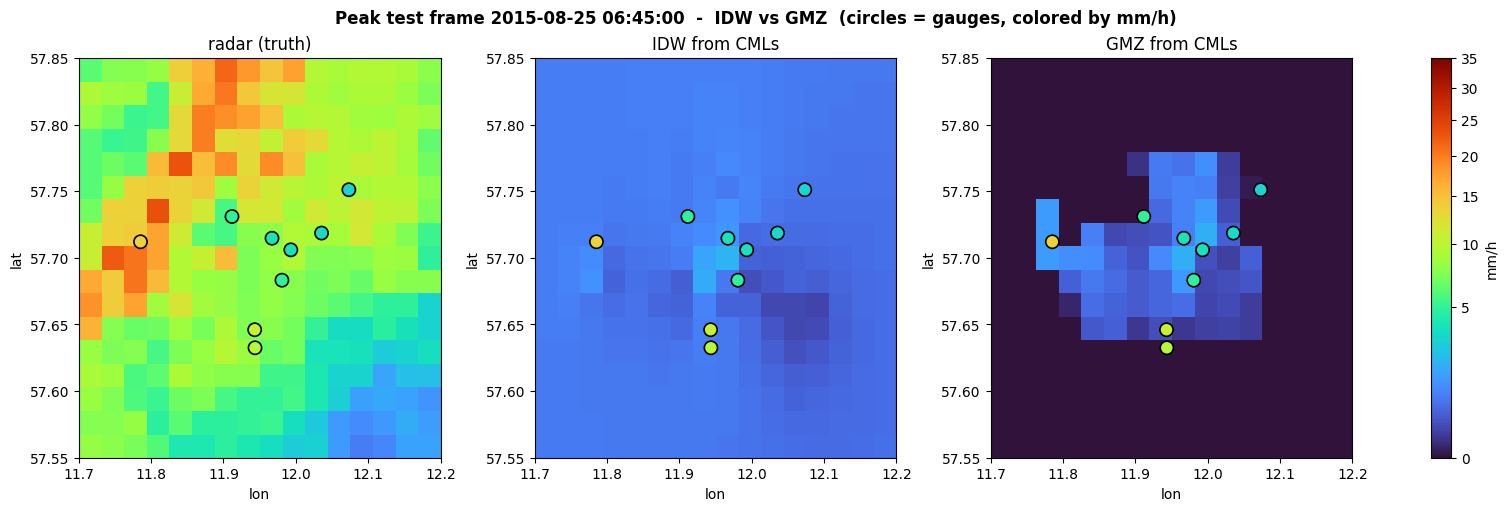

In [ ]:
# Peak frame in test window
test_means = crop_field(radar_15)[idx_test[0]:idx_test[1]].mean(axis=(1, 2))
peak_local = int(np.argmax(test_means))
peak_global = idx_test[0] + peak_local
peak_t = radar_times[peak_global]
print(f"Peak test frame: {peak_t}  spatial-mean radar rain={test_means[peak_local]:.3f} mm/h")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
panels = [("radar (truth)", crop_field(radar_15)[peak_global]),
          ("IDW from CMLs",  crop_field(idw_maps_full)[peak_global]),
          ("GMZ from CMLs",  crop_field(gmz_maps_full)[peak_global])]
# Fixed non-linear colour scale: gamma=0.5 stretches the low end,
# all values above 35 mm/h saturate to the same top colour.
vmax = 35.0
norm = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)
# Gauge readings at the peak time, for overlay
g_vals_peak = gauge_values_at_time(peak_global)
for ax, (name, m) in zip(axes, panels):
    im = ax.imshow(m, cmap="turbo", norm=norm, origin="lower",
                   extent=[LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]],
                   aspect="auto")
    overlay_gauges_on_map(ax, gauge_lons, gauge_lats, g_vals_peak,
                           norm=norm, cmap="turbo")
    ax.set_title(name); ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.suptitle(f"Peak test frame {peak_t}  -  IDW vs GMZ  (circles = gauges, colored by mm/h)",
              fontweight="bold")
fig.colorbar(im, ax=axes, fraction=0.04, label="mm/h")
plt.show()

# PART 3 — CML ESTIMATION MODEL (Model 2)

**Role.** The estimation NN takes per-CML RSL/TSL time series and produces
per-CML rain-rate predictions — same role as the physical estimator
(Part 2.2) but learned from data. The output is then projected onto the
radar grid via IDW and GMZ to produce the **training input maps** for all
advanced forecast models in Part 5.

**Architecture.** Two-step network from pynncml: a multi-layer GRU with
two heads — a rain-rate regressor and a wet/dry detector. The detector
masks the regressor at inference.


## Part 3.1 — Architecture and helpers

* `RegressionLoss` — weighted MSE that emphasizes wet samples.
* `build_model(rnn_n_features, n_layers, normalization_cfg)` — factory.
* `build_loader(time_slice, batch_size, shuffle)` — DataLoader factory.

Hyperparameters fixed by reference: `window_size=32`, `rnn_n_features=256`.

**Inputs:** none new.
**Outputs:** `build_model`, `build_loader`, `RegressionLoss`, `exp_gamma`.


In [ ]:
def _slice_name(sl):
    for nm, s in splits_cfg.items():
        if (s.start, s.stop) == (sl.start, sl.stop):
            return nm.lower()
    if (sl.start, sl.stop) == (FULL_SLICE.start, FULL_SLICE.stop):
        return "full"
    return f"slice_{sl.start}_{sl.stop}".replace("-", "")

def build_loader(time_slice, batch_size, shuffle):
    ds = load_dataset_cached(time_slice, _slice_name(time_slice))
    return torch.utils.data.DataLoader(ds, batch_size=batch_size,
                                        shuffle=shuffle, drop_last=False)

def compute_norm_cached(loader, name):
    if name in _NORM_MEMORY_CACHE:
        return _NORM_MEMORY_CACHE[name]
    print(f"  Computing normalization '{name}' (one-time) ...")
    t0 = time.time()
    n = pnc.training_helpers.compute_data_normalization(loader)
    _NORM_MEMORY_CACHE[name] = n
    print(f"    done in {time.time()-t0:.1f} s")
    return n

class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super().__init__(); self.in_gamma = in_gamma; self.gamma_s = gamma_s
    def forward(self, x, t):
        d = (t - x) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * t)
        return torch.sum(torch.mean(w * d, dim=0))

rg_train_flat = np.stack([p.data_array for p in full_dataset.point_set]).flatten()
rg_train_flat = rg_train_flat[: int(len(rg_train_flat) * (50/92))]
exp_gamma = float(scipy.stats.expon.fit(rg_train_flat)[1])
print(f"exp_gamma : {exp_gamma:.4f}")

def build_model(rnn_n_features=RNN_N_FEATURES, n_layers=2, metadata_n_features=32,
                rnn_input_size=180, metadata_input_size=2,
                normalization_cfg=None):
    return pnc.scm.rain_estimation.two_step_network(
        n_layers=n_layers,
        rnn_type=pnc.neural_networks.RNNType.GRU,
        normalization_cfg=normalization_cfg,
        rnn_input_size=rnn_input_size,
        rnn_n_features=rnn_n_features,
        metadata_input_size=metadata_input_size,
        metadata_n_features=metadata_n_features,
        pretrained=False,
    )

_probe_loader = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
_probe_norm   = compute_norm_cached(_probe_loader, "train")
_m = build_model(normalization_cfg=_probe_norm).to(device)
print(f"\nEstimation NN param count: {sum(p.numel() for p in _m.parameters()):,}")
del _m
if device.type == "cuda": torch.cuda.empty_cache()

exp_gamma : 0.1185
  Computing normalization 'train' (one-time) ...
    done in 1.4 s

Estimation NN param count: 732,174


## Part 3.2 — W&B sweep (skipped if checkpoint exists)

Bayesian sweep over (`lr`, `batch_size`, `rnn_n_features`, `n_layers`,
`weight_decay`). Each trial trains for `SWEEP_EPOCHS_EST` epochs and logs
`final_val_loss` for ranking.

**W&B project:** `FieldSense-Estimation-v2`.

**Skipped** if `models/model2_cml_estimation.pt` already exists.

**Inputs:** train/val loaders.
**Outputs:** `sweep_id_est` (or `None` if skipped), sweep runs in W&B.


In [ ]:
WANDB_PROJECT_EST = "FieldSense-Estimation-v2"
SWEEP_COUNT_EST   = 10
SWEEP_EPOCHS_EST  = 30
EST_CKPT_PATH     = os.path.join(MODELS_DIR, "model2_cml_estimation.pt")

if exists(EST_CKPT_PATH):
    print(f"Estimation checkpoint exists at {EST_CKPT_PATH} — skipping sweep.")
    sweep_id_est = None
else:
    try: wandb.login()
    except Exception as e: print(f"wandb.login failed: {e}")
    train_loader_full = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
    val_loader_full   = build_loader(splits_cfg["Val"],   batch_size=16, shuffle=False)
    norm_cfg = compute_norm_cached(train_loader_full, "train")

    def _epoch(model, loader, opt, lam, train):
        (model.train() if train else model.eval())
        L_rain = RegressionLoss(exp_gamma); L_det = torch.nn.BCELoss()
        tot, tot_e, tot_d, n = 0.,0.,0.,0
        ctx = torch.enable_grad if train else torch.no_grad
        with ctx():
            for rain_rate, rsl, tsl, metadata in loader:
                state = model.init_state(batch_size=rsl.shape[0])
                m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
                for s in range(m_step):
                    if train: opt.zero_grad()
                    _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                    _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    out, state = model(torch.cat([_rsl, _tsl], -1),
                                        metadata.to(device), state.detach())
                    le = L_rain(out[:, :, 0], _rr)
                    ld = L_det(out[:, :, 1], (_rr > THRESHOLD_WET).float())
                    l  = lam * le + ld
                    if not torch.isfinite(l):
                        if train: return float('inf'), float('inf'), float('inf')
                    if train:
                        l.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        opt.step()
                    tot += l.item(); tot_e += le.item(); tot_d += ld.item(); n += 1
        return tot/max(n,1), tot_e/max(n,1), tot_d/max(n,1)

    def sweep_run():
        with wandb.init() as run:
            cfg = wandb.config
            m = build_model(rnn_n_features=cfg.rnn_n_features,
                             n_layers=cfg.n_layers,
                             normalization_cfg=norm_cfg).to(device)
            opt = torch.optim.RAdam(m.parameters(), lr=cfg.lr,
                                     weight_decay=cfg.weight_decay)
            with torch.no_grad():
                le0, ld0 = 0., 0.
                for rain_rate, rsl, tsl, metadata in train_loader_full:
                    state = m.init_state(batch_size=rsl.shape[0])
                    m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
                    for s in range(m_step):
                        _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                        _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                        _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                        out, state = m(torch.cat([_rsl, _tsl], -1),
                                        metadata.to(device), state.detach())
                        le0 += RegressionLoss(exp_gamma)(out[:, :, 0], _rr).item()
                        ld0 += torch.nn.BCELoss()(out[:, :, 1],
                                                  (_rr > THRESHOLD_WET).float()).item()
                    break
                lam = ld0 / max(le0, 1e-9)
            for ep in range(SWEEP_EPOCHS_EST):
                tr  = _epoch(m, train_loader_full, opt, lam, True)
                val = _epoch(m, val_loader_full,   opt, lam, False)
                wandb.log({"epoch": ep, "train_loss": tr[0], "val_loss": val[0]})
            wandb.log({"final_val_loss": val[0]})

    sweep_cfg = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "lr":             {"distribution": "log_uniform_values", "min": 1e-5, "max": 1e-3},
            "batch_size":     {"values": [8, 16, 32]},
            "rnn_n_features": {"values": [128, 256]},
            "n_layers":       {"values": [1, 2]},
            "weight_decay":   {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
        },
    }
    print(f"Launching estimation sweep ({SWEEP_COUNT_EST} trials)...")
    sweep_id_est = wandb.sweep(sweep_cfg, project=WANDB_PROJECT_EST)
    wandb.agent(sweep_id_est, function=sweep_run, count=SWEEP_COUNT_EST)
    print("Estimation sweep done.")

Estimation checkpoint exists at /content/drive/MyDrive/FieldSense_Project_v2/models/model2_cml_estimation.pt — skipping sweep.


## Part 3.3 — Final training of the CML estimation model

`FINAL_EPOCHS_EST = 200`. If the checkpoint already exists, just load it.
Otherwise pull the best sweep hyperparameters and train a fresh model.
Use **best-by-val** checkpointing (save the epoch with lowest validation
loss; never peek at Test during training).

**Inputs:** sweep results / cached checkpoint.
**Outputs:** `est_model` ready for inference.


In [ ]:
FORCE_RETRAIN_EST = False

if (not FORCE_RETRAIN_EST) and exists(EST_CKPT_PATH):
    print(f"Loading {EST_CKPT_PATH}")
    train_loader_full = build_loader(splits_cfg["Train"], batch_size=16, shuffle=True)
    norm_cfg = compute_norm_cached(train_loader_full, "train")
    ckpt = torch.load(EST_CKPT_PATH, map_location=device, weights_only=False)
    cfg  = ckpt.get("hparams", {"rnn_n_features": 256, "n_layers": 2})
    est_model = build_model(rnn_n_features=cfg["rnn_n_features"],
                             n_layers=cfg["n_layers"],
                             normalization_cfg=norm_cfg).to(device)
    sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    est_model.load_state_dict(sd, strict=False)
    print("  loaded.")
else:
    api  = wandb.Api()
    runs = [r for r in api.runs(WANDB_PROJECT_EST,
                                 filters={"sweep": sweep_id_est, "state": "finished"})
            if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    cfg  = {k: best.config[k] for k in ("lr","batch_size","rnn_n_features","n_layers","weight_decay")}
    print(f"Best sweep config: {cfg}")
    train_loader = build_loader(splits_cfg["Train"], batch_size=cfg["batch_size"], shuffle=True)
    val_loader   = build_loader(splits_cfg["Val"],   batch_size=cfg["batch_size"], shuffle=False)
    norm_cfg = compute_norm_cached(train_loader, "train")
    est_model = build_model(rnn_n_features=cfg["rnn_n_features"],
                             n_layers=cfg["n_layers"],
                             normalization_cfg=norm_cfg).to(device)
    opt = torch.optim.RAdam(est_model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg["weight_decay"])
    L_rain = RegressionLoss(exp_gamma); L_det = torch.nn.BCELoss()
    # quick lambda calibration
    with torch.no_grad():
        le0, ld0 = 0., 0.
        for rain_rate, rsl, tsl, metadata in train_loader:
            state = est_model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
            for s in range(m_step):
                _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                out, state = est_model(torch.cat([_rsl, _tsl], -1),
                                        metadata.to(device), state.detach())
                le0 += L_rain(out[:, :, 0], _rr).item()
                ld0 += L_det(out[:, :, 1], (_rr > THRESHOLD_WET).float()).item()
            break
        lam = ld0 / max(le0, 1e-9)

    best_val, best_state = float('inf'), None
    train_hist, val_hist = [], []
    for ep in range(FINAL_EPOCHS_EST):
        est_model.train()
        tot = 0.; n = 0
        for rain_rate, rsl, tsl, metadata in train_loader:
            state = est_model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
            for s in range(m_step):
                opt.zero_grad()
                _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                out, state = est_model(torch.cat([_rsl, _tsl], -1),
                                        metadata.to(device), state.detach())
                l = lam * L_rain(out[:, :, 0], _rr) + L_det(out[:, :, 1],
                                                              (_rr > THRESHOLD_WET).float())
                if not torch.isfinite(l): continue
                l.backward()
                torch.nn.utils.clip_grad_norm_(est_model.parameters(), max_norm=1.0)
                opt.step()
                tot += l.item(); n += 1
        # val
        est_model.eval()
        with torch.no_grad():
            v_tot = 0.; v_n = 0
            for rain_rate, rsl, tsl, metadata in val_loader:
                state = est_model.init_state(batch_size=rsl.shape[0])
                m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
                for s in range(m_step):
                    _rr  = rain_rate[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, 0].float().to(device)
                    _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                    out, state = est_model(torch.cat([_rsl, _tsl], -1),
                                            metadata.to(device), state.detach())
                    lv = lam * L_rain(out[:, :, 0], _rr) + L_det(out[:, :, 1],
                                                                   (_rr > THRESHOLD_WET).float())
                    v_tot += lv.item(); v_n += 1
        train_avg = tot/max(n,1)
        val_avg   = v_tot/max(v_n,1)
        train_hist.append(train_avg); val_hist.append(val_avg)
        if val_avg < best_val:
            best_val = val_avg
            best_state = {k: vv.detach().cpu().clone() for k, vv in est_model.state_dict().items()}
        if (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={train_avg:.4f}  val={val_avg:.4f}  best_val={best_val:.4f}")
    if best_state is not None:
        est_model.load_state_dict(best_state)
    torch.save({"model_state_dict": est_model.state_dict(), "hparams": cfg,
                "train_hist": train_hist, "val_hist": val_hist}, EST_CKPT_PATH)
    print(f"Saved {EST_CKPT_PATH}")
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(train_hist, label="train"); ax.plot(val_hist, label="val")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_title("CML estimation model training")
    plt.show()

est_model.eval()
print(f"Estimation model ready ({sum(p.numel() for p in est_model.parameters()):,} params).")

Loading /content/drive/MyDrive/FieldSense_Project_v2/models/model2_cml_estimation.pt
  loaded.
Estimation model ready (732,174 params).


## Part 3.4 — Generate Model-2 estimation maps (IDW + GMZ)

Run the trained estimation model over the full dataset, then project the
per-CML predictions onto the radar grid via **both** IDW and GMZ.

These are the maps the advanced forecast models (Part 5) will consume.

**Inputs:** `est_model`, `full_dataset`.
**Outputs:**
* `model2_cml_estimation_maps_idw.npy` — `(T, H, W)` IDW
* `model2_cml_estimation_maps_gmz.npy` — `(T, H, W)` GMZ


In [ ]:
EST_IDW_PATH = os.path.join(PROCESSED_DIR, "model2_cml_estimation_maps_idw.npy")
EST_GMZ_PATH = os.path.join(PROCESSED_DIR, "model2_cml_estimation_maps_gmz.npy")
PERLINK_PATH = os.path.join(PROCESSED_DIR, "model2_per_link_pred.npy")

def infer_all_links(model, dataset):
    full_loader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    model.eval()
    with torch.no_grad():
        for rain_rate, rsl, tsl, metadata in full_loader:
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / WINDOW_SIZE)
            preds = []
            for s in range(m_step):
                _rsl = rsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _tsl = tsl[:, s*WINDOW_SIZE:(s+1)*WINDOW_SIZE, :].to(device)
                _meta = metadata.to(device)
                out, state = model(torch.cat([_rsl, _tsl], -1), _meta, state.detach())
                rh = out[:, :, 0] * torch.round(out[:, :, 1])
                preds.append(rh.cpu().numpy())
            return np.concatenate(preds, axis=1).T

if exists(EST_IDW_PATH) and exists(EST_GMZ_PATH):
    model2_idw = np.load(EST_IDW_PATH)
    model2_gmz = np.load(EST_GMZ_PATH)
    print(f"Loaded cached Model-2 maps  IDW={model2_idw.shape}  GMZ={model2_gmz.shape}")
else:
    if exists(PERLINK_PATH):
        per_link_pred = np.load(PERLINK_PATH)
    else:
        per_link_pred = infer_all_links(est_model, full_dataset)
        np.save(PERLINK_PATH, per_link_pred)
    print(f"per-link NN predictions: {per_link_pred.shape}")

    # Resample to radar grid
    T_pred = per_link_pred.shape[0]
    span_min = ((pd.Timestamp(FULL_SLICE.stop) + pd.Timedelta(days=1) -
                 pd.Timestamp(FULL_SLICE.start)).total_seconds()) / 60.0
    candidates = np.array([1, 5, 15, 30, 60], dtype=float)
    step_min = float(candidates[np.argmin(np.abs(candidates - span_min / max(T_pred,1)))])
    print(f"  detected per-link cadence: {step_min:.0f} min")
    pred_times = pd.date_range(start=FULL_SLICE.start, periods=T_pred, freq=f"{int(step_min)}min")
    link_15_pred = (pd.DataFrame(per_link_pred, index=pred_times)
                     .resample("15min", label="right", closed="right").mean()
                     .reindex(radar_times, method="nearest", tolerance=TOL)
                     .fillna(0.0).astype(np.float32))

    print("  building Model-2 IDW maps ...")
    model2_idw = idw_to_grid(link_15_pred.values, link_lons, link_lats, lon2d, lat2d, p=2.0)
    np.save(EST_IDW_PATH, model2_idw)

    print("  building Model-2 GMZ maps ...")
    res = torch.tensor(link_15_pred.values, dtype=torch.float32).T
    gmz = pnc.mcm.generate_link_set_gmz(full_dataset.link_set,
                                         roi=REGION_OF_INTEREST,
                                         point_per_link=POINT_PER_LINK)
    gmz_out = gmz(res)
    rain_map_gmz = gmz_out[0] if isinstance(gmz_out, tuple) else gmz_out
    rain_map_gmz = rain_map_gmz.detach().cpu().numpy()
    out_shape_xy = rain_map_gmz.shape[1:]
    x_real, y_real = get_gmz_grid_vectors(gmz, out_shape_xy, link_lons, link_lats)
    model2_gmz = pyn_to_radar_grid(
        rain_map_gmz,
        np.asarray(x_real), np.asarray(y_real),
        lat2d, lon2d, link_lons, link_lats,
    )
    np.save(EST_GMZ_PATH, model2_gmz)

print(f"\nModel-2 IDW: {model2_idw.shape}  mean={model2_idw.mean():.4f}  "
      f"wet%={100*(model2_idw>THRESHOLD_WET).mean():.2f}")
print(f"Model-2 GMZ: {model2_gmz.shape}  mean={model2_gmz.mean():.4f}  "
      f"wet%={100*(model2_gmz>THRESHOLD_WET).mean():.2f}")

Loaded cached Model-2 maps  IDW=(8832, 48, 37)  GMZ=(8832, 48, 37)

Model-2 IDW: (8832, 48, 37)  mean=0.0987  wet%=8.84
Model-2 GMZ: (8832, 48, 37)  mean=nan  wet%=0.21


# PART 4 — NAIVE MODELS

**Persistence** is the trivial forecast that says nothing changes:
$$\hat{y}(t+h) = y(t)$$

It's a strong baseline at short horizons (rain doesn't move that fast) and
gives a *floor* every learned forecaster must beat. We build four families:

| Naive model | Source field |
|-------------|--------------|
| `naive_radar_{h}min`    | Radar map at $t-h$ |
| `naive_gauge_{h}min`    | IDW(gauge readings) at $t-h$ |
| `naive_cml_{h}min`      | Model-2 IDW estimation map at $t-h$ |
| `model1_physical`       | ITU-R inversion of CML attenuation (no NN, no DL) |

For each forecast horizon $h \in \{1,2,3,4\}$ (15, 30, 45, 60 min) we
save a separate `.npy` file.


## Part 4.1 — Naive radar persistence

At every 15-min slot $t$, predict the radar map from $h$ slots earlier.
The first $h$ frames are filled with zeros (no history available).

**Inputs:** `radar_15`.
**Outputs:** `naive_radar_{15,30,45,60}min.npy` cached.


In [ ]:
naive_radar = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    out = os.path.join(PROCESSED_DIR, f"naive_radar_{h_min}min.npy")
    if exists(out):
        naive_radar[h_min] = np.load(out)
        print(f"  h={h_min:>3d}: loaded {out}")
    else:
        pred = np.zeros_like(radar_15)
        pred[h:] = radar_15[:-h]
        np.save(out, pred)
        naive_radar[h_min] = pred
        print(f"  h={h_min:>3d}: built  {out}")

  h= 15: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_radar_15min.npy
  h= 30: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_radar_30min.npy
  h= 45: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_radar_45min.npy
  h= 60: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_radar_60min.npy


## Part 4.2 — Naive gauge persistence (IDW → persist)

IDW the gauge readings onto the radar grid, then apply persistence per
horizon.

**Inputs:** `gauges_15`, `radar_times`.
**Outputs:** `naive_gauge_{15,30,45,60}min.npy` cached.


In [ ]:
# `gauge_aligned` was already built in Part 1.5; just reuse it.
print(f"Reusing gauge_aligned from Part 1.5: {gauge_aligned.shape}")

# Build dense gauge field once
GAUGE_FIELD_PATH = os.path.join(PROCESSED_DIR, "gauge_field_full.npy")
if exists(GAUGE_FIELD_PATH):
    gauge_field_full = np.load(GAUGE_FIELD_PATH)
else:
    gauge_field_full = idw_to_grid(gauge_aligned.values, gauge_lons, gauge_lats,
                                    lon2d, lat2d, p=2.0)
    np.save(GAUGE_FIELD_PATH, gauge_field_full)

naive_gauge = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    out = os.path.join(PROCESSED_DIR, f"naive_gauge_{h_min}min.npy")
    if exists(out):
        naive_gauge[h_min] = np.load(out)
        print(f"  h={h_min:>3d}: loaded {out}")
    else:
        pred = np.zeros_like(gauge_field_full)
        pred[h:] = gauge_field_full[:-h]
        np.save(out, pred)
        naive_gauge[h_min] = pred
        print(f"  h={h_min:>3d}: built  {out}")

Reusing gauge_aligned from Part 1.5: (8832, 9)
  h= 15: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_gauge_15min.npy
  h= 30: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_gauge_30min.npy
  h= 45: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_gauge_45min.npy
  h= 60: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_gauge_60min.npy


## Part 4.3 — Naive CML persistence (Model-2 IDW → persist)

Use the Model-2 IDW estimation maps (Part 3.4) as the field, then persist.
Tests the value of CML estimation when paired with the simplest possible
forecaster.

**Inputs:** `model2_idw`.
**Outputs:** `naive_cml_{15,30,45,60}min.npy` cached.


In [ ]:
naive_cml = {}
for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    out = os.path.join(PROCESSED_DIR, f"naive_cml_{h_min}min.npy")
    if exists(out):
        naive_cml[h_min] = np.load(out)
        print(f"  h={h_min:>3d}: loaded {out}")
    else:
        pred = np.zeros_like(model2_idw)
        pred[h:] = model2_idw[:-h]
        np.save(out, pred)
        naive_cml[h_min] = pred
        print(f"  h={h_min:>3d}: built  {out}")

  h= 15: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_cml_15min.npy
  h= 30: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_cml_30min.npy
  h= 45: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_cml_45min.npy
  h= 60: loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/naive_cml_60min.npy


## Part 4.4 — Model 1: physical CML estimator (ITU-R inversion)

ITU-R P.838 power-law inversion of CML attenuation, **no neural network**.

**Equation.** Given attenuation $A$ (dB) on a link of length $L$ (km),
specific attenuation $\gamma = A/L$ (dB/km), and frequency- and
polarization-dependent coefficients $(a, b)$ from ITU-R P.838:

$$R = \left(\frac{\gamma}{a}\right)^{1/b} \quad (\text{mm/h})$$

This is what `pynncml.scm.rain_estimation.one_step_dynamic_baseline` with
the MAX power-law computes (already done in Part 2.2 — we reuse that
per-link series). Here we just project to the radar grid via IDW.

**Inputs:** `per_link_rain_1min` (from Part 2.2).
**Outputs:** `model1_physical.npy` `(T, H, W)`.


In [ ]:
MODEL1_PATH = os.path.join(PROCESSED_DIR, "model1_physical.npy")
if exists(MODEL1_PATH):
    model1_physical = np.load(MODEL1_PATH)
    print(f"Loaded {MODEL1_PATH}")
else:
    # link_15 was built in Part 2.2 from per_link_rain_1min
    model1_physical = idw_to_grid(link_15.values, link_lons, link_lats, lon2d, lat2d, p=2.0)
    np.save(MODEL1_PATH, model1_physical)
    print(f"Saved {MODEL1_PATH}")
print(f"  shape={model1_physical.shape}  mean={model1_physical.mean():.4f}  "
      f"wet%={100*(model1_physical>THRESHOLD_WET).mean():.2f}")

Loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/model1_physical.npy
  shape=(8832, 48, 37)  mean=0.1066  wet%=18.69


# PART 5 — ADVANCED FORECAST MODELS

**The 2×2 training matrix** — every advanced model is trained in 4 variants:

|                    | single-step (one model per h) | multi-step (one model, all h) |
|--------------------|--------------------------------|--------------------------------|
| **IDW input maps** | `{model}_single_idw`           | `{model}_multi_idw`            |
| **GMZ input maps** | `{model}_single_gmz`           | `{model}_multi_gmz`            |

Repeated for: **Transformer**, **SINDy**, **Mamba**.

**Input source:** Model-2 estimation maps (`model2_idw` or `model2_gmz`),
i.e. the trained CML NN's output projected to the radar grid via IDW or GMZ.

**Lookback:** 8 frames (2 hours). **Horizons:** 15/30/45/60 min.


## Part 5.0 — Common forecasting dataset helpers

`create_forecasting_dataset(maps, lookback, horizon)` yields supervised
pairs $(X, Y)$ where:

* $X \in \mathbb{R}^{N \times \text{lookback} \times H \times W}$ — last
  `lookback` frames.
* $Y \in \mathbb{R}^{N \times H \times W}$ — frame at
  $t + h$ steps later.

`create_multi_horizon_dataset` stacks targets for all horizons:
$Y \in \mathbb{R}^{N \times n_h \times H \times W}$.

NaNs in inputs are zeroed.

**Inputs:** any `(T, H, W)` map array.
**Outputs:** torch tensors $X, Y$.


In [ ]:
def create_forecasting_dataset(maps, lookback=LOOKBACK_WINDOW, horizon=1):
    clean = np.nan_to_num(maps, nan=0.0).astype(np.float32)
    X, Y = [], []
    for i in range(len(clean) - lookback - horizon + 1):
        X.append(clean[i : i + lookback])
        Y.append(clean[i + lookback + horizon - 1])
    return (torch.tensor(np.array(X)), torch.tensor(np.array(Y)))

def create_multi_horizon_dataset(maps, lookback=LOOKBACK_WINDOW, horizons=HORIZONS_STEPS):
    clean = np.nan_to_num(maps, nan=0.0).astype(np.float32)
    h_max = max(horizons)
    X, Y = [], []
    for i in range(len(clean) - lookback - h_max + 1):
        X.append(clean[i : i + lookback])
        Y.append(np.stack([clean[i + lookback + h - 1] for h in horizons], axis=0))
    return (torch.tensor(np.array(X)), torch.tensor(np.array(Y)))

# Split indices
TRAIN_LO, TRAIN_HI = idx_train
VAL_LO,   VAL_HI   = idx_val
TEST_LO,  TEST_HI  = idx_test

SPATIAL_SHAPE = (H, W)
print(f"SPATIAL_SHAPE: {SPATIAL_SHAPE}")
print(f"Train idx: {TRAIN_LO}..{TRAIN_HI}  Val idx: {VAL_LO}..{VAL_HI}  Test idx: {TEST_LO}..{TEST_HI}")

# Map-type registry: each entry is (train_arr, val_arr, test_arr)
MAP_SOURCES = {
    "idw": (model2_idw[TRAIN_LO:TRAIN_HI], model2_idw[VAL_LO:VAL_HI], model2_idw[TEST_LO:TEST_HI]),
    "gmz": (model2_gmz[TRAIN_LO:TRAIN_HI], model2_gmz[VAL_LO:VAL_HI], model2_gmz[TEST_LO:TEST_HI]),
}
for name, (tr, va, te) in MAP_SOURCES.items():
    print(f"  {name}: train={tr.shape}  val={va.shape}  test={te.shape}")

SPATIAL_SHAPE: (48, 37)
Train idx: 0..4799  Val idx: 4799..6335  Test idx: 6335..8831
  idw: train=(4799, 48, 37)  val=(1536, 48, 37)  test=(2496, 48, 37)
  gmz: train=(4799, 48, 37)  val=(1536, 48, 37)  test=(2496, 48, 37)


## Part 5.1 — Generic training helper with early stopping

`train_with_early_stop(model, X_tr, Y_tr, X_val, Y_val, ...)` runs a clean
training loop with:
* NaN guard (skips batches with non-finite loss)
* Gradient clipping (max-norm 1.0)
* Best-by-val checkpointing (no test peeking)

Returns the best `state_dict` and the train/val loss histories.

**Inputs:** untrained `nn.Module`, train/val tensors, hparams.
**Outputs:** `(best_state, train_hist, val_hist, best_epoch, best_val)`.


In [ ]:
def train_with_early_stop(model, X_tr, Y_tr, X_val, Y_val,
                             lr, batch_size, n_epochs,
                             loss_fn=None, device=device, verbose=True):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = loss_fn if loss_fn is not None else nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr),
        batch_size=batch_size, shuffle=True)
    best_val, best_state, best_ep = float("inf"), None, -1
    train_hist, val_hist = [], []
    for ep in range(n_epochs):
        model.train()
        tot, n = 0., 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            if not torch.isfinite(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            tot += loss.item(); n += 1
        model.eval()
        with torch.no_grad():
            v = crit(model(X_val.to(device)), Y_val.to(device)).item()
        if not np.isfinite(v): v = float("inf")
        train_avg = tot / max(n, 1)
        train_hist.append(train_avg); val_hist.append(v)
        if v < best_val:
            best_val = v; best_ep = ep + 1
            best_state = {k: vv.detach().cpu().clone() for k, vv in model.state_dict().items()}
        if verbose and (ep + 1) % 10 == 0:
            print(f"  ep {ep+1}: train={train_avg:.4f}  val={v:.4f}  best_val={best_val:.4f}")
    return best_state, train_hist, val_hist, best_ep, best_val

print("train_with_early_stop helper ready.")

train_with_early_stop helper ready.


## Part 5.2 — Transformer architecture

**Self-attention:** $\text{Attn}(Q,K,V) = \text{softmax}(QK^\top / \sqrt{d_k})\,V$.

**RainTransformer** flattens each `(H, W)` map into a single token of length
$H \cdot W$, projects to $d_{\text{model}}$, runs `nn.TransformerEncoder`
across the lookback dimension, and decodes the **last** time step's
representation into $n_{\text{horizons}} \cdot H \cdot W$ outputs.

Reference architecture (from `Mamba_SIDNy_Trans.ipynb`): `d_model=128`,
`n_heads=4`, `n_layers=2`.

**Inputs:** `(B, T, H, W)`. **Outputs:** `(B, H, W)` single-step or
`(B, n_h, H, W)` multi-step.


In [ ]:
class RainTransformer(nn.Module):
    def __init__(self, spatial_dim, d_model=128, n_heads=4, n_layers=2, n_horizons=1):
        super().__init__()
        self.flatten_dim = spatial_dim[0] * spatial_dim[1]
        self.spatial_dim = spatial_dim
        self.n_horizons  = n_horizons
        self.embedding   = nn.Linear(self.flatten_dim, d_model)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.decoder     = nn.Linear(d_model, n_horizons * self.flatten_dim)
    def forward(self, x):
        b, t, h, w = x.shape
        x = x.view(b, t, -1)
        x = self.embedding(x)
        x = self.transformer(x)
        out = self.decoder(x[:, -1, :])
        if self.n_horizons == 1:
            return out.view(b, h, w)
        return out.view(b, self.n_horizons, h, w)

_m = RainTransformer(SPATIAL_SHAPE)
print(f"RainTransformer param count: {sum(p.numel() for p in _m.parameters()):,}")
del _m

RainTransformer param count: 1,642,608


## Part 5.3 — Transformer W&B sweep (best config saved to JSON)

Bayesian sweep over `d_model`, `n_heads`, `n_layers`, `lr`, `batch_size`,
`dropout` (handled via separate small wrapper for hp completeness). Sweep
target: horizon-1 val MSE on the **IDW** map source. The best config is
saved to `transformer_sweep_best.json` and reused for all 4 variants.

**W&B project:** `FieldSense-Transformer-v2`.

**Inputs:** IDW train/val tensors.
**Outputs:** `best_cfg_tf` (dict) saved to JSON.


In [ ]:
WANDB_PROJECT_TF = "FieldSense-Transformer-v2"
TF_BEST_PATH     = os.path.join(MODELS_DIR, "transformer_sweep_best.json")
SWEEP_COUNT_TF   = 6
SWEEP_EPOCHS_TF  = 25

if exists(TF_BEST_PATH):
    with open(TF_BEST_PATH) as f: best_cfg_tf = _json.load(f)
    print(f"Loaded TF best config: {best_cfg_tf}")
else:
    print("Running Transformer sweep on IDW (horizon=1) ...")
    tr_maps, va_maps, _ = MAP_SOURCES["idw"]
    X_tr, Y_tr = create_forecasting_dataset(tr_maps, LOOKBACK_WINDOW, 1)
    X_val, Y_val = create_forecasting_dataset(va_maps, LOOKBACK_WINDOW, 1)

    try: wandb.login()
    except Exception as e: print(f"wandb.login failed: {e}")

    def sweep_run_tf():
        with wandb.init() as run:
            cfg = wandb.config
            m = RainTransformer(SPATIAL_SHAPE, d_model=cfg.d_model,
                                 n_heads=cfg.n_heads, n_layers=cfg.n_layers).to(device)
            best_state, tr_h, vl_h, _, best_val = train_with_early_stop(
                m, X_tr, Y_tr, X_val, Y_val,
                cfg.lr, cfg.batch_size, SWEEP_EPOCHS_TF, verbose=False)
            for ep, (a, b_) in enumerate(zip(tr_h, vl_h)):
                wandb.log({"epoch": ep, "train_loss": a, "val_loss": b_})
            wandb.log({"final_val_loss": best_val})

    sweep_cfg = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "d_model":    {"values": [64, 128, 256]},
            "n_heads":    {"values": [2, 4, 8]},
            "n_layers":   {"values": [1, 2, 3]},
            "lr":         {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-3},
            "batch_size": {"values": [8, 16, 32]},
        },
    }
    sid = wandb.sweep(sweep_cfg, project=WANDB_PROJECT_TF)
    wandb.agent(sid, function=sweep_run_tf, count=SWEEP_COUNT_TF)
    api = wandb.Api()
    runs = [r for r in api.runs(WANDB_PROJECT_TF, filters={"sweep": sid, "state": "finished"})
            if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    best_cfg_tf = {k: best.config[k] for k in ("d_model","n_heads","n_layers","lr","batch_size")}
    with open(TF_BEST_PATH, "w") as f: _json.dump(best_cfg_tf, f)
    print(f"Best TF cfg saved: {best_cfg_tf}")

Loaded TF best config: {'d_model': 64, 'n_heads': 2, 'n_layers': 1, 'lr': 0.00016757221966851266, 'batch_size': 32}


## Part 5.4 — Generic 2×2 trainer for advanced models

`train_model_grid(model_name, model_factory, ...)` runs the 4-variant
training matrix (IDW/GMZ × single/multi) for any architecture. For each
variant:

1. Build the train/val/test tensors from the right map source.
2. Construct a fresh model from `model_factory(n_horizons)`.
3. Train with early stopping; save best-by-val checkpoint.
4. Generate test predictions per horizon; save under
   `{model_name}_{mode}_{map_type}_{h}min.npy`.

Plots one combined train/val loss figure per variant.

**Inputs:** generic.
**Outputs:** prediction `.npy` files for all 16 (4×4) variant×horizon combos.


In [ ]:
def train_model_grid(model_name, model_factory, cfg, n_epochs):
    """
    model_factory(n_horizons) -> nn.Module
    cfg : dict with 'lr', 'batch_size'
    """
    results_paths = {}
    for map_type in ("idw", "gmz"):
        tr_maps, va_maps, te_maps = MAP_SOURCES[map_type]
        # ---- Single-step variants ----
        for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
            ckpt = os.path.join(MODELS_DIR, f"{model_name}_single_{map_type}_h{h}.pt")
            pred = os.path.join(PROCESSED_DIR, f"{model_name}_single_{map_type}_{h_min}min.npy")
            results_paths.setdefault(f"single_{map_type}", {})[h_min] = pred
            X_tr, Y_tr   = create_forecasting_dataset(tr_maps, LOOKBACK_WINDOW, h)
            X_val, Y_val = create_forecasting_dataset(va_maps, LOOKBACK_WINDOW, h)
            X_te, Y_te   = create_forecasting_dataset(te_maps, LOOKBACK_WINDOW, h)
            model = model_factory(n_horizons=1).to(device)
            if exists(ckpt):
                model.load_state_dict(torch.load(ckpt, map_location=device))
                print(f"  [{model_name} single {map_type} h={h_min}] loaded ckpt")
            else:
                print(f"  [{model_name} single {map_type} h={h_min}] training ...")
                best_state, tr_h, vl_h, best_ep, best_val = train_with_early_stop(
                    model, X_tr, Y_tr, X_val, Y_val,
                    cfg["lr"], cfg["batch_size"], n_epochs, verbose=False)
                model.load_state_dict(best_state)
                torch.save(best_state, ckpt)
                print(f"     best_ep={best_ep}  best_val={best_val:.4f}")
            if not exists(pred):
                model.eval()
                with torch.no_grad():
                    p = model(X_te.to(device)).cpu().numpy()
                np.save(pred, p)
            else:
                print(f"     pred cached: {pred}")
        # ---- Multi-step ----
        ckpt_m = os.path.join(MODELS_DIR, f"{model_name}_multi_{map_type}.pt")
        pred_m = os.path.join(PROCESSED_DIR, f"{model_name}_multi_{map_type}.npy")
        X_tr, Y_tr   = create_multi_horizon_dataset(tr_maps, LOOKBACK_WINDOW, HORIZONS_STEPS)
        X_val, Y_val = create_multi_horizon_dataset(va_maps, LOOKBACK_WINDOW, HORIZONS_STEPS)
        X_te, Y_te   = create_multi_horizon_dataset(te_maps, LOOKBACK_WINDOW, HORIZONS_STEPS)
        model = model_factory(n_horizons=len(HORIZONS_STEPS)).to(device)
        if exists(ckpt_m):
            model.load_state_dict(torch.load(ckpt_m, map_location=device))
            print(f"  [{model_name} multi {map_type}] loaded ckpt")
        else:
            print(f"  [{model_name} multi {map_type}] training ...")
            best_state, tr_h, vl_h, best_ep, best_val = train_with_early_stop(
                model, X_tr, Y_tr, X_val, Y_val,
                cfg["lr"], cfg["batch_size"], n_epochs, verbose=False)
            model.load_state_dict(best_state)
            torch.save(best_state, ckpt_m)
            print(f"     best_ep={best_ep}  best_val={best_val:.4f}")
        if not exists(pred_m):
            model.eval()
            with torch.no_grad():
                p = model(X_te.to(device)).cpu().numpy()  # (N, n_h, H, W)
            np.save(pred_m, np.transpose(p, (1, 0, 2, 3)))   # (n_h, N, H, W)
        results_paths.setdefault(f"multi_{map_type}", {})
        for i, h_min in enumerate(HORIZONS_MIN):
            results_paths[f"multi_{map_type}"][h_min] = pred_m  # multi is one file
    return results_paths

print("train_model_grid ready.")

train_model_grid ready.


## Part 5.5 — Train Transformer 2×2

Runs all 8 trainings (4 single-step × 2 map types + 2 multi-step × 2 map
types). Each variant cached separately. `FINAL_EPOCHS_TF = 80`.

**Inputs:** `best_cfg_tf`, `MAP_SOURCES`.
**Outputs:** 8 checkpoints and 16 per-horizon prediction files (single-step
gets 4 per map_type, multi-step gets 1 file containing 4 horizons per map_type).


In [ ]:
FINAL_EPOCHS_TF = 80

def transformer_factory(n_horizons=1):
    return RainTransformer(SPATIAL_SHAPE,
                            d_model=best_cfg_tf["d_model"],
                            n_heads=best_cfg_tf["n_heads"],
                            n_layers=best_cfg_tf["n_layers"],
                            n_horizons=n_horizons)

tf_paths = train_model_grid("transformer", transformer_factory, best_cfg_tf, FINAL_EPOCHS_TF)
print("\nTransformer 2x2 done.")

  [transformer single idw h=15] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_idw_15min.npy
  [transformer single idw h=30] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_idw_30min.npy
  [transformer single idw h=45] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_idw_45min.npy
  [transformer single idw h=60] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_idw_60min.npy
  [transformer multi idw] loaded ckpt
  [transformer single gmz h=15] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_gmz_15min.npy
  [transformer single gmz h=30] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/transformer_single_gmz_30min.npy
  [transformer single gmz h=45] 

## Part 5.6 — SINDy: POD reduction + sparse dynamics

**SINDy** (Sparse Identification of Nonlinear Dynamics) discovers
$\dot{X} = \Theta(X)\,\Xi$ from data:

* $X$ is the state (here, POD coefficients of the spatial maps).
* $\Theta(X)$ is a **library** of candidate functions: 1, $X$, $X^2$, ....
* $\Xi$ is a **sparse** coefficient matrix learned via STLSQ.

**Why POD first?** A $48 \times 37 = 1776$-pixel state is too high-dim for
SINDy. We use TruncatedSVD with `n_modes` components to reduce to a
manageable latent state. The number of POD modes is a hyperparameter
swept over.

**Hyperparameters (Mamba_SIDNy_Trans.ipynb reference):**
* `n_modes = 10`
* `STLSQ(threshold=0.05, alpha=0.05)`
* `PolynomialLibrary(degree=2)`
* `dt = 0.25` h (15 min)

**Inputs:** map source.
**Outputs:** fitted `(svd, sindy_model)` pickled per (mode, map_type).


In [ ]:
DT = 0.25
SINDY_THRESH = 0.05
SINDY_ALPHA  = 0.05
SINDY_LIB_DEG = 2

def fit_sindy(train_maps, n_modes):
    flat = np.nan_to_num(train_maps, nan=0.0).reshape(train_maps.shape[0], -1)
    svd = TruncatedSVD(n_components=n_modes, random_state=42)
    z = svd.fit_transform(flat)
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=SINDY_THRESH, alpha=SINDY_ALPHA),
        feature_library=ps.PolynomialLibrary(degree=SINDY_LIB_DEG),
    )
    model.fit(z, t=DT)
    return svd, model

def sindy_predict_single(svd, model, test_maps, h, lookback=LOOKBACK_WINDOW):
    X_te, _ = create_forecasting_dataset(test_maps, lookback, h)
    init = X_te[:, -1, :, :].numpy()
    b = init.shape[0]
    z0 = svd.transform(init.reshape(b, -1))
    t_eval = np.arange(h + 1) * DT
    z_pred = np.zeros_like(z0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = model.simulate(z0[i], t=t_eval)
                z_pred[i] = sim[-1]
            except Exception:
                z_pred[i] = z0[i]
    return svd.inverse_transform(z_pred).reshape(b, *SPATIAL_SHAPE).astype(np.float32)

def sindy_predict_multi(svd, model, test_maps, horizons=HORIZONS_STEPS,
                         lookback=LOOKBACK_WINDOW):
    X_te, _ = create_multi_horizon_dataset(test_maps, lookback, horizons)
    init = X_te[:, -1, :, :].numpy()
    b = init.shape[0]
    z0 = svd.transform(init.reshape(b, -1))
    h_max = max(horizons)
    t_eval = np.arange(h_max + 1) * DT
    z_traj = np.zeros((b, len(horizons), z0.shape[1]), dtype=np.float32)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(b):
            try:
                sim = model.simulate(z0[i], t=t_eval)
                for j, k in enumerate(horizons):
                    z_traj[i, j] = sim[k]
            except Exception:
                for j in range(len(horizons)):
                    z_traj[i, j] = z0[i]
    flat = svd.inverse_transform(z_traj.reshape(-1, z0.shape[1]))
    return flat.reshape(b, len(horizons), *SPATIAL_SHAPE).astype(np.float32)

print("SINDy helpers ready.")

SINDy helpers ready.


## Part 5.7 — SINDy W&B sweep over equation count (n_modes)

SINDy's expressive power is controlled by `n_modes` (POD components) —
more modes = more equations to discover, but greater overfitting risk.
We sweep $n_{\text{modes}} \in \{4, 6, 8, 10, 12, 16\}$ on the IDW
map source, log validation RMSE and HSS per setting, and pick the best.

**W&B project:** `FieldSense-SINDy-v2`.

**Inputs:** IDW train + val maps.
**Outputs:** `best_n_modes` saved to `sindy_sweep_best.json`.


In [ ]:
WANDB_PROJECT_SINDY = "FieldSense-SINDy-v2"
SINDY_BEST_PATH = os.path.join(MODELS_DIR, "sindy_sweep_best.json")

def rmse(a, b):
    a = a.ravel(); b = b.ravel()
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2))) if m.any() else float("nan")

def hss(pred, true, thr=THRESHOLD_WET):
    p = (pred.ravel() > thr).astype(np.int8)
    g = (true.ravel() > thr).astype(np.int8)
    cm = confusion_matrix(g, p, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    return float(2 * (tp * tn - fp * fn) / den) if den > 0 else float("nan")

if exists(SINDY_BEST_PATH):
    with open(SINDY_BEST_PATH) as f: best_n_modes = _json.load(f)["n_modes"]
    print(f"Loaded SINDy best n_modes: {best_n_modes}")
else:
    print("Running SINDy sweep over n_modes ...")
    tr_maps, va_maps, _ = MAP_SOURCES["idw"]
    candidates = [4, 6, 8, 10, 12, 16]
    rmse_per_n, hss_per_n = [], []
    try: wandb.login()
    except Exception: pass
    for n_modes in candidates:
        try:
            svd_p, sindy_p = fit_sindy(tr_maps, n_modes)
            pred = sindy_predict_single(svd_p, sindy_p, va_maps, 1)
            _, Y_val = create_forecasting_dataset(va_maps, LOOKBACK_WINDOW, 1)
            r = rmse(pred, Y_val.numpy())
            h = hss(pred, Y_val.numpy())
        except Exception as e:
            print(f"  n_modes={n_modes}: FAILED ({e})")
            r, h = float("inf"), float("nan")
        rmse_per_n.append(r); hss_per_n.append(h)
        try:
            with wandb.init(project=WANDB_PROJECT_SINDY,
                            config={"n_modes": n_modes}, reinit=True) as run:
                wandb.log({"val_rmse": r, "val_hss": h, "n_modes": n_modes})
        except Exception: pass
        print(f"  n_modes={n_modes:>2d}: val_rmse={r:.4f}  val_hss={h:.4f}")
    idx_best = int(np.argmin(rmse_per_n))
    best_n_modes = candidates[idx_best]
    with open(SINDY_BEST_PATH, "w") as f: _json.dump({"n_modes": best_n_modes}, f)
    print(f"\nBest SINDy n_modes = {best_n_modes}")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(candidates, rmse_per_n, "o-", label="val RMSE")
    ax.set_xlabel("n_modes"); ax.set_ylabel("val RMSE [mm/h]")
    ax.set_title("SINDy sweep over POD mode count")
    ax.grid(alpha=0.3); plt.show()

Loaded SINDy best n_modes: 4


## Part 5.8 — Train SINDy 2×2 (IDW/GMZ × single/multi)

For each (map_type, mode) variant: fit one SINDy with `best_n_modes`,
integrate at horizons 1..4 (single) or once with sampling (multi). All
4 SINDy variants cached as pickles + prediction `.npy` files.

**Inputs:** `MAP_SOURCES`, `best_n_modes`.
**Outputs:**
* `sindy_single_{idw,gmz}.pkl` and `sindy_multi_{idw,gmz}.pkl`
* `sindy_single_{idw,gmz}_{15,30,45,60}min.npy`
* `sindy_multi_{idw,gmz}.npy` containing `(n_h, T', H, W)`


In [ ]:
sindy_paths = {}
for map_type in ("idw", "gmz"):
    tr_maps, _, te_maps = MAP_SOURCES[map_type]
    # Fit SINDy once per map_type (single-step model)
    pkl_s = os.path.join(MODELS_DIR, f"sindy_single_{map_type}.pkl")
    if exists(pkl_s):
        with open(pkl_s, "rb") as f: svd_s, sindy_s = pickle.load(f)
        print(f"  [SINDy single {map_type}] loaded {pkl_s}")
    else:
        svd_s, sindy_s = fit_sindy(tr_maps, best_n_modes)
        with open(pkl_s, "wb") as f: pickle.dump((svd_s, sindy_s), f)
        print(f"  [SINDy single {map_type}] fitted + saved {pkl_s}")

    for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred_p = os.path.join(PROCESSED_DIR, f"sindy_single_{map_type}_{h_min}min.npy")
        if exists(pred_p):
            sindy_paths.setdefault(f"single_{map_type}", {})[h_min] = pred_p
            continue
        p = sindy_predict_single(svd_s, sindy_s, te_maps, h)
        np.save(pred_p, p)
        sindy_paths.setdefault(f"single_{map_type}", {})[h_min] = pred_p
        print(f"    saved {pred_p}")

    # Multi (same equations, sample trajectory)
    pkl_m = os.path.join(MODELS_DIR, f"sindy_multi_{map_type}.pkl")
    if not exists(pkl_m):
        with open(pkl_m, "wb") as f: pickle.dump((svd_s, sindy_s), f)
    pred_m_path = os.path.join(PROCESSED_DIR, f"sindy_multi_{map_type}.npy")
    if not exists(pred_m_path):
        m_pred = sindy_predict_multi(svd_s, sindy_s, te_maps)
        np.save(pred_m_path, np.transpose(m_pred, (1, 0, 2, 3)))
    sindy_paths.setdefault(f"multi_{map_type}", {})
    for h_min in HORIZONS_MIN:
        sindy_paths[f"multi_{map_type}"][h_min] = pred_m_path
print("\nSINDy 2x2 done.")

  [SINDy single idw] loaded /content/drive/MyDrive/FieldSense_Project_v2/models/sindy_single_idw.pkl
  [SINDy single gmz] loaded /content/drive/MyDrive/FieldSense_Project_v2/models/sindy_single_gmz.pkl

SINDy 2x2 done.


## Part 5.9 — Mamba (SSM surrogate) architecture

A simple state-space model surrogate (the full Mamba selective-scan layers
are not in stock `torch.nn`). We use a GRU over the flattened-frame
sequence — the recurrence pattern $h'(t) = Ah(t) + Bx(t),\ y(t) = Ch(t)$
is well-approximated by a GRU and matches the lab's reference notebook.

Reference: `SimpleMamba` with `hidden_dim=256`.

**Inputs:** `(B, T, H, W)`. **Outputs:** `(B, H, W)` or `(B, n_h, H, W)`.


In [ ]:
class SimpleMamba(nn.Module):
    def __init__(self, spatial_dim, hidden_dim=256, n_layers=1, n_horizons=1):
        super().__init__()
        self.dim = spatial_dim[0] * spatial_dim[1]
        self.spatial_dim = spatial_dim
        self.n_horizons  = n_horizons
        self.gru = nn.GRU(self.dim, hidden_dim, num_layers=n_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, n_horizons * self.dim)
    def forward(self, x):
        b, t, h, w = x.shape
        x = x.view(b, t, -1)
        _, hidden = self.gru(x)
        out = self.fc(hidden[-1])
        if self.n_horizons == 1:
            return out.view(b, h, w)
        return out.view(b, self.n_horizons, h, w)

_m = SimpleMamba(SPATIAL_SHAPE)
print(f"SimpleMamba param count: {sum(p.numel() for p in _m.parameters()):,}")
del _m

SimpleMamba param count: 2,018,544


## Part 5.10 — Mamba W&B sweep + 2×2 training

W&B sweep over `hidden_dim`, `n_layers`, `lr`, `batch_size` on the IDW map
source, horizon=1. Then 8 trainings via `train_model_grid`.

**W&B project:** `FieldSense-Mamba-v2`.

**Inputs:** `MAP_SOURCES`.
**Outputs:** 8 Mamba checkpoints + prediction files.


In [ ]:
WANDB_PROJECT_MB = "FieldSense-Mamba-v2"
MB_BEST_PATH     = os.path.join(MODELS_DIR, "mamba_sweep_best.json")
SWEEP_COUNT_MB   = 6
SWEEP_EPOCHS_MB  = 25
FINAL_EPOCHS_MB  = 80

if exists(MB_BEST_PATH):
    with open(MB_BEST_PATH) as f: best_cfg_mb = _json.load(f)
    print(f"Loaded Mamba best config: {best_cfg_mb}")
else:
    print("Running Mamba sweep ...")
    tr_maps, va_maps, _ = MAP_SOURCES["idw"]
    X_tr, Y_tr = create_forecasting_dataset(tr_maps, LOOKBACK_WINDOW, 1)
    X_val, Y_val = create_forecasting_dataset(va_maps, LOOKBACK_WINDOW, 1)

    try: wandb.login()
    except Exception: pass

    def sweep_run_mb():
        with wandb.init() as run:
            cfg = wandb.config
            m = SimpleMamba(SPATIAL_SHAPE, hidden_dim=cfg.hidden_dim,
                             n_layers=cfg.n_layers).to(device)
            _, tr_h, vl_h, _, best_val = train_with_early_stop(
                m, X_tr, Y_tr, X_val, Y_val,
                cfg.lr, cfg.batch_size, SWEEP_EPOCHS_MB, verbose=False)
            for ep, (a, b_) in enumerate(zip(tr_h, vl_h)):
                wandb.log({"epoch": ep, "train_loss": a, "val_loss": b_})
            wandb.log({"final_val_loss": best_val})

    sweep_cfg = {
        "method": "bayes",
        "metric": {"name": "final_val_loss", "goal": "minimize"},
        "parameters": {
            "hidden_dim": {"values": [128, 256, 512]},
            "n_layers":   {"values": [1, 2]},
            "lr":         {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-3},
            "batch_size": {"values": [8, 16, 32]},
        },
    }
    sid = wandb.sweep(sweep_cfg, project=WANDB_PROJECT_MB)
    wandb.agent(sid, function=sweep_run_mb, count=SWEEP_COUNT_MB)
    api = wandb.Api()
    runs = [r for r in api.runs(WANDB_PROJECT_MB, filters={"sweep": sid, "state": "finished"})
            if "final_val_loss" in r.summary]
    runs.sort(key=lambda r: r.summary["final_val_loss"])
    best = runs[0]
    best_cfg_mb = {k: best.config[k] for k in ("hidden_dim","n_layers","lr","batch_size")}
    with open(MB_BEST_PATH, "w") as f: _json.dump(best_cfg_mb, f)

def mamba_factory(n_horizons=1):
    return SimpleMamba(SPATIAL_SHAPE,
                        hidden_dim=best_cfg_mb["hidden_dim"],
                        n_layers=best_cfg_mb["n_layers"],
                        n_horizons=n_horizons)

mamba_paths = train_model_grid("mamba", mamba_factory, best_cfg_mb, FINAL_EPOCHS_MB)
print("\nMamba 2x2 done.")

Loaded Mamba best config: {'hidden_dim': 512, 'n_layers': 1, 'lr': 0.00013863280027014594, 'batch_size': 16}
  [mamba single idw h=15] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_idw_15min.npy
  [mamba single idw h=30] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_idw_30min.npy
  [mamba single idw h=45] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_idw_45min.npy
  [mamba single idw h=60] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_idw_60min.npy
  [mamba multi idw] loaded ckpt
  [mamba single gmz h=15] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_gmz_15min.npy
  [mamba single gmz h=30] loaded ckpt
     pred cached: /content/drive/MyDrive/FieldSense_Project_v2/data/processed/mamba_single_gmz_30min.npy
 

# PART 5B — pySTEPS RADAR FORECAST MODEL

**pySTEPS** (Pulkkinen et al., 2019, *Geosci. Model Dev.*) is the
open-source operational standard for probabilistic precipitation
nowcasting. It uses **Lagrangian extrapolation**: estimate a motion
field from the last few radar frames using optical flow, then advect the
current map forward.

**Equation (advection):**
$$R(x, t+h) \approx R(x - v(x)\cdot h,\ t)$$
where $v(x)$ is the motion vector field estimated from a sequence of past
radar maps.

This is the strongest operational baseline for $h \le 2$ hours.

**Cite:** Pulkkinen, S., Nerini, D., Pérez Hortal, A. A., Velasco-Forero, C.,
Seed, A., Germann, U., & Foresti, L. (2019). *pySTEPS: an open-source
Python library for probabilistic precipitation nowcasting.* Geoscientific
Model Development, 12(10), 4185-4219.


## Part 5B.1 — Motion field estimation (Lucas-Kanade)

For each test frame $t$, take the previous 3 radar frames, estimate a 2-D
motion field with Lucas-Kanade optical flow, and store it.

**Inputs:** `radar_15` test slice.
**Outputs:** function `pysteps_forecast(t_idx, horizons) -> dict` for use
in next cell.


In [ ]:
import pysteps as ps_lib
from pysteps import motion, nowcasts, utils
from pysteps.utils import conversion

def pysteps_extrapolation_forecast(R_seq, n_leadtimes):
    """
    R_seq      : (3, H, W) past radar frames at uniform dt
    n_leadtimes: int, how many future frames to predict
    Returns    : (n_leadtimes, H, W) predicted frames
    """
    # Estimate motion
    R_safe = np.where(np.isfinite(R_seq), R_seq, 0.0).astype(np.float64)
    R_dbr, _ = conversion.to_reflectivity(R_safe, metadata={"accutime": 15, "unit": "mm/h", "transform": None, "threshold": THRESHOLD_WET, "zerovalue": 0.0})
    try:
        oflow = motion.get_method("lucaskanade")
        V = oflow(R_dbr)
    except Exception:
        # Fallback: zero motion
        V = np.zeros((2, R_safe.shape[1], R_safe.shape[2]))
    # Extrapolate the last frame
    extrap = nowcasts.get_method("extrapolation")
    R_forecast = extrap(R_safe[-1], V, n_leadtimes)
    return np.nan_to_num(R_forecast, nan=0.0).astype(np.float32)

print("pySTEPS extrapolation forecast function ready.")

pySTEPS extrapolation forecast function ready.


## Part 5B.2 — Generate pySTEPS forecasts for test split

For each test frame we use the 3 preceding radar frames as context and
predict 1..4 frames ahead. Saved per horizon: `pysteps_{h}min.npy`.

Note: pySTEPS predicts on the **radar field directly**, not estimation
maps — it has direct access to the observable. This is by design — it's
the operational benchmark for radar-based nowcasting.

**Inputs:** `radar_15`, `idx_test`.
**Outputs:** `pysteps_{15,30,45,60}min.npy` for the test window.


In [ ]:
pysteps_paths = {}
# Generate forecasts: for each t in test window with enough history, predict 1..4 ahead.
# We align the output to "prediction for time t = forecast made at t-h using radar[t-h-2 : t-h+1]"
# Saved shape: (N_aligned, H, W) for each horizon, aligned with the multi-horizon dataset target window.

h_max = max(HORIZONS_STEPS)
N_pred = (TEST_HI - TEST_LO - LOOKBACK_WINDOW - h_max + 1)
print(f"pySTEPS will produce {N_pred} forecasts per horizon")

# Storage: dict h_min -> (N_pred, H, W)
storage = {h_min: np.zeros((N_pred, H, W), dtype=np.float32) for h_min in HORIZONS_MIN}

all_cached = all(exists(os.path.join(PROCESSED_DIR, f"pysteps_{h_min}min.npy"))
                 for h_min in HORIZONS_MIN)
if all_cached:
    pysteps_pred = {h_min: np.load(os.path.join(PROCESSED_DIR, f"pysteps_{h_min}min.npy"))
                    for h_min in HORIZONS_MIN}
    print("Loaded all pySTEPS predictions from cache.")
else:
    print("Generating pySTEPS forecasts ...")
    for i in tqdm(range(N_pred), desc="pySTEPS"):
        global_t = TEST_LO + LOOKBACK_WINDOW + i  # frame from which we extrapolate forward
        if global_t < 2:
            continue
        R_seq = radar_15[global_t-2 : global_t+1]   # 3 frames
        try:
            fc = pysteps_extrapolation_forecast(R_seq, h_max)   # (h_max, H, W)
            for j, h in enumerate(HORIZONS_STEPS):
                storage[HORIZONS_MIN[j]][i] = fc[h-1]
        except Exception as e:
            # On rare failures, fall back to persistence (last frame)
            for h_min in HORIZONS_MIN:
                storage[h_min][i] = R_seq[-1]
    pysteps_pred = {}
    for h_min in HORIZONS_MIN:
        out = os.path.join(PROCESSED_DIR, f"pysteps_{h_min}min.npy")
        np.save(out, storage[h_min])
        pysteps_pred[h_min] = storage[h_min]
        pysteps_paths[h_min] = out
        print(f"  saved {out}  shape={storage[h_min].shape}")
print(f"\npySTEPS predictions ready.")

pySTEPS will produce 2485 forecasts per horizon
Loaded all pySTEPS predictions from cache.

pySTEPS predictions ready.


# PART 5C — LOOKBACK WINDOW SENSITIVITY

**Diagnostic only.** Trains Transformer for a small number of epochs
(`PROBE_EPOCHS = 10`) for each candidate lookback value, plots val RMSE
vs lookback, prints the recommended value. **Weights are not saved.**

The reference notebook used `lookback = 8`. We probe values 4..16 to
verify this is near-optimal — if the curve has a clear minimum elsewhere,
the next reproducibility study should adopt that.


## Part 5C.1 — Probe lookback values

`LOOKBACK_VALUES = [2, 4, 6, 8, 10, 12, 16]`. For each: train Transformer on
IDW for 10 epochs at horizon=1, record val RMSE.

**Inputs:** IDW train/val maps.
**Outputs:** matplotlib plot of val RMSE vs lookback.


Loaded lookback probe results: {'2': 0.12086638808250427, '4': 0.1186872348189354, '6': 0.12833112478256226, '8': 0.12423161417245865, '10': 0.12405163049697876, '12': 0.13274873793125153, '16': 0.11715223640203476}

Recommended lookback (lowest val RMSE in probe): 16
(Reference notebook used 8 — current notebook also uses 8.)


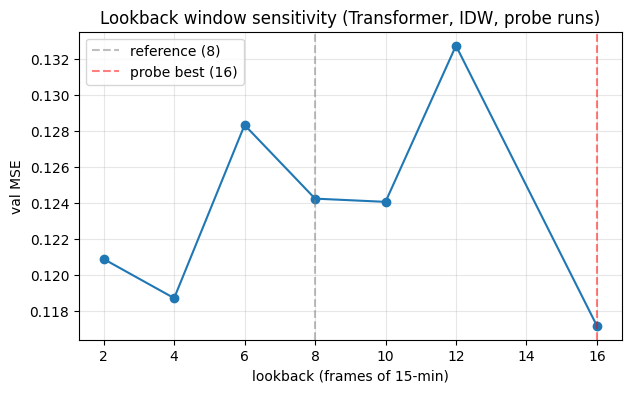

In [ ]:
PROBE_EPOCHS = 10
LOOKBACK_VALUES = [2, 4, 6, 8, 10, 12, 16]
LOOKBACK_PROBE_PATH = os.path.join(PROCESSED_DIR, "lookback_probe_results.json")

if exists(LOOKBACK_PROBE_PATH):
    with open(LOOKBACK_PROBE_PATH) as f: lb_results = _json.load(f)
    print(f"Loaded lookback probe results: {lb_results}")
else:
    tr_maps, va_maps, _ = MAP_SOURCES["idw"]
    lb_results = {}
    for lb in LOOKBACK_VALUES:
        try:
            X_tr, Y_tr = create_forecasting_dataset(tr_maps, lb, 1)
            X_val, Y_val = create_forecasting_dataset(va_maps, lb, 1)
            m = RainTransformer(SPATIAL_SHAPE, d_model=best_cfg_tf["d_model"],
                                 n_heads=best_cfg_tf["n_heads"],
                                 n_layers=best_cfg_tf["n_layers"]).to(device)
            _, _, _, _, best_val = train_with_early_stop(
                m, X_tr, Y_tr, X_val, Y_val,
                best_cfg_tf["lr"], best_cfg_tf["batch_size"], PROBE_EPOCHS, verbose=False)
            lb_results[str(lb)] = float(best_val)
            print(f"  lookback={lb:>2d}  val_rmse(MSE)={best_val:.4f}")
        except Exception as e:
            print(f"  lookback={lb}: FAILED ({e})")
            lb_results[str(lb)] = float("inf")
    with open(LOOKBACK_PROBE_PATH, "w") as f: _json.dump(lb_results, f)

lbs = sorted([int(k) for k in lb_results.keys()])
vals = [lb_results[str(k)] for k in lbs]
best_lb = lbs[int(np.argmin(vals))]
print(f"\nRecommended lookback (lowest val RMSE in probe): {best_lb}")
print(f"(Reference notebook used 8 — current notebook also uses 8.)")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(lbs, vals, "o-")
ax.axvline(8, color="gray", linestyle="--", alpha=0.5, label="reference (8)")
ax.axvline(best_lb, color="red", linestyle="--", alpha=0.5, label=f"probe best ({best_lb})")
ax.set_xlabel("lookback (frames of 15-min)"); ax.set_ylabel("val MSE")
ax.set_title("Lookback window sensitivity (Transformer, IDW, probe runs)")
ax.legend(); ax.grid(alpha=0.3); plt.show()

# PART 5D — FULL-PERIOD TRAINING

Retrains all advanced models on the **complete** IDW and GMZ map arrays
from Part 2 (which span the same dates but are produced directly from our
saved `(T, H, W)` arrays). The Train/Val/Test boundaries are the **same
dates** as the primary split:

| Split | Date range |
|-------|-----------|
| Train | 2015-06-01 to 2015-07-20 |
| Val   | 2015-07-21 to 2015-08-05 |
| Test  | 2015-08-06 to 2015-08-31 |

The point of this section is to verify whether retraining directly on the
**Part-2 raw IDW/GMZ maps** (i.e. from the physical CML estimator, not
the Model-2 NN) changes performance. Maps are saved as
`{model}_{map_type}_fullperiod_{h}min.npy`.


## Part 5D.1 — Full-period map sources

Reuse `idw_maps_full` and `gmz_maps_full` from Part 2 directly (these come
from the physical estimator path, not from Model 2). Slice them by the
same date boundaries.

**Inputs:** `idw_maps_full`, `gmz_maps_full`.
**Outputs:** `MAP_SOURCES_FP` registry analogous to `MAP_SOURCES`.


In [ ]:
MAP_SOURCES_FP = {
    "idw": (idw_maps_full[TRAIN_LO:TRAIN_HI],
            idw_maps_full[VAL_LO:VAL_HI],
            idw_maps_full[TEST_LO:TEST_HI]),
    "gmz": (gmz_maps_full[TRAIN_LO:TRAIN_HI],
            gmz_maps_full[VAL_LO:VAL_HI],
            gmz_maps_full[TEST_LO:TEST_HI]),
}
for nm, (tr, va, te) in MAP_SOURCES_FP.items():
    print(f"  {nm} fullperiod: train={tr.shape}  val={va.shape}  test={te.shape}")

  idw fullperiod: train=(4799, 48, 37)  val=(1536, 48, 37)  test=(2496, 48, 37)
  gmz fullperiod: train=(4799, 48, 37)  val=(1536, 48, 37)  test=(2496, 48, 37)


## Part 5D.2 — Full-period 2×2 trainer

A copy of `train_model_grid` parameterized over the full-period sources,
with separate cache file names (`_fullperiod`).

**Inputs:** generic.
**Outputs:** full-period prediction files per model and variant.


In [ ]:
def train_model_grid_fp(model_name, model_factory, cfg, n_epochs):
    results_paths = {}
    for map_type in ("idw", "gmz"):
        tr_maps, va_maps, te_maps = MAP_SOURCES_FP[map_type]
        for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
            ckpt = os.path.join(MODELS_DIR, f"{model_name}_{map_type}_fullperiod_h{h}.pt")
            pred = os.path.join(PROCESSED_DIR, f"{model_name}_{map_type}_fullperiod_{h_min}min.npy")
            results_paths.setdefault(f"fp_{map_type}", {})[h_min] = pred
            X_tr, Y_tr   = create_forecasting_dataset(tr_maps, LOOKBACK_WINDOW, h)
            X_val, Y_val = create_forecasting_dataset(va_maps, LOOKBACK_WINDOW, h)
            X_te, Y_te   = create_forecasting_dataset(te_maps, LOOKBACK_WINDOW, h)
            model = model_factory(n_horizons=1).to(device)
            if exists(ckpt):
                model.load_state_dict(torch.load(ckpt, map_location=device))
                print(f"  [{model_name} fp {map_type} h={h_min}] loaded ckpt")
            else:
                print(f"  [{model_name} fp {map_type} h={h_min}] training ...")
                best_state, tr_h, vl_h, best_ep, best_val = train_with_early_stop(
                    model, X_tr, Y_tr, X_val, Y_val,
                    cfg["lr"], cfg["batch_size"], n_epochs, verbose=False)
                model.load_state_dict(best_state)
                torch.save(best_state, ckpt)
                print(f"     best_ep={best_ep}  best_val={best_val:.4f}")
            if not exists(pred):
                model.eval()
                with torch.no_grad():
                    p = model(X_te.to(device)).cpu().numpy()
                np.save(pred, p)
    return results_paths

print("train_model_grid_fp ready.")

train_model_grid_fp ready.


## Part 5D.3 — Full-period Transformer + Mamba runs

Run the full-period 2×2 trainer for both Transformer and Mamba.
SINDy doesn't have iterative training so we fit it directly on the
full-period maps and predict.

**Inputs:** `MAP_SOURCES_FP`, sweep configs.
**Outputs:** Transformer/Mamba/SINDy full-period predictions.


In [ ]:
tf_fp_paths = train_model_grid_fp("transformer", transformer_factory, best_cfg_tf, FINAL_EPOCHS_TF)
print("\nTransformer full-period done.")
mb_fp_paths = train_model_grid_fp("mamba", mamba_factory, best_cfg_mb, FINAL_EPOCHS_MB)
print("\nMamba full-period done.")

# SINDy full-period
sindy_fp_paths = {}
for map_type in ("idw", "gmz"):
    tr_maps, _, te_maps = MAP_SOURCES_FP[map_type]
    pkl = os.path.join(MODELS_DIR, f"sindy_{map_type}_fullperiod.pkl")
    if exists(pkl):
        with open(pkl, "rb") as f: svd_fp, sindy_fp = pickle.load(f)
    else:
        svd_fp, sindy_fp = fit_sindy(tr_maps, best_n_modes)
        with open(pkl, "wb") as f: pickle.dump((svd_fp, sindy_fp), f)
    for h, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred_p = os.path.join(PROCESSED_DIR, f"sindy_{map_type}_fullperiod_{h_min}min.npy")
        if exists(pred_p):
            sindy_fp_paths.setdefault(f"fp_{map_type}", {})[h_min] = pred_p
            continue
        p = sindy_predict_single(svd_fp, sindy_fp, te_maps, h)
        np.save(pred_p, p)
        sindy_fp_paths.setdefault(f"fp_{map_type}", {})[h_min] = pred_p
        print(f"    saved {pred_p}")
print("\nSINDy full-period done.")

  [transformer fp idw h=15] loaded ckpt
  [transformer fp idw h=30] loaded ckpt
  [transformer fp idw h=45] loaded ckpt
  [transformer fp idw h=60] loaded ckpt
  [transformer fp gmz h=15] loaded ckpt
  [transformer fp gmz h=30] loaded ckpt
  [transformer fp gmz h=45] loaded ckpt
  [transformer fp gmz h=60] loaded ckpt

Transformer full-period done.
  [mamba fp idw h=15] loaded ckpt
  [mamba fp idw h=30] loaded ckpt
  [mamba fp idw h=45] loaded ckpt
  [mamba fp idw h=60] loaded ckpt
  [mamba fp gmz h=15] loaded ckpt
  [mamba fp gmz h=30] loaded ckpt
  [mamba fp gmz h=45] loaded ckpt
  [mamba fp gmz h=60] loaded ckpt

Mamba full-period done.

SINDy full-period done.


# PART 6 — EVALUATION

All metrics are computed pixel-wise (or point-wise vs gauges), then
aggregated over time and (for grid-vs-radar) the cropped LAT/LON window.

| Metric | Formula | Range / direction |
|--------|---------|-------------------|
| **RMSE** | $\sqrt{\frac{1}{N}\sum(\hat{y}_i - y_i)^2}$ | $\ge 0$, lower is better |
| **MAE**  | $\frac{1}{N}\sum|\hat{y}_i - y_i|$            | $\ge 0$, lower is better |
| **Bias** | $\frac{1}{N}\sum(\hat{y}_i - y_i)$            | closer to 0 is better |
| **Pearson CC** | $\text{Cov}(\hat{y},y) / (\sigma_{\hat{y}}\sigma_y)$ | [-1, 1], higher is better |
| **HSS**  | $(\text{PC} - E) / (1 - E)$ where $\text{PC}=(TP+TN)/\text{total}$, $E$ = expected correct rate by chance | [-1, 1]; 1=perfect, 0=climatology, <0=worse than chance |

**Rain/no-rain threshold:** 0.1 mm/h.


## Part 6.1 — Metric helpers

`compute_metrics(y_true, y_pred, threshold=THRESHOLD_WET)` returns a dict
of all five metrics plus the wet-pixel count for context.

**Inputs:** any two same-shaped arrays.
**Outputs:** `dict(RMSE, MAE, Bias, CC, HSS, n_wet_true, n_wet_pred)`.


In [ ]:
def compute_metrics(y_true, y_pred, threshold=THRESHOLD_WET):
    t = np.asarray(y_true).ravel().astype(np.float64)
    p = np.asarray(y_pred).ravel().astype(np.float64)
    m = np.isfinite(t) & np.isfinite(p)
    t, p = t[m], p[m]
    if t.size == 0:
        return dict(RMSE=np.nan, MAE=np.nan, Bias=np.nan, CC=np.nan, HSS=np.nan,
                    F1=np.nan, Precision=np.nan, Recall=np.nan,
                    n_wet_true=0, n_wet_pred=0)
    rmse = float(np.sqrt(np.mean((p - t) ** 2)))
    mae  = float(np.mean(np.abs(p - t)))
    bias = float(np.mean(p - t))
    cc   = (float(np.corrcoef(p, t)[0, 1]) if (p.std() > 1e-9 and t.std() > 1e-9)
            else float("nan"))
    tb = (t > threshold).astype(np.int8); pb = (p > threshold).astype(np.int8)
    cm = confusion_matrix(tb, pb, labels=[0, 1])
    tn, fp_, fn_, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
    den = (tp + fn_) * (fn_ + tn) + (tp + fp_) * (fp_ + tn)
    hss = float(2 * (tp * tn - fp_ * fn_) / den) if den > 0 else float("nan")
    # F1 / precision / recall on the wet/dry decision
    precision = float(tp / (tp + fp_)) if (tp + fp_) > 0 else float("nan")
    recall    = float(tp / (tp + fn_)) if (tp + fn_) > 0 else float("nan")
    if (precision == precision) and (recall == recall) and (precision + recall) > 0:
        f1 = float(2 * precision * recall / (precision + recall))
    else:
        f1 = float("nan")
    return dict(RMSE=rmse, MAE=mae, Bias=bias, CC=cc, HSS=hss,
                F1=f1, Precision=precision, Recall=recall,
                n_wet_true=int(tb.sum()), n_wet_pred=int(pb.sum()))

print("compute_metrics ready.")

compute_metrics ready.


## Part 6.2 — Master model registry

A dict mapping every model+variant+horizon to its prediction file path.
Used by the evaluation cells to loop uniformly over all forecasts.

**Inputs:** all training cells must have run.
**Outputs:** `MODEL_REGISTRY = {model_name: {h_min: path or array}}`.


In [ ]:
# Helpers that load from .npy on demand
def _load_per_h(path_template, h_minutes):
    """path_template uses {h_min}"""
    return {h: path_template.format(h_min=h) for h in h_minutes}

def _load_multi_npy(path, h_steps, h_minutes):
    """Multi-horizon .npy of shape (n_h, T', H, W) -> dict h_min -> (T', H, W)"""
    if not exists(path): return {h: None for h in h_minutes}
    arr = np.load(path)
    return {h_minutes[i]: arr[i] for i in range(arr.shape[0])}

# Slice naive baselines to the same test window as the forecasters
def _aligned_naive(naive_dict, h_step, eval_len):
    h_min = h_step * 15
    full = naive_dict[h_min]
    start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
    return full[start : start + eval_len]

# Reference eval_len from any single-step transformer pred
_ref_path = next(iter([os.path.join(PROCESSED_DIR, f"transformer_single_idw_{h}min.npy")
                       for h in HORIZONS_MIN]))
EVAL_LEN = np.load(_ref_path).shape[0] if exists(_ref_path) else (TEST_HI - TEST_LO - LOOKBACK_WINDOW - 1 + 1)
print(f"EVAL_LEN (test window after lookback): {EVAL_LEN}")

MODEL_REGISTRY = {
    # ---- Naive baselines (slice to test window) ----
    "naive_radar": {h: _aligned_naive(naive_radar, hs, EVAL_LEN) for hs, h in zip(HORIZONS_STEPS, HORIZONS_MIN)},
    "naive_gauge": {h: _aligned_naive(naive_gauge, hs, EVAL_LEN) for hs, h in zip(HORIZONS_STEPS, HORIZONS_MIN)},
    "naive_cml":   {h: _aligned_naive(naive_cml,   hs, EVAL_LEN) for hs, h in zip(HORIZONS_STEPS, HORIZONS_MIN)},
    "model1_physical": {h: model1_physical[TEST_LO + LOOKBACK_WINDOW + hs - 1 :
                                            TEST_LO + LOOKBACK_WINDOW + hs - 1 + EVAL_LEN]
                         for hs, h in zip(HORIZONS_STEPS, HORIZONS_MIN)},
}

# Advanced — primary split (Model-2 input maps)
for mdl in ("transformer", "sindy", "mamba"):
    for mt in ("idw", "gmz"):
        MODEL_REGISTRY[f"{mdl}_single_{mt}"] = {
            h: np.load(os.path.join(PROCESSED_DIR, f"{mdl}_single_{mt}_{h}min.npy"))
            for h in HORIZONS_MIN
            if exists(os.path.join(PROCESSED_DIR, f"{mdl}_single_{mt}_{h}min.npy"))
        }
        # Multi
        if mdl == "sindy":
            mp = os.path.join(PROCESSED_DIR, f"sindy_multi_{mt}.npy")
        else:
            mp = os.path.join(PROCESSED_DIR, f"{mdl}_multi_{mt}.npy")
        if exists(mp):
            MODEL_REGISTRY[f"{mdl}_multi_{mt}"] = _load_multi_npy(mp, HORIZONS_STEPS, HORIZONS_MIN)

# Advanced — full-period (Part 5D, raw IDW/GMZ from CML physical)
for mdl in ("transformer", "sindy", "mamba"):
    for mt in ("idw", "gmz"):
        d = {}
        for h in HORIZONS_MIN:
            p = os.path.join(PROCESSED_DIR, f"{mdl}_{mt}_fullperiod_{h}min.npy")
            if exists(p):
                d[h] = np.load(p)
        if d:
            MODEL_REGISTRY[f"{mdl}_{mt}_fullperiod"] = d

# pySTEPS
MODEL_REGISTRY["pysteps"] = {h: np.load(os.path.join(PROCESSED_DIR, f"pysteps_{h}min.npy"))
                              for h in HORIZONS_MIN
                              if exists(os.path.join(PROCESSED_DIR, f"pysteps_{h}min.npy"))}

print(f"Registered {len(MODEL_REGISTRY)} model variants:")
for n in MODEL_REGISTRY: print(f"  {n}")

EVAL_LEN (test window after lookback): 2488
Registered 23 model variants:
  naive_radar
  naive_gauge
  naive_cml
  model1_physical
  transformer_single_idw
  transformer_multi_idw
  transformer_single_gmz
  transformer_multi_gmz
  sindy_single_idw
  sindy_multi_idw
  sindy_single_gmz
  sindy_multi_gmz
  mamba_single_idw
  mamba_multi_idw
  mamba_single_gmz
  mamba_multi_gmz
  transformer_idw_fullperiod
  transformer_gmz_fullperiod
  sindy_idw_fullperiod
  sindy_gmz_fullperiod
  mamba_idw_fullperiod
  mamba_gmz_fullperiod
  pysteps


## Part 6.3 — Gauge comparison

For each model and horizon: extract predicted values at gauge pixel
locations (via `cKDTree` nearest-neighbor), align with the gauge readings
on the test split, compute all 5 metrics.

**Inputs:** `MODEL_REGISTRY`, `gauge_aligned`, gauge lons/lats.
**Outputs:** `df_gauge` DataFrame, printed table.


In [ ]:
def extract_pixels_fast(maps_3d, glon, glat, tlons, tlats):
    if glon.ndim == 1:
        glon, glat = np.meshgrid(glon, glat, indexing="ij")
    pts = np.c_[glon.ravel(), glat.ravel()]
    tgt = np.c_[tlons, tlats]
    tree = cKDTree(pts)
    _, idx = tree.query(tgt)
    flat = maps_3d.reshape(maps_3d.shape[0], -1)
    return flat[:, idx]

# Gauge readings for the eval window (per horizon offset)
def gauge_truth_for_h(h_step):
    start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
    return gauge_aligned.values[start : start + EVAL_LEN]   # (EVAL_LEN, n_g)

rows = []
for mname, mdict in MODEL_REGISTRY.items():
    for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred = mdict.get(h_min)
        if pred is None: continue
        n = pred.shape[0]
        gt = gauge_truth_for_h(h_step)[:n]
        if gt.shape[0] != n:
            continue
        p_at_g = extract_pixels_fast(pred, lon2d, lat2d, gauge_lons, gauge_lats)
        m = compute_metrics(gt, p_at_g)
        rows.append({"model": mname, "horizon_min": h_min, **m})
df_gauge = pd.DataFrame(rows)
print(f"\n=== EVALUATION VS RAIN GAUGES ===\n")
print(df_gauge.to_string(index=False, float_format="{:.4f}".format))


=== EVALUATION VS RAIN GAUGES ===

                     model  horizon_min    RMSE    MAE    Bias      CC    HSS     F1  Precision  Recall  n_wet_true  n_wet_pred
               naive_radar           15  0.7635 0.1188 -0.0023  0.5756 0.6353 0.6620     0.6146  0.7173        1521        1775
               naive_radar           30  0.8367 0.1377 -0.0023  0.4902 0.5843 0.6147     0.5707  0.6660        1521        1775
               naive_radar           45  0.8662 0.1486 -0.0026  0.4538 0.5376 0.5713     0.5317  0.6174        1521        1766
               naive_radar           60  0.8865 0.1535 -0.0031  0.4280 0.5038 0.5400     0.5037  0.5819        1521        1757
               naive_gauge           15  0.5999 0.0868  0.0007  0.7414 0.7988 0.8126     0.8030  0.8225        1521        1558
               naive_gauge           30  0.8157 0.1290  0.0007  0.5218 0.6509 0.6749     0.6669  0.6831        1521        1558
               naive_gauge           45  0.8789 0.1465  0.0001  0.44

## Part 6.4 — Radar comparison (grid-to-grid, cropped to gauge area)

Same metrics but against the cropped radar field.

**Inputs:** `MODEL_REGISTRY`, `radar_15`.
**Outputs:** `df_radar` DataFrame.


In [ ]:
rows = []
for mname, mdict in MODEL_REGISTRY.items():
    for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred = mdict.get(h_min)
        if pred is None: continue
        n = pred.shape[0]
        start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
        gt = radar_15[start : start + n]
        if gt.shape[0] != n:
            continue
        m = compute_metrics(crop_field(gt), crop_field(pred))
        rows.append({"model": mname, "horizon_min": h_min, **m})
df_radar = pd.DataFrame(rows)
print(f"\n=== EVALUATION VS RADAR (cropped) ===\n")
print(df_radar.to_string(index=False, float_format="{:.4f}".format))


=== EVALUATION VS RADAR (cropped) ===

                     model  horizon_min   RMSE    MAE    Bias     CC    HSS     F1  Precision  Recall  n_wet_true  n_wet_pred
               naive_radar           15 0.6134 0.0924 -0.0005 0.7033 0.7420 0.7621     0.7641  0.7601       52713       52441
               naive_radar           30 0.7412 0.1224 -0.0011 0.5671 0.6291 0.6580     0.6614  0.6546       52985       52441
               naive_radar           45 0.8034 0.1381 -0.0015 0.4915 0.5611 0.5952     0.5999  0.5906       52985       52169
               naive_radar           60 0.8428 0.1477 -0.0020 0.4405 0.5112 0.5491     0.5549  0.5435       52985       51897
               naive_gauge           15 0.6082 0.1000  0.0053 0.6943 0.6836 0.7078     0.7206  0.6955       52713       50874
               naive_gauge           30 0.7133 0.1219  0.0047 0.5794 0.6302 0.6586     0.6723  0.6455       52985       50874
               naive_gauge           45 0.7873 0.1399  0.0040 0.4872 0.5642 0.

## Part 6.5 — Bar charts: RMSE / HSS / CC vs gauges (per horizon)

For each headline metric (RMSE, HSS, CC) one bar chart with all models
side by side per horizon. Color assignment: distinct qualitative palette,
order shuffled so similar colors are never adjacent. Top-3 models per
metric printed below each chart.

**Inputs:** `df_gauge`.
**Outputs:** 3 figures + top-3 text per chart.


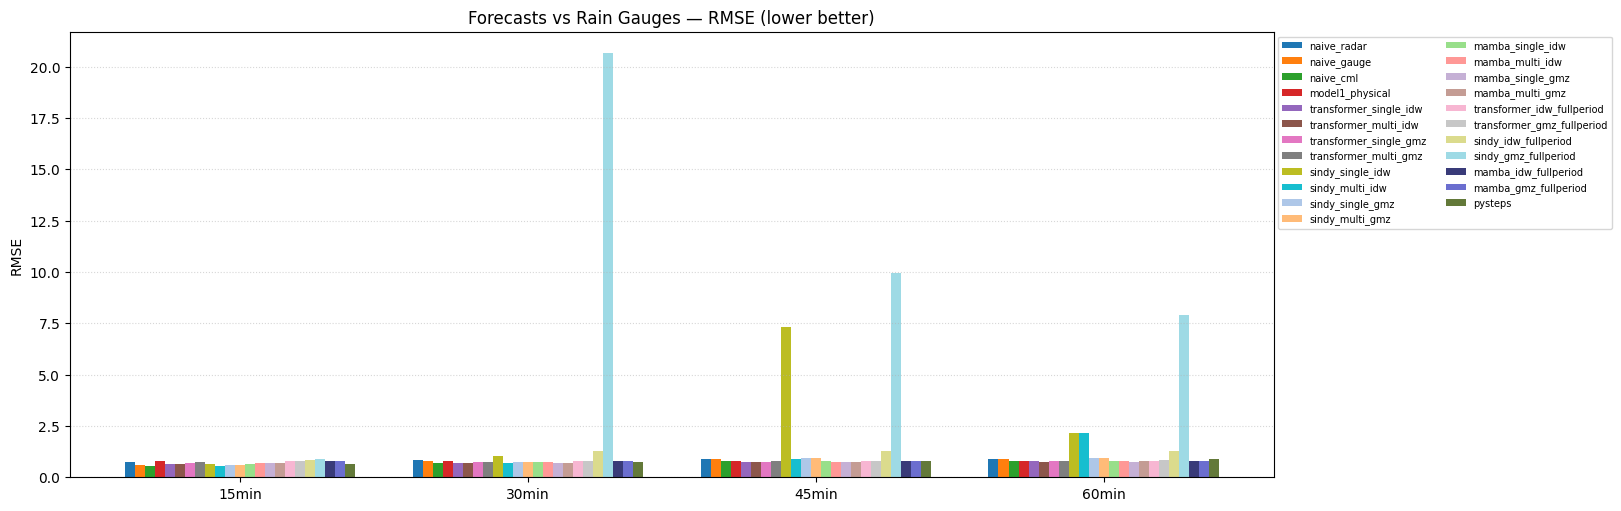


TOP 3 MODELS — RMSE (lower is better):
  h=15min:
    1. naive_cml                      RMSE=0.5383
    2. sindy_multi_idw                RMSE=0.5443
    3. naive_gauge                    RMSE=0.5999
  h=30min:
    1. naive_cml                      RMSE=0.6726
    2. transformer_multi_idw          RMSE=0.6940
    3. transformer_single_idw         RMSE=0.6969
  h=45min:
    1. transformer_multi_idw          RMSE=0.7258
    2. mamba_single_gmz               RMSE=0.7448
    3. transformer_single_idw         RMSE=0.7541
  h=60min:
    1. transformer_multi_idw          RMSE=0.7447
    2. mamba_single_gmz               RMSE=0.7669
    3. mamba_multi_gmz                RMSE=0.7705



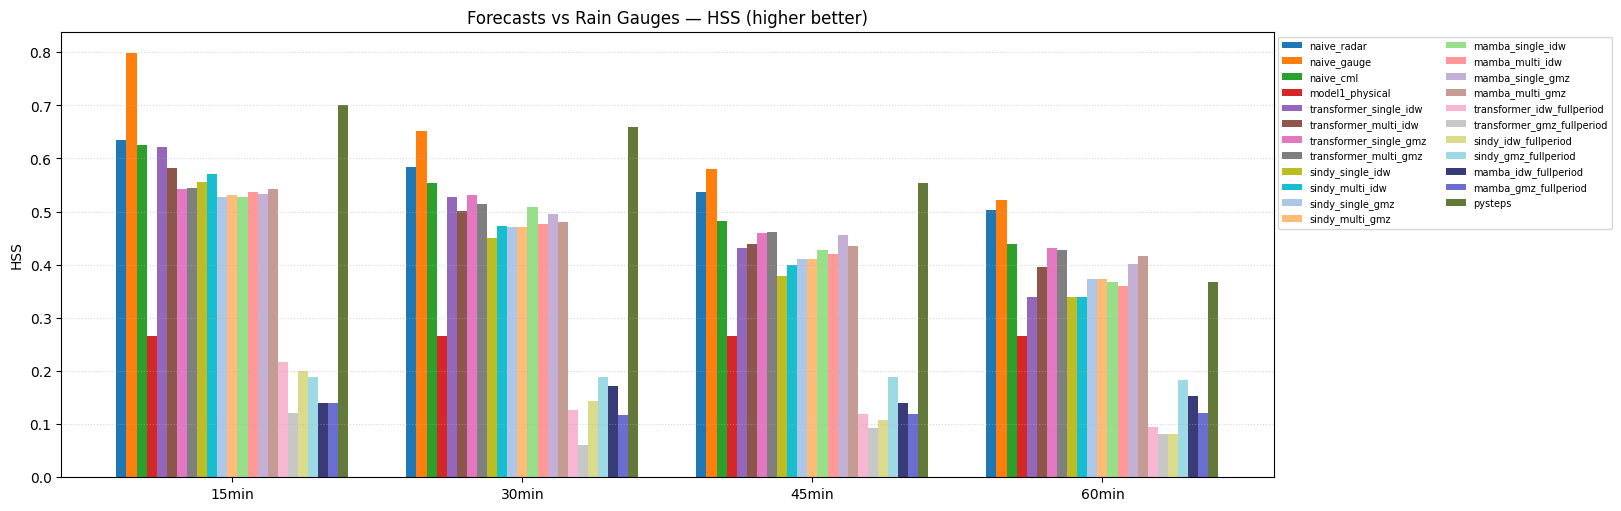


TOP 3 MODELS — HSS (higher is better):
  h=15min:
    1. naive_gauge                    HSS=0.7988
    2. pysteps                        HSS=0.7010
    3. naive_radar                    HSS=0.6353
  h=30min:
    1. pysteps                        HSS=0.6596
    2. naive_gauge                    HSS=0.6509
    3. naive_radar                    HSS=0.5843
  h=45min:
    1. naive_gauge                    HSS=0.5803
    2. pysteps                        HSS=0.5534
    3. naive_radar                    HSS=0.5376
  h=60min:
    1. naive_gauge                    HSS=0.5213
    2. naive_radar                    HSS=0.5038
    3. naive_cml                      HSS=0.4387



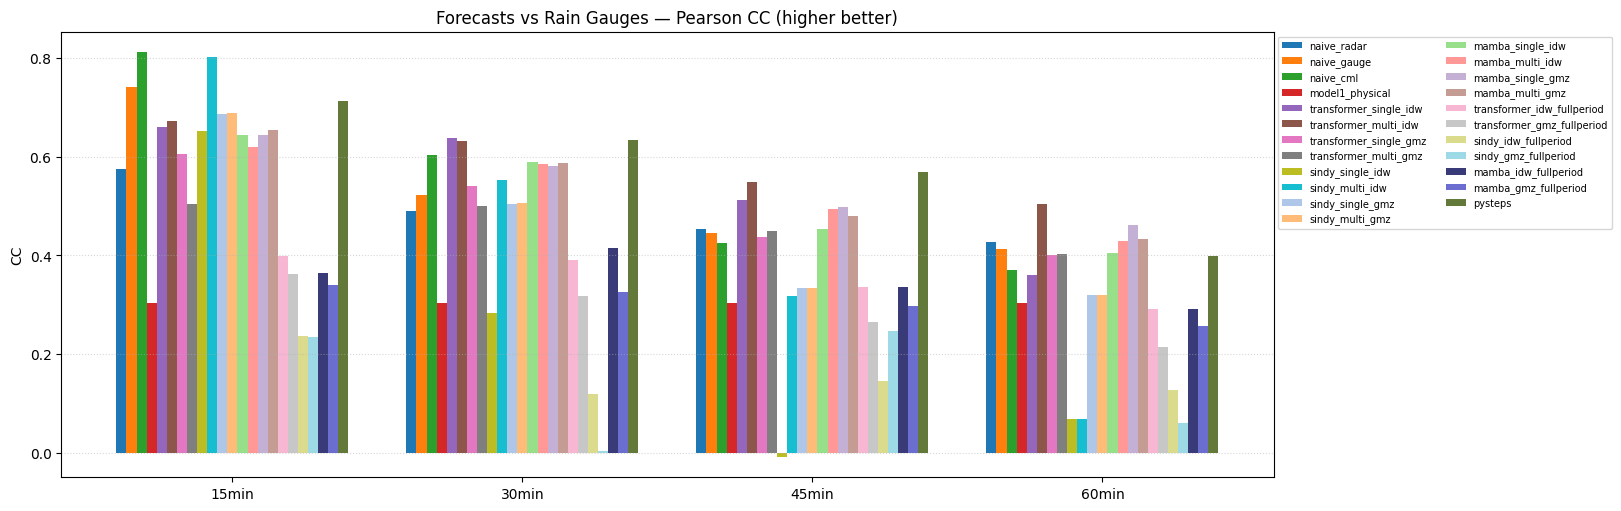


TOP 3 MODELS — CC (higher is better):
  h=15min:
    1. naive_cml                      CC=0.8121
    2. sindy_multi_idw                CC=0.8011
    3. naive_gauge                    CC=0.7414
  h=30min:
    1. transformer_single_idw         CC=0.6387
    2. pysteps                        CC=0.6342
    3. transformer_multi_idw          CC=0.6321
  h=45min:
    1. pysteps                        CC=0.5688
    2. transformer_multi_idw          CC=0.5489
    3. transformer_single_idw         CC=0.5130
  h=60min:
    1. transformer_multi_idw          CC=0.5050
    2. mamba_single_gmz               CC=0.4620
    3. mamba_multi_gmz                CC=0.4326



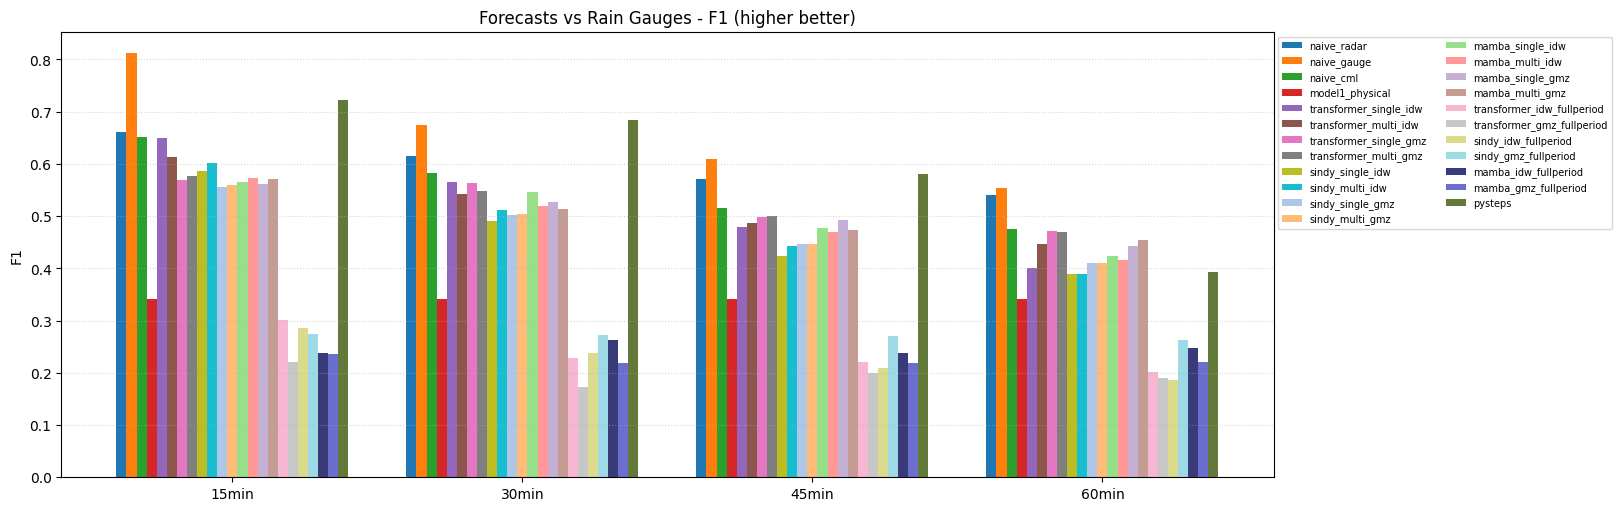


TOP 3 MODELS — F1 (higher is better):
  h=15min:
    1. naive_gauge                    F1=0.8126
    2. pysteps                        F1=0.7226
    3. naive_radar                    F1=0.6620
  h=30min:
    1. pysteps                        F1=0.6836
    2. naive_gauge                    F1=0.6749
    3. naive_radar                    F1=0.6147
  h=45min:
    1. naive_gauge                    F1=0.6091
    2. pysteps                        F1=0.5806
    3. naive_radar                    F1=0.5713
  h=60min:
    1. naive_gauge                    F1=0.5541
    2. naive_radar                    F1=0.5400
    3. naive_cml                      F1=0.4759



In [ ]:
def _spaced_colors(n):
    """Pick n maximally distinct colors with no adjacent neighbors similar."""
    # tab20 gives 20 discrete colors; interleave even/odd indices for max contrast.
    base20 = plt.get_cmap("tab20")(np.linspace(0, 1, 20))
    idx20 = list(range(0, 20, 2)) + list(range(1, 20, 2))
    palette = base20[idx20]
    if n > 20:
        # Extend with tab20b + tab20c (40 more discrete categorical colors).
        base_b = plt.get_cmap("tab20b")(np.linspace(0, 1, 20))
        base_c = plt.get_cmap("tab20c")(np.linspace(0, 1, 20))
        palette = np.vstack([palette, base_b[idx20], base_c[idx20]])
    if n > len(palette):
        # Last-resort fallback for huge model counts: dense HSV ramp.
        palette = plt.get_cmap("hsv")(np.linspace(0, 1, n, endpoint=False))
    return palette[:n]

def plot_metric_bars(df, metric, title, ascending_is_better=True, top_k=3):
    models = list(df["model"].unique())
    horizons = sorted(df["horizon_min"].unique())
    n_m = len(models)
    width = 0.8 / n_m
    colors = _spaced_colors(n_m)

    fig, ax = plt.subplots(figsize=(max(12, n_m * 0.7), 5), constrained_layout=True)
    for i, mdl in enumerate(models):
        vals = []
        for h in horizons:
            row = df[(df["model"] == mdl) & (df["horizon_min"] == h)]
            vals.append(float(row[metric].iloc[0]) if len(row) else np.nan)
        xs = np.arange(len(horizons)) + i * width
        ax.bar(xs, vals, width=width, label=mdl, color=colors[i])
    ax.set_xticks(np.arange(len(horizons)) + width * (n_m - 1) / 2)
    ax.set_xticklabels([f"{h}min" for h in horizons])
    ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=7, ncol=2, bbox_to_anchor=(1.0, 1.0))
    ax.grid(axis="y", ls=":", alpha=0.5)
    plt.show()

    # Top-3 per horizon
    print(f"\nTOP {top_k} MODELS — {metric} ({'lower' if ascending_is_better else 'higher'} is better):")
    for h in horizons:
        sub = df[df["horizon_min"] == h][["model", metric]].dropna()
        sub = sub.sort_values(metric, ascending=ascending_is_better).head(top_k)
        print(f"  h={h}min:")
        for rank, (_, r) in enumerate(sub.iterrows(), 1):
            print(f"    {rank}. {r['model']:<30s} {metric}={r[metric]:.4f}")
    print()

plot_metric_bars(df_gauge, "RMSE", "Forecasts vs Rain Gauges — RMSE (lower better)", True)
plot_metric_bars(df_gauge, "HSS",  "Forecasts vs Rain Gauges — HSS (higher better)", False)
plot_metric_bars(df_gauge, "CC",   "Forecasts vs Rain Gauges — Pearson CC (higher better)", False)
plot_metric_bars(df_gauge, "F1",   "Forecasts vs Rain Gauges - F1 (higher better)", False)


## Part 6.6 — Bar charts vs radar (same 3 metrics)

Identical structure to Part 6.5 but using `df_radar`.

**Inputs:** `df_radar`.
**Outputs:** 3 figures + top-3 lists.


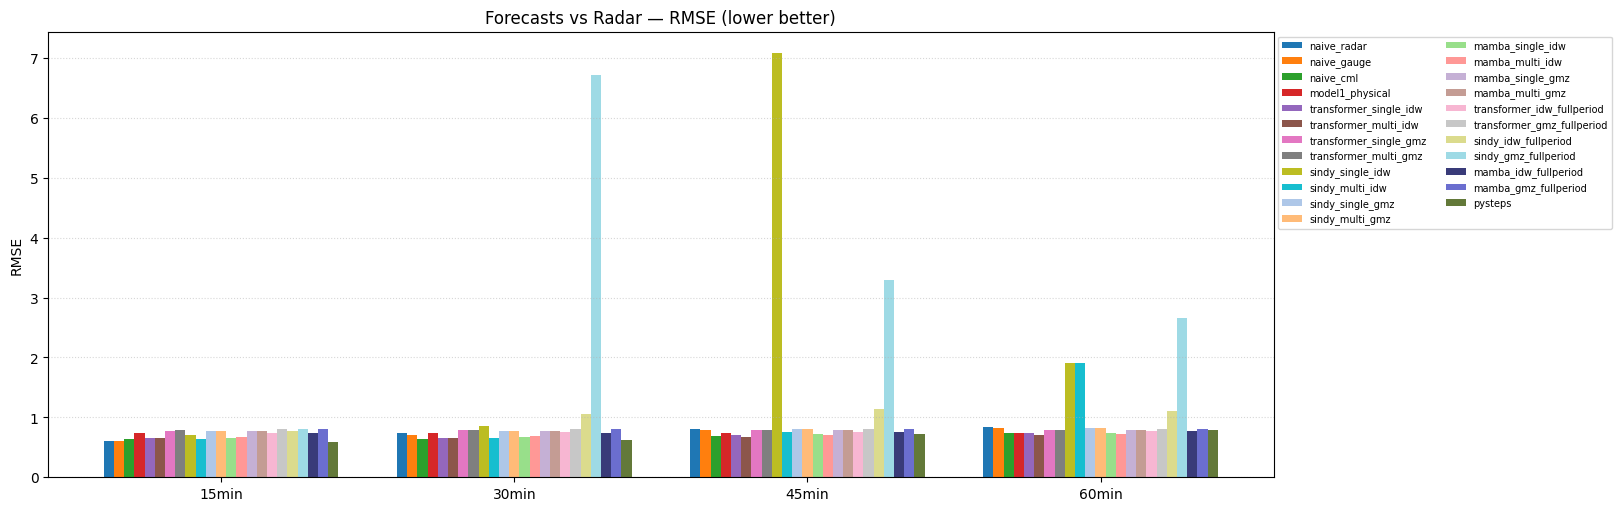


TOP 3 MODELS — RMSE (lower is better):
  h=15min:
    1. pysteps                        RMSE=0.5849
    2. naive_gauge                    RMSE=0.6082
    3. naive_radar                    RMSE=0.6134
  h=30min:
    1. pysteps                        RMSE=0.6270
    2. naive_cml                      RMSE=0.6374
    3. transformer_multi_idw          RMSE=0.6549
  h=45min:
    1. transformer_multi_idw          RMSE=0.6786
    2. naive_cml                      RMSE=0.6967
    3. mamba_multi_idw                RMSE=0.7039
  h=60min:
    1. transformer_multi_idw          RMSE=0.7030
    2. mamba_multi_idw                RMSE=0.7205
    3. naive_cml                      RMSE=0.7327



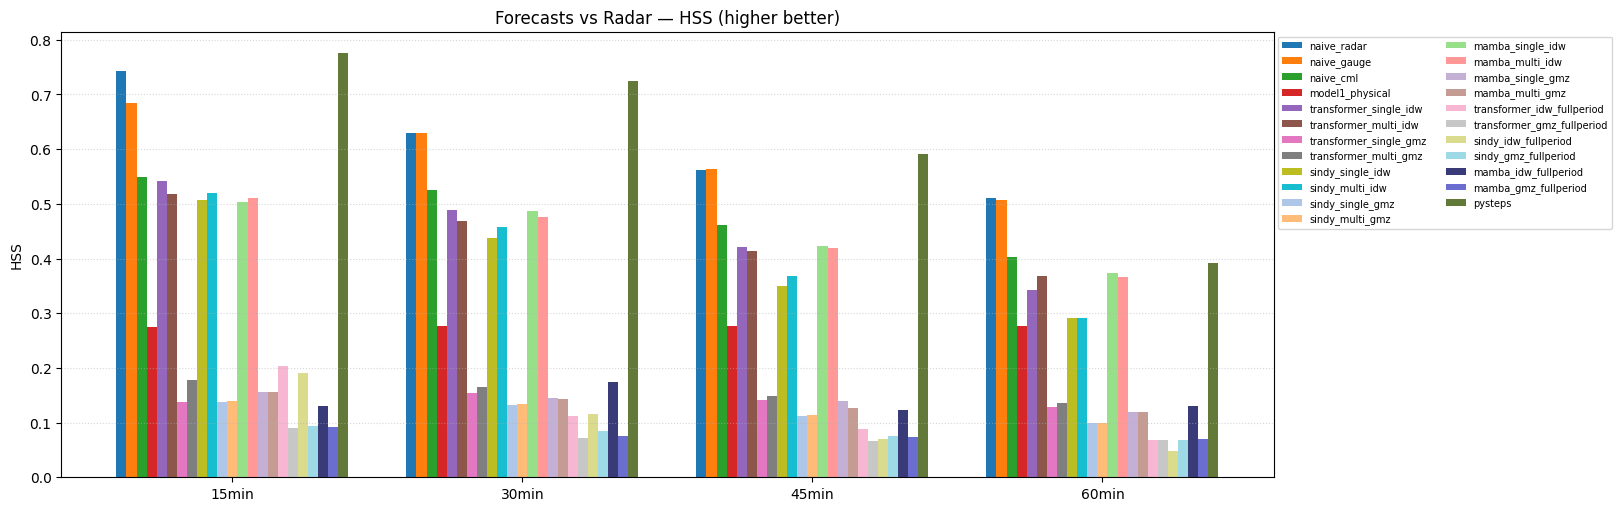


TOP 3 MODELS — HSS (higher is better):
  h=15min:
    1. pysteps                        HSS=0.7760
    2. naive_radar                    HSS=0.7420
    3. naive_gauge                    HSS=0.6836
  h=30min:
    1. pysteps                        HSS=0.7239
    2. naive_gauge                    HSS=0.6302
    3. naive_radar                    HSS=0.6291
  h=45min:
    1. pysteps                        HSS=0.5903
    2. naive_gauge                    HSS=0.5642
    3. naive_radar                    HSS=0.5611
  h=60min:
    1. naive_radar                    HSS=0.5112
    2. naive_gauge                    HSS=0.5070
    3. naive_cml                      HSS=0.4021



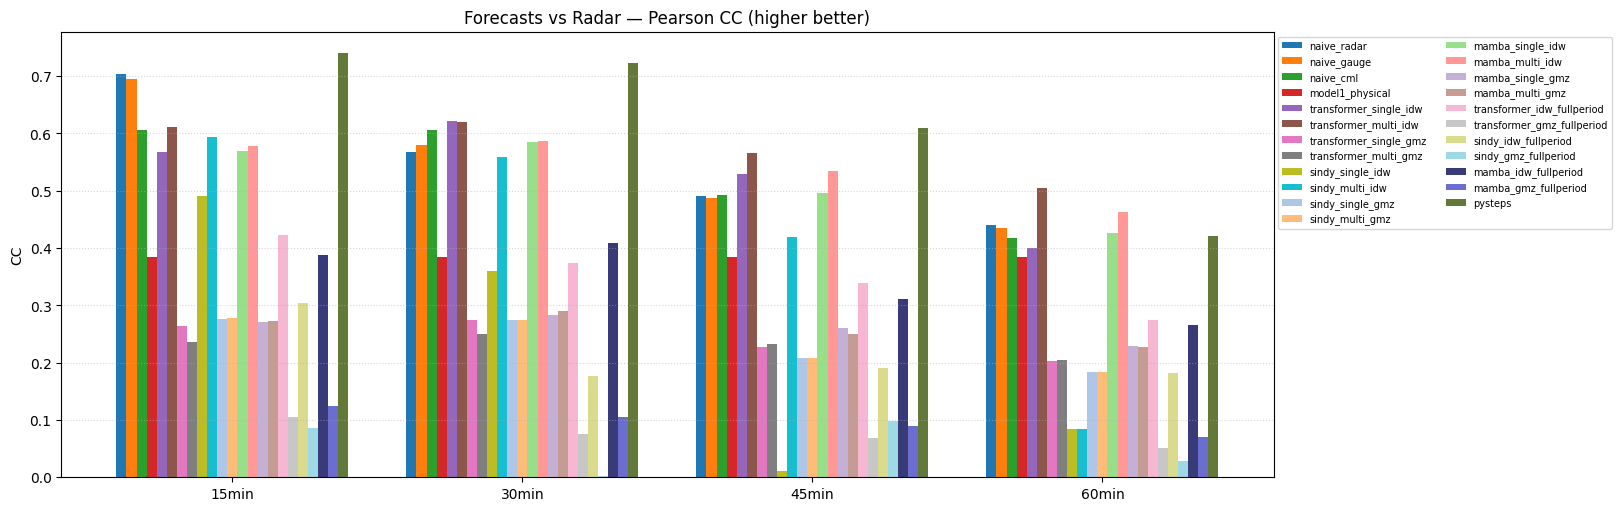


TOP 3 MODELS — CC (higher is better):
  h=15min:
    1. pysteps                        CC=0.7406
    2. naive_radar                    CC=0.7033
    3. naive_gauge                    CC=0.6943
  h=30min:
    1. pysteps                        CC=0.7230
    2. transformer_single_idw         CC=0.6210
    3. transformer_multi_idw          CC=0.6193
  h=45min:
    1. pysteps                        CC=0.6099
    2. transformer_multi_idw          CC=0.5650
    3. mamba_multi_idw                CC=0.5344
  h=60min:
    1. transformer_multi_idw          CC=0.5042
    2. mamba_multi_idw                CC=0.4636
    3. naive_radar                    CC=0.4405



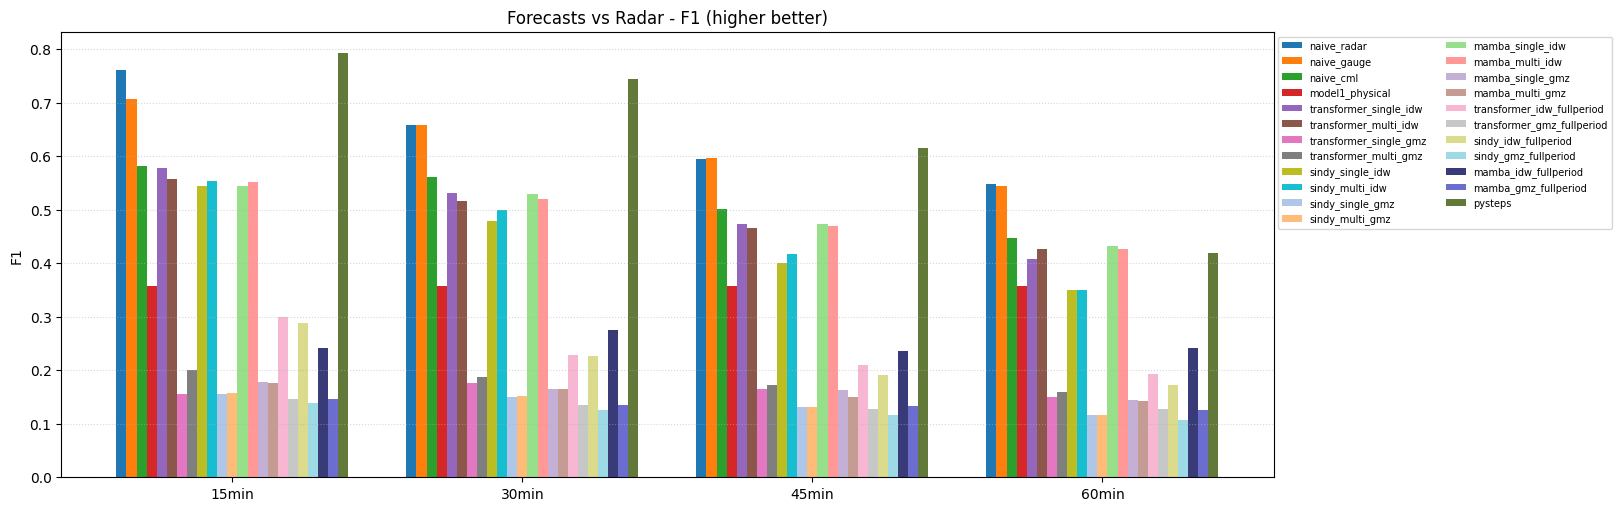


TOP 3 MODELS — F1 (higher is better):
  h=15min:
    1. pysteps                        F1=0.7933
    2. naive_radar                    F1=0.7621
    3. naive_gauge                    F1=0.7078
  h=30min:
    1. pysteps                        F1=0.7441
    2. naive_gauge                    F1=0.6586
    3. naive_radar                    F1=0.6580
  h=45min:
    1. pysteps                        F1=0.6154
    2. naive_gauge                    F1=0.5975
    3. naive_radar                    F1=0.5952
  h=60min:
    1. naive_radar                    F1=0.5491
    2. naive_gauge                    F1=0.5446
    3. naive_cml                      F1=0.4465



In [ ]:
plot_metric_bars(df_radar, "RMSE", "Forecasts vs Radar — RMSE (lower better)", True)
plot_metric_bars(df_radar, "HSS",  "Forecasts vs Radar — HSS (higher better)", False)
plot_metric_bars(df_radar, "CC",   "Forecasts vs Radar — Pearson CC (higher better)", False)
plot_metric_bars(df_radar, "F1",   "Forecasts vs Radar - F1 (higher better)", False)


## Part 6.7 — Focused comparison: best CML-based vs pySTEPS

Reduce the chart to the operational story:

* `naive_cml`, `naive_radar`
* Top-3 advanced models trained on **IDW**
* Top-3 advanced models trained on **GMZ**
* `pysteps` (operational radar benchmark)

For h ∈ {15,30,45,60}, two metrics: RMSE and HSS vs gauges.

**Inputs:** `df_gauge`.
**Outputs:** 2 figures + ranking table.


Focused model set: ['naive_radar', 'naive_cml', 'transformer_single_idw', 'transformer_multi_idw', 'mamba_single_idw', 'transformer_single_gmz', 'transformer_multi_gmz', 'mamba_single_gmz', 'pysteps']



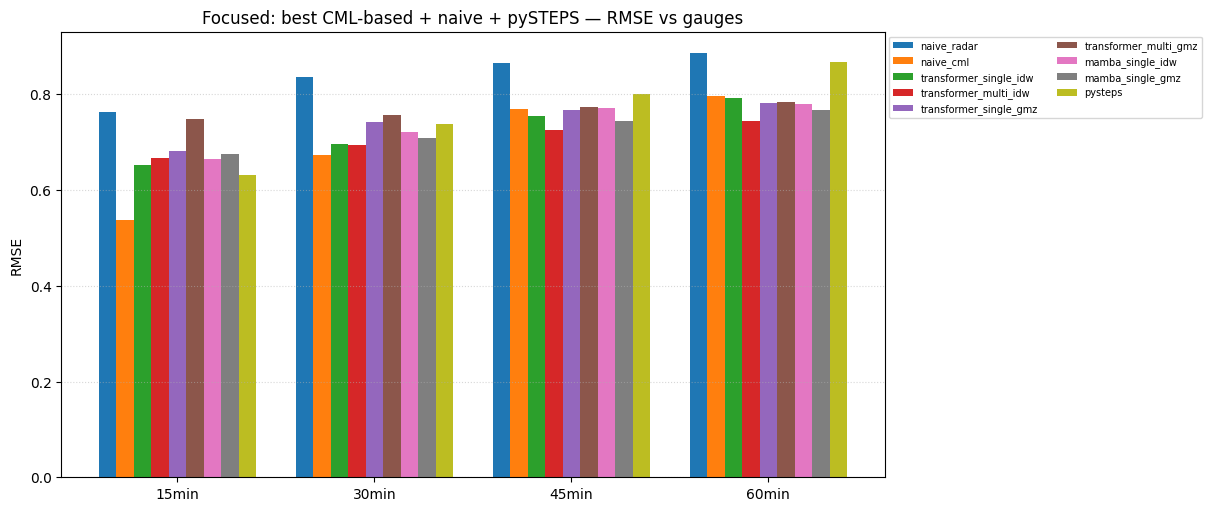


TOP 3 MODELS — RMSE (lower is better):
  h=15min:
    1. naive_cml                      RMSE=0.5383
    2. pysteps                        RMSE=0.6308
    3. transformer_single_idw         RMSE=0.6516
  h=30min:
    1. naive_cml                      RMSE=0.6726
    2. transformer_multi_idw          RMSE=0.6940
    3. transformer_single_idw         RMSE=0.6969
  h=45min:
    1. transformer_multi_idw          RMSE=0.7258
    2. mamba_single_gmz               RMSE=0.7448
    3. transformer_single_idw         RMSE=0.7541
  h=60min:
    1. transformer_multi_idw          RMSE=0.7447
    2. mamba_single_gmz               RMSE=0.7669
    3. mamba_single_idw               RMSE=0.7796



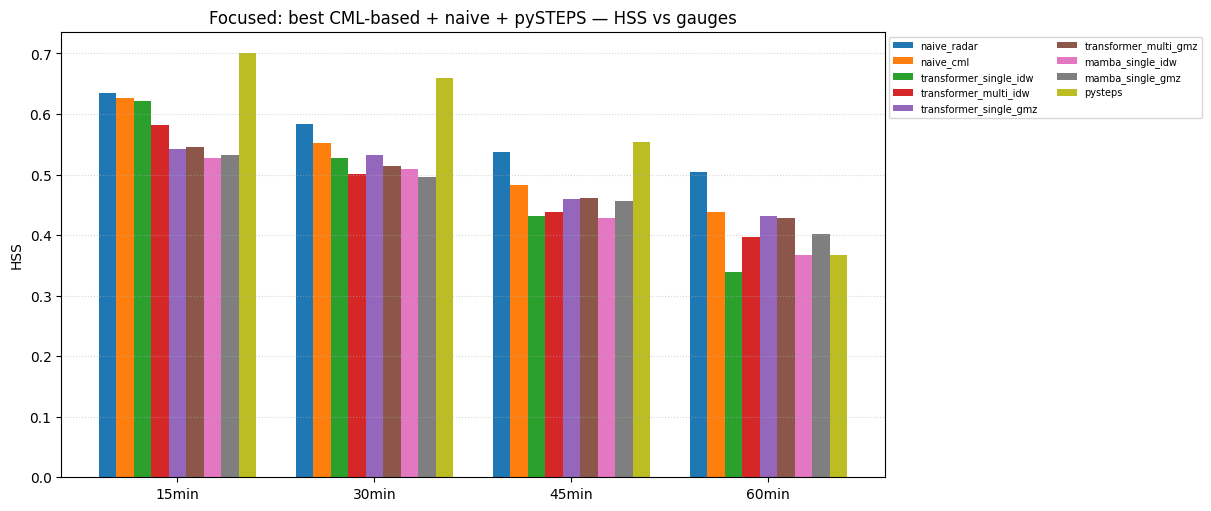


TOP 3 MODELS — HSS (higher is better):
  h=15min:
    1. pysteps                        HSS=0.7010
    2. naive_radar                    HSS=0.6353
    3. naive_cml                      HSS=0.6260
  h=30min:
    1. pysteps                        HSS=0.6596
    2. naive_radar                    HSS=0.5843
    3. naive_cml                      HSS=0.5530
  h=45min:
    1. pysteps                        HSS=0.5534
    2. naive_radar                    HSS=0.5376
    3. naive_cml                      HSS=0.4821
  h=60min:
    1. naive_radar                    HSS=0.5038
    2. naive_cml                      HSS=0.4387
    3. transformer_single_gmz         HSS=0.4321

RANKING (avg over horizons, vs gauges):
                         RMSE    HSS     CC     F1
model                                             
pysteps                0.7592 0.5702 0.5786 0.5951
naive_radar            0.8382 0.5652 0.4869 0.5970
naive_cml              0.6940 0.5249 0.5531 0.5564
transformer_single_gmz 0.7435 0.

In [ ]:
# Identify top-3 IDW-trained and top-3 GMZ-trained models from df_gauge
def topk_by_substring(df, substring, metric="HSS", k=3, ascending=False):
    sub = df[df["model"].str.contains(substring)]
    if sub.empty: return []
    avg = sub.groupby("model")[metric].mean().reset_index()
    avg = avg.sort_values(metric, ascending=ascending).head(k)
    return list(avg["model"])

top_idw = topk_by_substring(df_gauge, "_idw", metric="HSS", k=3, ascending=False)
top_gmz = topk_by_substring(df_gauge, "_gmz", metric="HSS", k=3, ascending=False)
focus_models = ["naive_radar", "naive_cml"] + top_idw + top_gmz + ["pysteps"]
focus_models = [m for m in focus_models if m in df_gauge["model"].unique()]
print(f"Focused model set: {focus_models}\n")

df_focus = df_gauge[df_gauge["model"].isin(focus_models)].copy()
plot_metric_bars(df_focus, "RMSE",
                  "Focused: best CML-based + naive + pySTEPS — RMSE vs gauges", True)
plot_metric_bars(df_focus, "HSS",
                  "Focused: best CML-based + naive + pySTEPS — HSS vs gauges", False)

# Ranking table
print("RANKING (avg over horizons, vs gauges):")
print(df_focus.groupby("model")[["RMSE","HSS","CC","F1"]].mean()
      .sort_values("HSS", ascending=False).to_string(float_format="{:.4f}".format))

## Part 6.8 — Peak-event visualization (30-min horizon)

Pick the test-window frame with the highest spatially-averaged radar
rain rate. Plot a grid of subplots — one per model — for the 30-min
horizon. Same color scale, gauge and CML markers overlaid.

**Inputs:** `MODEL_REGISTRY`, `radar_15`, gauge/CML coords.
**Outputs:** large grid figure.


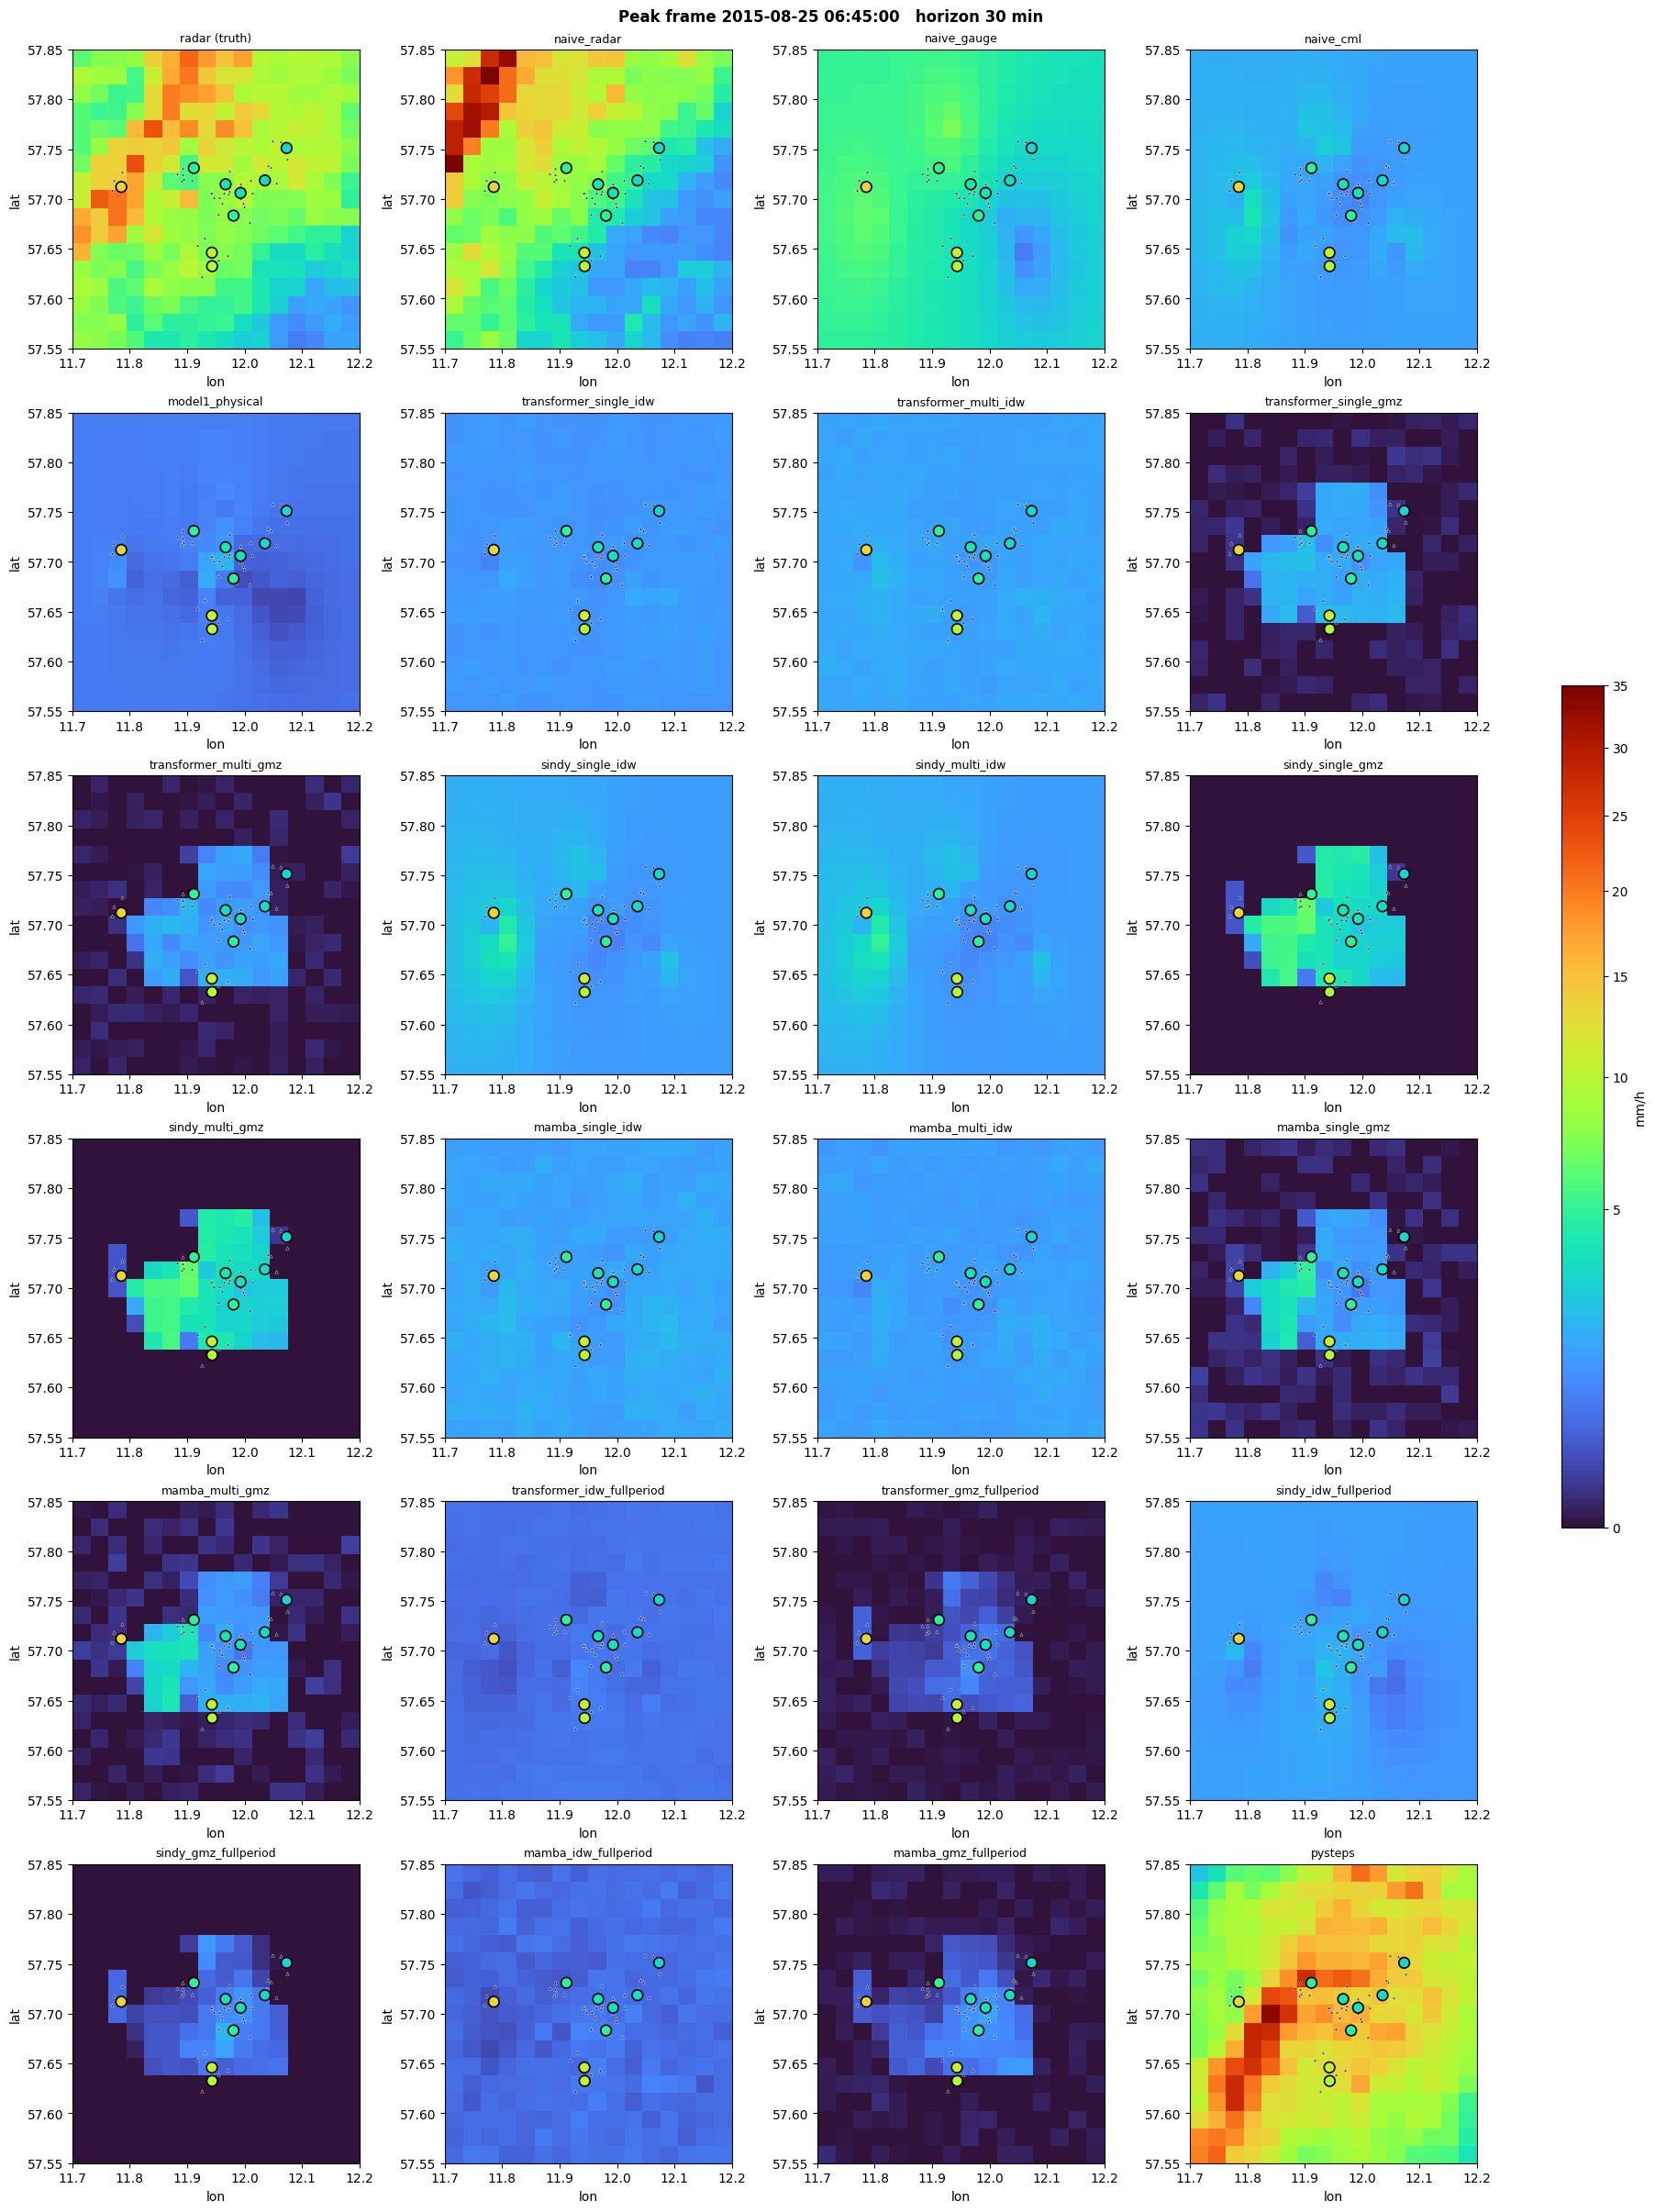

In [ ]:
H_VIZ = 30
h_step_viz = H_VIZ // 15
peak_local_v = int(np.argmax(test_means))
peak_global_v = TEST_LO + peak_local_v
i_pred = peak_local_v - LOOKBACK_WINDOW - h_step_viz + 1
if i_pred < 0:
    i_pred = 0
    peak_global_v = TEST_LO + LOOKBACK_WINDOW + h_step_viz - 1

panels = [("radar (truth)", crop_field(radar_15)[peak_global_v])]
for mname, mdict in MODEL_REGISTRY.items():
    if H_VIZ not in mdict or mdict[H_VIZ] is None: continue
    pred = mdict[H_VIZ]
    if i_pred < pred.shape[0]:
        panels.append((mname, crop_field(pred[i_pred])))

n = len(panels)
cols = 4
rows_grid = math.ceil(n / cols)
fig, axes = plt.subplots(rows_grid, cols, figsize=(4.5*cols, 4*rows_grid), constrained_layout=True)
axes = np.atleast_2d(axes)
# Fixed non-linear colour scale: gamma=0.5 stretches the low end,
# all values above 35 mm/h saturate to the same top colour.
vmax = 35.0
norm = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)
# Gauge readings at the peak time, for overlay (rendered on every panel)
g_vals_peak = gauge_values_at_time(peak_global_v)
for ax, (name, m) in zip(axes.ravel(), panels):
    im = ax.imshow(m, cmap="turbo", norm=norm, origin="lower",
                   extent=[LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]],
                   aspect="auto")
    # Gauges — color encodes actual rain rate at this time, same cmap as field
    overlay_gauges_on_map(ax, gauge_lons, gauge_lats, g_vals_peak,
                           norm=norm, cmap="turbo", size=70)
    # CML midpoint markers (sparse, just for context)
    ax.scatter(link_lons[::5], link_lats[::5], s=6, marker="^",
                facecolors="black", edgecolors="white", linewidths=0.4, alpha=0.7)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
fig.suptitle(f"Peak frame {radar_times[peak_global_v]}   horizon {H_VIZ} min",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=axes, fraction=0.03, label="mm/h")
plt.show()

## Part 6.9 - Single-file evaluation report (Markdown + JSON + CSV)

Bundles every quantitative result of Part 6 into **one self-contained
Markdown report** at `PROCESSED_DIR/evaluation_report.md`, suitable for
archiving, sharing, and discussing the results.

Also writes the same data in machine-readable form:
* `evaluation_report.json` - configuration + sweep best configs + every
  metric, model, and horizon.
* `metrics_vs_gauges.csv`, `metrics_vs_radar.csv` - the dataframes.
* `evaluation_report.zip` - all of the above in a single archive.

**Inputs:** `df_gauge`, `df_radar`, `MODEL_REGISTRY`, sweep JSONs, `lb_results`.
**Outputs:** five files (`.md`, `.json`, two `.csv`, `.zip`).


In [ ]:
import zipfile, datetime

REPORT_MD   = os.path.join(PROCESSED_DIR, "evaluation_report.md")
REPORT_JSON = os.path.join(PROCESSED_DIR, "evaluation_report.json")
REPORT_GCSV = os.path.join(PROCESSED_DIR, "metrics_vs_gauges.csv")
REPORT_RCSV = os.path.join(PROCESSED_DIR, "metrics_vs_radar.csv")
REPORT_ZIP  = os.path.join(PROCESSED_DIR, "evaluation_report.zip")

# --- 1. Save CSVs --------------------------------------------------------
df_gauge.to_csv(REPORT_GCSV, index=False)
df_radar.to_csv(REPORT_RCSV, index=False)

# --- 2. Build the JSON blob ---------------------------------------------
def _safe_json_load(p):
    if not exists(p): return None
    try:
        with open(p) as f: return _json.load(f)
    except Exception: return None

sweep_best = {
    "transformer":    _safe_json_load(TF_BEST_PATH),
    "mamba":          _safe_json_load(MB_BEST_PATH),
    "sindy_n_modes":  _safe_json_load(SINDY_BEST_PATH),
}
lookback_probe = _safe_json_load(LOOKBACK_PROBE_PATH)

config_snapshot = {
    "splits": {nm: {"start": sl.start, "stop": sl.stop} for nm, sl in splits_cfg.items()},
    "LOOKBACK_WINDOW":    LOOKBACK_WINDOW,
    "HORIZONS_MIN":       HORIZONS_MIN,
    "THRESHOLD_WET":      THRESHOLD_WET,
    "WINDOW_SIZE":        WINDOW_SIZE,
    "RNN_N_FEATURES":     RNN_N_FEATURES,
    "FINAL_EPOCHS_EST":   FINAL_EPOCHS_EST,
    "REGION_OF_INTEREST": REGION_OF_INTEREST,
    "POINT_PER_LINK":     POINT_PER_LINK,
    "SPATIAL_SHAPE":      list(SPATIAL_SHAPE),
    "CROP_LAT":           list(LAT_RANGE),
    "CROP_LON":           list(LON_RANGE),
    "EVAL_LEN":           int(EVAL_LEN),
    "n_gauges":           int(len(gauges_info)),
    "n_cmls":             int(len(links)),
}

def _topk_per_h(df, metric, ascending, k=5):
    out = {}
    for h in sorted(df["horizon_min"].unique()):
        sub = df[df["horizon_min"] == h][["model", metric]].dropna()
        sub = sub.sort_values(metric, ascending=ascending).head(k)
        out[int(h)] = [{"model": r["model"], metric: float(r[metric])} for _, r in sub.iterrows()]
    return out

TOPK_K = 5
topk = {
    "vs_gauges": {
        "RMSE": _topk_per_h(df_gauge, "RMSE", True,  TOPK_K),
        "MAE":  _topk_per_h(df_gauge, "MAE",  True,  TOPK_K),
        "HSS":  _topk_per_h(df_gauge, "HSS",  False, TOPK_K),
        "F1":   _topk_per_h(df_gauge, "F1",   False, TOPK_K),
        "CC":   _topk_per_h(df_gauge, "CC",   False, TOPK_K),
    },
    "vs_radar": {
        "RMSE": _topk_per_h(df_radar, "RMSE", True,  TOPK_K),
        "MAE":  _topk_per_h(df_radar, "MAE",  True,  TOPK_K),
        "HSS":  _topk_per_h(df_radar, "HSS",  False, TOPK_K),
        "F1":   _topk_per_h(df_radar, "F1",   False, TOPK_K),
        "CC":   _topk_per_h(df_radar, "CC",   False, TOPK_K),
    },
}

report_json = {
    "generated_at_utc":  datetime.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "notebook":          "advanced_models_colab_v2.ipynb",
    "config":            config_snapshot,
    "sweep_best":        sweep_best,
    "lookback_probe":    lookback_probe,
    "models_evaluated":  sorted(df_gauge["model"].unique().tolist()),
    "metrics_vs_gauges": df_gauge.to_dict(orient="records"),
    "metrics_vs_radar":  df_radar.to_dict(orient="records"),
    "topk":              topk,
}
with open(REPORT_JSON, "w") as f:
    _json.dump(report_json, f, indent=2, default=str)

# --- 3. Build the human-readable Markdown report ------------------------
def _df_to_md(df, cols=None, float_fmt="{:.4f}"):
    if df.empty: return "_(no rows)_\n"
    cols = cols or list(df.columns)
    lines = ["| " + " | ".join(cols) + " |"]
    lines.append("|" + "|".join(["---"] * len(cols)) + "|")
    for _, r in df.iterrows():
        cells = []
        for c in cols:
            v = r[c]
            if isinstance(v, float):
                cells.append("nan" if np.isnan(v) else float_fmt.format(v))
            else:
                cells.append(str(v))
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines) + "\n"

METRIC_COLS = ["model","horizon_min","RMSE","MAE","Bias","CC","HSS","F1","Precision","Recall","n_wet_true","n_wet_pred"]
present_cols_g = [c for c in METRIC_COLS if c in df_gauge.columns]
present_cols_r = [c for c in METRIC_COLS if c in df_radar.columns]

def _topk_md(topk_block):
    out = []
    for metric, per_h in topk_block.items():
        out.append(f"\n### Top-{TOPK_K} by {metric}\n")
        for h, rows in per_h.items():
            out.append(f"\n**Horizon {h} min**\n")
            out.append("| Rank | Model | " + metric + " |")
            out.append("|---|---|---|")
            for i, r in enumerate(rows, 1):
                v = r[metric]
                vs = "nan" if (isinstance(v, float) and np.isnan(v)) else f"{v:.4f}"
                out.append(f"| {i} | {r['model']} | {vs} |")
            out.append("")
    return "\n".join(out)

md_parts = []
md_parts.append("# FieldSense - Evaluation Report")
md_parts.append(f"\n*Generated {report_json['generated_at_utc']} from `advanced_models_colab_v2.ipynb`.*")
md_parts.append("\n## 1. Configuration")
md_parts.append("```json")
md_parts.append(_json.dumps(config_snapshot, indent=2))
md_parts.append("```")
md_parts.append("\n## 2. Best sweep configurations (W&B-tuned)")
md_parts.append("```json")
md_parts.append(_json.dumps(sweep_best, indent=2))
md_parts.append("```")
md_parts.append("\n## 3. Lookback probe results")
md_parts.append("```json")
md_parts.append(_json.dumps(lookback_probe, indent=2))
md_parts.append("```")
md_parts.append("\n## 4. Models evaluated")
md_parts.append("")
for m in report_json["models_evaluated"]:
    md_parts.append(f"- `{m}`")
md_parts.append("\n## 5. Metrics vs rain gauges (gold standard)")
md_parts.append(_df_to_md(df_gauge[present_cols_g]))
md_parts.append("\n## 6. Metrics vs SMHI radar (cropped)")
md_parts.append(_df_to_md(df_radar[present_cols_r]))
md_parts.append("\n## 7. Top-K rankings vs gauges")
md_parts.append(_topk_md(topk["vs_gauges"]))
md_parts.append("\n## 8. Top-K rankings vs radar")
md_parts.append(_topk_md(topk["vs_radar"]))

with open(REPORT_MD, "w", encoding="utf-8") as f:
    f.write("\n".join(md_parts))

# --- 4. Zip everything into a single archive ----------------------------
with zipfile.ZipFile(REPORT_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for p in (REPORT_MD, REPORT_JSON, REPORT_GCSV, REPORT_RCSV):
        if exists(p):
            z.write(p, arcname=os.path.basename(p))

for p in (REPORT_MD, REPORT_JSON, REPORT_GCSV, REPORT_RCSV, REPORT_ZIP):
    sz = os.path.getsize(p) / 1024
    print(f"  wrote {p}  ({sz:.1f} KB)")
print("\nOpen the markdown report with any viewer to inspect results.")


/tmp/ipykernel_376/3662058489.py:72: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at_utc":  datetime.datetime.utcnow().isoformat(timespec="seconds") + "Z",


  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report.md  (31.6 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report.json  (95.6 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/metrics_vs_gauges.csv  (16.9 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/metrics_vs_radar.csv  (17.2 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report.zip  (43.7 KB)

Open the markdown report with any viewer to inspect results.


## Part 6.10 - Event snapshots: radar truth vs Transformer (multi)

Three side-by-side event snapshots picked automatically from the test
window: the two highest spatially-averaged radar rainfall frames (at
least 24 h apart, so they come from different events) and the frame
with the highest gauge reading. Each scenario fills one row of a
3 x 5 grid:

* Column 1: SMHI radar field (truth) at time t.
* Columns 2-5: \texttt{transformer\_multi\_idw} prediction for time t,
  issued 15, 30, 45 and 60 minutes earlier.

All panels share a single \textbf{non-linear} colour scale
(\texttt{PowerNorm(gamma=0.5)}, capped at 35 mm/h with \texttt{clip=True})
so that low rain rates are visually emphasised and everything above
35 mm/h saturates to the same top colour. Rain gauges are overlaid as
circles whose fill encodes the actual gauge reading at that time, with
the same colour scale.

**Inputs:** \texttt{MODEL\_REGISTRY}, \texttt{radar\_15}, gauges, crop fns.
**Outputs:** one figure per crop region (Part 8.10 reuses the helper
for the inner crop).


plot_event_snapshots ready.


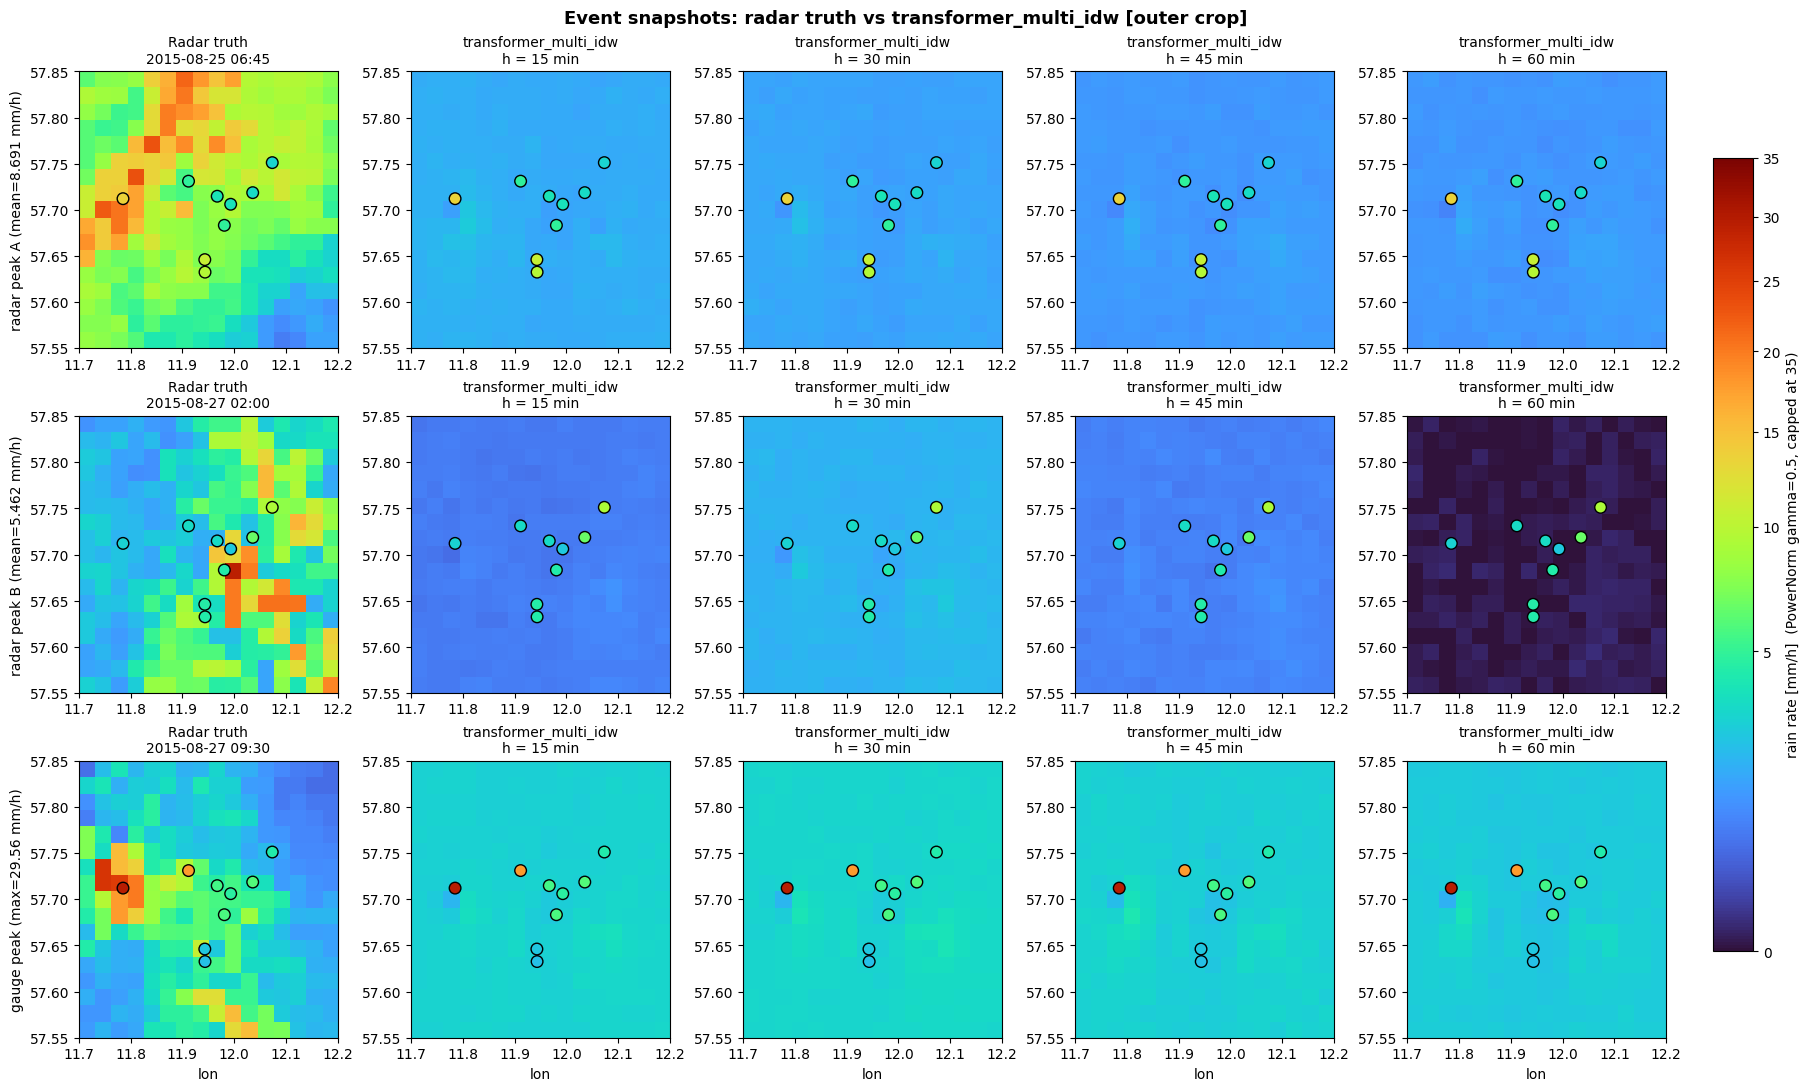

In [ ]:
from matplotlib.colors import PowerNorm

def plot_event_snapshots(crop_fn, lat_range, lon_range,
                          g_lons, g_lats, g_aligned_df,
                          model_key="transformer_multi_idw",
                          peak_separation_h=24, gamma=0.5, vmax_clip=35.0,
                          title_suffix=""):
    """Three-row event-snapshot panel; see Part 6.10 docstring."""
    if model_key not in MODEL_REGISTRY:
        print(f"  {model_key!r} not in MODEL_REGISTRY - skipping snapshot.")
        return None
    for h_min in HORIZONS_MIN:
        if MODEL_REGISTRY[model_key].get(h_min) is None:
            print(f"  {model_key!r} missing horizon {h_min} - skipping snapshot.")
            return None

    T_test = TEST_HI - TEST_LO
    h_max = max(HORIZONS_STEPS)

    # --- Event selection ---
    rad_test = crop_fn(radar_15[TEST_LO:TEST_HI])
    test_mean = rad_test.mean(axis=(1, 2)).astype(np.float64)
    peak1 = int(np.argmax(test_mean))
    excl = peak_separation_h * 4  # 4 frames per hour at 15-min cadence
    masked = test_mean.copy()
    masked[max(0, peak1 - excl):min(T_test, peak1 + excl)] = -np.inf
    peak2 = int(np.argmax(masked))

    has_gauges_in_crop = g_aligned_df.shape[1] > 0
    if has_gauges_in_crop:
        gauge_test = g_aligned_df.values[TEST_LO:TEST_HI]
        gauge_max_per_t = np.nanmax(gauge_test, axis=1)
        peak_g = int(np.argmax(gauge_max_per_t))
        peak_g_val = float(gauge_max_per_t[peak_g])
        gauge_label = f"gauge peak (max={peak_g_val:.2f} mm/h)"
    else:
        # Fall back to a third radar event
        masked2 = masked.copy()
        masked2[max(0, peak2 - excl):min(T_test, peak2 + excl)] = -np.inf
        peak_g = int(np.argmax(masked2))
        gauge_label = "radar peak C (no gauges in crop)"

    scenarios = [
        (f"radar peak A (mean={test_mean[peak1]:.3f} mm/h)", peak1),
        (f"radar peak B (mean={test_mean[peak2]:.3f} mm/h)", peak2),
        (gauge_label,                                        peak_g),
    ]

    # Need enough history for the longest horizon
    valid_lo = LOOKBACK_WINDOW + h_max - 1

    # --- Figure ---
    n_cols = 1 + len(HORIZONS_MIN)
    fig, axes = plt.subplots(len(scenarios), n_cols,
                              figsize=(3.6 * n_cols, 3.6 * len(scenarios)),
                              constrained_layout=True)
    norm = PowerNorm(gamma=gamma, vmin=0.0, vmax=vmax_clip, clip=True)
    cmap = plt.get_cmap("turbo")
    extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]

    for row, (label, local_t) in enumerate(scenarios):
        clamped = max(valid_lo, min(local_t, T_test - 1))
        note = "" if clamped == local_t else " [clamped to valid horizon range]"
        global_t = TEST_LO + clamped
        t_str = pd.Timestamp(radar_times[global_t]).strftime("%Y-%m-%d %H:%M")

        g_vals = g_aligned_df.values[global_t] if has_gauges_in_crop else np.empty(0)
        g_colors = (cmap(norm(np.nan_to_num(g_vals, nan=0.0)))
                    if g_vals.size > 0 else None)

        # Col 0: radar truth
        ax = axes[row, 0]
        truth = crop_fn(radar_15[global_t])
        ax.imshow(truth, cmap=cmap, norm=norm, origin="lower",
                  extent=extent, aspect="auto")
        if g_colors is not None:
            ax.scatter(g_lons, g_lats, s=70, marker="o", c=g_colors,
                       edgecolors="black", linewidths=1.0, zorder=5)
        ax.set_title(f"Radar truth\n{t_str}{note}", fontsize=10)
        ax.set_ylabel(label, fontsize=10)

        # Cols 1..n: transformer_multi predictions at each horizon
        for j, (h_step, h_min) in enumerate(zip(HORIZONS_STEPS, HORIZONS_MIN)):
            ax = axes[row, j + 1]
            pred_idx = clamped - LOOKBACK_WINDOW - h_step + 1
            pred_arr = MODEL_REGISTRY[model_key][h_min]
            if 0 <= pred_idx < pred_arr.shape[0]:
                pred = crop_fn(pred_arr[pred_idx])
                ax.imshow(pred, cmap=cmap, norm=norm, origin="lower",
                          extent=extent, aspect="auto")
                if g_colors is not None:
                    ax.scatter(g_lons, g_lats, s=70, marker="o", c=g_colors,
                               edgecolors="black", linewidths=1.0, zorder=5)
            else:
                ax.text(0.5, 0.5, "out of range",
                         ha="center", va="center", transform=ax.transAxes,
                         fontsize=10)
                ax.set_facecolor("lightgray")
            ax.set_title(f"{model_key}\nh = {h_min} min", fontsize=10)

    for ax in axes[-1, :]:
        ax.set_xlabel("lon")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02,
                 label=f"rain rate [mm/h]  (PowerNorm gamma={gamma}, capped at {vmax_clip:.0f})")
    fig.suptitle(f"Event snapshots: radar truth vs {model_key}{title_suffix}",
                 fontsize=13, fontweight="bold")
    plt.show()
    return scenarios


print("plot_event_snapshots ready.")
event_scenarios_outer = plot_event_snapshots(
    crop_field, LAT_RANGE, LON_RANGE,
    gauge_lons, gauge_lats, gauge_aligned,
    title_suffix=" [outer crop]",
)


## Part 6.11 - Event snapshots: h=60 min multi-model comparison

A second snapshot view of the same three event scenarios used in
Part~6.10, but this time the forecast horizon is fixed at $h=60$ min
(the operational one-hour nowcasting boundary) and the comparison axis
along the columns is the \emph{forecaster}. Each row shows:

\begin{center}
\texttt{Radar (truth)}  $\;|\;$  \texttt{transformer\_multi\_idw}
$\;|\;$ \texttt{sindy\_multi\_idw}
$\;|\;$ \texttt{mamba\_multi\_idw}
$\;|\;$ \texttt{pysteps}
\end{center}

Gauges are overlaid as filled circles whose fill colour encodes the
actual gauge reading at that time, drawn through the same
\texttt{PowerNorm} colour map as the background field so that visual
agreement between the marker and the pixel under it reads directly as
forecast accuracy. All five panels share a single colour scale
(\texttt{PowerNorm(gamma=0.5)}, capped at 35 mm/h).

**Inputs:** \texttt{MODEL\_REGISTRY}, \texttt{radar\_15}, gauges, \texttt{crop\_field}.
**Outputs:** one figure; the helper is reused by Part~8.11 for the inner crop.


plot_h60_multi_model_snapshots ready.


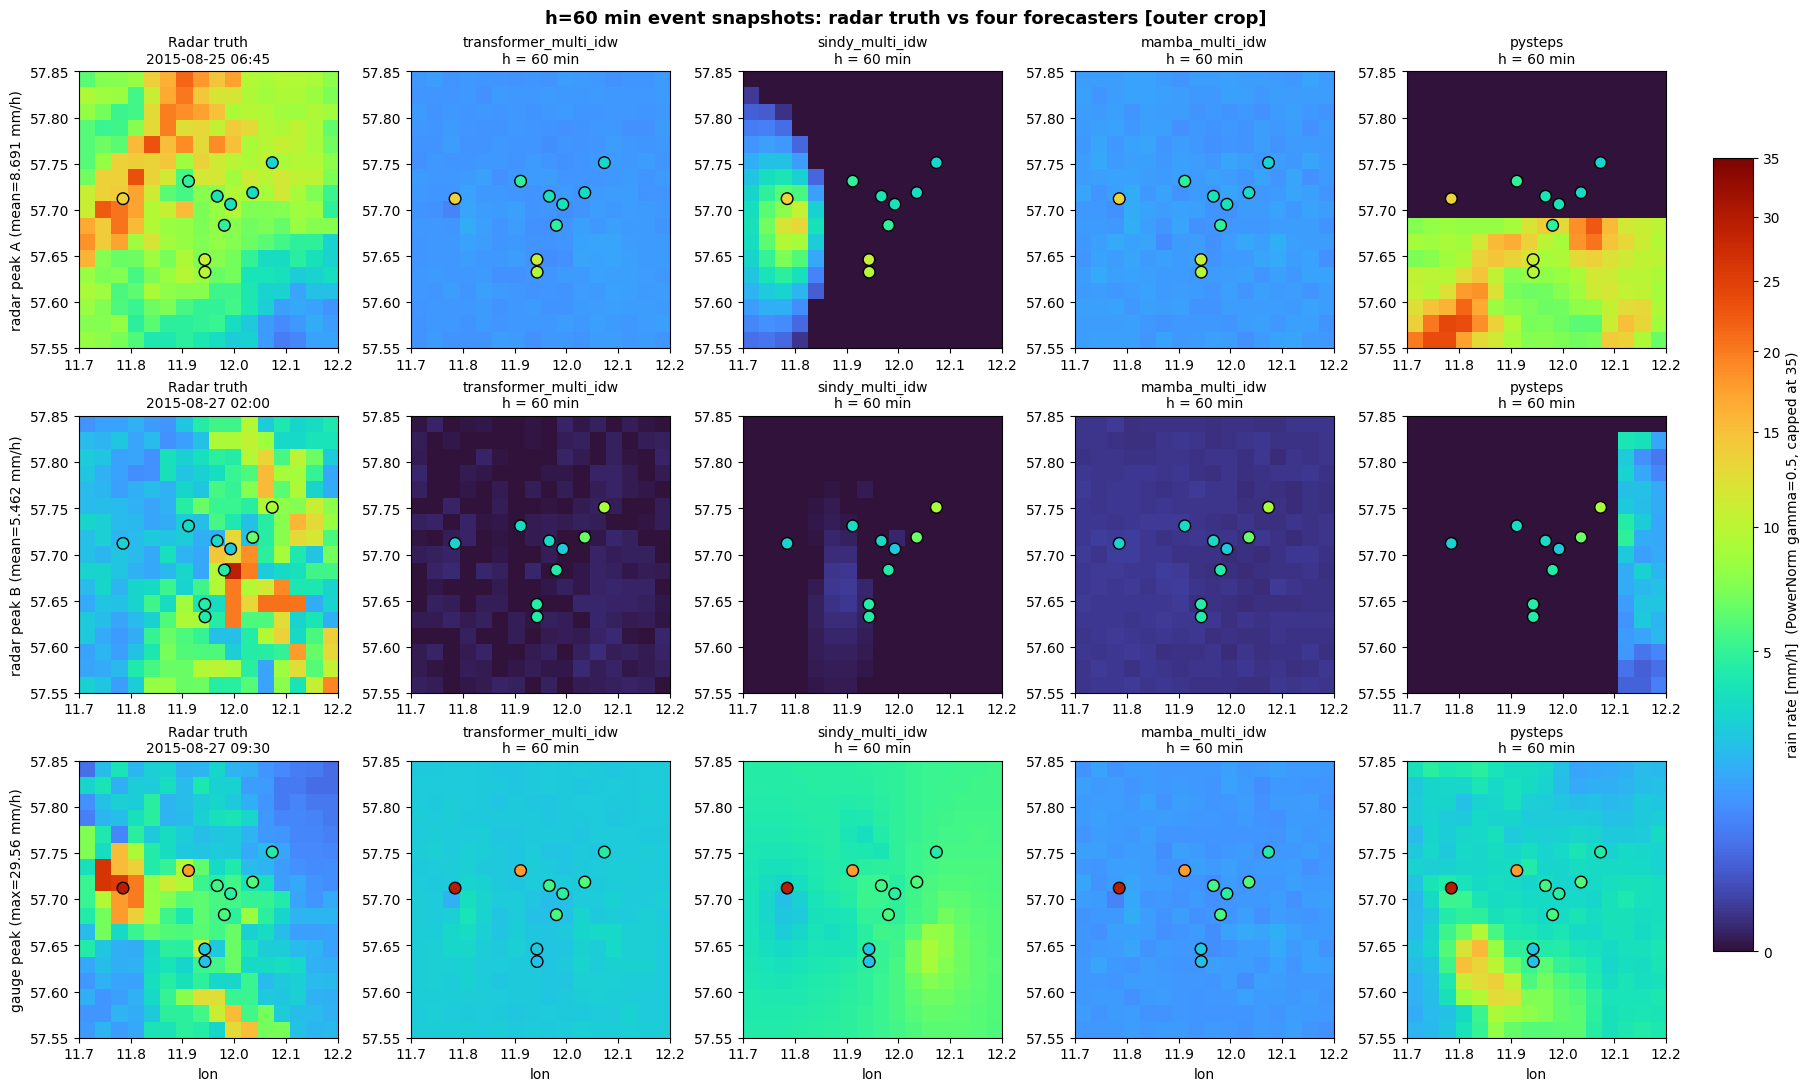

In [ ]:
from matplotlib.colors import PowerNorm as _PowerNormH60

def plot_h60_multi_model_snapshots(crop_fn, lat_range, lon_range,
                                     g_lons, g_lats, g_aligned_df,
                                     peak_separation_h=24, gamma=0.5,
                                     vmax_clip=35.0, title_suffix=""):
    """Three-row, five-column event snapshot at h=60 min: radar truth
    plus the four-forecaster comparison set."""
    MODELS_H60 = ["transformer_multi_idw", "sindy_multi_idw",
                   "mamba_multi_idw", "pysteps"]
    H_MIN = 60
    H_STEP = H_MIN // 15   # = 4

    # Check that every model has predictions registered at h=60.
    for m in MODELS_H60:
        if m not in MODEL_REGISTRY or MODEL_REGISTRY[m].get(H_MIN) is None:
            print(f"  {m!r} missing at h={H_MIN} - skipping snapshot.")
            return None

    T_test = TEST_HI - TEST_LO

    # --- Event selection (same as Part 6.10) ---------------------------
    rad_test = crop_fn(radar_15[TEST_LO:TEST_HI])
    test_mean = rad_test.mean(axis=(1, 2)).astype(np.float64)
    peak1 = int(np.argmax(test_mean))
    excl = peak_separation_h * 4   # 4 frames/hour at 15-min cadence
    masked = test_mean.copy()
    masked[max(0, peak1 - excl):min(T_test, peak1 + excl)] = -np.inf
    peak2 = int(np.argmax(masked))

    has_gauges_in_crop = g_aligned_df.shape[1] > 0
    if has_gauges_in_crop:
        gauge_test = g_aligned_df.values[TEST_LO:TEST_HI]
        gauge_max_per_t = np.nanmax(gauge_test, axis=1)
        peak_g = int(np.argmax(gauge_max_per_t))
        peak_g_val = float(gauge_max_per_t[peak_g])
        gauge_label = f"gauge peak (max={peak_g_val:.2f} mm/h)"
    else:
        masked2 = masked.copy()
        masked2[max(0, peak2 - excl):min(T_test, peak2 + excl)] = -np.inf
        peak_g = int(np.argmax(masked2))
        gauge_label = "radar peak C (no gauges in crop)"

    scenarios = [
        (f"radar peak A (mean={test_mean[peak1]:.3f} mm/h)", peak1),
        (f"radar peak B (mean={test_mean[peak2]:.3f} mm/h)", peak2),
        (gauge_label,                                        peak_g),
    ]

    # h=60 needs at least LOOKBACK_WINDOW + 3 frames of history.
    valid_lo = LOOKBACK_WINDOW + H_STEP - 1

    n_cols = 1 + len(MODELS_H60)
    fig, axes = plt.subplots(len(scenarios), n_cols,
                              figsize=(3.6 * n_cols, 3.6 * len(scenarios)),
                              constrained_layout=True)
    norm = _PowerNormH60(gamma=gamma, vmin=0.0, vmax=vmax_clip, clip=True)
    cmap = plt.get_cmap("turbo")
    extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]

    for row, (label, local_t) in enumerate(scenarios):
        clamped = max(valid_lo, min(local_t, T_test - 1))
        note = "" if clamped == local_t else " [clamped]"
        global_t = TEST_LO + clamped
        t_str = pd.Timestamp(radar_times[global_t]).strftime("%Y-%m-%d %H:%M")

        g_vals = g_aligned_df.values[global_t] if has_gauges_in_crop else np.empty(0)
        g_colors = (cmap(norm(np.nan_to_num(g_vals, nan=0.0)))
                    if g_vals.size > 0 else None)

        # Col 0: radar truth
        ax = axes[row, 0]
        truth = crop_fn(radar_15[global_t])
        ax.imshow(truth, cmap=cmap, norm=norm, origin="lower",
                  extent=extent, aspect="auto")
        if g_colors is not None:
            ax.scatter(g_lons, g_lats, s=70, marker="o", c=g_colors,
                       edgecolors="black", linewidths=1.0, zorder=5)
        ax.set_title(f"Radar truth\n{t_str}{note}", fontsize=10)
        ax.set_ylabel(label, fontsize=10)

        # Cols 1..n: predictions at h=60 from each model
        for j, model_name in enumerate(MODELS_H60):
            ax = axes[row, j + 1]
            pred_arr = MODEL_REGISTRY[model_name][H_MIN]
            pred_idx = clamped - LOOKBACK_WINDOW - H_STEP + 1
            if 0 <= pred_idx < pred_arr.shape[0]:
                pred = crop_fn(pred_arr[pred_idx])
                ax.imshow(pred, cmap=cmap, norm=norm, origin="lower",
                          extent=extent, aspect="auto")
                if g_colors is not None:
                    ax.scatter(g_lons, g_lats, s=70, marker="o", c=g_colors,
                               edgecolors="black", linewidths=1.0, zorder=5)
            else:
                ax.text(0.5, 0.5, "out of range",
                        ha="center", va="center", transform=ax.transAxes,
                        fontsize=10)
                ax.set_facecolor("lightgray")
            ax.set_title(f"{model_name}\nh = {H_MIN} min", fontsize=10)

    for ax in axes[-1, :]:
        ax.set_xlabel("lon")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02,
                 label=f"rain rate [mm/h]  (PowerNorm gamma={gamma}, capped at {vmax_clip:.0f})")
    fig.suptitle(
        f"h=60 min event snapshots: radar truth vs four forecasters{title_suffix}",
        fontsize=13, fontweight="bold")
    plt.show()
    return scenarios


print("plot_h60_multi_model_snapshots ready.")
event_scenarios_h60_outer = plot_h60_multi_model_snapshots(
    crop_field, LAT_RANGE, LON_RANGE,
    gauge_lons, gauge_lats, gauge_aligned,
    title_suffix=" [outer crop]",
)


## Part 6.12 - Focused line plots: skill vs forecast horizon

A compact view of how the eight forecasters of interest compare
\emph{as the forecast horizon grows}, using line plots (one line per
model) rather than the grouped bars of Parts~6.5--6.6. The focused
set is:

* Advanced multi-step on IDW maps: \texttt{transformer\_multi\_idw},
  \texttt{sindy\_multi\_idw}, \texttt{mamba\_multi\_idw}.
* Naive baselines: \texttt{naive\_radar}, \texttt{naive\_gauge},
  \texttt{naive\_cml}, \texttt{model1\_physical}.
* Operational radar nowcast: \texttt{pysteps}.

Two charts are produced: HSS vs horizon evaluated against rain gauges
and against the radar field. Colours are picked from the same
\texttt{\_spaced\_colors} palette used in Parts~6.5--6.6.

**Inputs:** \texttt{df\_gauge}, \texttt{df\_radar}.
**Outputs:** 2 line charts and a top-3 summary at the longest horizon.


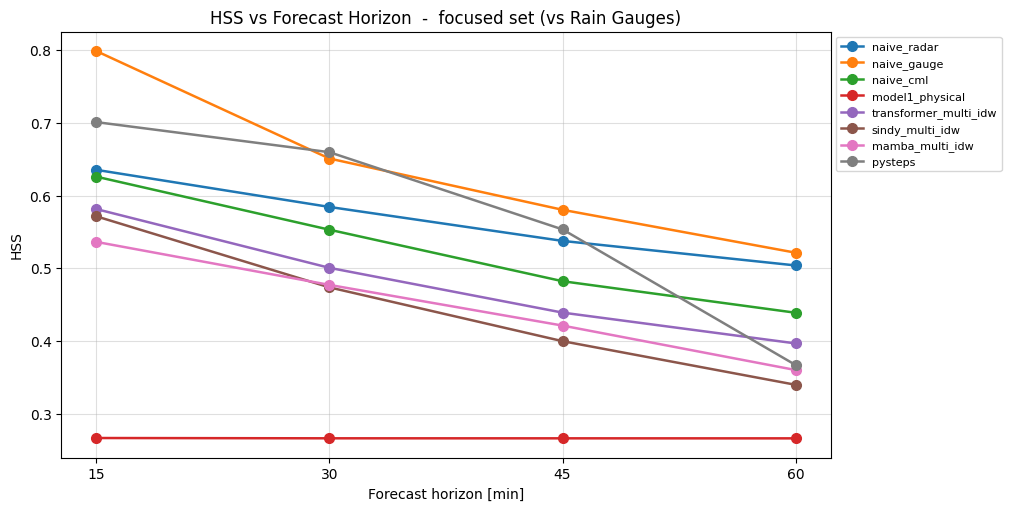

Top 3 at h=60 min vs Rain Gauges - HSS (higher is better):
  1. naive_gauge                      HSS = 0.5213
  2. naive_radar                      HSS = 0.5038
  3. naive_cml                        HSS = 0.4387



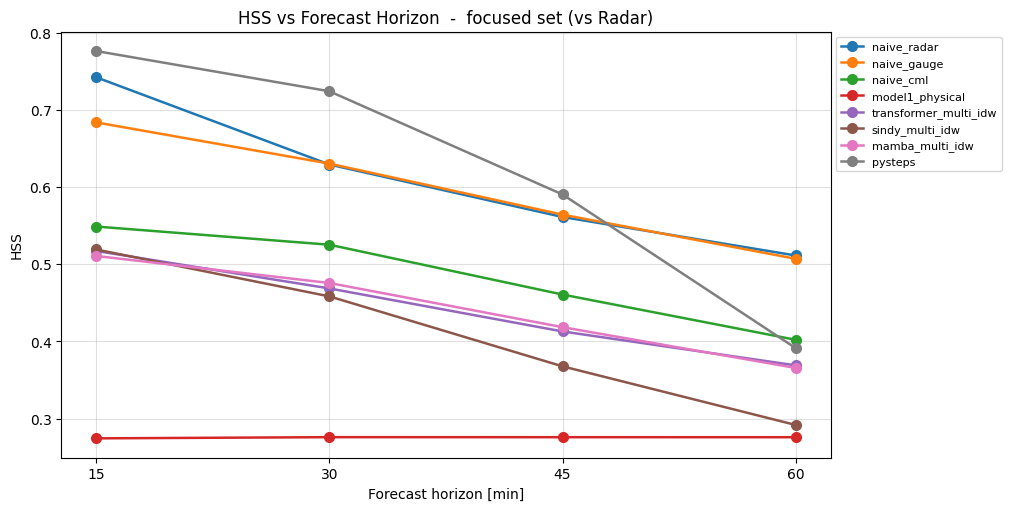

Top 3 at h=60 min vs Radar - HSS (higher is better):
  1. naive_radar                      HSS = 0.5112
  2. naive_gauge                      HSS = 0.5070
  3. naive_cml                        HSS = 0.4021



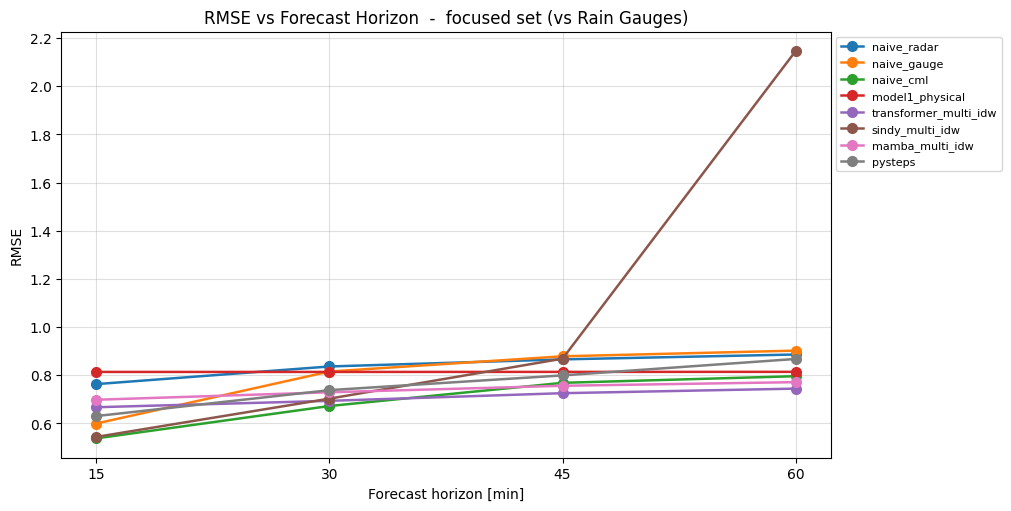

Top 3 at h=60 min vs Rain Gauges - RMSE (lower is better):
  1. transformer_multi_idw            RMSE = 0.7447
  2. mamba_multi_idw                  RMSE = 0.7716
  3. naive_cml                        RMSE = 0.7964



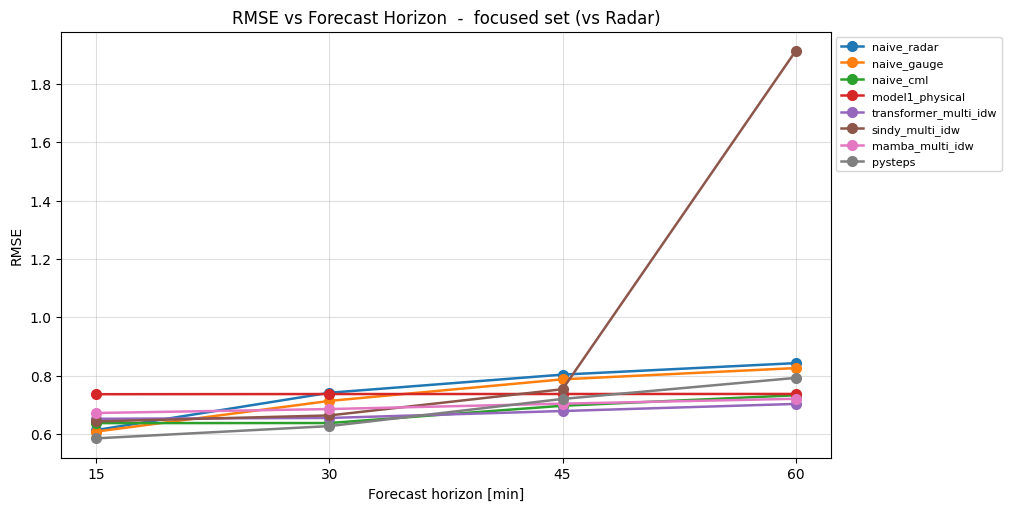

Top 3 at h=60 min vs Radar - RMSE (lower is better):
  1. transformer_multi_idw            RMSE = 0.7030
  2. mamba_multi_idw                  RMSE = 0.7205
  3. naive_cml                        RMSE = 0.7327



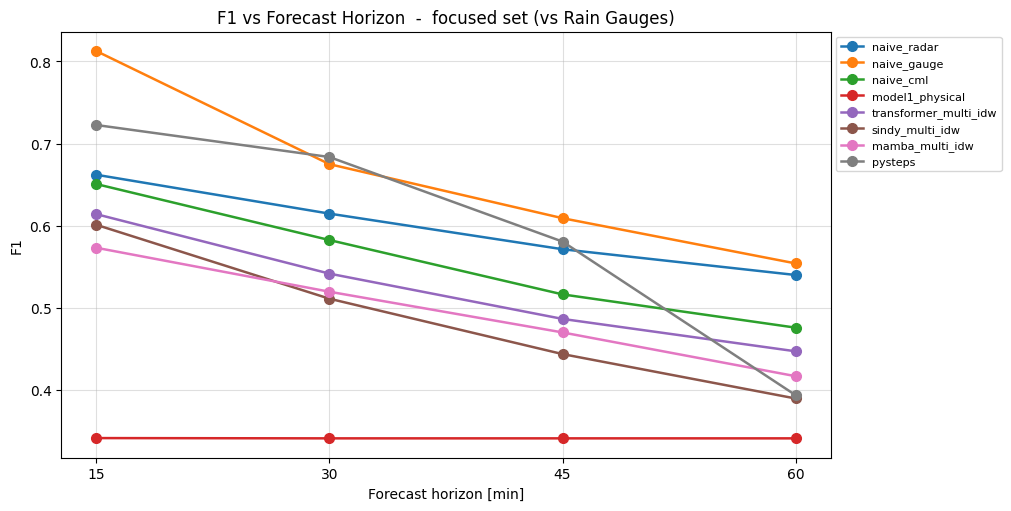

Top 3 at h=60 min vs Rain Gauges - F1 (higher is better):
  1. naive_gauge                      F1 = 0.5541
  2. naive_radar                      F1 = 0.5400
  3. naive_cml                        F1 = 0.4759



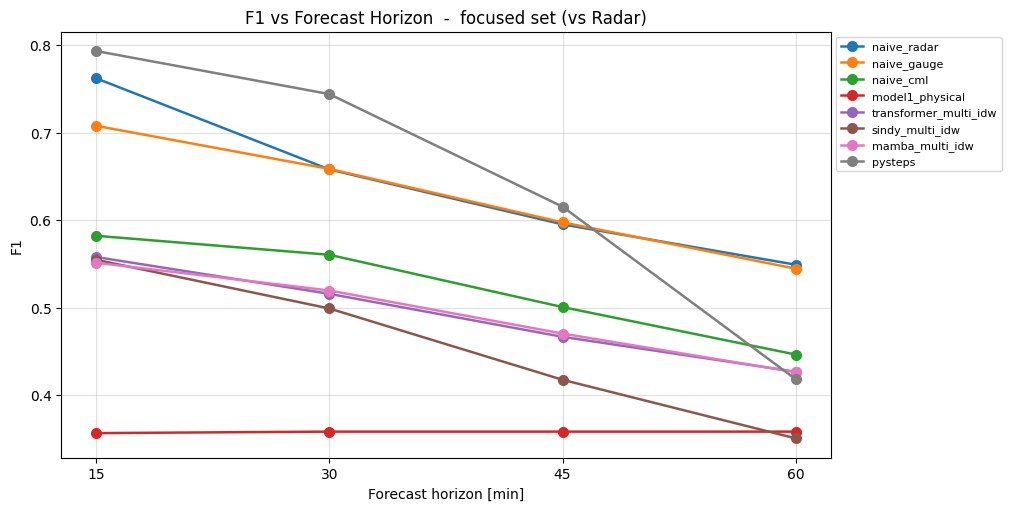

Top 3 at h=60 min vs Radar - F1 (higher is better):
  1. naive_radar                      F1 = 0.5491
  2. naive_gauge                      F1 = 0.5446
  3. naive_cml                        F1 = 0.4465



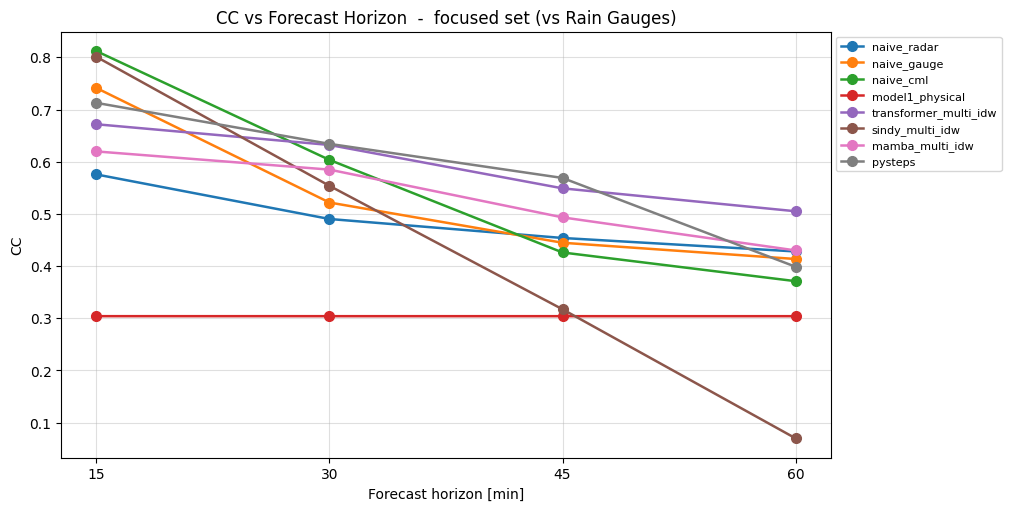

Top 3 at h=60 min vs Rain Gauges - CC (higher is better):
  1. transformer_multi_idw            CC = 0.5050
  2. mamba_multi_idw                  CC = 0.4299
  3. naive_radar                      CC = 0.4280



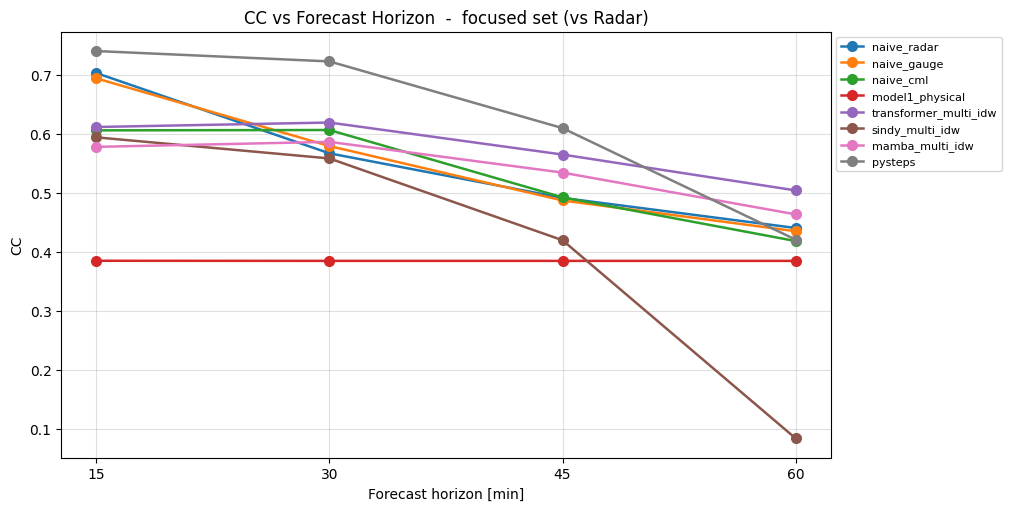

Top 3 at h=60 min vs Radar - CC (higher is better):
  1. transformer_multi_idw            CC = 0.5042
  2. mamba_multi_idw                  CC = 0.4636
  3. naive_radar                      CC = 0.4405



In [ ]:
FOCUS_MODELS_LINE = [
    "naive_radar", "naive_gauge", "naive_cml", "model1_physical",
    "transformer_multi_idw", "sindy_multi_idw", "mamba_multi_idw",
    "pysteps",
]

_focus_g = df_gauge[df_gauge["model"].isin(FOCUS_MODELS_LINE)].copy()
_focus_r = df_radar[df_radar["model"].isin(FOCUS_MODELS_LINE)].copy()

_focus_colors = {m: c for m, c in zip(FOCUS_MODELS_LINE, _spaced_colors(len(FOCUS_MODELS_LINE)))}

def _line_focus(df, target_label, metric="HSS", higher_is_better=True):
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    horizons_local = sorted(df["horizon_min"].unique())
    for m in FOCUS_MODELS_LINE:
        sub = df[df["model"] == m].sort_values("horizon_min")
        if sub.empty:
            continue
        ax.plot(sub["horizon_min"].values, sub[metric].values,
                marker="o", lw=1.8, ms=7, color=_focus_colors[m], label=m)
    ax.set_xlabel("Forecast horizon [min]")
    ax.set_ylabel(metric)
    ax.set_xticks(horizons_local)
    ax.set_title(f"{metric} vs Forecast Horizon  -  focused set (vs {target_label})")
    ax.grid(alpha=0.4)
    ax.legend(loc="upper left", fontsize=8, ncol=1, bbox_to_anchor=(1.0, 1.0))
    plt.show()
    h_max = max(horizons_local)
    sub_top = df[df["horizon_min"] == h_max][["model", metric]].dropna()
    sub_top = sub_top.sort_values(metric, ascending=(not higher_is_better)).head(3)
    print(f"Top 3 at h={h_max} min vs {target_label} - {metric} "
          f"({'higher' if higher_is_better else 'lower'} is better):")
    for rank, (_, r) in enumerate(sub_top.iterrows(), 1):
        print(f"  {rank}. {r['model']:<32s} {metric} = {r[metric]:.4f}")
    print()

# --- HSS (higher is better) ----------------------------------------
_line_focus(_focus_g, "Rain Gauges", "HSS", True)
_line_focus(_focus_r, "Radar",       "HSS", True)

# --- RMSE (lower is better) ----------------------------------------
_line_focus(_focus_g, "Rain Gauges", "RMSE", False)
_line_focus(_focus_r, "Radar",       "RMSE", False)

# --- F1 (higher is better) -----------------------------------------
_line_focus(_focus_g, "Rain Gauges", "F1", True)
_line_focus(_focus_r, "Radar",       "F1", True)

# --- Pearson CC (higher is better) ---------------------------------
_line_focus(_focus_g, "Rain Gauges", "CC", True)
_line_focus(_focus_r, "Radar",       "CC", True)


# PART 7 - FORECAST VIDEOS

Side-by-side MP4 animations: **radar truth** (left) and the
**top-K best forecasts** (one model per video) over a multi-frame
window of the test split. Rain gauges are overlaid on every panel as
circles whose fill colour encodes the actual gauge reading at that
time, using the same colour map and normalisation as the field, so
visual agreement between background field and gauge fill indicates
accuracy.

**Selection criterion.** Top-K is computed from `df_gauge` by mean
`HSS` across all four horizons (higher is better). The video uses
the 30-min horizon by default (`H_VIDEO`).

**Time window.** A `WINDOW_FRAMES`-long span around the test-window
peak rainfall frame (default 60 frames = 15 hours at 15-min cadence).


## Part 7.1 - Configure per-horizon videos (5-panel layout)

For every horizon in `HORIZONS_MIN = [15, 30, 45, 60]` we will build
one MP4 showing five panels side-by-side: the radar truth and the four
forecasters of interest (`pysteps`, `mamba_multi_*`,
`transformer_multi_*`, `sindy_multi_*`). `MAP_TYPE_VIDEO` selects which
input map type to use for the three CML-based multi-step models
(default `"idw"`).

A single `WINDOW_FRAMES`-long event window is located around the test-
split peak rainfall frame and reused across all four horizons.

**Inputs:** `MODEL_REGISTRY`, `radar_15`, `test_means`.
**Outputs:** `VIDEO_MODELS`, `event_window_for_h` (dict h_min -> (lo, hi)).


In [ ]:
MAP_TYPE_VIDEO = "idw"          # which CML map source: "idw" or "gmz"
WINDOW_FRAMES  = 60             # number of consecutive 15-min frames per video
FPS_VIDEO      = 4 / 3   # 3x slower than the previous 4 fps default
VIDEOS_DIR     = os.path.join(base_path, "videos")
os.makedirs(VIDEOS_DIR, exist_ok=True)

# Fixed 4 forecasters per video panel (in display order)
VIDEO_MODELS = [
    "pysteps",
    f"mamba_multi_{MAP_TYPE_VIDEO}",
    f"transformer_multi_{MAP_TYPE_VIDEO}",
    f"sindy_multi_{MAP_TYPE_VIDEO}",
]
print(f"Video forecaster panels (in order): {VIDEO_MODELS}")

# Sanity check: every model must have every horizon registered
for h in HORIZONS_MIN:
    missing = [m for m in VIDEO_MODELS
               if (m not in MODEL_REGISTRY)
               or (h not in MODEL_REGISTRY[m])
               or (MODEL_REGISTRY[m][h] is None)]
    if missing:
        print(f"  WARNING h={h}min: missing {missing}")

# Locate the event window for each horizon
peak_local = int(np.argmax(test_means))
event_window_for_h = {}
for h_min in HORIZONS_MIN:
    h_step = h_min // 15
    pred_peak = max(0, peak_local - LOOKBACK_WINDOW - h_step + 1)
    # reference length from any registered model
    ref_arr = None
    for m in VIDEO_MODELS:
        if m in MODEL_REGISTRY and h_min in MODEL_REGISTRY[m] and MODEL_REGISTRY[m][h_min] is not None:
            ref_arr = MODEL_REGISTRY[m][h_min]
            break
    if ref_arr is None:
        print(f"  h={h_min}: no model available - skipping")
        continue
    N = ref_arr.shape[0]
    half = WINDOW_FRAMES // 2
    lo = max(0, pred_peak - half)
    hi = min(N, lo + WINDOW_FRAMES)
    lo = max(0, hi - WINDOW_FRAMES)
    event_window_for_h[h_min] = (lo, hi)
    print(f"  h={h_min:>3d}min: prediction window [{lo}..{hi})  pred_peak={pred_peak}  N={N}")


Video forecaster panels (in order): ['pysteps', 'mamba_multi_idw', 'transformer_multi_idw', 'sindy_multi_idw']
  h= 15min: prediction window [1813..1873)  pred_peak=1843  N=2485
  h= 30min: prediction window [1812..1872)  pred_peak=1842  N=2485
  h= 45min: prediction window [1811..1871)  pred_peak=1841  N=2485
  h= 60min: prediction window [1810..1870)  pred_peak=1840  N=2485


## Part 7.2 - Render one MP4 per horizon (5-panel layout)

For every horizon in `HORIZONS_MIN`, write
`videos/forecast_h{h_min}min.mp4` showing five panels:
**radar truth | pySTEPS | Mamba (multi) | Transformer (multi) | SINDy (multi)**.
A shared `vmin=0`, `vmax=max` colour scale is used across all panels.
Rain gauges are overlaid on every panel as circles whose fill colour
encodes the actual gauge reading at that time.

**Inputs:** `VIDEO_MODELS`, `event_window_for_h`, `MODEL_REGISTRY`, `radar_15`, `gauge_aligned`.
**Outputs:** `videos/forecast_h{15,30,45,60}min.mp4`.


In [ ]:
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter

def _writer_for(path):
    """Pick MP4 (ffmpeg) if available, else fall back to animated GIF."""
    try:
        if FFMpegWriter.isAvailable():
            return FFMpegWriter(fps=FPS_VIDEO, bitrate=2400), path
    except Exception:
        pass
    return PillowWriter(fps=FPS_VIDEO), path.replace(".mp4", ".gif")


def _label_for(model_name):
    repl = {"pysteps": "pySTEPS",
            "mamba": "Mamba", "transformer": "Transformer", "sindy": "SINDy"}
    parts = model_name.split("_")
    return " ".join(repl.get(p, p) for p in parts)


def build_5panel_video(h_min, model_names, win_lo, win_hi,
                        out_dir, file_suffix="",
                        crop_fn=None, lat_range=None, lon_range=None,
                        g_lons=None, g_lats=None, g_at_time=None):
    crop_fn  = crop_fn  if crop_fn  is not None else crop_field
    lat_rng  = lat_range if lat_range is not None else LAT_RANGE
    lon_rng  = lon_range if lon_range is not None else LON_RANGE
    g_lons   = g_lons    if g_lons    is not None else gauge_lons
    g_lats   = g_lats    if g_lats    is not None else gauge_lats
    g_at_time = g_at_time if g_at_time is not None else gauge_values_at_time

    h_step = h_min // 15
    def gidx(i):
        return TEST_LO + LOOKBACK_WINDOW + h_step - 1 + i

    nf = win_hi - win_lo
    radar_seq = np.stack([crop_fn(radar_15[gidx(i)]) for i in range(win_lo, win_hi)])
    g_seq     = np.stack([g_at_time(gidx(i))         for i in range(win_lo, win_hi)])
    pred_seqs = []
    for m in model_names:
        arr = MODEL_REGISTRY.get(m, {}).get(h_min)
        if arr is None:
            pred_seqs.append(np.zeros_like(radar_seq))
        else:
            pred_seqs.append(np.stack([crop_fn(arr[i]) for i in range(win_lo, win_hi)]))
    times = [radar_times[gidx(i)] for i in range(win_lo, win_hi)]

    # Shared colour scale
    # Fixed non-linear colour scale: gamma=0.5 stretches the low end,
    # values above 35 mm/h saturate to the same top colour.
    vmax  = 35.0
    norm  = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)
    cmap  = plt.get_cmap("turbo")

    panels = [("Radar (truth)", radar_seq)] + [(_label_for(m), p) for m, p in zip(model_names, pred_seqs)]
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 4.2), constrained_layout=True)
    if n == 1:
        axes = [axes]
    extent = [lon_rng[0], lon_rng[1], lat_rng[0], lat_rng[1]]

    ims, scs = [], []
    for ax, (title, seq) in zip(axes, panels):
        im = ax.imshow(seq[0], cmap="turbo", norm=norm, origin="lower",
                       extent=extent, aspect="auto")
        ims.append(im)
        g_cols = cmap(norm(np.nan_to_num(g_seq[0], nan=0.0)))
        if len(g_lons) > 0:
            sc = ax.scatter(g_lons, g_lats, s=55, marker="o", c=g_cols,
                            edgecolors="black", linewidths=1.0, zorder=5)
            scs.append(sc)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(ims[-1], ax=axes, fraction=0.03, label="mm/h")
    super_title = fig.suptitle(f"{times[0]}   horizon {h_min} min",
                                fontweight="bold")

    def update(k):
        for j, (_, seq) in enumerate(panels):
            ims[j].set_data(seq[k])
        g_cols = cmap(norm(np.nan_to_num(g_seq[k], nan=0.0)))
        for sc in scs:
            sc.set_facecolor(g_cols)
        super_title.set_text(f"{times[k]}   horizon {h_min} min")
        return ims + scs + [super_title]

    anim = FuncAnimation(fig, update, frames=nf,
                         interval=1000 / FPS_VIDEO, blit=False)
    out_path = os.path.join(out_dir, f"forecast{file_suffix}_h{h_min}min.mp4")
    writer, real_path = _writer_for(out_path)
    anim.save(real_path, writer=writer, dpi=110)
    plt.close(fig)
    return real_path


video_paths = []
for h_min in HORIZONS_MIN:
    if h_min not in event_window_for_h:
        continue
    lo, hi = event_window_for_h[h_min]
    print(f"Rendering h={h_min} min ...")
    p = build_5panel_video(h_min, VIDEO_MODELS, lo, hi, VIDEOS_DIR)
    sz = os.path.getsize(p) / 1024**2
    print(f"  wrote {p}  ({sz:.2f} MB)")
    video_paths.append(p)
print(f"\n{len(video_paths)} video(s) saved under {VIDEOS_DIR}/")


Rendering h=15 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos/forecast_h15min.mp4  (2.10 MB)
Rendering h=30 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos/forecast_h30min.mp4  (2.09 MB)
Rendering h=45 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos/forecast_h45min.mp4  (2.07 MB)
Rendering h=60 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos/forecast_h60min.mp4  (1.94 MB)

4 video(s) saved under /content/drive/MyDrive/FieldSense_Project_v2/videos/


# PART 8 - EVALUATION IN A TIGHTER INNER CROP

Re-runs the full Part 6 evaluation pipeline (and Part 7 video generation
in Part 9) but restricted to a tighter geographic window over central
Gothenburg: latitude 57.6-57.8 N, longitude 11.75-12.10 E. The default
crop in Part 1.5 was 57.55-57.85 N x 11.70-12.20 E; the inner window is
strictly smaller and focuses the evaluation on the data-rich core
(closer to the gauge cluster and the densest CML coverage), excluding
the outer fringes of the radar composite where the gauge density is
lowest.

The trained forecasters and their saved prediction arrays are unchanged
- only the spatial crop (for radar comparison and visualisation) and
the gauge subset (for gauge comparison) are tightened. Every output is
written with an `_inner` suffix so the two regimes coexist on disk and
remain comparable.


## Part 8.0 - Define the inner crop and filter gauges

Sets up `LAT_RANGE2`, `LON_RANGE2`, `crop_field2`, the filtered gauge
subset (`gauge_lons2`, `gauge_lats2`, `gauge_aligned2`), and the
peak-detection series `test_means2` over the inner crop. All subsequent
cells in Parts 8 and 9 consume only these inner-crop variables.

**Inputs:** `lat2d`, `lon2d`, `gauges_info`, `gauge_aligned`, `radar_15`, `idx_test`.
**Outputs:** the variables above and `gauge_values_at_time_2(t_global_idx)`.


In [ ]:
LAT_RANGE2 = (57.6, 57.8)
LON_RANGE2 = (11.75, 12.10)

# --- Inner crop indices into the radar grid ----------------------------
_m2 = ((lat2d >= LAT_RANGE2[0]) & (lat2d <= LAT_RANGE2[1]) &
       (lon2d >= LON_RANGE2[0]) & (lon2d <= LON_RANGE2[1]))
_y2, _x2 = np.where(_m2)
if _y2.size == 0:
    raise RuntimeError(f"Inner crop {LAT_RANGE2} x {LON_RANGE2} hits no radar pixels.")
y_lo2, y_hi2 = int(_y2.min()), int(_y2.max()) + 1
x_lo2, x_hi2 = int(_x2.min()), int(_x2.max()) + 1

def crop_field2(f):
    return f[..., y_lo2:y_hi2, x_lo2:x_hi2]

print(f"Inner crop  lat {LAT_RANGE2}  lon {LON_RANGE2}")
print(f"  radar grid sub-window: y[{y_lo2}:{y_hi2}]  x[{x_lo2}:{x_hi2}]"
      f"  shape={(y_hi2 - y_lo2, x_hi2 - x_lo2)}")

# --- Gauge filtering ---------------------------------------------------
_gmask = ((gauge_lats >= LAT_RANGE2[0]) & (gauge_lats <= LAT_RANGE2[1]) &
          (gauge_lons >= LON_RANGE2[0]) & (gauge_lons <= LON_RANGE2[1]))
gauge_lons2 = gauge_lons[_gmask]
gauge_lats2 = gauge_lats[_gmask]
_inner_names = [g["name"] for g, keep in zip(gauges_info, _gmask) if keep]
gauge_aligned2 = gauge_aligned[_inner_names]

def gauge_values_at_time_2(t_global_idx):
    return gauge_aligned2.values[t_global_idx]

print(f"  gauges inside inner window: {len(_inner_names)} / {len(gauges_info)}")
for nm in _inner_names:
    print(f"    {nm}")
if len(_inner_names) == 0:
    raise RuntimeError("No gauges fall inside the inner crop - widen LAT_RANGE2/LON_RANGE2.")

# --- Peak detection over the inner crop --------------------------------
test_means2 = crop_field2(radar_15)[idx_test[0]:idx_test[1]].mean(axis=(1, 2))
print(f"\n  inner test_means2: shape={test_means2.shape}"
      f"  peak={test_means2.max():.4f} mm/h"
      f"  argmax at local idx {int(np.argmax(test_means2))}")


Inner crop  lat (57.6, 57.8)  lon (11.75, 12.1)
  radar grid sub-window: y[14:26]  x[10:20]  shape=(12, 10)
  gauges inside inner window: 9 / 9
    gauge_0
    gauge_1
    gauge_2
    gauge_3
    gauge_4
    gauge_5
    gauge_6
    gauge_7
    gauge_8

  inner test_means2: shape=(2496,)  peak=9.6028 mm/h  argmax at local idx 1851


## Part 8.4 — Radar comparison (grid-to-grid, cropped to gauge area)

Same metrics but against the cropped radar field.

**Inputs:** `MODEL_REGISTRY`, `radar_15`.
**Outputs:** `df_radar2` DataFrame.


In [ ]:
rows = []
for mname, mdict in MODEL_REGISTRY.items():
    for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
        pred = mdict.get(h_min)
        if pred is None: continue
        n = pred.shape[0]
        start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
        gt = radar_15[start : start + n]
        if gt.shape[0] != n:
            continue
        m = compute_metrics(crop_field2(gt), crop_field2(pred))
        rows.append({"model": mname, "horizon_min": h_min, **m})
df_radar2 = pd.DataFrame(rows)
print(f"\n=== EVALUATION VS RADAR (inner crop) ===\n")
print(df_radar2.to_string(index=False, float_format="{:.4f}".format))


=== EVALUATION VS RADAR (inner crop) ===

                     model  horizon_min    RMSE    MAE    Bias     CC    HSS     F1  Precision  Recall  n_wet_true  n_wet_pred
               naive_radar           15  0.6140 0.0931 -0.0005 0.7151 0.7495 0.7690     0.7710  0.7670       23284       23164
               naive_radar           30  0.7475 0.1242 -0.0011 0.5780 0.6344 0.6629     0.6663  0.6595       23404       23164
               naive_radar           45  0.8090 0.1404 -0.0014 0.5059 0.5694 0.6029     0.6076  0.5983       23404       23044
               naive_radar           60  0.8460 0.1502 -0.0019 0.4596 0.5213 0.5585     0.5643  0.5527       23404       22924
               naive_gauge           15  0.5692 0.0926  0.0033 0.7465 0.7070 0.7292     0.7507  0.7088       23284       21984
               naive_gauge           30  0.7174 0.1225  0.0027 0.5972 0.6427 0.6699     0.6915  0.6495       23404       21984
               naive_gauge           45  0.8077 0.1442  0.0021 0.488

## Part 8.6 — Bar charts vs radar (same 3 metrics)

Identical structure to Part 6.5 but using `df_radar2`.

**Inputs:** `df_radar2`.
**Outputs:** 3 figures + top-3 lists.


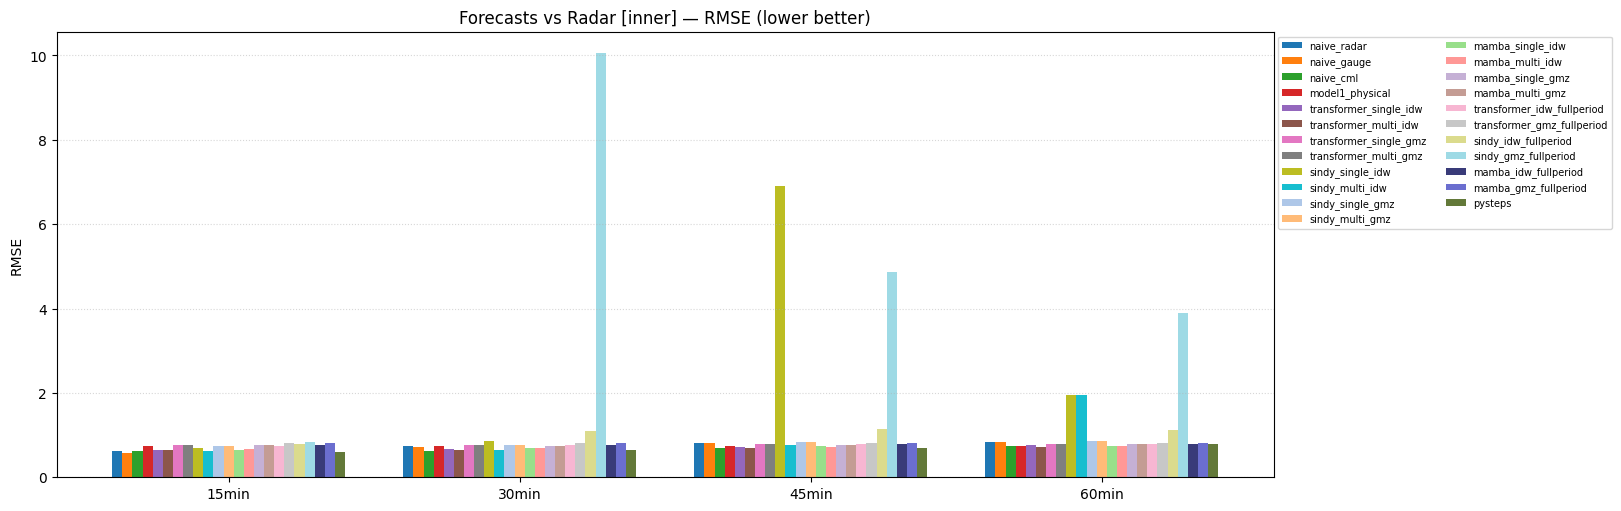


TOP 3 MODELS — RMSE (lower is better):
  h=15min:
    1. naive_gauge                    RMSE=0.5692
    2. pysteps                        RMSE=0.5956
    3. naive_radar                    RMSE=0.6140
  h=30min:
    1. naive_cml                      RMSE=0.6198
    2. pysteps                        RMSE=0.6489
    3. transformer_multi_idw          RMSE=0.6545
  h=45min:
    1. transformer_multi_idw          RMSE=0.6861
    2. pysteps                        RMSE=0.7006
    3. naive_cml                      RMSE=0.7020
  h=60min:
    1. transformer_multi_idw          RMSE=0.7142
    2. mamba_multi_idw                RMSE=0.7340
    3. naive_cml                      RMSE=0.7442



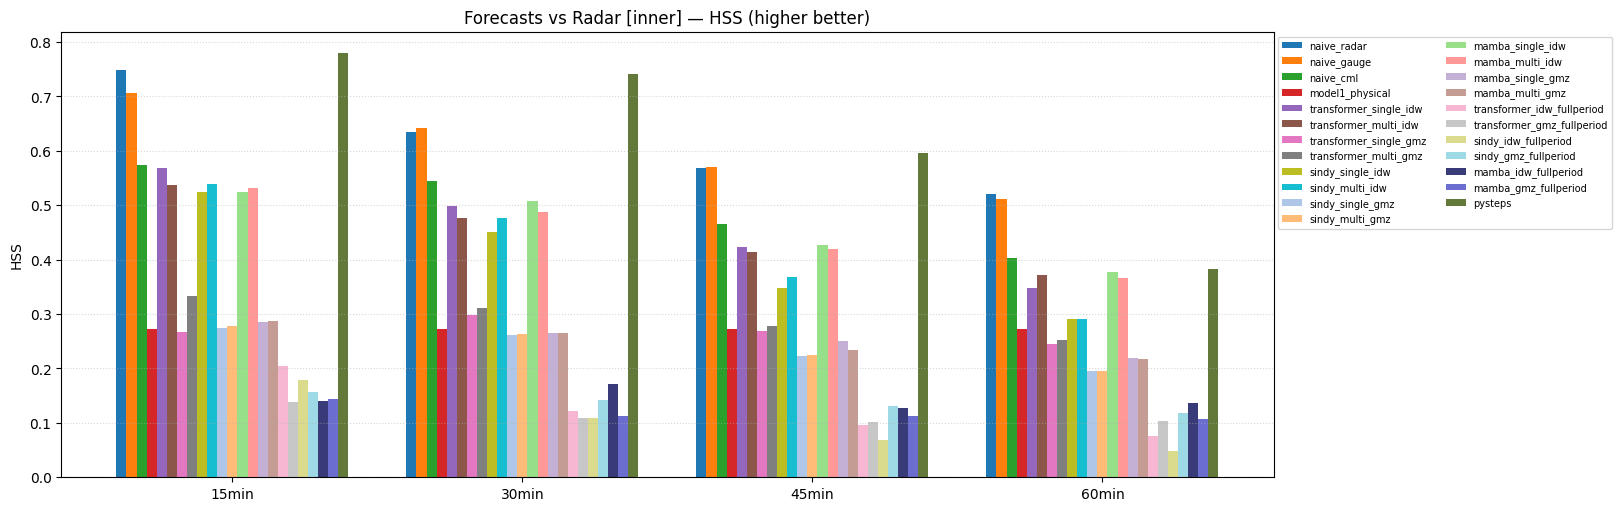


TOP 3 MODELS — HSS (higher is better):
  h=15min:
    1. pysteps                        HSS=0.7801
    2. naive_radar                    HSS=0.7495
    3. naive_gauge                    HSS=0.7070
  h=30min:
    1. pysteps                        HSS=0.7404
    2. naive_gauge                    HSS=0.6427
    3. naive_radar                    HSS=0.6344
  h=45min:
    1. pysteps                        HSS=0.5968
    2. naive_gauge                    HSS=0.5706
    3. naive_radar                    HSS=0.5694
  h=60min:
    1. naive_radar                    HSS=0.5213
    2. naive_gauge                    HSS=0.5106
    3. naive_cml                      HSS=0.4035



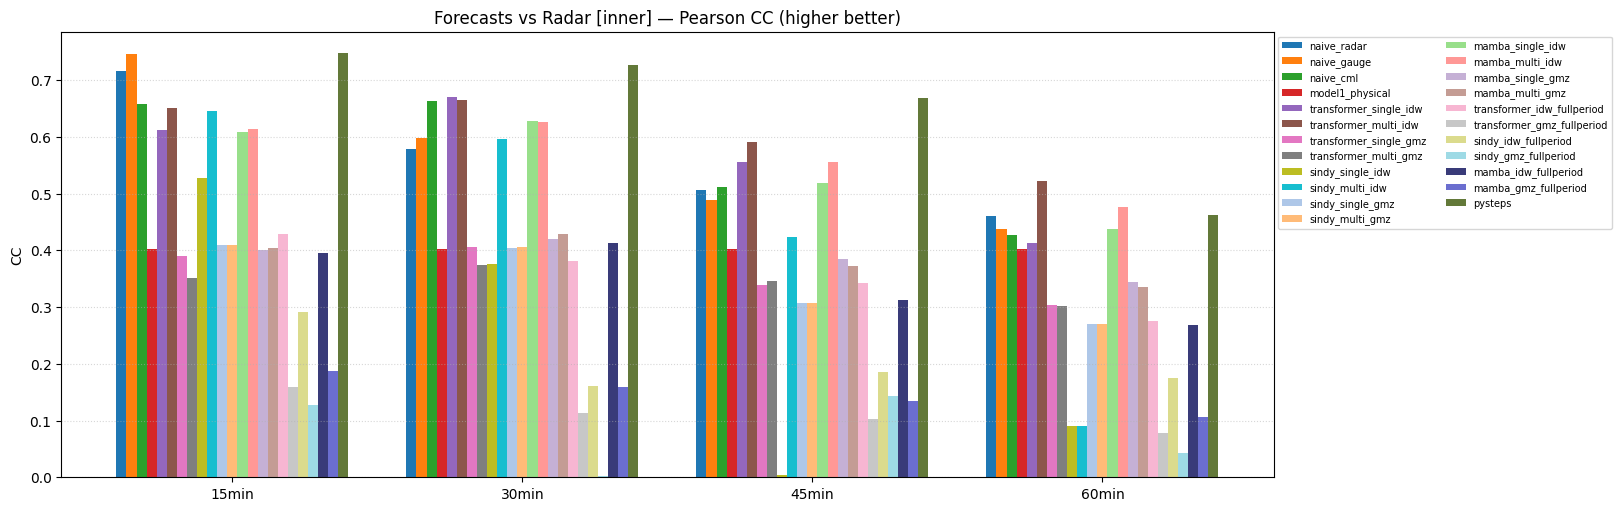


TOP 3 MODELS — CC (higher is better):
  h=15min:
    1. pysteps                        CC=0.7478
    2. naive_gauge                    CC=0.7465
    3. naive_radar                    CC=0.7151
  h=30min:
    1. pysteps                        CC=0.7265
    2. transformer_single_idw         CC=0.6699
    3. transformer_multi_idw          CC=0.6640
  h=45min:
    1. pysteps                        CC=0.6681
    2. transformer_multi_idw          CC=0.5915
    3. mamba_multi_idw                CC=0.5554
  h=60min:
    1. transformer_multi_idw          CC=0.5214
    2. mamba_multi_idw                CC=0.4755
    3. pysteps                        CC=0.4618



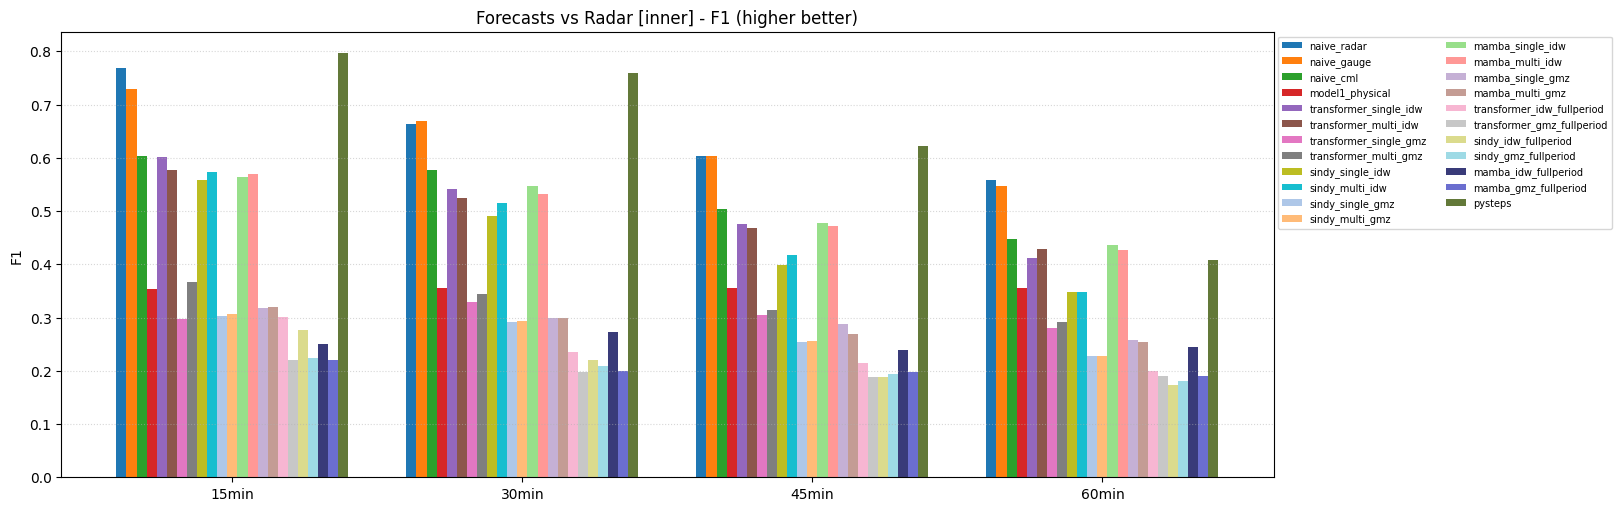


TOP 3 MODELS — F1 (higher is better):
  h=15min:
    1. pysteps                        F1=0.7970
    2. naive_radar                    F1=0.7690
    3. naive_gauge                    F1=0.7292
  h=30min:
    1. pysteps                        F1=0.7596
    2. naive_gauge                    F1=0.6699
    3. naive_radar                    F1=0.6629
  h=45min:
    1. pysteps                        F1=0.6216
    2. naive_gauge                    F1=0.6032
    3. naive_radar                    F1=0.6029
  h=60min:
    1. naive_radar                    F1=0.5585
    2. naive_gauge                    F1=0.5476
    3. naive_cml                      F1=0.4466



In [ ]:
plot_metric_bars(df_radar2, "RMSE", "Forecasts vs Radar [inner] — RMSE (lower better)", True)
plot_metric_bars(df_radar2, "HSS",  "Forecasts vs Radar [inner] — HSS (higher better)", False)
plot_metric_bars(df_radar2, "CC",   "Forecasts vs Radar [inner] — Pearson CC (higher better)", False)
plot_metric_bars(df_radar2, "F1",   "Forecasts vs Radar [inner] - F1 (higher better)", False)


## Part 8.7 - Focused comparison [inner]: best CML-based vs pySTEPS (vs radar)

Reduce the chart to the operational story, restricted to the inner
crop and evaluated only against the radar (the inner gauge subset is
too small to support a meaningful gauge-side ranking):

* `naive_cml`, `naive_radar`
* Top-3 advanced models trained on **IDW**, ranked by mean HSS over horizons (vs radar)
* Top-3 advanced models trained on **GMZ**, ranked by mean HSS over horizons (vs radar)
* `pysteps` (operational radar benchmark)

For h ∈ {15, 30, 45, 60}, two metrics: RMSE and HSS vs radar.

**Inputs:** `df_radar2`.
**Outputs:** 2 figures + ranking table.


Focused model set (inner, vs radar): ['naive_radar', 'naive_cml', 'transformer_single_idw', 'mamba_single_idw', 'mamba_multi_idw', 'transformer_multi_gmz', 'transformer_single_gmz', 'mamba_single_gmz', 'pysteps']



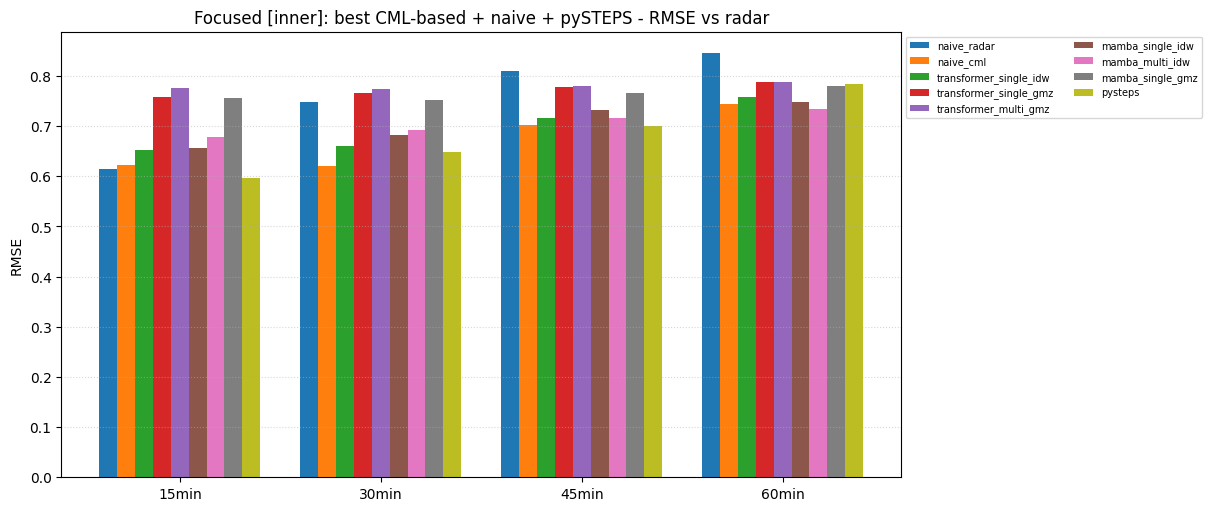


TOP 3 MODELS — RMSE (lower is better):
  h=15min:
    1. pysteps                        RMSE=0.5956
    2. naive_radar                    RMSE=0.6140
    3. naive_cml                      RMSE=0.6221
  h=30min:
    1. naive_cml                      RMSE=0.6198
    2. pysteps                        RMSE=0.6489
    3. transformer_single_idw         RMSE=0.6600
  h=45min:
    1. pysteps                        RMSE=0.7006
    2. naive_cml                      RMSE=0.7020
    3. mamba_multi_idw                RMSE=0.7152
  h=60min:
    1. mamba_multi_idw                RMSE=0.7340
    2. naive_cml                      RMSE=0.7442
    3. mamba_single_idw               RMSE=0.7487



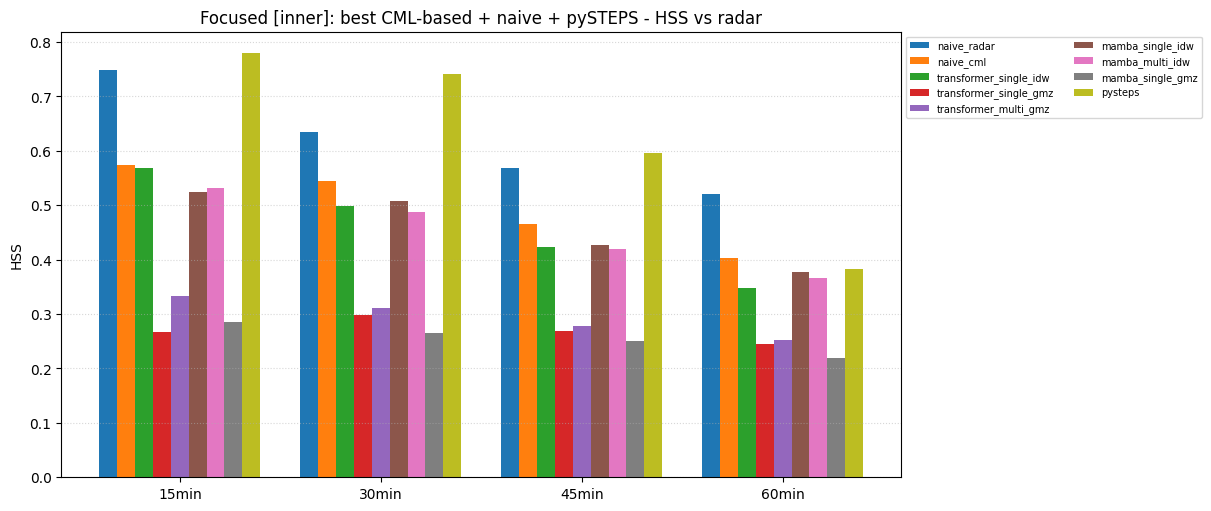


TOP 3 MODELS — HSS (higher is better):
  h=15min:
    1. pysteps                        HSS=0.7801
    2. naive_radar                    HSS=0.7495
    3. naive_cml                      HSS=0.5732
  h=30min:
    1. pysteps                        HSS=0.7404
    2. naive_radar                    HSS=0.6344
    3. naive_cml                      HSS=0.5441
  h=45min:
    1. pysteps                        HSS=0.5968
    2. naive_radar                    HSS=0.5694
    3. naive_cml                      HSS=0.4657
  h=60min:
    1. naive_radar                    HSS=0.5213
    2. naive_cml                      HSS=0.4035
    3. pysteps                        HSS=0.3821

RANKING (avg over horizons, vs radar [inner crop]):
                         RMSE    HSS     CC     F1
model                                             
pysteps                0.6822 0.6248 0.6510 0.6467
naive_radar            0.7541 0.6186 0.5646 0.6483
naive_cml              0.6720 0.4966 0.5646 0.5330
transformer_single_i

In [ ]:
# Identify top-3 IDW-trained and top-3 GMZ-trained models from df_radar2
def topk_by_substring(df, substring, metric="HSS", k=3, ascending=False):
    sub = df[df["model"].str.contains(substring)]
    if sub.empty: return []
    avg = sub.groupby("model")[metric].mean().reset_index()
    avg = avg.sort_values(metric, ascending=ascending).head(k)
    return list(avg["model"])

top_idw_inner = topk_by_substring(df_radar2, "_idw", metric="HSS", k=3, ascending=False)
top_gmz_inner = topk_by_substring(df_radar2, "_gmz", metric="HSS", k=3, ascending=False)
focus_models = ["naive_radar", "naive_cml"] + top_idw_inner + top_gmz_inner + ["pysteps"]
focus_models = [m for m in focus_models if m in df_radar2["model"].unique()]
print(f"Focused model set (inner, vs radar): {focus_models}\n")

df_focus2 = df_radar2[df_radar2["model"].isin(focus_models)].copy()
plot_metric_bars(df_focus2, "RMSE",
                  "Focused [inner]: best CML-based + naive + pySTEPS - RMSE vs radar", True)
plot_metric_bars(df_focus2, "HSS",
                  "Focused [inner]: best CML-based + naive + pySTEPS - HSS vs radar", False)

# Ranking table
print("RANKING (avg over horizons, vs radar [inner crop]):")
print(df_focus2.groupby("model")[["RMSE","HSS","CC","F1"]].mean()
      .sort_values("HSS", ascending=False).to_string(float_format="{:.4f}".format))


## Part 8.8 — Peak-event visualization (30-min horizon)

Pick the test-window frame with the highest spatially-averaged radar
rain rate. Plot a grid of subplots — one per model — for the 30-min
horizon. Same color scale, gauge and CML markers overlaid.

**Inputs:** `MODEL_REGISTRY`, `radar_15`, gauge/CML coords.
**Outputs:** large grid figure.


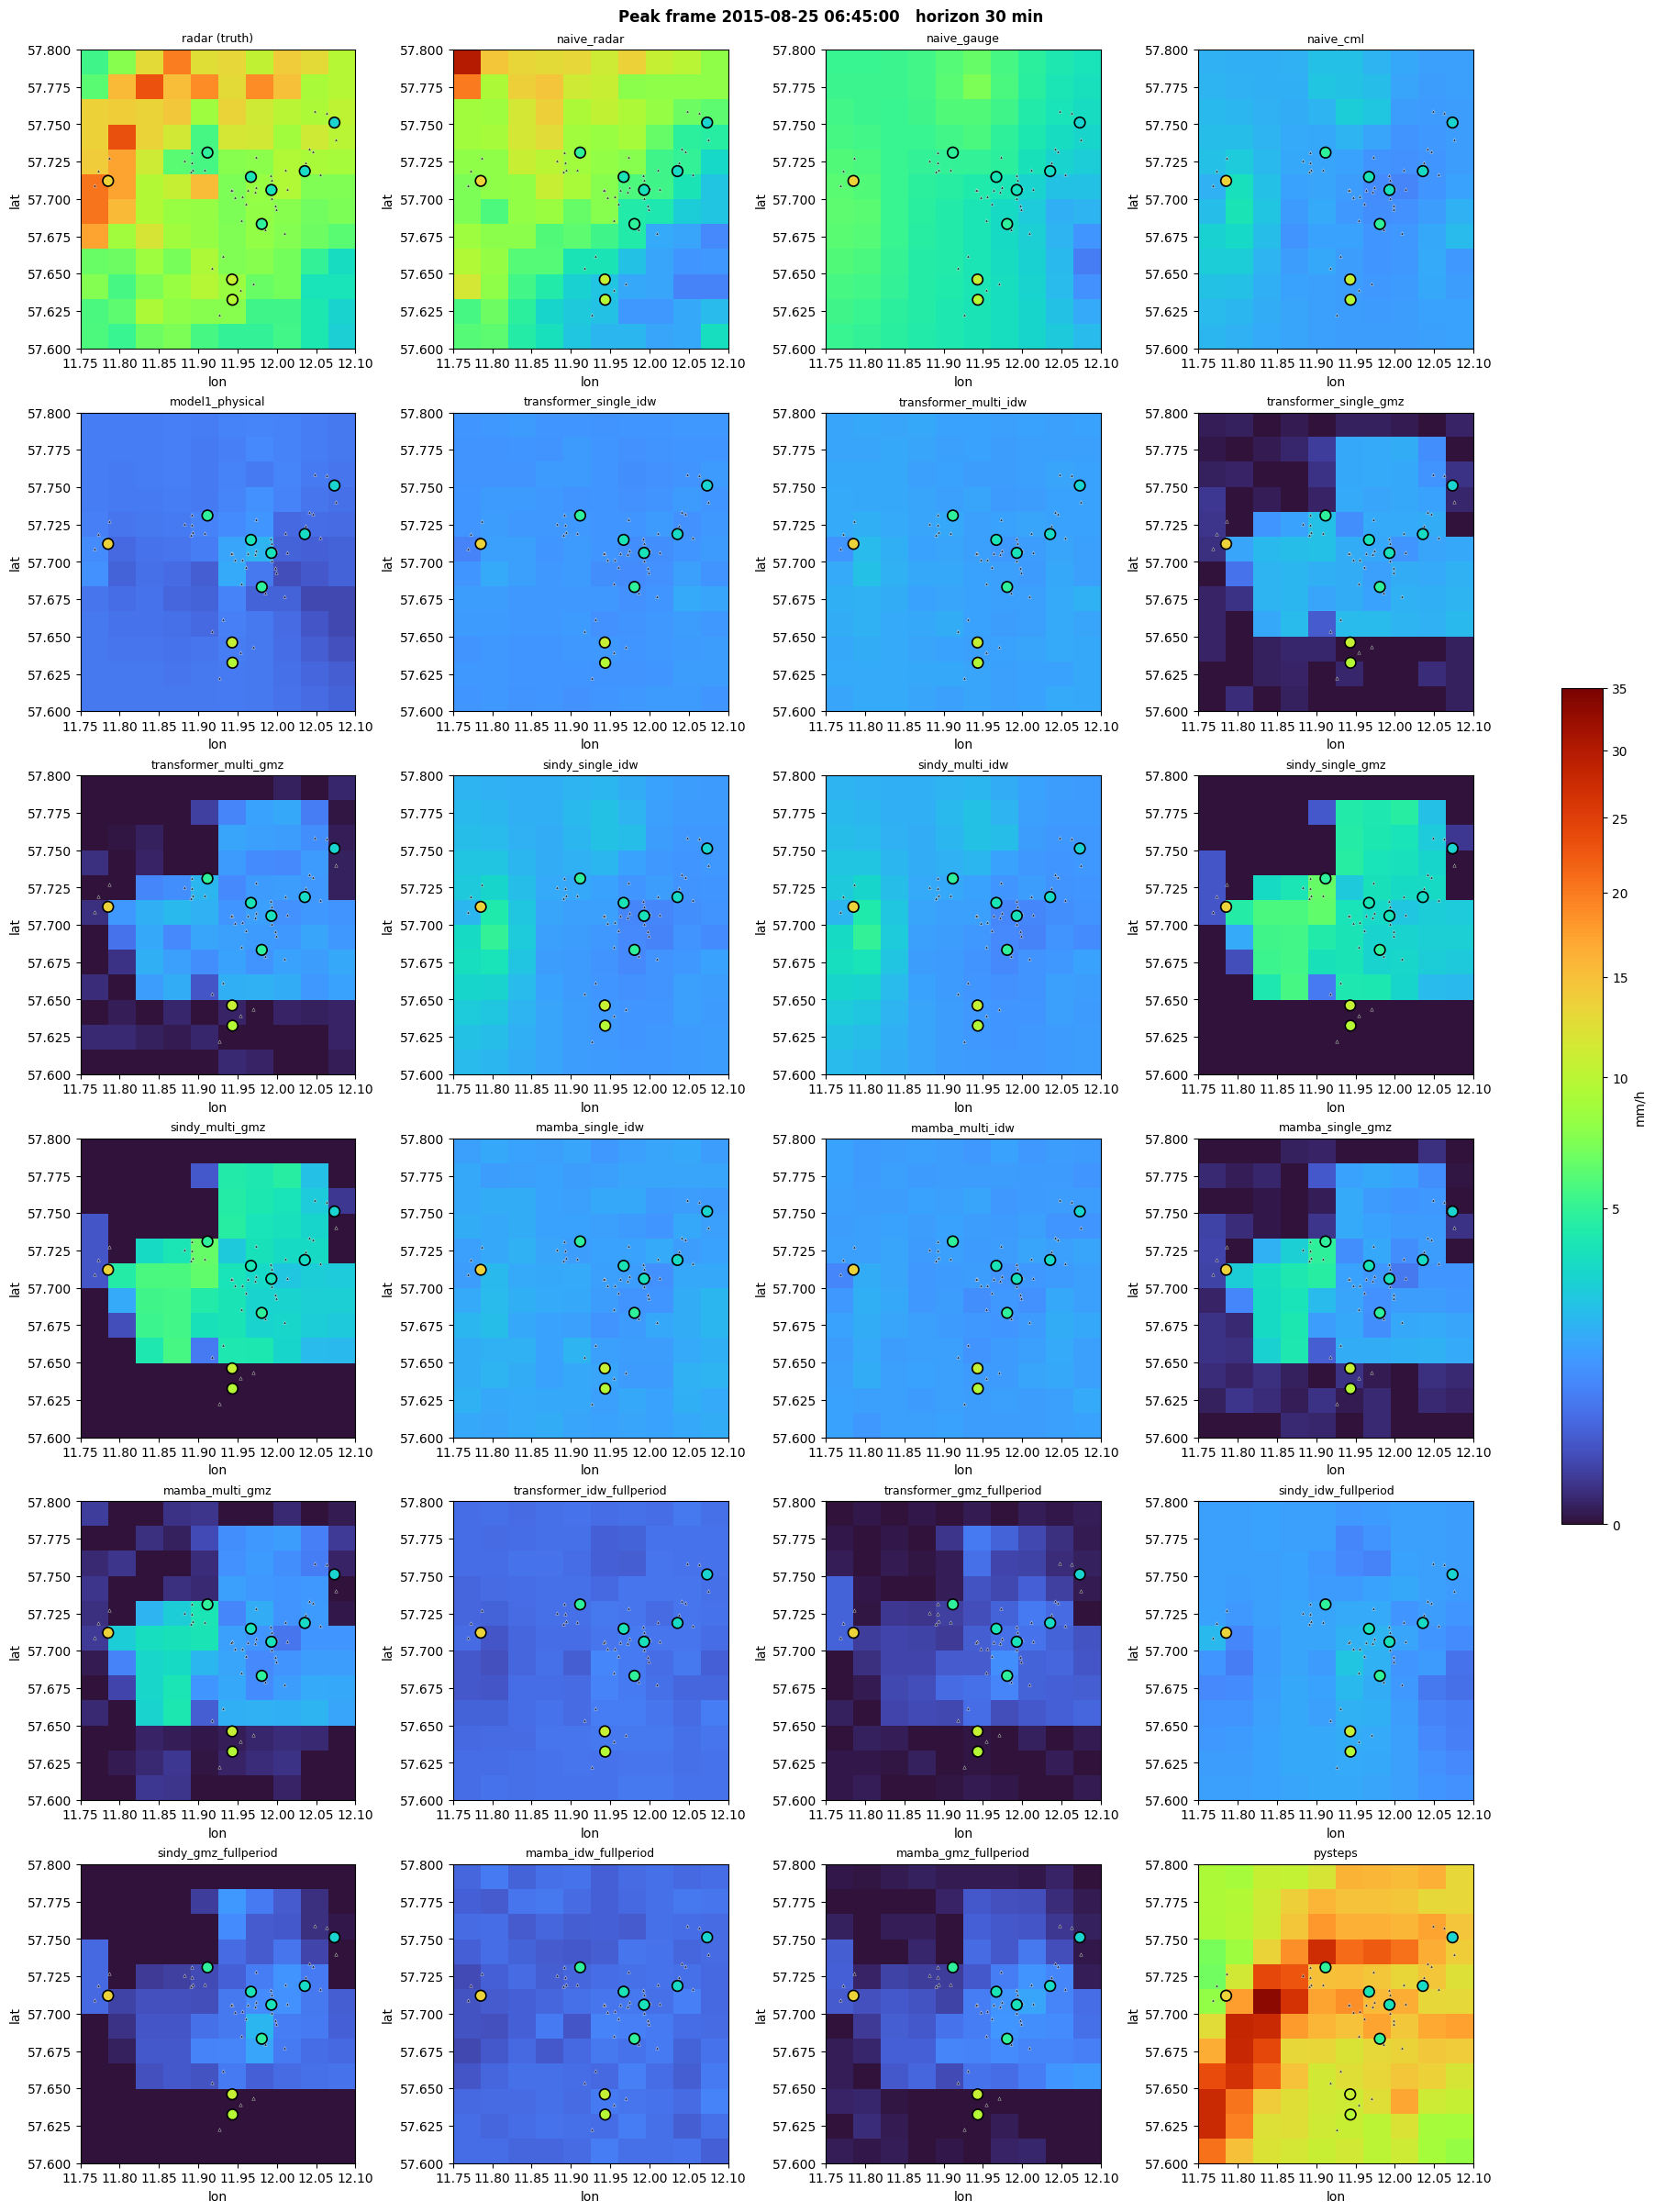

In [ ]:
H_VIZ = 30
h_step_viz = H_VIZ // 15
peak_local_v = int(np.argmax(test_means2))
peak_global_v = TEST_LO + peak_local_v
i_pred = peak_local_v - LOOKBACK_WINDOW - h_step_viz + 1
if i_pred < 0:
    i_pred = 0
    peak_global_v = TEST_LO + LOOKBACK_WINDOW + h_step_viz - 1

panels = [("radar (truth)", crop_field2(radar_15)[peak_global_v])]
for mname, mdict in MODEL_REGISTRY.items():
    if H_VIZ not in mdict or mdict[H_VIZ] is None: continue
    pred = mdict[H_VIZ]
    if i_pred < pred.shape[0]:
        panels.append((mname, crop_field2(pred[i_pred])))

n = len(panels)
cols = 4
rows_grid = math.ceil(n / cols)
fig, axes = plt.subplots(rows_grid, cols, figsize=(4.5*cols, 4*rows_grid), constrained_layout=True)
axes = np.atleast_2d(axes)
# Fixed non-linear colour scale: gamma=0.5 stretches the low end,
# all values above 35 mm/h saturate to the same top colour.
vmax = 35.0
norm = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)
# Gauge readings at the peak time, for overlay (rendered on every panel)
g_vals_peak = gauge_values_at_time_2(peak_global_v)
for ax, (name, m) in zip(axes.ravel(), panels):
    im = ax.imshow(m, cmap="turbo", norm=norm, origin="lower",
                   extent=[LON_RANGE2[0], LON_RANGE2[1], LAT_RANGE2[0], LAT_RANGE2[1]],
                   aspect="auto")
    # Gauges — color encodes actual rain rate at this time, same cmap as field
    overlay_gauges_on_map(ax, gauge_lons2, gauge_lats2, g_vals_peak,
                           norm=norm, cmap="turbo", size=70)
    # CML midpoint markers (sparse, just for context)
    ax.scatter(link_lons[::5], link_lats[::5], s=6, marker="^",
                facecolors="black", edgecolors="white", linewidths=0.4, alpha=0.7)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
fig.suptitle(f"Peak frame {radar_times[peak_global_v]}   horizon {H_VIZ} min",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=axes, fraction=0.03, label="mm/h")
plt.show()

## Part 8.9 - Single-file evaluation report [inner, radar-only]

Bundles every quantitative result of Part 8 (radar-side only) into one
self-contained Markdown report at
`PROCESSED_DIR/evaluation_report_inner.md`, suitable for archiving,
sharing, and discussing the results.

Also writes the same data in machine-readable form:
* `evaluation_report_inner.json` - configuration + sweep best configs +
  every radar metric, model, and horizon.
* `metrics_vs_radar_inner.csv` - the radar metrics dataframe.
* `evaluation_report_inner.zip` - all of the above in a single archive.

**Inputs:** `df_radar2`, `MODEL_REGISTRY`, sweep JSONs, `lb_results`.
**Outputs:** four files (`.md`, `.json`, `.csv`, `.zip`).


In [ ]:
import zipfile, datetime
REPORT_MD_INNER   = os.path.join(PROCESSED_DIR, "evaluation_report_inner.md")
REPORT_JSON_INNER = os.path.join(PROCESSED_DIR, "evaluation_report_inner.json")
REPORT_RCSV_INNER = os.path.join(PROCESSED_DIR, "metrics_vs_radar_inner.csv")
REPORT_ZIP_INNER  = os.path.join(PROCESSED_DIR, "evaluation_report_inner.zip")

# --- 1. Save CSV --------------------------------------------------------
df_radar2.to_csv(REPORT_RCSV_INNER, index=False)

# --- 2. Build the JSON blob --------------------------------------------
def _safe_json_load(p):
    if not exists(p): return None
    try:
        with open(p) as f: return _json.load(f)
    except Exception: return None

sweep_best = {
    "transformer":    _safe_json_load(TF_BEST_PATH),
    "mamba":          _safe_json_load(MB_BEST_PATH),
    "sindy_n_modes":  _safe_json_load(SINDY_BEST_PATH),
}
lookback_probe = _safe_json_load(LOOKBACK_PROBE_PATH)

config_snapshot_inner = {
    "splits": {nm: {"start": sl.start, "stop": sl.stop} for nm, sl in splits_cfg.items()},
    "LOOKBACK_WINDOW":    LOOKBACK_WINDOW,
    "HORIZONS_MIN":       HORIZONS_MIN,
    "THRESHOLD_WET":      THRESHOLD_WET,
    "WINDOW_SIZE":        WINDOW_SIZE,
    "RNN_N_FEATURES":     RNN_N_FEATURES,
    "FINAL_EPOCHS_EST":   FINAL_EPOCHS_EST,
    "REGION_OF_INTEREST": REGION_OF_INTEREST,
    "POINT_PER_LINK":     POINT_PER_LINK,
    "SPATIAL_SHAPE":      list(SPATIAL_SHAPE),
    "CROP_LAT_INNER":     list(LAT_RANGE2),
    "CROP_LON_INNER":     list(LON_RANGE2),
    "EVAL_LEN":           int(EVAL_LEN),
    "n_cmls":             int(len(links)),
    "n_gauges_inner":     int(len(gauge_aligned2.columns)),
}

def _topk_per_h(df, metric, ascending, k=5):
    out = {}
    for h in sorted(df["horizon_min"].unique()):
        sub = df[df["horizon_min"] == h][["model", metric]].dropna()
        sub = sub.sort_values(metric, ascending=ascending).head(k)
        out[int(h)] = [{"model": r["model"], metric: float(r[metric])} for _, r in sub.iterrows()]
    return out

TOPK_K = 5
topk_inner = {
    "vs_radar": {
        "RMSE": _topk_per_h(df_radar2, "RMSE", True,  TOPK_K),
        "MAE":  _topk_per_h(df_radar2, "MAE",  True,  TOPK_K),
        "HSS":  _topk_per_h(df_radar2, "HSS",  False, TOPK_K),
        "F1":   _topk_per_h(df_radar2, "F1",   False, TOPK_K),
        "CC":   _topk_per_h(df_radar2, "CC",   False, TOPK_K),
    },
}

report_json_inner = {
    "generated_at_utc":  datetime.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "notebook":          "advanced_models_colab_v2.ipynb",
    "scope":             "inner_crop_radar_only",
    "config":            config_snapshot_inner,
    "sweep_best":        sweep_best,
    "lookback_probe":    lookback_probe,
    "models_evaluated":  sorted(df_radar2["model"].unique().tolist()),
    "metrics_vs_radar":  df_radar2.to_dict(orient="records"),
    "topk":              topk_inner,
}
with open(REPORT_JSON_INNER, "w") as f:
    _json.dump(report_json_inner, f, indent=2, default=str)

# --- 3. Build the human-readable Markdown report -----------------------
def _df_to_md(df, cols=None, float_fmt="{:.4f}"):
    if df.empty: return "_(no rows)_\n"
    cols = cols or list(df.columns)
    lines = ["| " + " | ".join(cols) + " |"]
    lines.append("|" + "|".join(["---"] * len(cols)) + "|")
    for _, r in df.iterrows():
        cells = []
        for c in cols:
            v = r[c]
            if isinstance(v, float):
                cells.append("nan" if np.isnan(v) else float_fmt.format(v))
            else:
                cells.append(str(v))
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines) + "\n"

METRIC_COLS = ["model","horizon_min","RMSE","MAE","Bias","CC","HSS","F1","Precision","Recall","n_wet_true","n_wet_pred"]
present_cols_r = [c for c in METRIC_COLS if c in df_radar2.columns]

def _topk_md(topk_block):
    out = []
    for metric, per_h in topk_block.items():
        out.append(f"\n### Top-{TOPK_K} by {metric}\n")
        for h, rows in per_h.items():
            out.append(f"\n**Horizon {h} min**\n")
            out.append("| Rank | Model | " + metric + " |")
            out.append("|---|---|---|")
            for i, r in enumerate(rows, 1):
                v = r[metric]
                vs = "nan" if (isinstance(v, float) and np.isnan(v)) else f"{v:.4f}"
                out.append(f"| {i} | {r['model']} | {vs} |")
            out.append("")
    return "\n".join(out)

md_parts = []
md_parts.append("# FieldSense - Evaluation Report (inner crop, radar-only)")
md_parts.append(f"\n*Generated {report_json_inner['generated_at_utc']} from `advanced_models_colab_v2.ipynb`.*")
md_parts.append(f"\n*Crop: lat {LAT_RANGE2}, lon {LON_RANGE2}. Gauges inside inner crop: {len(gauge_aligned2.columns)}.*")
md_parts.append("\n## 1. Configuration")
md_parts.append("```json")
md_parts.append(_json.dumps(config_snapshot_inner, indent=2))
md_parts.append("```")
md_parts.append("\n## 2. Best sweep configurations (W&B-tuned)")
md_parts.append("```json")
md_parts.append(_json.dumps(sweep_best, indent=2))
md_parts.append("```")
md_parts.append("\n## 3. Lookback probe results")
md_parts.append("```json")
md_parts.append(_json.dumps(lookback_probe, indent=2))
md_parts.append("```")
md_parts.append("\n## 4. Models evaluated")
md_parts.append("")
for m in report_json_inner["models_evaluated"]:
    md_parts.append(f"- `{m}`")
md_parts.append("\n## 5. Metrics vs SMHI radar (inner crop)")
md_parts.append(_df_to_md(df_radar2[present_cols_r]))
md_parts.append("\n## 6. Top-K rankings vs radar")
md_parts.append(_topk_md(topk_inner["vs_radar"]))

with open(REPORT_MD_INNER, "w", encoding="utf-8") as f:
    f.write("\n".join(md_parts))

# --- 4. Zip everything into a single archive ---------------------------
with zipfile.ZipFile(REPORT_ZIP_INNER, "w", zipfile.ZIP_DEFLATED) as z:
    for p in (REPORT_MD_INNER, REPORT_JSON_INNER, REPORT_RCSV_INNER):
        if exists(p):
            z.write(p, arcname=os.path.basename(p))

for p in (REPORT_MD_INNER, REPORT_JSON_INNER, REPORT_RCSV_INNER, REPORT_ZIP_INNER):
    sz = os.path.getsize(p) / 1024
    print(f"  wrote {p}  ({sz:.1f} KB)")
print("\nOpen the markdown report with any viewer to inspect results.")


/tmp/ipykernel_376/212814966.py:62: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at_utc":  datetime.datetime.utcnow().isoformat(timespec="seconds") + "Z",


  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report_inner.md  (16.9 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report_inner.json  (48.9 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/metrics_vs_radar_inner.csv  (17.1 KB)
  wrote /content/drive/MyDrive/FieldSense_Project_v2/data/processed/evaluation_report_inner.zip  (23.4 KB)

Open the markdown report with any viewer to inspect results.


## Part 8.10 - Event snapshots [inner crop]

Same as Part 6.10 but on the inner crop. Reuses
\texttt{plot\_event\_snapshots()} defined in Part 6.10 with the
inner-crop variables.

**Inputs:** \texttt{plot\_event\_snapshots} (from Part 6.10),
\texttt{crop\_field2}, \texttt{LAT\_RANGE2}, \texttt{LON\_RANGE2}, inner gauges.
**Outputs:** one figure for the inner crop.


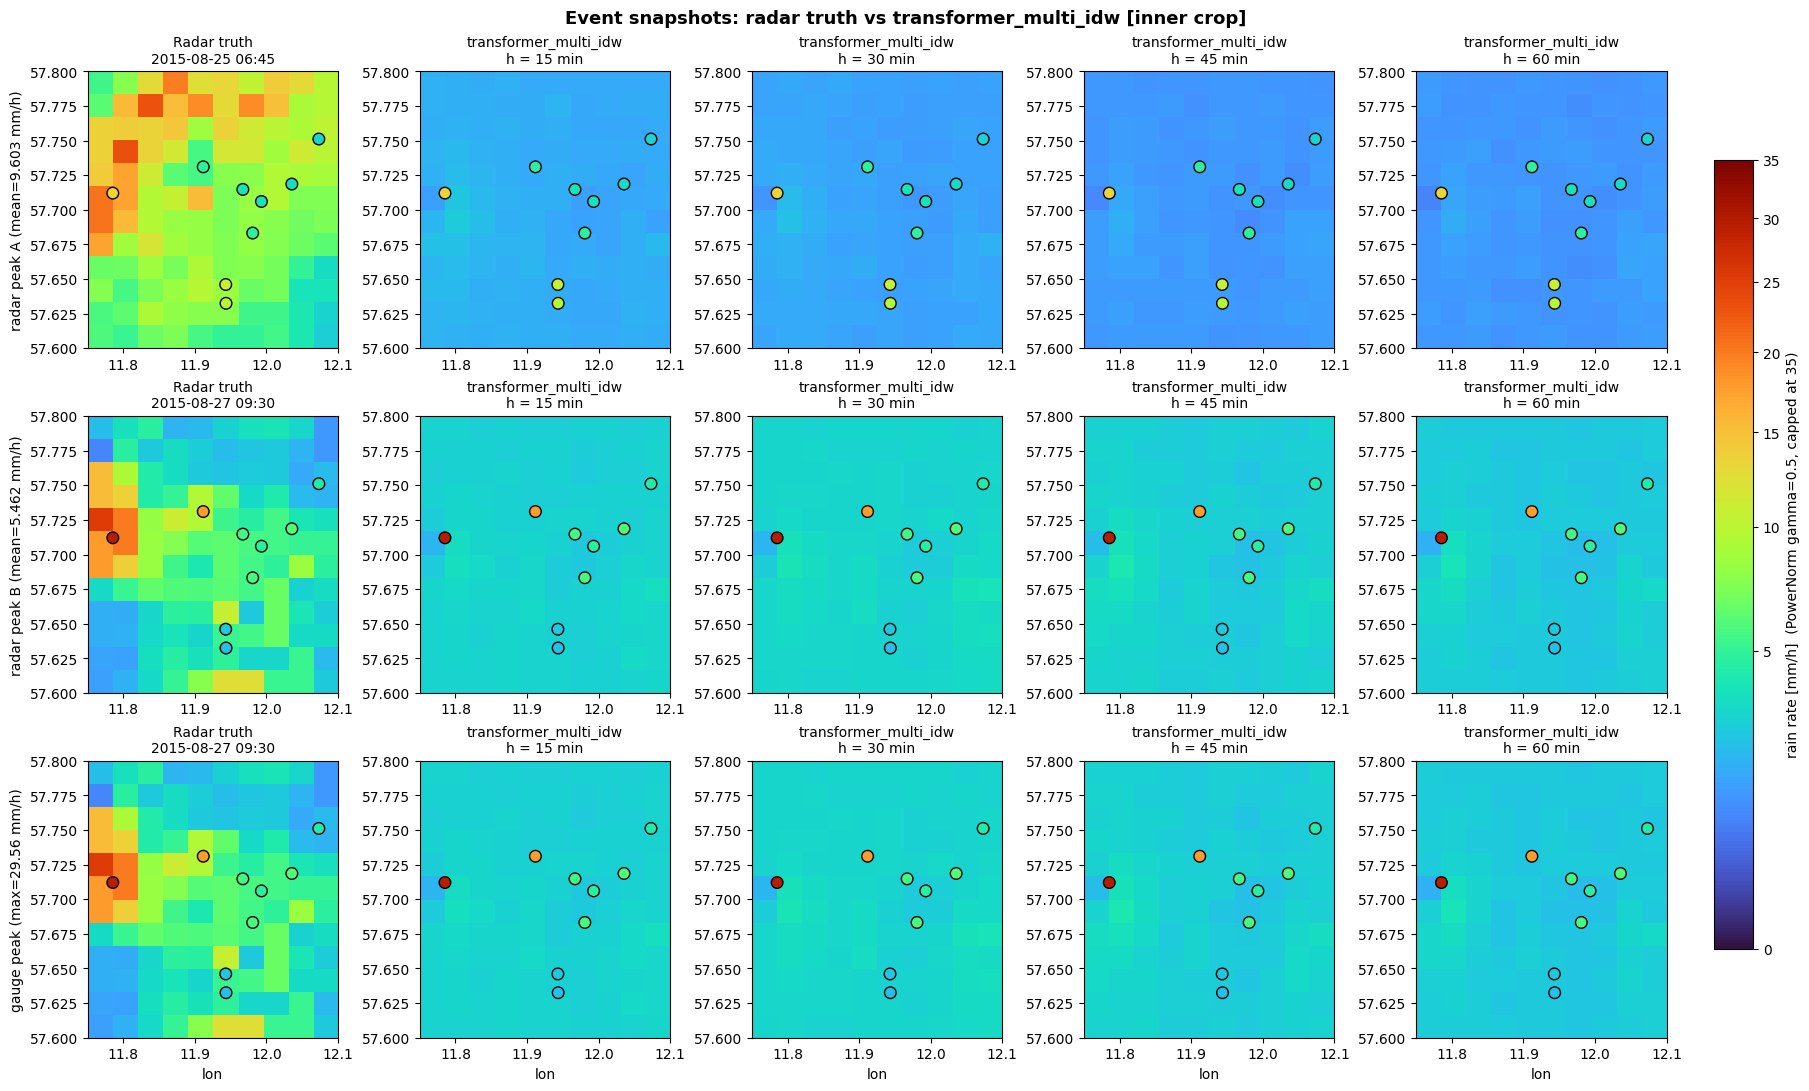

In [ ]:
event_scenarios_inner = plot_event_snapshots(
    crop_field2, LAT_RANGE2, LON_RANGE2,
    gauge_lons2, gauge_lats2, gauge_aligned2,
    title_suffix=" [inner crop]",
)


## Part 8.11 - Event snapshots: h=60 min multi-model comparison [inner crop]

Identical to Part~6.11 but on the inner crop. Reuses the helper
\texttt{plot\_h60\_multi\_model\_snapshots} defined in Part~6.11
with the inner-crop variables.

**Inputs:** Part-6.11 helper, \texttt{crop\_field2}, \texttt{LAT\_RANGE2}, \texttt{LON\_RANGE2}, inner gauges.
**Outputs:** one figure for the inner crop.


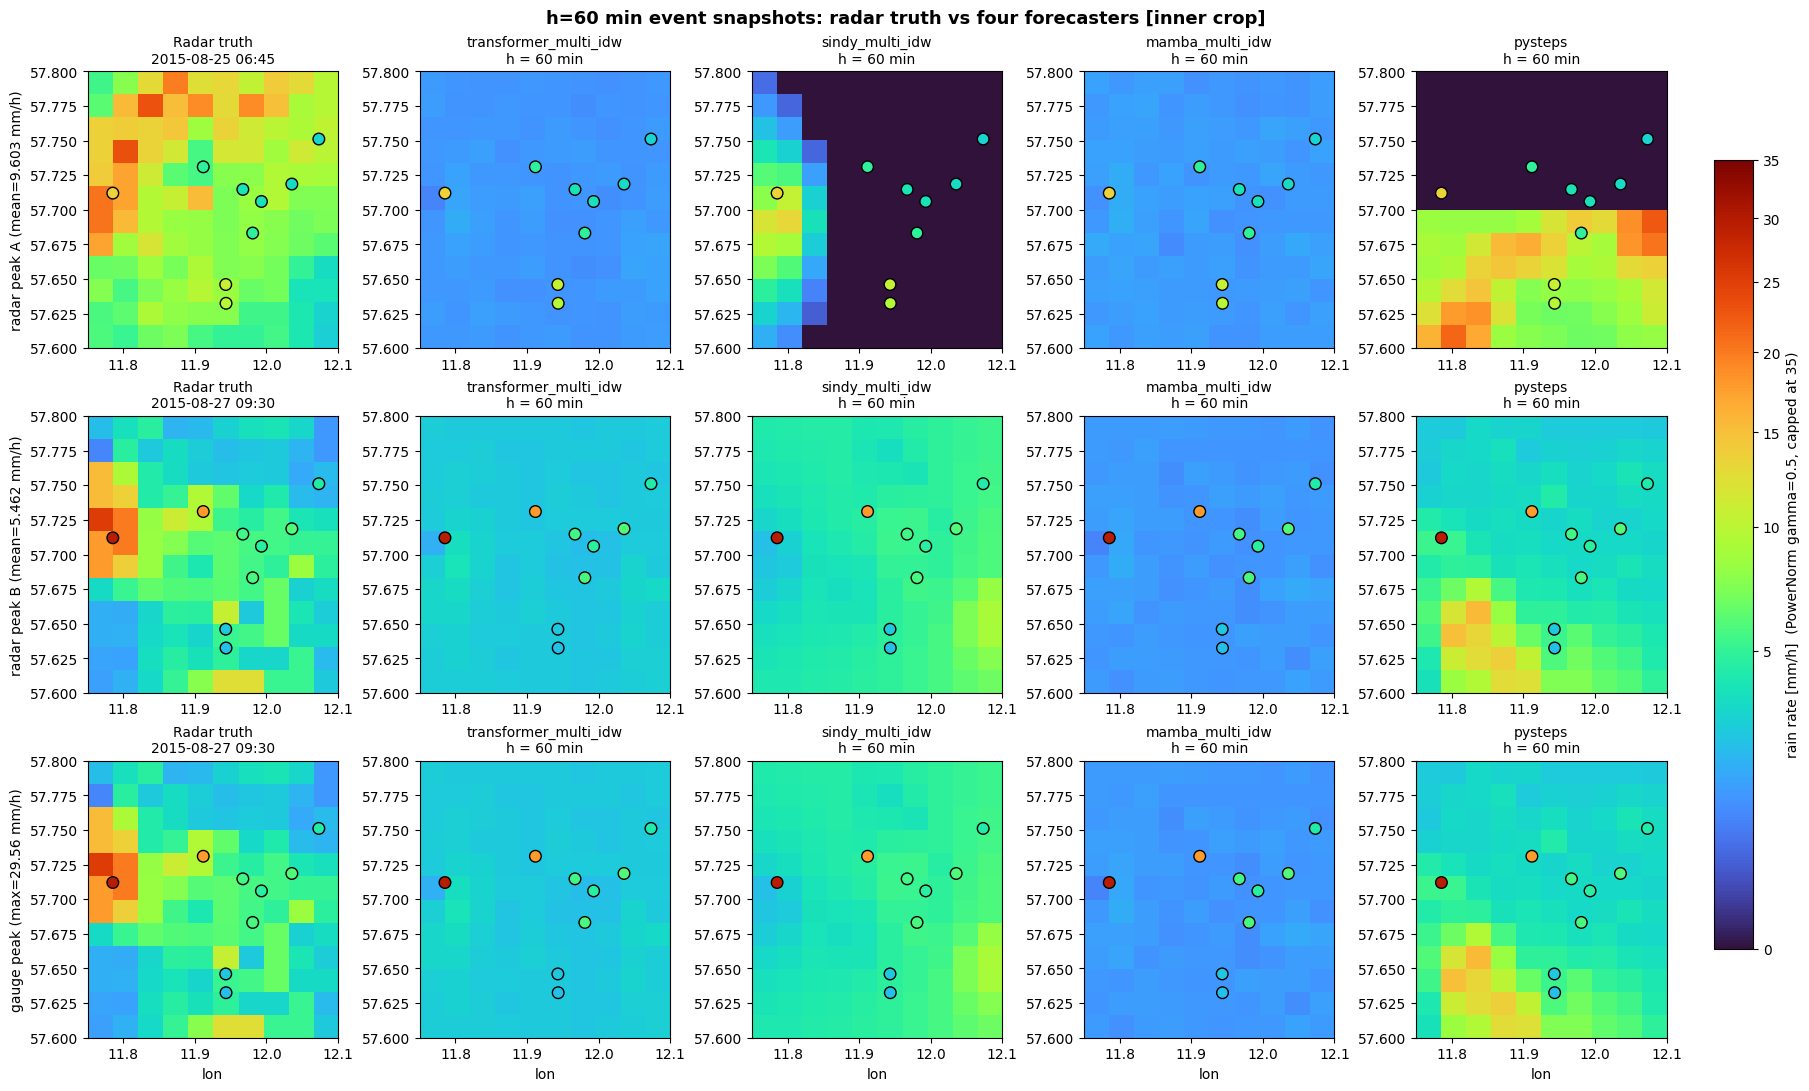

In [ ]:
event_scenarios_h60_inner = plot_h60_multi_model_snapshots(
    crop_field2, LAT_RANGE2, LON_RANGE2,
    gauge_lons2, gauge_lats2, gauge_aligned2,
    title_suffix=" [inner crop]",
)


## Part 8.12 - Focused line plots [inner crop]

The same focused line comparison as Part~6.12, restricted to the inner
crop. The radar curve uses \texttt{df\_radar2} (already computed in
Part~8.4). The gauge curve is computed inline against the inner-crop
gauge subset \texttt{gauge\_aligned2} (the full gauge evaluation was
intentionally dropped in Part~8 because the inner crop contains only a
handful of stations; we re-introduce it here in compact form purely
for visual comparison, with the same caveat that the gauge sample is
small).

**Inputs:** \texttt{df\_radar2}, \texttt{gauge\_aligned2}, \texttt{MODEL\_REGISTRY}.
**Outputs:** Up to 2 line charts (gauge chart skipped if no gauges are inside the inner crop).


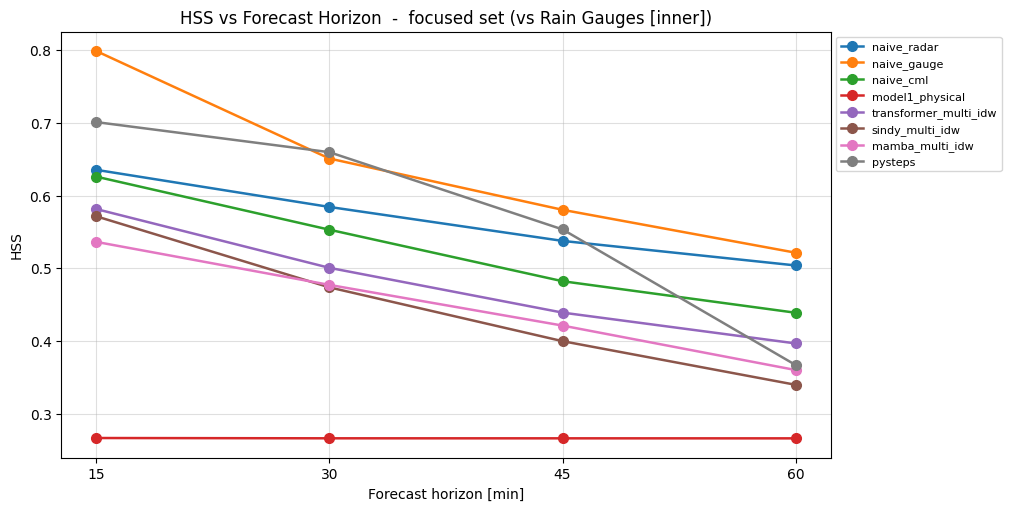

Top 3 at h=60 min vs Rain Gauges [inner] - HSS (higher is better):
  1. naive_gauge                      HSS = 0.5213
  2. naive_radar                      HSS = 0.5038
  3. naive_cml                        HSS = 0.4387



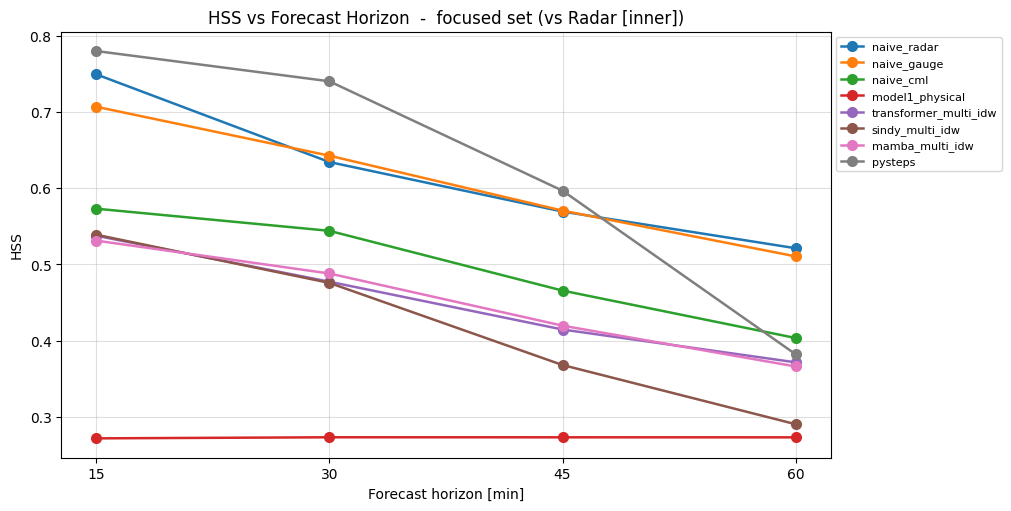

Top 3 at h=60 min vs Radar [inner] - HSS (higher is better):
  1. naive_radar                      HSS = 0.5213
  2. naive_gauge                      HSS = 0.5106
  3. naive_cml                        HSS = 0.4035



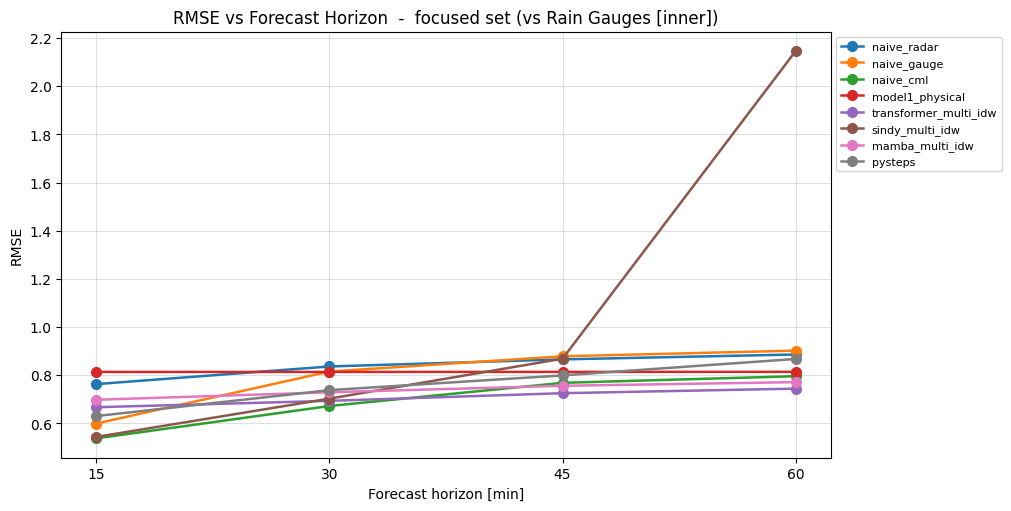

Top 3 at h=60 min vs Rain Gauges [inner] - RMSE (lower is better):
  1. transformer_multi_idw            RMSE = 0.7447
  2. mamba_multi_idw                  RMSE = 0.7716
  3. naive_cml                        RMSE = 0.7964



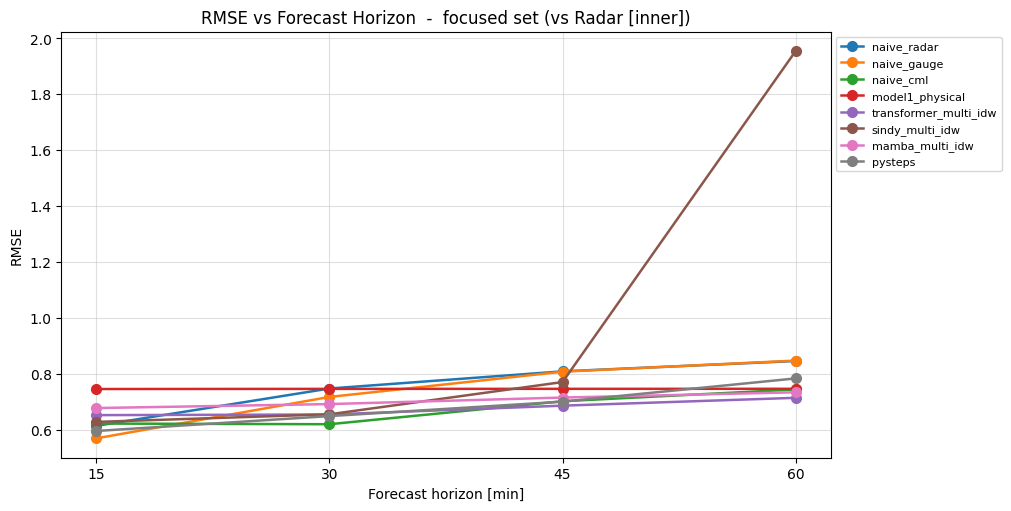

Top 3 at h=60 min vs Radar [inner] - RMSE (lower is better):
  1. transformer_multi_idw            RMSE = 0.7142
  2. mamba_multi_idw                  RMSE = 0.7340
  3. naive_cml                        RMSE = 0.7442



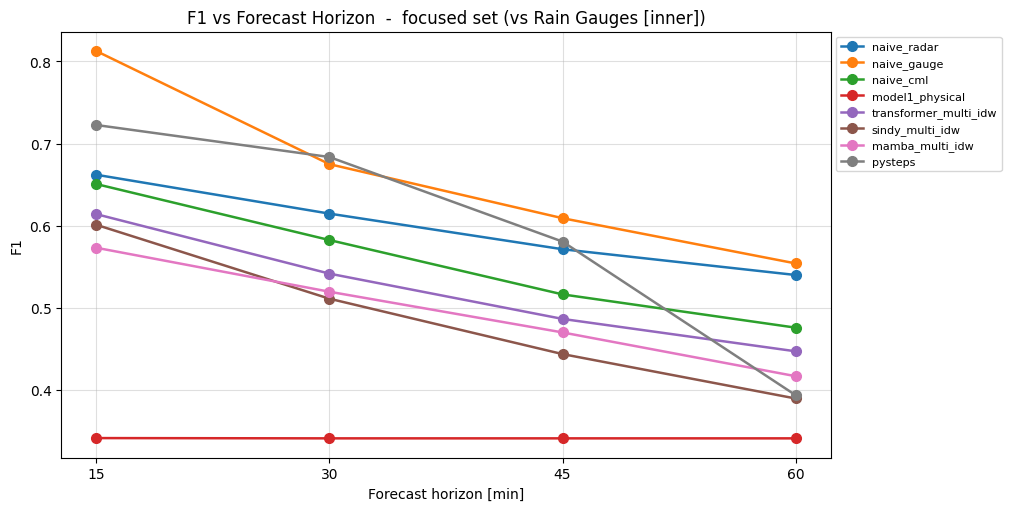

Top 3 at h=60 min vs Rain Gauges [inner] - F1 (higher is better):
  1. naive_gauge                      F1 = 0.5541
  2. naive_radar                      F1 = 0.5400
  3. naive_cml                        F1 = 0.4759



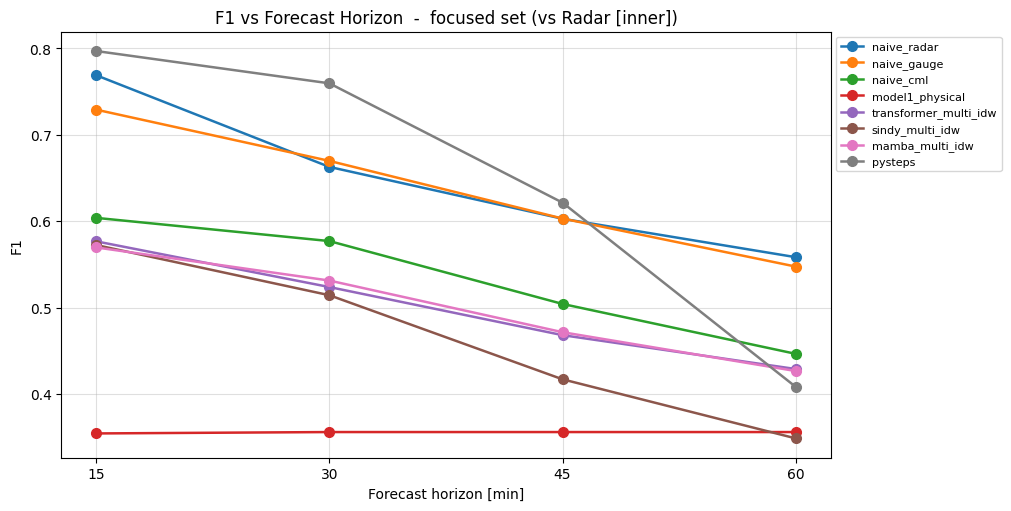

Top 3 at h=60 min vs Radar [inner] - F1 (higher is better):
  1. naive_radar                      F1 = 0.5585
  2. naive_gauge                      F1 = 0.5476
  3. naive_cml                        F1 = 0.4466



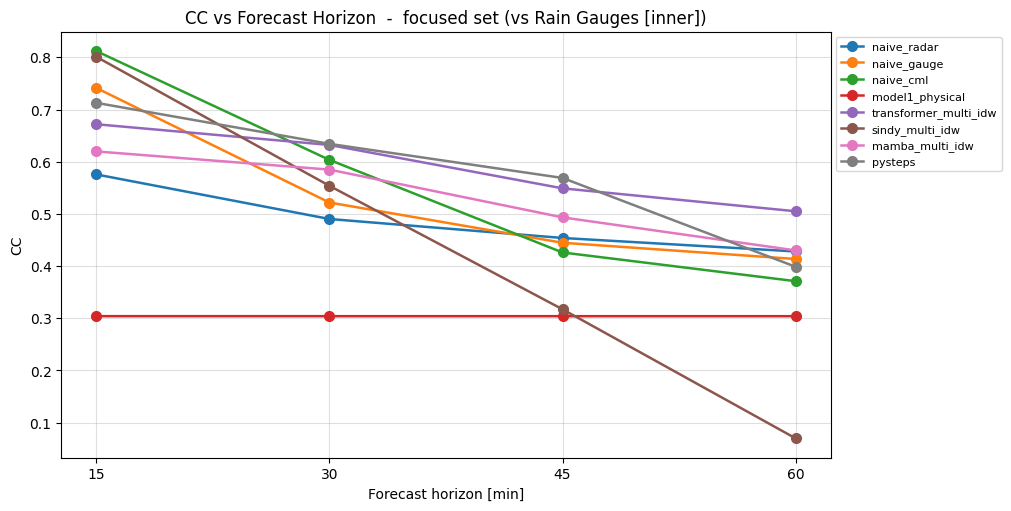

Top 3 at h=60 min vs Rain Gauges [inner] - CC (higher is better):
  1. transformer_multi_idw            CC = 0.5050
  2. mamba_multi_idw                  CC = 0.4299
  3. naive_radar                      CC = 0.4280



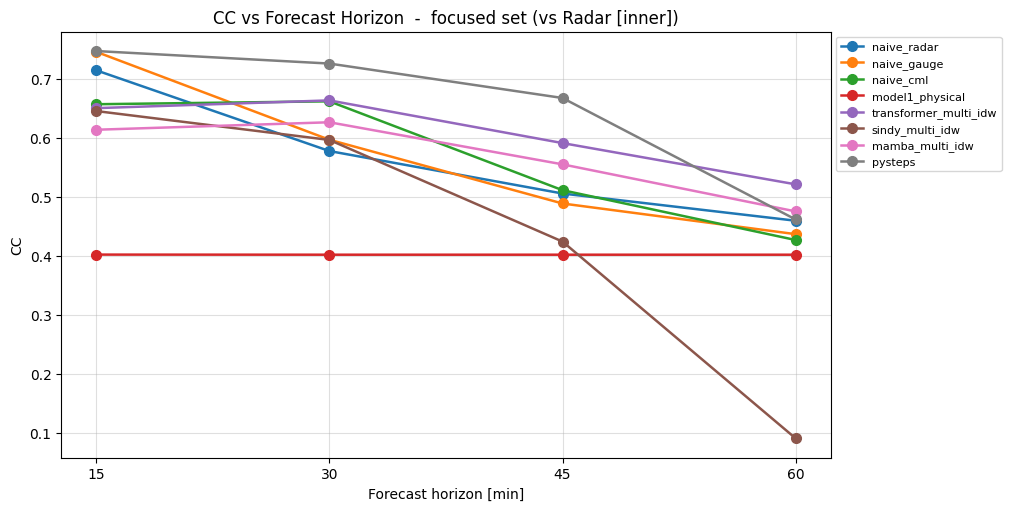

Top 3 at h=60 min vs Radar [inner] - CC (higher is better):
  1. transformer_multi_idw            CC = 0.5214
  2. mamba_multi_idw                  CC = 0.4755
  3. pysteps                          CC = 0.4618



In [ ]:
# Reuse FOCUS_MODELS_LINE and _focus_colors / _line_focus from Part 6.11
_focus_r_inner = df_radar2[df_radar2["model"].isin(FOCUS_MODELS_LINE)].copy()

# Compute focused gauge metrics inline using the inner gauges, if any.
if gauge_aligned2.shape[1] > 0:
    _rows = []
    for mname in FOCUS_MODELS_LINE:
        mdict = MODEL_REGISTRY.get(mname, {})
        for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
            pred = mdict.get(h_min)
            if pred is None:
                continue
            n = pred.shape[0]
            start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
            gt = gauge_aligned2.values[start : start + n]
            if gt.shape[0] != n:
                continue
            p_at_g = extract_pixels_fast(pred, lon2d, lat2d, gauge_lons2, gauge_lats2)
            m = compute_metrics(gt, p_at_g)
            _rows.append({"model": mname, "horizon_min": h_min, **m})
    _focus_g_inner = pd.DataFrame(_rows)
else:
    _focus_g_inner = pd.DataFrame()

for _metric, _hi_better in [("HSS", True), ("RMSE", False), ("F1", True), ("CC", True)]:
    if not _focus_g_inner.empty:
        _line_focus(_focus_g_inner, "Rain Gauges [inner]", _metric, _hi_better)
    else:
        print(f"No gauges inside the inner crop - skipping {_metric} gauge chart.")
    _line_focus(_focus_r_inner, "Radar [inner]", _metric, _hi_better)


# PART 9 - FORECAST VIDEOS

Side-by-side MP4 animations: **radar truth** (left) and the
**top-K best forecasts** (one model per video) over a multi-frame
window of the test split. Rain gauges are overlaid on every panel as
circles whose fill colour encodes the actual gauge reading at that
time, using the same colour map and normalisation as the field, so
visual agreement between background field and gauge fill indicates
accuracy.

**Selection criterion.** Top-K is computed from `df_gauge2` by mean
`HSS` across all four horizons (higher is better). The video uses
the 30-min horizon by default (`H_VIDEO`).

**Time window.** A `WINDOW_FRAMES`-long span around the test-window
peak rainfall frame (default 60 frames = 15 hours at 15-min cadence).


## Part 9.1 - Configure per-horizon videos [inner crop]

Same as Part 7.1 but using the inner-crop variables (`test_means2`,
`gauge_aligned2`, etc.). One MP4 per horizon will be rendered in the
next cell.

**Inputs:** `MODEL_REGISTRY`, `radar_15`, `test_means2`.
**Outputs:** `VIDEO_MODELS_INNER`, `event_window_for_h_inner` (dict h_min -> (lo, hi)).


In [ ]:
MAP_TYPE_VIDEO_INNER = "idw"          # which CML map source: "idw" or "gmz"
WINDOW_FRAMES_INNER  = 60
FPS_VIDEO_INNER      = 4 / 3   # 3x slower than the previous 4 fps default
VIDEOS_DIR_INNER     = os.path.join(base_path, "videos_inner")
os.makedirs(VIDEOS_DIR_INNER, exist_ok=True)

VIDEO_MODELS_INNER = [
    "pysteps",
    f"mamba_multi_{MAP_TYPE_VIDEO_INNER}",
    f"transformer_multi_{MAP_TYPE_VIDEO_INNER}",
    f"sindy_multi_{MAP_TYPE_VIDEO_INNER}",
]
print(f"Inner video forecaster panels (in order): {VIDEO_MODELS_INNER}")

for h in HORIZONS_MIN:
    missing = [m for m in VIDEO_MODELS_INNER
               if (m not in MODEL_REGISTRY)
               or (h not in MODEL_REGISTRY[m])
               or (MODEL_REGISTRY[m][h] is None)]
    if missing:
        print(f"  WARNING h={h}min: missing {missing}")

peak_local_inner = int(np.argmax(test_means2))
event_window_for_h_inner = {}
for h_min in HORIZONS_MIN:
    h_step = h_min // 15
    pred_peak = max(0, peak_local_inner - LOOKBACK_WINDOW - h_step + 1)
    ref_arr = None
    for m in VIDEO_MODELS_INNER:
        if m in MODEL_REGISTRY and h_min in MODEL_REGISTRY[m] and MODEL_REGISTRY[m][h_min] is not None:
            ref_arr = MODEL_REGISTRY[m][h_min]; break
    if ref_arr is None:
        print(f"  h={h_min}: no model available - skipping")
        continue
    N = ref_arr.shape[0]
    half = WINDOW_FRAMES_INNER // 2
    lo = max(0, pred_peak - half)
    hi = min(N, lo + WINDOW_FRAMES_INNER)
    lo = max(0, hi - WINDOW_FRAMES_INNER)
    event_window_for_h_inner[h_min] = (lo, hi)
    print(f"  h={h_min:>3d}min: prediction window [{lo}..{hi})  pred_peak={pred_peak}  N={N}")


Inner video forecaster panels (in order): ['pysteps', 'mamba_multi_idw', 'transformer_multi_idw', 'sindy_multi_idw']
  h= 15min: prediction window [1813..1873)  pred_peak=1843  N=2485
  h= 30min: prediction window [1812..1872)  pred_peak=1842  N=2485
  h= 45min: prediction window [1811..1871)  pred_peak=1841  N=2485
  h= 60min: prediction window [1810..1870)  pred_peak=1840  N=2485


## Part 9.2 - Render one MP4 per horizon [inner crop]

Reuses `build_5panel_video()` defined in Part 7.2, but passes the
inner-crop functions and arrays as keyword arguments. Output files
are named `forecast_inner_h{h_min}min.mp4` and saved under
`videos_inner/`.

**Inputs:** `VIDEO_MODELS_INNER`, `event_window_for_h_inner`, `crop_field2`, `LAT_RANGE2`, `LON_RANGE2`, inner gauges.
**Outputs:** `videos_inner/forecast_inner_h{15,30,45,60}min.mp4`.


In [ ]:
# Override the FPS used inside build_5panel_video for the inner render
FPS_VIDEO = FPS_VIDEO_INNER

video_paths_inner = []
for h_min in HORIZONS_MIN:
    if h_min not in event_window_for_h_inner:
        continue
    lo, hi = event_window_for_h_inner[h_min]
    print(f"Rendering inner h={h_min} min ...")
    p = build_5panel_video(
        h_min, VIDEO_MODELS_INNER, lo, hi, VIDEOS_DIR_INNER,
        file_suffix="_inner",
        crop_fn=crop_field2,
        lat_range=LAT_RANGE2, lon_range=LON_RANGE2,
        g_lons=gauge_lons2, g_lats=gauge_lats2,
        g_at_time=gauge_values_at_time_2,
    )
    sz = os.path.getsize(p) / 1024**2
    print(f"  wrote {p}  ({sz:.2f} MB)")
    video_paths_inner.append(p)
print(f"\n{len(video_paths_inner)} inner video(s) saved under {VIDEOS_DIR_INNER}/")


Rendering inner h=15 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos_inner/forecast_inner_h15min.mp4  (1.43 MB)
Rendering inner h=30 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos_inner/forecast_inner_h30min.mp4  (1.43 MB)
Rendering inner h=45 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos_inner/forecast_inner_h45min.mp4  (1.44 MB)
Rendering inner h=60 min ...
  wrote /content/drive/MyDrive/FieldSense_Project_v2/videos_inner/forecast_inner_h60min.mp4  (1.36 MB)

4 inner video(s) saved under /content/drive/MyDrive/FieldSense_Project_v2/videos_inner/


# PART 10 - Extended Horizon Analysis: 30-Minute and 60-Minute Forecast Maps

Previous chapters evaluated every advanced forecaster across the full
horizon set $h \in \{15, 30, 45, 60\}$ minutes simultaneously. This
chapter zooms in on the two practically most useful intervals:

* **30 minutes** -- the lead time at which flash-flood early-warning
  systems can trigger shelter-in-place advisories, traffic rerouting,
  and active drainage-gate operation.
* **60 minutes** -- relevant for urban drainage management, real-time
  reservoir operation, and short-range boundary conditions for
  hydrological models.

What this chapter produces:

1. Full spatial map arrays for every registered model at
   $h\in\{30, 60\}$ min, verified or regenerated from cached weights.
2. Statistical evaluation against the rain-gauge cluster, replicating
   the methodology of Part 6 exactly (metrics, threshold, bar-chart
   style, top-3 annotation).
3. Statistical evaluation against the SMHI radar field, replicating the
   methodology of Part 8.
4. A horizon-comparison summary (RMSE / HSS as a function of $h$).
5. Five case-study figures, one per high-intensity rain event from a
   distinct calendar day of the test split.

\textbf{Aggregation convention for radar / gauge ground truth.} The
ground-truth field at horizon $h$ is the trailing mean of the $k=h/15$
preceding 15-min reference frames:
$$\bar R(t,\, h) = \frac{1}{k}\sum_{i=1}^{k} R\bigl(t - (k-i)\!\cdot\!15\,\text{min}\bigr).$$
For $h=15$ this reduces to the instantaneous frame used in Part~6;
for $h=30$ and $h=60$ it averages two and four consecutive 15-min
frames respectively. Caching: every artifact is checked on Drive via
\texttt{exists()} before being recomputed.


## Part 10.1 - Load 30-min and 60-min prediction maps for every model

The four-horizon prediction arrays were produced during the training
runs of Parts~5.5, 5.8 and 5.10 (advanced models on Model-2 maps),
Parts~5D (full-period), Part~5B (pySTEPS), and Part~4 (naive
baselines). They are already accessible through \texttt{MODEL\_REGISTRY}
populated in Part~6.2. This cell builds two convenience dictionaries,
\texttt{maps\_30} and \texttt{maps\_60}, keyed by model name. If a
particular file is missing on Drive, the model is reported as
unavailable and skipped (re-running the corresponding training cell in
Part~5 is the regeneration path; no inference is repeated here to
avoid silent retraining).

**Inputs:** \texttt{MODEL\_REGISTRY} (from Part~6.2).
**Outputs:** \texttt{maps\_30}, \texttt{maps\_60} (dicts of \texttt{(T,H,W)} arrays).


In [ ]:
maps_30, maps_60 = {}, {}
missing_30, missing_60 = [], []
for model_name, h_dict in MODEL_REGISTRY.items():
    arr30 = h_dict.get(30)
    arr60 = h_dict.get(60)
    if arr30 is not None:
        maps_30[model_name] = arr30
    else:
        missing_30.append(model_name)
    if arr60 is not None:
        maps_60[model_name] = arr60
    else:
        missing_60.append(model_name)

print(f"Models with h=30 maps available: {len(maps_30)} / {len(MODEL_REGISTRY)}")
print(f"Models with h=60 maps available: {len(maps_60)} / {len(MODEL_REGISTRY)}")
if missing_30:
    print(f"  missing h=30: {missing_30}")
if missing_60:
    print(f"  missing h=60: {missing_60}")

print()
print(f"{'model':<35s}  {'h=30':<8s}  {'h=60':<8s}  shape")
print("-" * 80)
for m in MODEL_REGISTRY.keys():
    sh30 = "yes" if m in maps_30 else "no"
    sh60 = "yes" if m in maps_60 else "no"
    shape_ref = (maps_30.get(m) if m in maps_30 else maps_60.get(m))
    shape_str = str(shape_ref.shape) if shape_ref is not None else "-"
    print(f"  {m:<33s}  {sh30:<8s}  {sh60:<8s}  {shape_str}")


Models with h=30 maps available: 23 / 23
Models with h=60 maps available: 23 / 23

model                                h=30      h=60      shape
--------------------------------------------------------------------------------
  naive_radar                        yes       yes       (2488, 48, 37)
  naive_gauge                        yes       yes       (2488, 48, 37)
  naive_cml                          yes       yes       (2488, 48, 37)
  model1_physical                    yes       yes       (2488, 48, 37)
  transformer_single_idw             yes       yes       (2487, 48, 37)
  transformer_multi_idw              yes       yes       (2485, 48, 37)
  transformer_single_gmz             yes       yes       (2487, 48, 37)
  transformer_multi_gmz              yes       yes       (2485, 48, 37)
  sindy_single_idw                   yes       yes       (2487, 48, 37)
  sindy_multi_idw                    yes       yes       (2485, 48, 37)
  sindy_single_gmz                   yes       yes   

## Part 10.2 - Radar ground truth at 30-min and 60-min aggregation

The openMRG radar composite is at native 15-min cadence. To obtain
trailing-mean ground-truth fields at $h\in\{30, 60\}$, we apply

$$\bar R(t, h) = \frac{1}{k}\sum_{i=1}^{k} R\bigl(t - (k-i)\cdot 15\,\text{min}\bigr),
\qquad k = h / 15.$$

Concretely, $\bar R_{30}(t)$ is the average of \texttt{radar\_15} at
times $t-15$ and $t$ (two frames), and $\bar R_{60}(t)$ averages four
consecutive frames ending at $t$. The result has the same shape as
\texttt{radar\_15} and the same time axis (\texttt{radar\_times}); the
first $k-1$ entries are partial averages computed from fewer frames.

**Inputs:** \texttt{radar\_15}, \texttt{radar\_times}.
**Outputs:** \texttt{radar\_gt\_30min}, \texttt{radar\_gt\_60min} (cached \texttt{.npy}).


In [ ]:
RADAR_GT_30_PATH = os.path.join(PROCESSED_DIR, "radar_gt_30min.npy")
RADAR_GT_60_PATH = os.path.join(PROCESSED_DIR, "radar_gt_60min.npy")

def _trailing_mean_3d(arr, k):
    """Trailing mean of k frames along axis 0 (partial at the start)."""
    T = arr.shape[0]
    cum = np.cumsum(np.concatenate([np.zeros_like(arr[:1]), arr], axis=0), axis=0)
    out = np.empty_like(arr)
    for t in range(T):
        lo = max(0, t - k + 1)
        out[t] = (cum[t + 1] - cum[lo]) / float(t - lo + 1)
    return out

if exists(RADAR_GT_30_PATH):
    radar_gt_30min = np.load(RADAR_GT_30_PATH)
    print(f"Loaded {RADAR_GT_30_PATH}")
else:
    print("Aggregating radar_gt_30min ...")
    radar_gt_30min = _trailing_mean_3d(radar_15, 2).astype(np.float32)
    np.save(RADAR_GT_30_PATH, radar_gt_30min)
    print(f"  saved {RADAR_GT_30_PATH}")

if exists(RADAR_GT_60_PATH):
    radar_gt_60min = np.load(RADAR_GT_60_PATH)
    print(f"Loaded {RADAR_GT_60_PATH}")
else:
    print("Aggregating radar_gt_60min ...")
    radar_gt_60min = _trailing_mean_3d(radar_15, 4).astype(np.float32)
    np.save(RADAR_GT_60_PATH, radar_gt_60min)
    print(f"  saved {RADAR_GT_60_PATH}")

print(f"\nradar_15        : shape={radar_15.shape}        mean={radar_15.mean():.4f}")
print(f"radar_gt_30min  : shape={radar_gt_30min.shape}  mean={radar_gt_30min.mean():.4f}")
print(f"radar_gt_60min  : shape={radar_gt_60min.shape}  mean={radar_gt_60min.mean():.4f}")
print(f"Time axis aligned with radar_times (length {len(radar_times)}): "
      f"{radar_times[0]} -> {radar_times[-1]}")


Loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/radar_gt_30min.npy
Loaded /content/drive/MyDrive/FieldSense_Project_v2/data/processed/radar_gt_60min.npy

radar_15        : shape=(8832, 48, 37)        mean=0.0990
radar_gt_30min  : shape=(8832, 48, 37)  mean=0.0989
radar_gt_60min  : shape=(8832, 48, 37)  mean=0.0987
Time axis aligned with radar_times (length 8832): 2015-06-01 00:15:00 -> 2015-09-01 00:00:00


## Part 10.3 - Rain-gauge ground truth at 30-min and 60-min aggregation

The same trailing-mean rule is applied to the 15-min-aligned gauge
DataFrame \texttt{gauge\_aligned}. The result is a DataFrame with the
same index (\texttt{radar\_times}) and the same gauge columns, but
whose values at time $t$ are the average of the past $k$ gauge readings
ending at $t$.

**Inputs:** \texttt{gauge\_aligned} (from Part~1.5).
**Outputs:** \texttt{gauge\_gt\_30min}, \texttt{gauge\_gt\_60min} DataFrames.


In [ ]:
gauge_gt_30min = gauge_aligned.rolling(window=2, min_periods=1).mean().astype(np.float32)
gauge_gt_60min = gauge_aligned.rolling(window=4, min_periods=1).mean().astype(np.float32)

print(f"gauge_aligned    : shape={gauge_aligned.shape}    "
      f"mean={float(gauge_aligned.values.mean()):.4f}")
print(f"gauge_gt_30min   : shape={gauge_gt_30min.shape}   "
      f"mean={float(gauge_gt_30min.values.mean()):.4f}")
print(f"gauge_gt_60min   : shape={gauge_gt_60min.shape}   "
      f"mean={float(gauge_gt_60min.values.mean()):.4f}")
print(f"\nN gauge stations: {gauge_aligned.shape[1]}")
print(f"Time range       : {gauge_aligned.index[0]} -> {gauge_aligned.index[-1]}")


gauge_aligned    : shape=(8832, 9)    mean=0.1134
gauge_gt_30min   : shape=(8832, 9)   mean=0.1136
gauge_gt_60min   : shape=(8832, 9)   mean=0.1138

N gauge stations: 9
Time range       : 2015-06-01 00:15:00 -> 2015-09-01 00:00:00


## Part 10.4 - Statistical evaluation versus rain gauges (h=30, h=60)

Replicates the exact Part~6.3 methodology: for every model and every
horizon, we extract the predicted rain rate at each gauge pixel (via
nearest-neighbour pixel matching in \texttt{extract\_pixels\_fast}),
align it with the aggregated gauge ground-truth series over the
held-out test split, and compute the five metrics of Part~6.1
(RMSE, MAE, Bias, Pearson CC, HSS). The wet/dry threshold is
\texttt{THRESHOLD\_WET} $=0.1$ mm/h. The output is two DataFrames,
\texttt{df\_gauge\_30} and \texttt{df\_gauge\_60}, each with one row
per model.

**Inputs:** \texttt{maps\_30}, \texttt{maps\_60}, \texttt{gauge\_gt\_30min},
\texttt{gauge\_gt\_60min}, \texttt{gauge\_lons}, \texttt{gauge\_lats}.
**Outputs:** \texttt{df\_gauge\_30}, \texttt{df\_gauge\_60} DataFrames.


In [ ]:
def _eval_vs_gauges_at_h(maps_h_dict, gauge_gt_df, h_step):
    """Replicate Part 6.3 metric loop for a single horizon."""
    rows = []
    for mname, pred in maps_h_dict.items():
        if pred is None:
            continue
        n = pred.shape[0]
        start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
        gt = gauge_gt_df.values[start : start + n]
        if gt.shape[0] != n:
            continue
        p_at_g = extract_pixels_fast(pred, lon2d, lat2d, gauge_lons, gauge_lats)
        m = compute_metrics(gt, p_at_g)
        rows.append({"model": mname, "horizon_min": h_step * 15, **m})
    return pd.DataFrame(rows)

df_gauge_30 = _eval_vs_gauges_at_h(maps_30, gauge_gt_30min, h_step=2)
df_gauge_60 = _eval_vs_gauges_at_h(maps_60, gauge_gt_60min, h_step=4)

print("Table: Model evaluation vs rain gauges - h=30 minutes (trailing 2-frame mean GT)")
print(df_gauge_30.to_string(index=False, float_format="{:.4f}".format))
print()
print("Table: Model evaluation vs rain gauges - h=60 minutes (trailing 4-frame mean GT)")
print(df_gauge_60.to_string(index=False, float_format="{:.4f}".format))


Table: Model evaluation vs rain gauges - h=30 minutes (trailing 2-frame mean GT)
                     model  horizon_min    RMSE    MAE    Bias     CC    HSS     F1  Precision  Recall  n_wet_true  n_wet_pred
               naive_radar           30  0.7405 0.1231 -0.0023 0.5720 0.6223 0.6515     0.6355  0.6682        1688        1775
               naive_gauge           30  0.6477 0.1024  0.0007 0.6780 0.7363 0.7554     0.7869  0.7263        1688        1558
                 naive_cml           30  0.5272 0.0926 -0.0518 0.7598 0.6058 0.6332     0.6872  0.5871        1688        1442
           model1_physical           30  0.6886 0.1685 -0.0147 0.4762 0.2959 0.3738     0.2548  0.7014        1688        4647
    transformer_single_idw           30  0.6242 0.1197 -0.0755 0.6920 0.5754 0.6111     0.5482  0.6902        1688        2125
     transformer_multi_idw           30  0.6180 0.1169 -0.0588 0.6911 0.5513 0.5905     0.5047  0.7114        1670        2354
    transformer_single_gmz    

## Part 10.5 - Bar charts vs rain gauges (h=30, h=60)

Reuses \texttt{plot\_metric\_bars} from Part~6.5 unchanged: distinct
qualitative colour palette with the interleaved \texttt{tab20}/\texttt{tab20b}/\texttt{tab20c}
ordering, top-3 annotation printed after each chart. Two horizons
times three metrics = six charts.


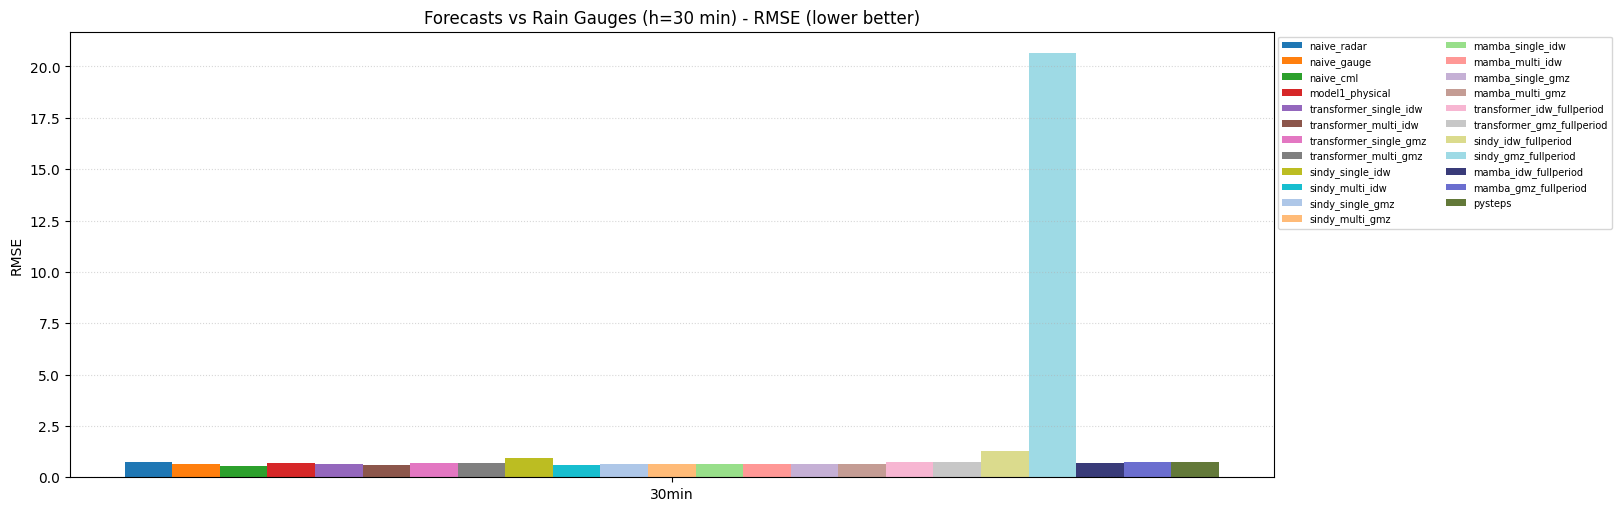


TOP 3 MODELS — RMSE (lower is better):
  h=30min:
    1. naive_cml                      RMSE=0.5272
    2. sindy_multi_idw                RMSE=0.5836
    3. transformer_multi_idw          RMSE=0.6180



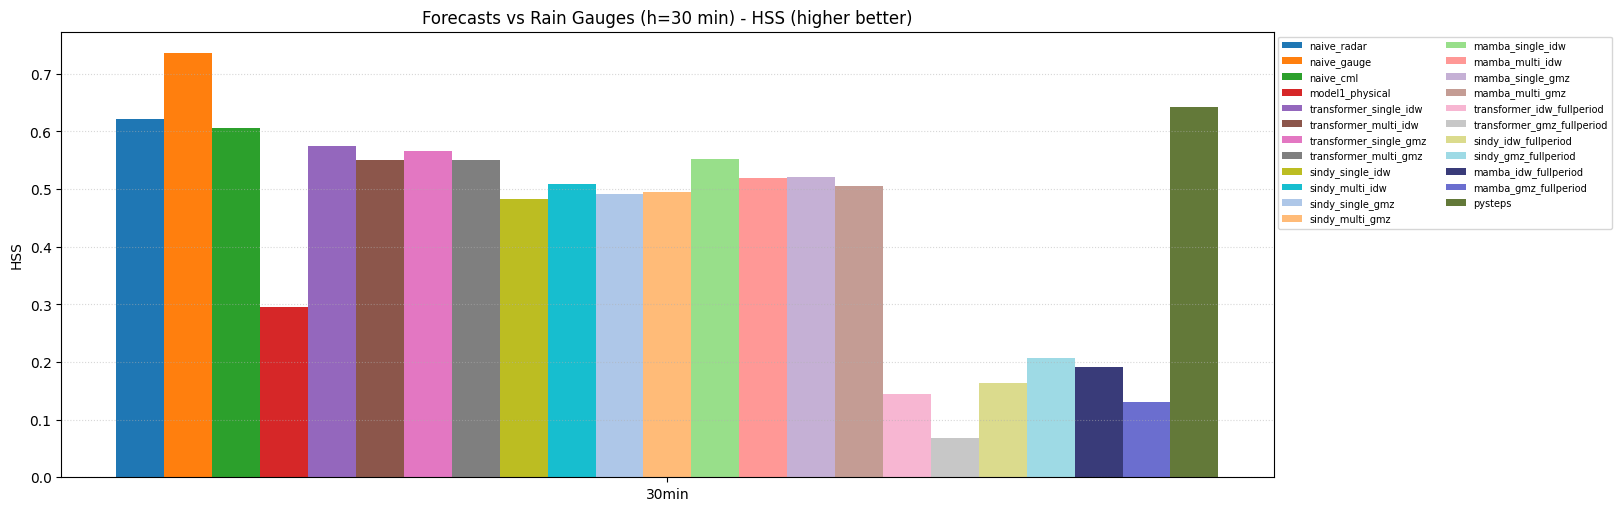


TOP 3 MODELS — HSS (higher is better):
  h=30min:
    1. naive_gauge                    HSS=0.7363
    2. pysteps                        HSS=0.6433
    3. naive_radar                    HSS=0.6223



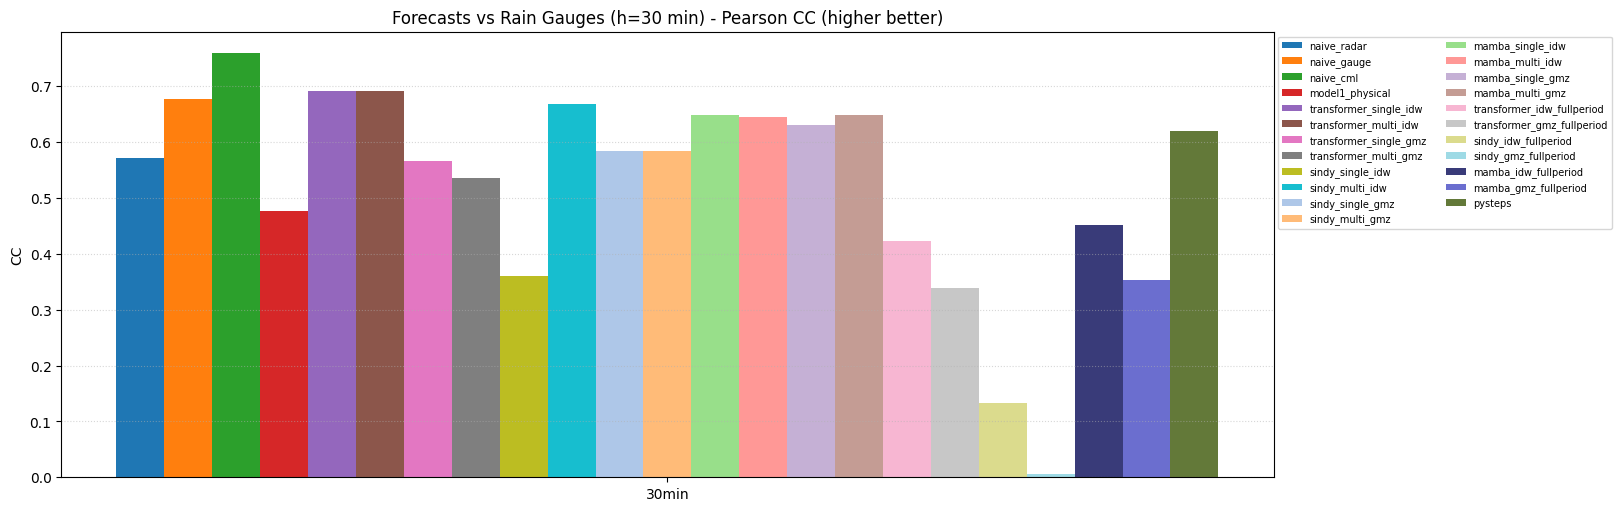


TOP 3 MODELS — CC (higher is better):
  h=30min:
    1. naive_cml                      CC=0.7598
    2. transformer_single_idw         CC=0.6920
    3. transformer_multi_idw          CC=0.6911



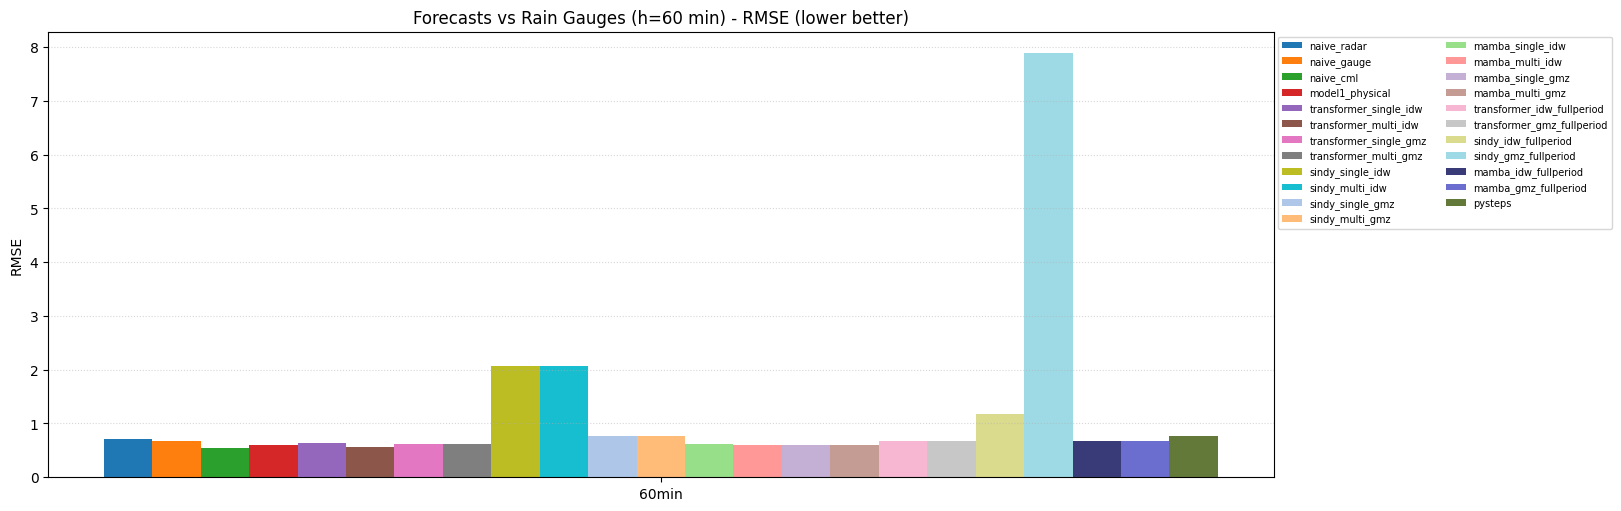


TOP 3 MODELS — RMSE (lower is better):
  h=60min:
    1. naive_cml                      RMSE=0.5355
    2. transformer_multi_idw          RMSE=0.5647
    3. mamba_multi_gmz                RMSE=0.5936



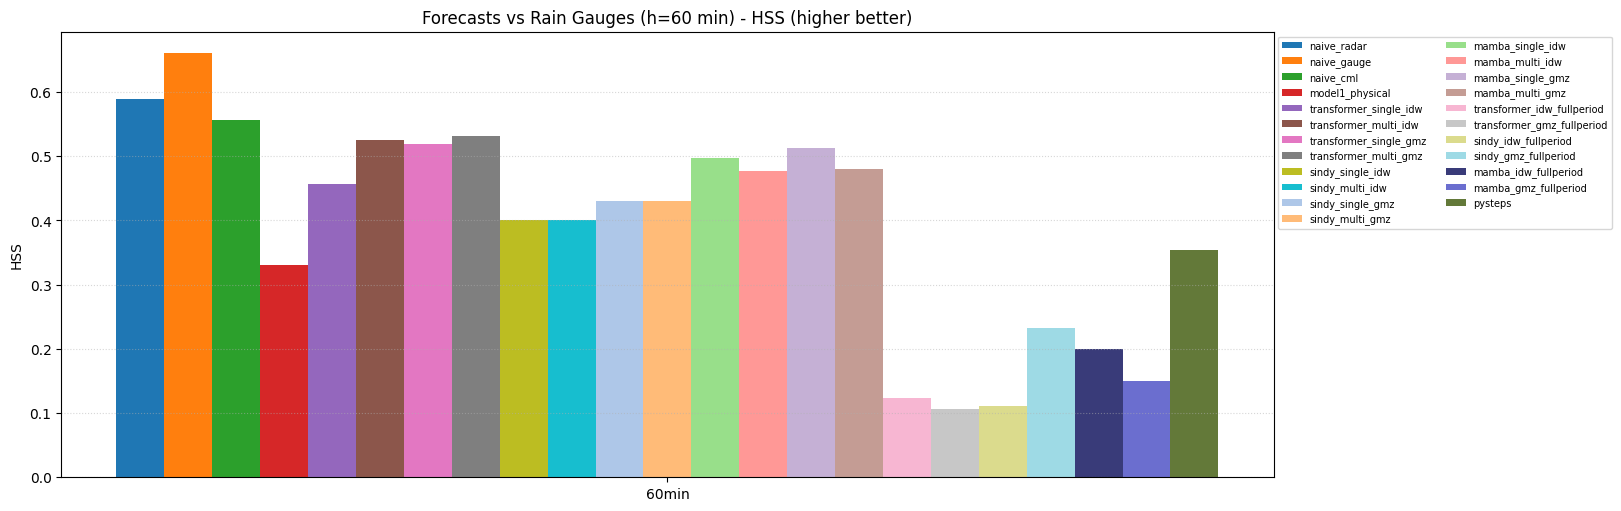


TOP 3 MODELS — HSS (higher is better):
  h=60min:
    1. naive_gauge                    HSS=0.6608
    2. naive_radar                    HSS=0.5885
    3. naive_cml                      HSS=0.5562



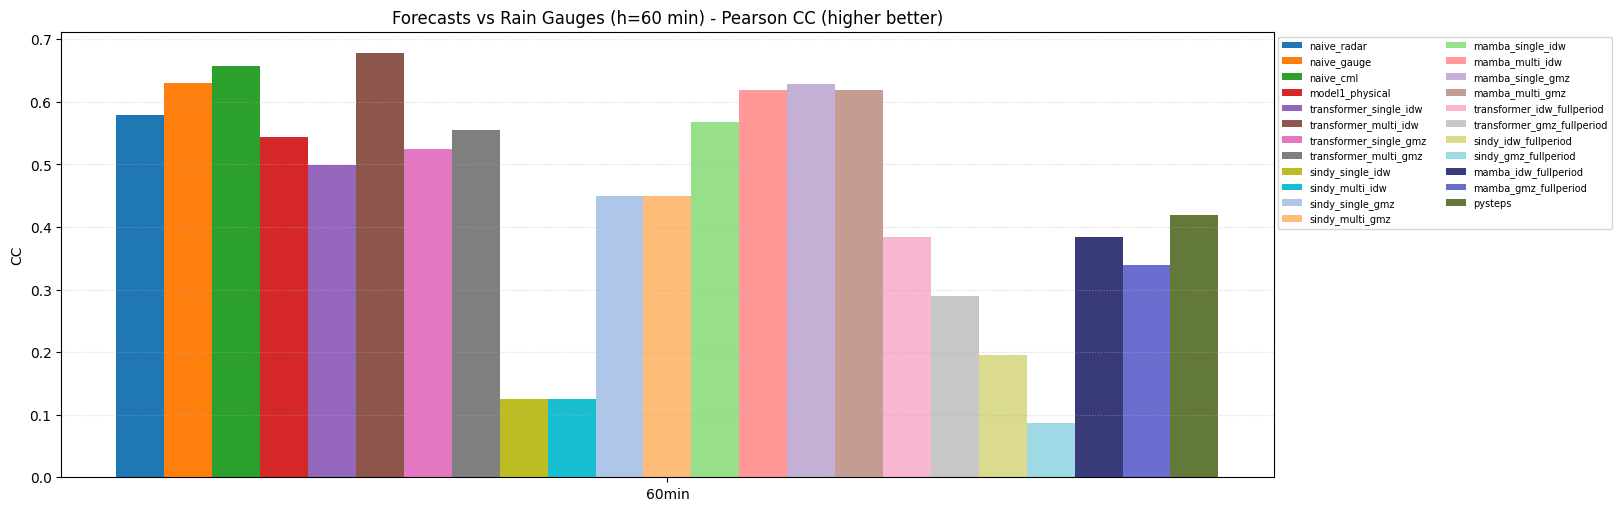


TOP 3 MODELS — CC (higher is better):
  h=60min:
    1. transformer_multi_idw          CC=0.6782
    2. naive_cml                      CC=0.6570
    3. naive_gauge                    CC=0.6308



In [ ]:
plot_metric_bars(df_gauge_30, "RMSE", "Forecasts vs Rain Gauges (h=30 min) - RMSE (lower better)", True)
plot_metric_bars(df_gauge_30, "HSS",  "Forecasts vs Rain Gauges (h=30 min) - HSS (higher better)",  False)
plot_metric_bars(df_gauge_30, "CC",   "Forecasts vs Rain Gauges (h=30 min) - Pearson CC (higher better)", False)

plot_metric_bars(df_gauge_60, "RMSE", "Forecasts vs Rain Gauges (h=60 min) - RMSE (lower better)", True)
plot_metric_bars(df_gauge_60, "HSS",  "Forecasts vs Rain Gauges (h=60 min) - HSS (higher better)",  False)
plot_metric_bars(df_gauge_60, "CC",   "Forecasts vs Rain Gauges (h=60 min) - Pearson CC (higher better)", False)


## Part 10.6 - Statistical evaluation versus radar (h=30, h=60)

Replicates Part~8.4: pixel-by-pixel comparison against the aggregated
radar GT field. All metrics are computed over the cropped Gothenburg
domain (\texttt{crop\_field}) so that fringe pixels do not dominate
the averages. The result is two DataFrames,
\texttt{df\_radar\_30} and \texttt{df\_radar\_60}.

**Inputs:** \texttt{maps\_30}, \texttt{maps\_60}, \texttt{radar\_gt\_30min}, \texttt{radar\_gt\_60min}.
**Outputs:** \texttt{df\_radar\_30}, \texttt{df\_radar\_60} DataFrames.


In [ ]:
def _eval_vs_radar_at_h(maps_h_dict, radar_gt_arr, h_step):
    """Replicate Part 6.4 / 8.4 metric loop for a single horizon."""
    rows = []
    for mname, pred in maps_h_dict.items():
        if pred is None:
            continue
        n = pred.shape[0]
        start = TEST_LO + LOOKBACK_WINDOW + h_step - 1
        gt = radar_gt_arr[start : start + n]
        if gt.shape[0] != n:
            continue
        m = compute_metrics(crop_field(gt), crop_field(pred))
        rows.append({"model": mname, "horizon_min": h_step * 15, **m})
    return pd.DataFrame(rows)

df_radar_30 = _eval_vs_radar_at_h(maps_30, radar_gt_30min, h_step=2)
df_radar_60 = _eval_vs_radar_at_h(maps_60, radar_gt_60min, h_step=4)

print("Table: Model evaluation vs SMHI radar - h=30 min (trailing 2-frame mean GT, cropped)")
print(df_radar_30.to_string(index=False, float_format="{:.4f}".format))
print()
print("Table: Model evaluation vs SMHI radar - h=60 min (trailing 4-frame mean GT, cropped)")
print(df_radar_60.to_string(index=False, float_format="{:.4f}".format))


Table: Model evaluation vs SMHI radar - h=30 min (trailing 2-frame mean GT, cropped)
                     model  horizon_min   RMSE    MAE    Bias     CC    HSS     F1  Precision  Recall  n_wet_true  n_wet_pred
               naive_radar           30 0.6073 0.1007 -0.0008 0.6882 0.6990 0.7234     0.7574  0.6923       57369       52441
               naive_gauge           30 0.5875 0.1032  0.0050 0.6901 0.6735 0.6995     0.7442  0.6599       57369       50874
                 naive_cml           30 0.5586 0.1046 -0.0467 0.6570 0.5600 0.5939     0.6535  0.5442       57369       47773
           model1_physical           30 0.6568 0.1659 -0.0109 0.4505 0.3051 0.3889     0.2734  0.6732       57369      141262
    transformer_single_idw           30 0.5894 0.1193 -0.0689 0.6605 0.5316 0.5733     0.5434  0.6067       57097       63752
     transformer_multi_idw           30 0.5814 0.1188 -0.0554 0.6633 0.5133 0.5586     0.5019  0.6298       56553       70970
    transformer_single_gmz       

## Part 10.7 - Bar charts vs radar (h=30, h=60)

Same plotting helper as in Parts 6.5/6.6 and 10.5. Top-3 annotation
printed after each chart.


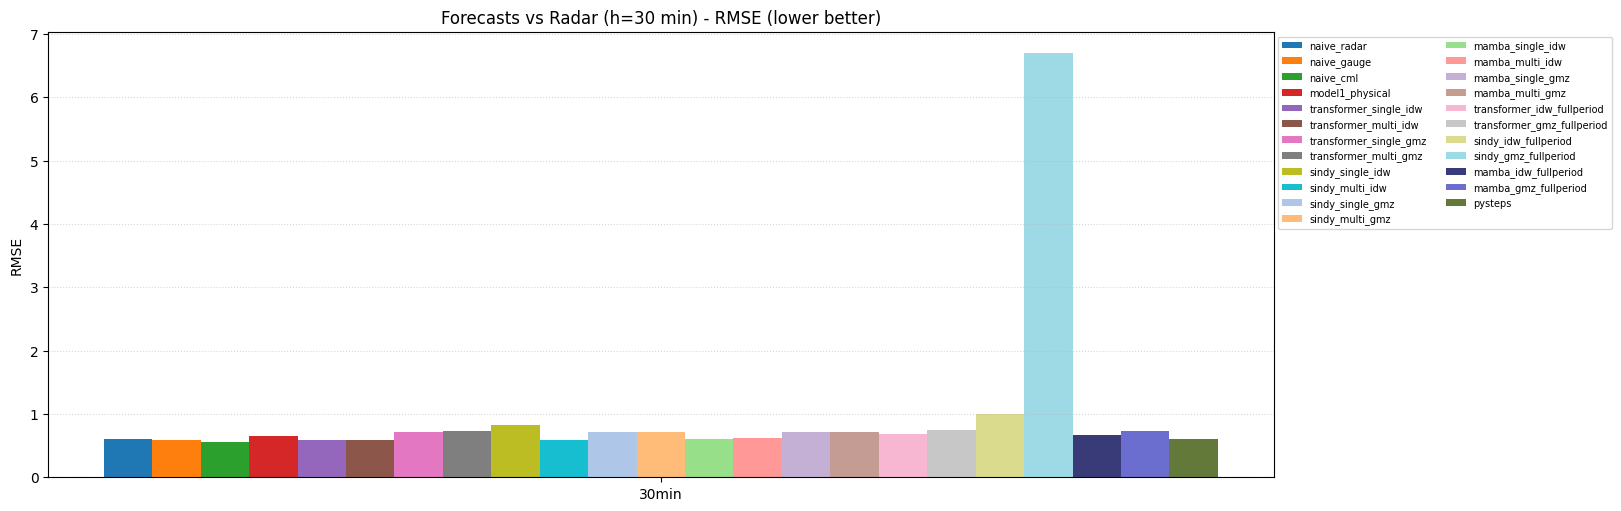


TOP 3 MODELS — RMSE (lower is better):
  h=30min:
    1. naive_cml                      RMSE=0.5586
    2. transformer_multi_idw          RMSE=0.5814
    3. naive_gauge                    RMSE=0.5875



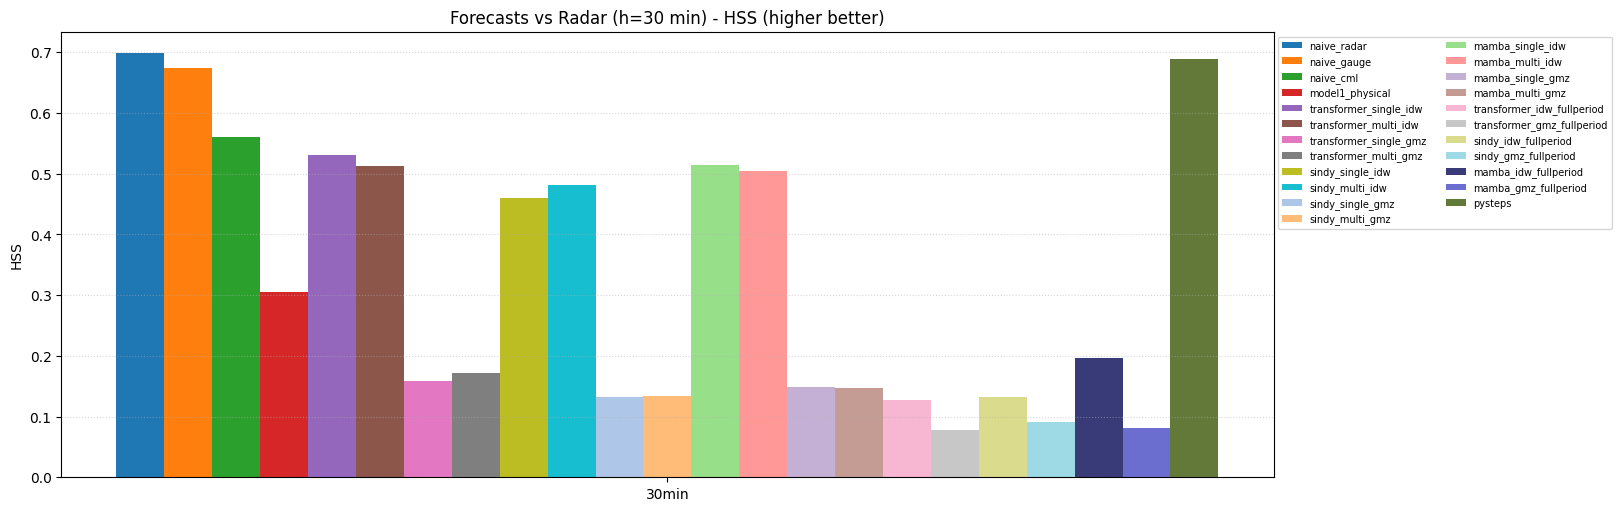


TOP 3 MODELS — HSS (higher is better):
  h=30min:
    1. naive_radar                    HSS=0.6990
    2. pysteps                        HSS=0.6891
    3. naive_gauge                    HSS=0.6735



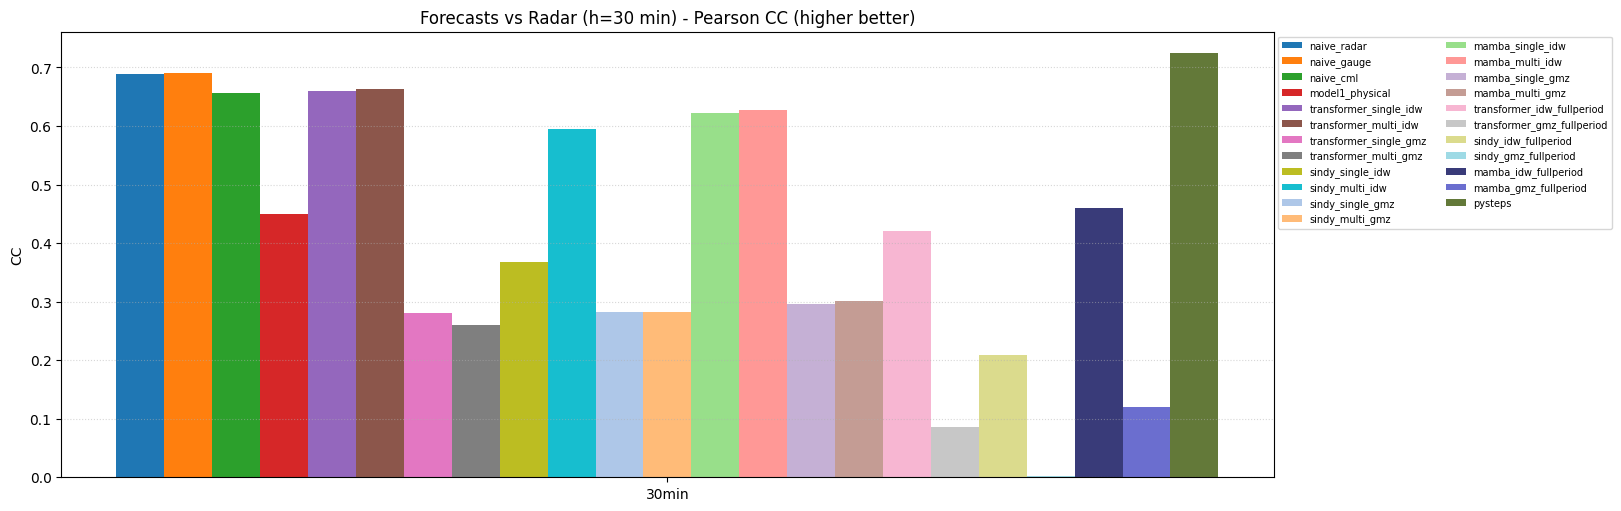


TOP 3 MODELS — CC (higher is better):
  h=30min:
    1. pysteps                        CC=0.7249
    2. naive_gauge                    CC=0.6901
    3. naive_radar                    CC=0.6882



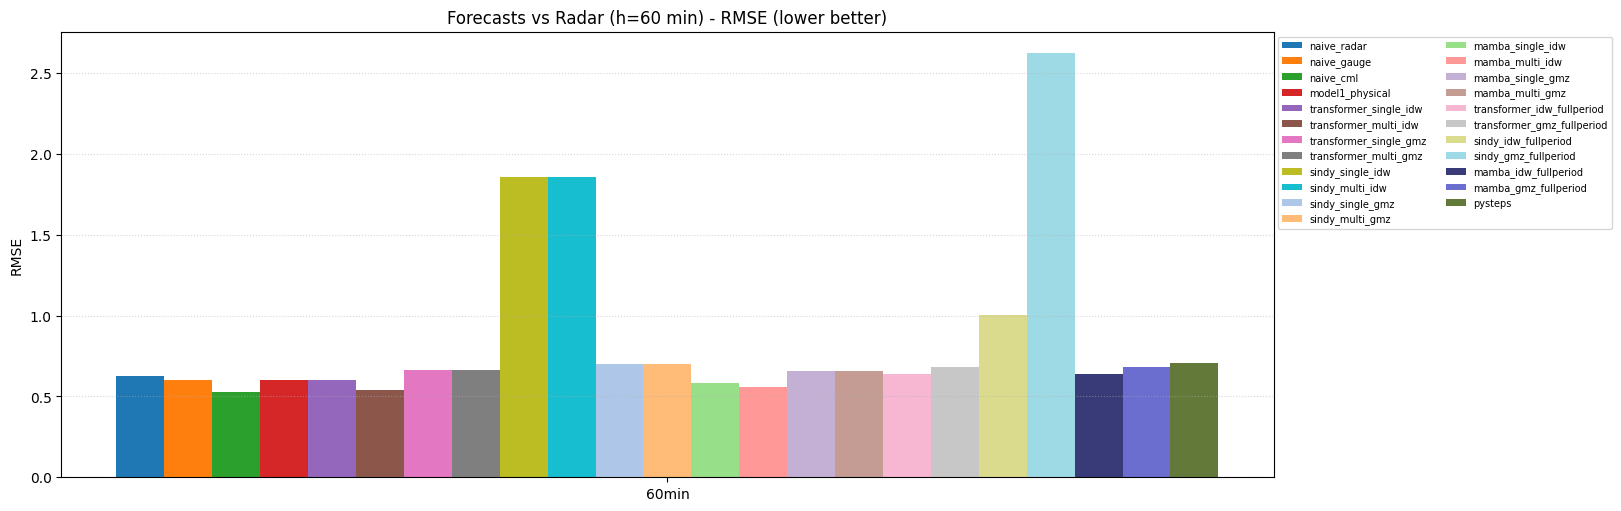


TOP 3 MODELS — RMSE (lower is better):
  h=60min:
    1. naive_cml                      RMSE=0.5274
    2. transformer_multi_idw          RMSE=0.5372
    3. mamba_multi_idw                RMSE=0.5606



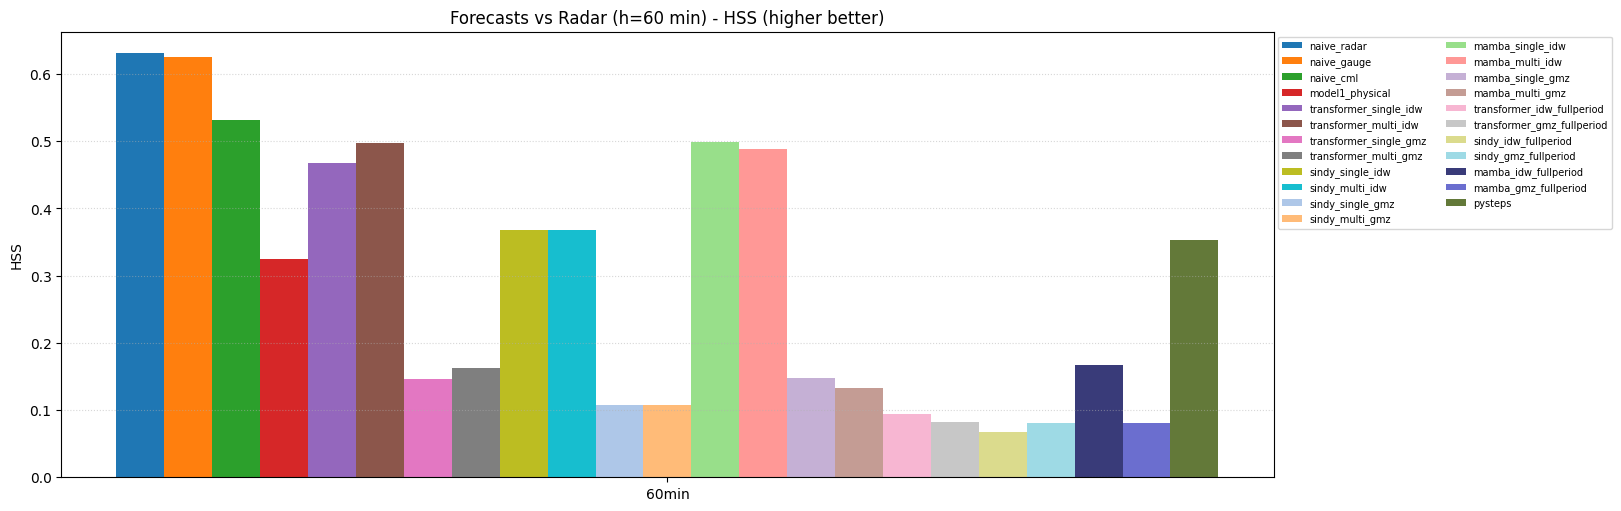


TOP 3 MODELS — HSS (higher is better):
  h=60min:
    1. naive_radar                    HSS=0.6315
    2. naive_gauge                    HSS=0.6258
    3. naive_cml                      HSS=0.5322



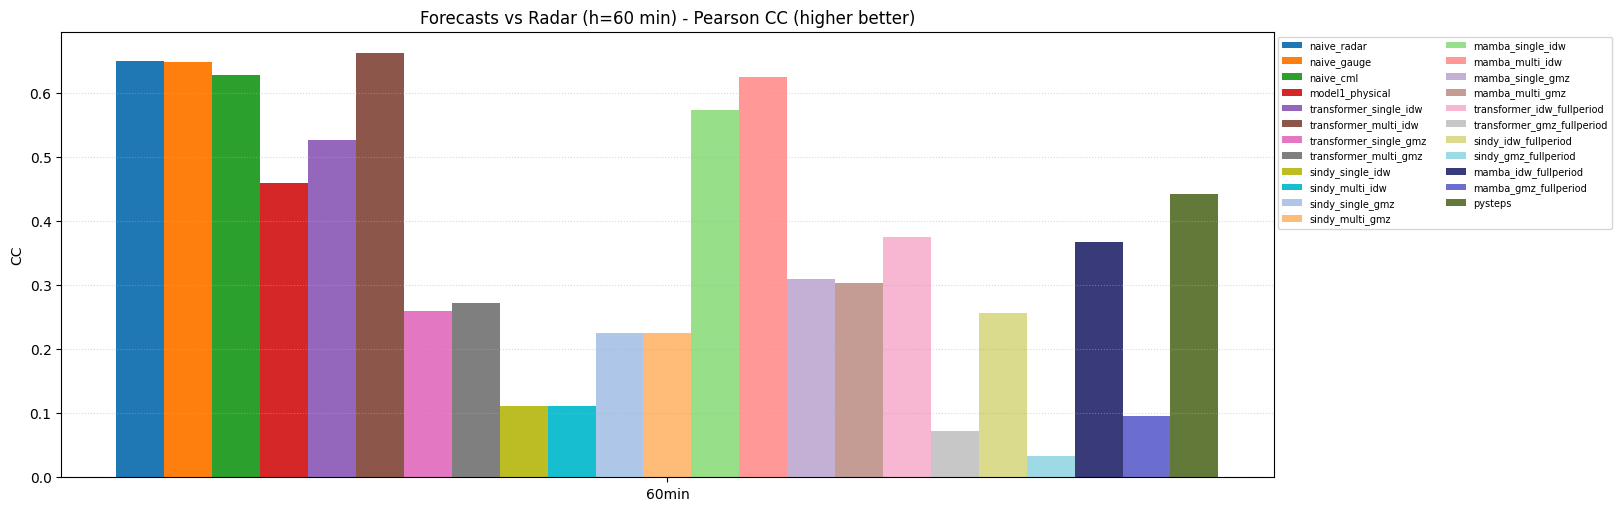


TOP 3 MODELS — CC (higher is better):
  h=60min:
    1. transformer_multi_idw          CC=0.6626
    2. naive_radar                    CC=0.6500
    3. naive_gauge                    CC=0.6477



In [ ]:
plot_metric_bars(df_radar_30, "RMSE", "Forecasts vs Radar (h=30 min) - RMSE (lower better)", True)
plot_metric_bars(df_radar_30, "HSS",  "Forecasts vs Radar (h=30 min) - HSS (higher better)",  False)
plot_metric_bars(df_radar_30, "CC",   "Forecasts vs Radar (h=30 min) - Pearson CC (higher better)", False)

plot_metric_bars(df_radar_60, "RMSE", "Forecasts vs Radar (h=60 min) - RMSE (lower better)", True)
plot_metric_bars(df_radar_60, "HSS",  "Forecasts vs Radar (h=60 min) - HSS (higher better)",  False)
plot_metric_bars(df_radar_60, "CC",   "Forecasts vs Radar (h=60 min) - Pearson CC (higher better)", False)


## Part 10.8 - Horizon comparison: RMSE and HSS as a function of $h$

Places the 30/60-min results in context alongside $h=15$ and $h=45$.
For consistency with Parts 10.4 and 10.6, we recompute the full
$h\in\{15, 30, 45, 60\}$ sweep against gauges using the same
trailing-mean aggregation (for $h=15$, $k=1$ and the trailing mean
equals the instantaneous frame, so the result matches Part~6.3
numerically). Each model is plotted as a single line, coloured with
the same \texttt{\_spaced\_colors} palette as the bar charts so
that visual identification is consistent across the chapter.


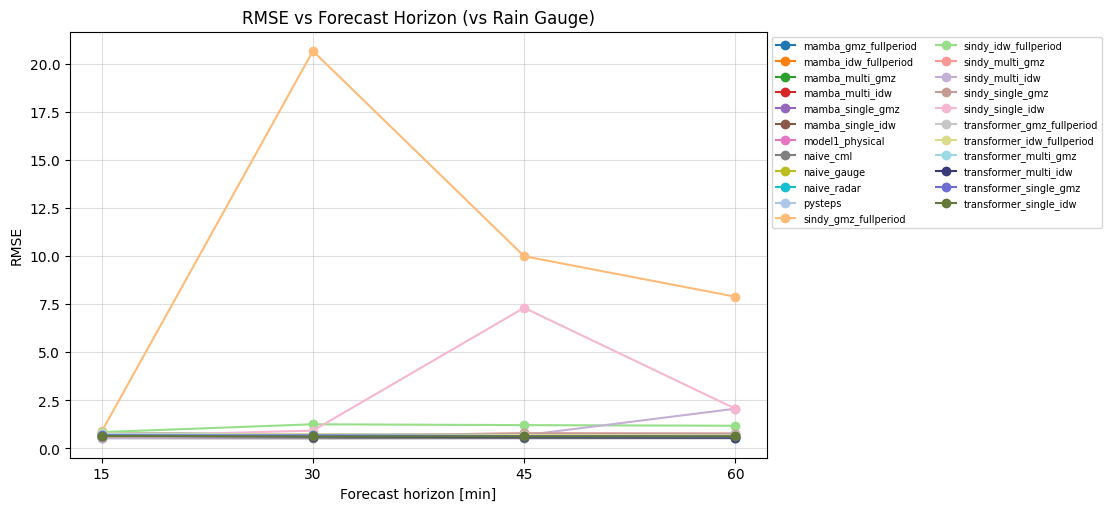

Top 3 models at h=60 - RMSE (lower better):
  1. naive_cml                      RMSE=0.5355
  2. transformer_multi_idw          RMSE=0.5647
  3. mamba_multi_gmz                RMSE=0.5936



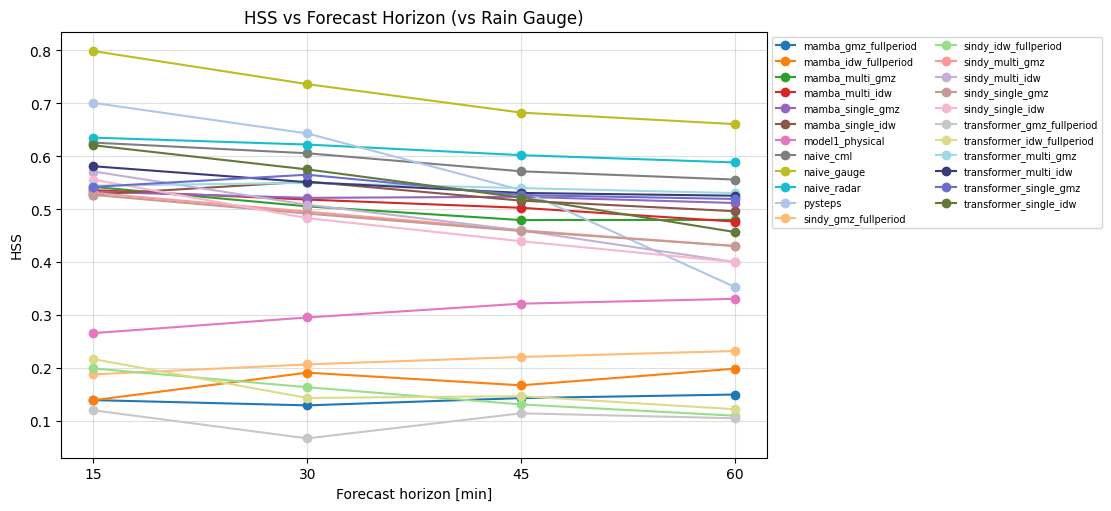

Top 3 models at h=60 - HSS (higher better):
  1. naive_gauge                    HSS=0.6608
  2. naive_radar                    HSS=0.5885
  3. naive_cml                      HSS=0.5562



In [ ]:
# Build maps dict for all four horizons
maps_all = {}
for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    maps_all[h_min] = {m: d.get(h_min) for m, d in MODEL_REGISTRY.items() if d.get(h_min) is not None}

# Aggregated gauge GT at each horizon
gauge_gt_all = {
    15: gauge_aligned,
    30: gauge_gt_30min,
    45: gauge_aligned.rolling(window=3, min_periods=1).mean().astype(np.float32),
    60: gauge_gt_60min,
}

rows_all = []
for h_step, h_min in zip(HORIZONS_STEPS, HORIZONS_MIN):
    sub = _eval_vs_gauges_at_h(maps_all[h_min], gauge_gt_all[h_min], h_step)
    rows_all.append(sub)
df_gauge_agg = pd.concat(rows_all, ignore_index=True)

models = sorted(df_gauge_agg["model"].unique().tolist())
colors_lookup = {m: c for m, c in zip(models, _spaced_colors(len(models)))}

def _line_chart(df, metric, title, ascending_is_better=True):
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    horizons_local = sorted(df["horizon_min"].unique())
    for m in models:
        sub = df[df["model"] == m].sort_values("horizon_min")
        if sub.empty:
            continue
        ax.plot(sub["horizon_min"].values, sub[metric].values,
                marker="o", color=colors_lookup[m], label=m, lw=1.5)
    ax.set_xlabel("Forecast horizon [min]")
    ax.set_ylabel(metric)
    ax.set_xticks(horizons_local)
    ax.set_title(title)
    ax.grid(alpha=0.4)
    ax.legend(loc="upper left", fontsize=7, ncol=2, bbox_to_anchor=(1.0, 1.0))
    plt.show()
    sub_h60 = df[df["horizon_min"] == 60][["model", metric]].dropna()
    sub_h60 = sub_h60.sort_values(metric, ascending=ascending_is_better).head(3)
    print(f"Top 3 models at h=60 - {metric} ({'lower' if ascending_is_better else 'higher'} better):")
    for rank, (_, r) in enumerate(sub_h60.iterrows(), 1):
        print(f"  {rank}. {r['model']:<30s} {metric}={r[metric]:.4f}")
    print()

_line_chart(df_gauge_agg, "RMSE", "RMSE vs Forecast Horizon (vs Rain Gauge)", True)
_line_chart(df_gauge_agg, "HSS",  "HSS vs Forecast Horizon (vs Rain Gauge)",  False)


## Part 10.9 - Rain-event case studies: selection

A \emph{case study} in this chapter is a side-by-side visual
inspection of the model forecast map against the radar ground truth
at a specific timestamp during a real rain event. Visual inspection
complements the aggregate metrics of Parts 10.4--10.7 because the
metrics average over all times and locations and therefore mask
spatial structure, storm-tracking ability, and failure modes such as
the systematic spatial smoothing characteristic of neural
spatial-temporal models.

We select \texttt{N\_EVENTS} $=5$ rain events from \textbf{five
different calendar days} in the test split. The procedure is:

1. For each calendar day in the test window, compute the
   day-maximum of the spatially-averaged cropped radar rain rate.
2. Sort calendar days by that day-maximum in descending order.
3. Take the top 5 days.
4. For each selected day, record the timestamp of the in-day peak.

This yields five timestamps, each from a distinct day, each
corresponding to that day's most intense rainfall episode.


In [ ]:
N_EVENTS = 5
FIGURES_DIR = os.path.join(base_path, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Spatially-averaged cropped radar rain in the test window
test_radar_crop = crop_field(radar_15[TEST_LO:TEST_HI])  # (T_test, H', W')
test_means_full = test_radar_crop.mean(axis=(1, 2))      # (T_test,)
test_times      = radar_times[TEST_LO:TEST_HI]           # DatetimeIndex of length T_test

# Group by date and find each day's peak
df_test = pd.DataFrame({"time": test_times, "mean": test_means_full})
df_test["date"] = pd.to_datetime(df_test["time"]).dt.date
day_peaks = df_test.loc[df_test.groupby("date")["mean"].idxmax()].sort_values("mean", ascending=False)

# Limit to days for which BOTH h=30 and h=60 predictions are available
def _has_both_horizons(t_global):
    """Check that the multi-step Transformer has both h=30 and h=60 predictions
    targeting global time t_global. For h=h_step, the prediction index is
    j = t_global - TEST_LO - LOOKBACK_WINDOW - (h_step - 1)."""
    arr30 = MODEL_REGISTRY.get("transformer_multi_idw", {}).get(30)
    arr60 = MODEL_REGISTRY.get("transformer_multi_idw", {}).get(60)
    if arr30 is None or arr60 is None:
        return False
    j30 = t_global - TEST_LO - LOOKBACK_WINDOW - 1   # h_step=2 - 1
    j60 = t_global - TEST_LO - LOOKBACK_WINDOW - 3   # h_step=4 - 1
    return (0 <= j30 < arr30.shape[0]) and (0 <= j60 < arr60.shape[0])

selected = []
for _, row in day_peaks.iterrows():
    t_global = radar_times.get_loc(row["time"])
    if _has_both_horizons(t_global):
        selected.append({"time": row["time"], "mean": float(row["mean"]),
                         "t_global": int(t_global)})
    if len(selected) == N_EVENTS:
        break

event_timestamps = selected
print(f"Selected {len(event_timestamps)} events (one per day, sorted by intensity):\n")
for i, ev in enumerate(event_timestamps, 1):
    print(f"  Event #{i}: {ev['time']}   peak spatial mean = {ev['mean']:.3f} mm/h")


Selected 5 events (one per day, sorted by intensity):

  Event #1: 2015-08-25 06:45:00   peak spatial mean = 8.691 mm/h
  Event #2: 2015-08-27 02:00:00   peak spatial mean = 5.462 mm/h
  Event #3: 2015-08-24 14:15:00   peak spatial mean = 3.256 mm/h
  Event #4: 2015-08-31 20:00:00   peak spatial mean = 3.231 mm/h
  Event #5: 2015-08-15 15:15:00   peak spatial mean = 2.120 mm/h


## Part 10.10 - Map layout for case studies

For each selected event we produce a single figure with a $2\times 2$
grid of subplots:

\begin{center}
\begin{tabular}{c|cc}
                  & Radar GT & Transformer multi (IDW) \\
\hline
$h = 30$ min &  [0,\,0]   & [0,\,1]                   \\
$h = 60$ min &  [1,\,0]   & [1,\,1]                   \\
\end{tabular}
\end{center}

All four panels in a figure share a common $[v_{\min}, v_{\max}]$
colour range, where $v_{\min}=0$ and $v_{\max}$ is the
$99^\text{th}$-percentile rain rate observed across the radar GT
fields of all selected events (computed once and reused, so colour
mapping is comparable across the five events). The colour scale is
non-linear (\texttt{PowerNorm(gamma=0.5)}) to remain consistent with
the rest of the notebook and to emphasise low rain rates.

Rain-gauge stations are overlaid as filled circles with a black edge;
the fill colour encodes the actual gauge reading at the event time,
taken through the same colour map and \texttt{PowerNorm} as the
background field, so that visual agreement between the dot fill and
the underlying pixel directly indicates forecast accuracy. The top
row uses the 30-minute trailing-mean gauge reading
(\texttt{gauge\_gt\_30min}); the bottom row uses the 60-minute
trailing-mean (\texttt{gauge\_gt\_60min}). CML link midpoints are
drawn as grey crosses for spatial context.

\textbf{Transformer multi-step (IDW) is chosen} as the visualisation
model because it is the most expressive learned forecaster that was
trained on IDW-interpolated CML maps with a single multi-horizon head
and is therefore representative of the advanced map-to-map forecasting
paradigm of this work.


## Part 10.11 - Render one figure per case study

For each event timestamp, the 2$\times$2 figure is written to
\texttt{base\_path/figures/event\_YYYYMMDD\_HHMM.png}. Re-runs skip
files already on disk.

**Inputs:** \texttt{event\_timestamps}, \texttt{radar\_gt\_30min}, \texttt{radar\_gt\_60min},
\texttt{MODEL\_REGISTRY}, \texttt{gauge\_lons/lats}, \texttt{link\_lons/lats}.
**Outputs:** five PNG files under \texttt{figures/}.


Shared colour vmax (99th percentile of radar GT across events): 15.600 mm/h
  cached /content/drive/MyDrive/FieldSense_Project_v2/figures/event_20150825_0645.png


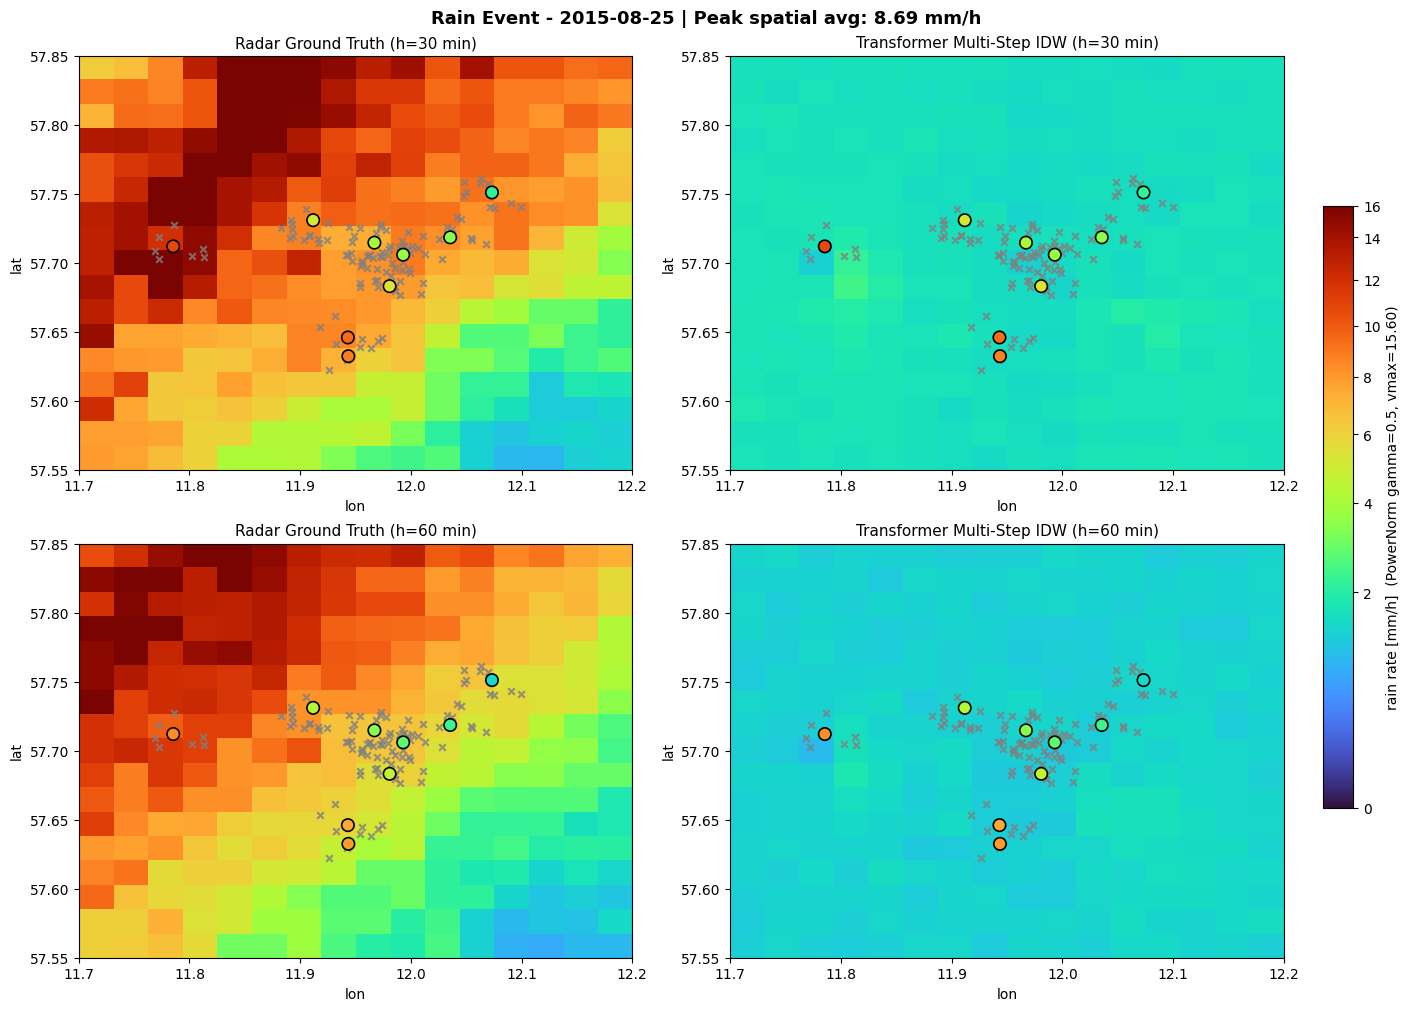

  cached /content/drive/MyDrive/FieldSense_Project_v2/figures/event_20150827_0200.png


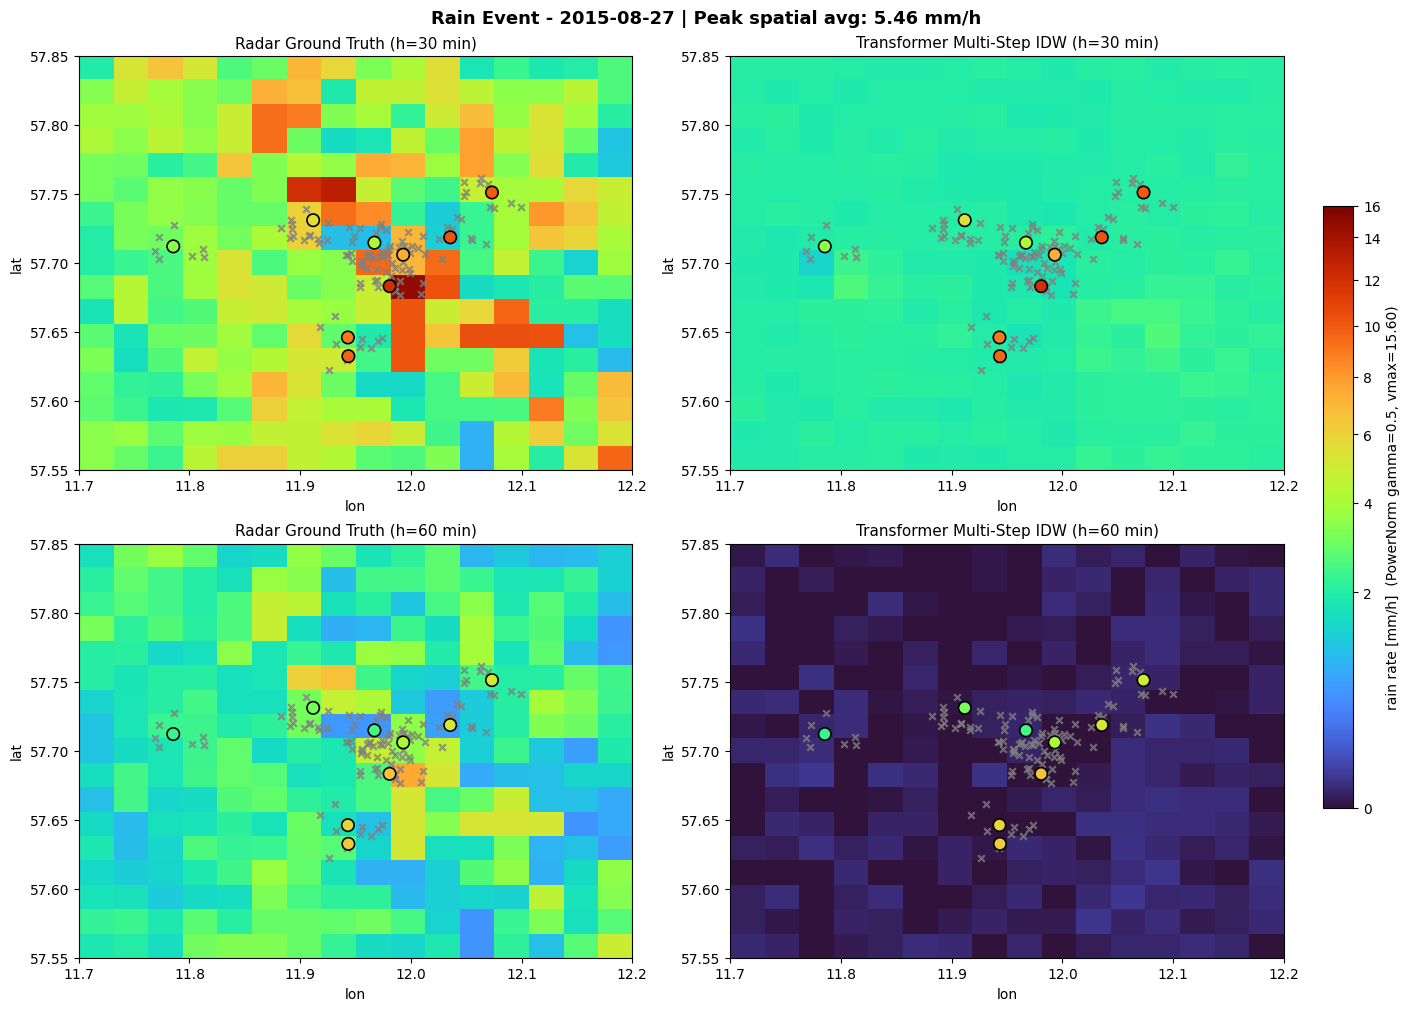

  cached /content/drive/MyDrive/FieldSense_Project_v2/figures/event_20150824_1415.png


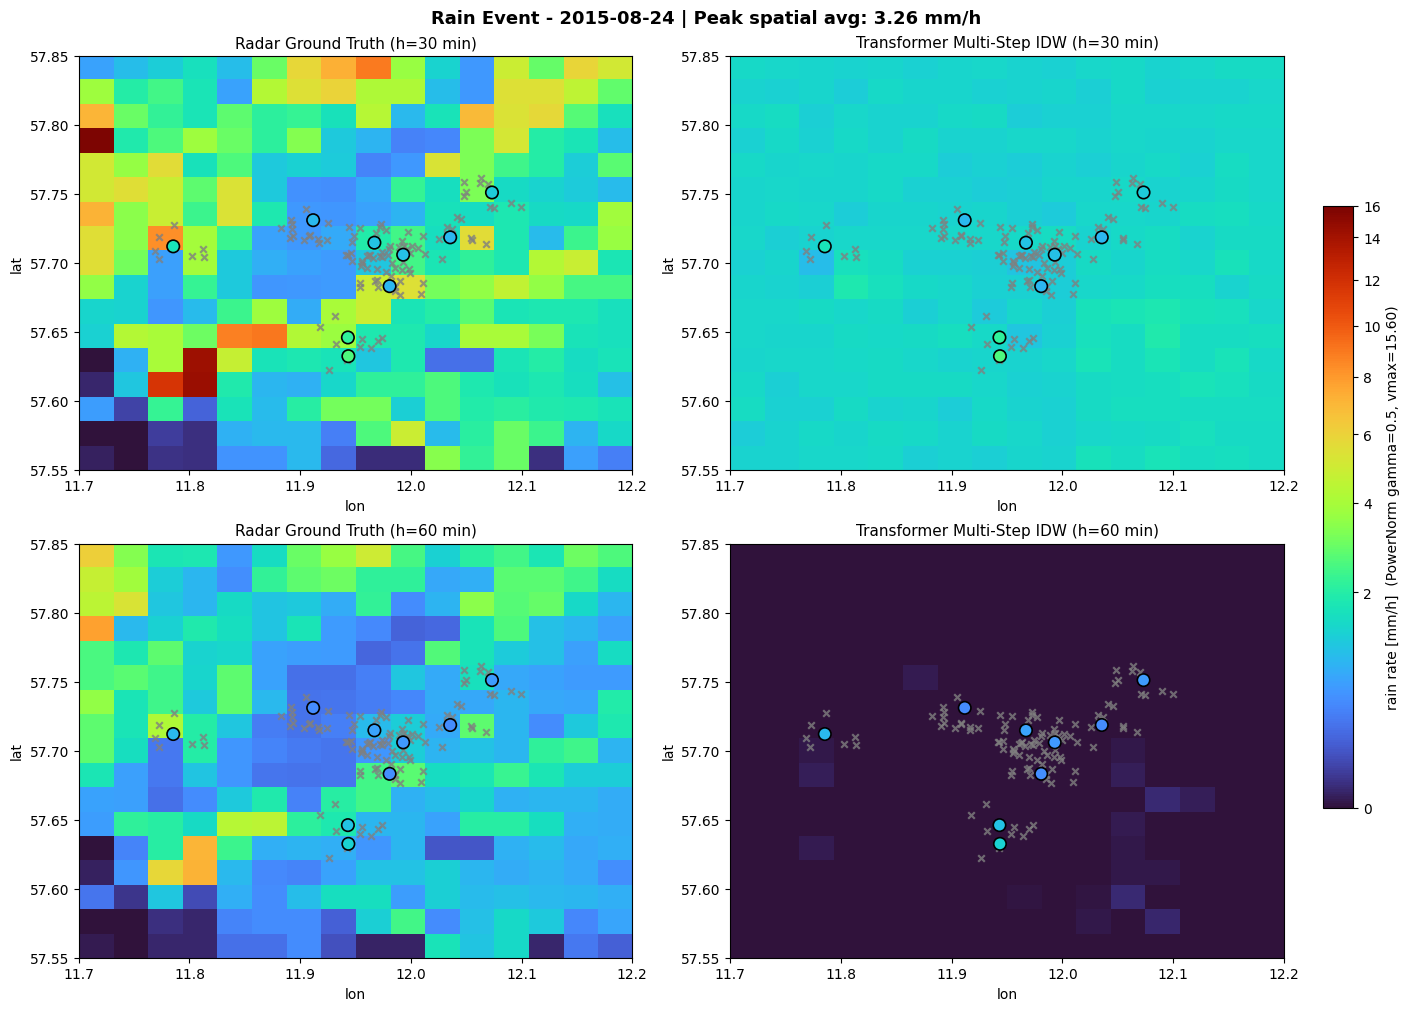

  cached /content/drive/MyDrive/FieldSense_Project_v2/figures/event_20150831_2000.png


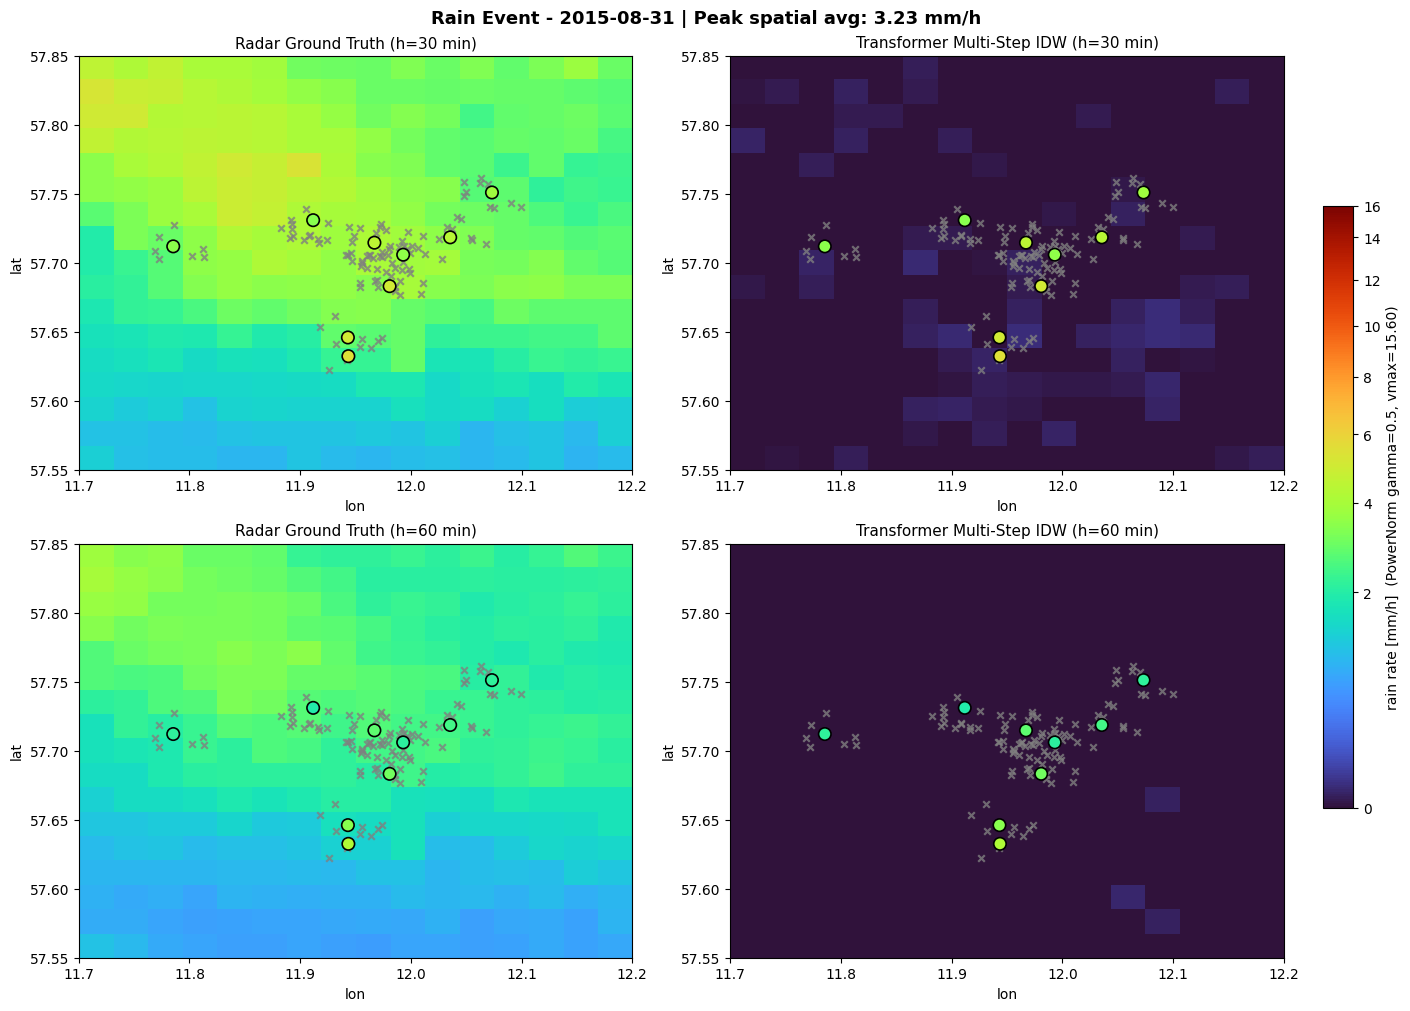

  cached /content/drive/MyDrive/FieldSense_Project_v2/figures/event_20150815_1515.png


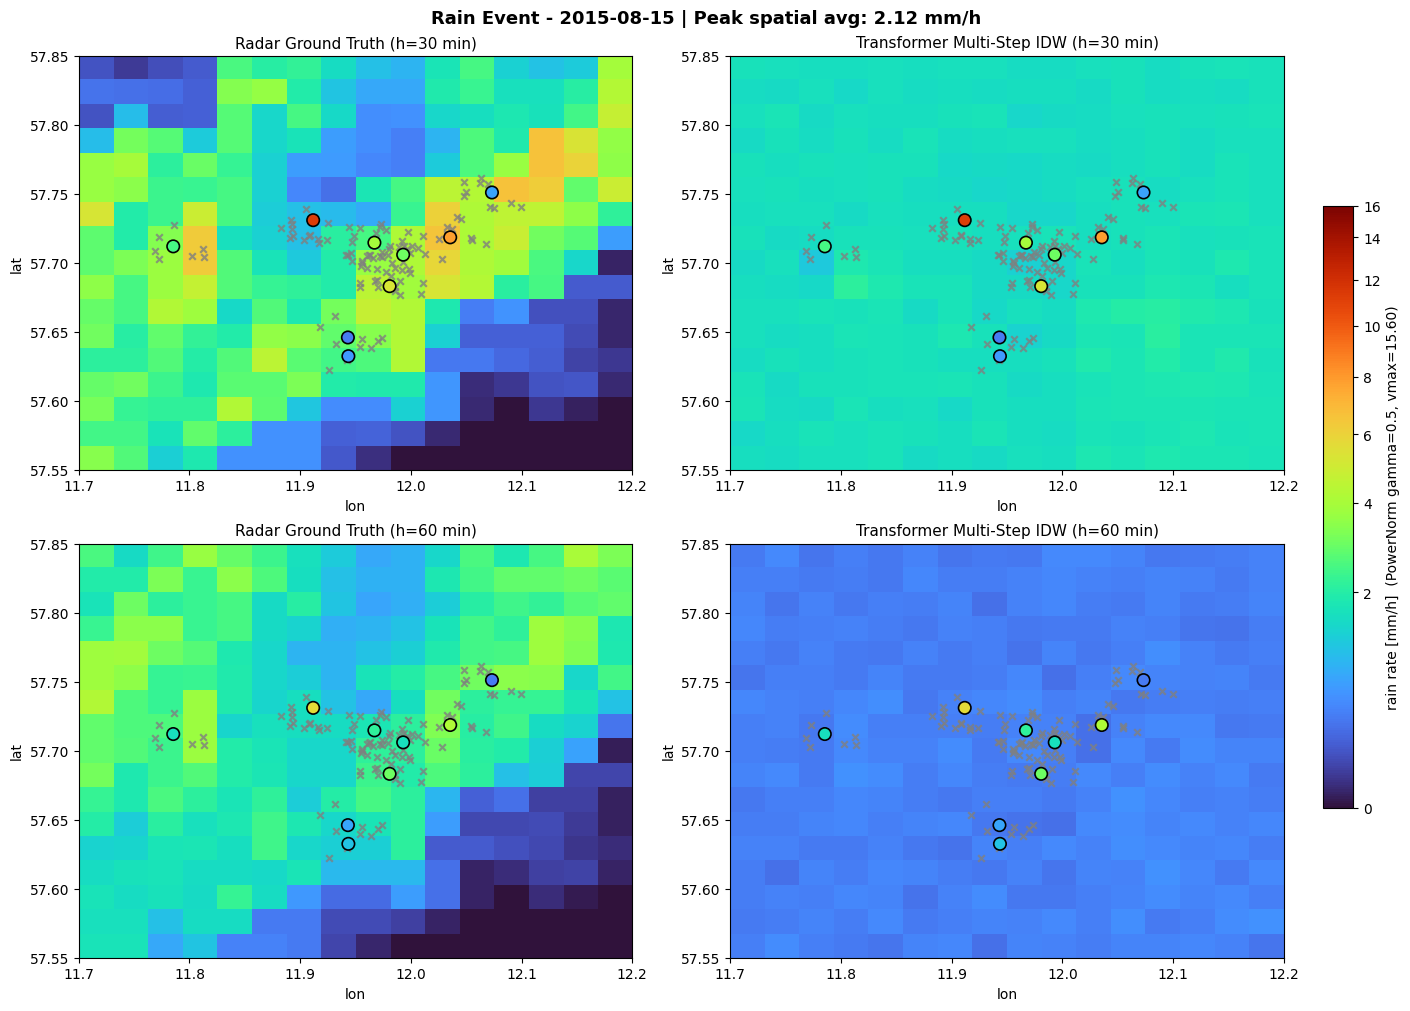

In [ ]:
from matplotlib.colors import PowerNorm

CASE_MODEL_KEY = "transformer_multi_idw"
GAMMA          = 0.5

if CASE_MODEL_KEY not in MODEL_REGISTRY or MODEL_REGISTRY[CASE_MODEL_KEY].get(30) is None \
        or MODEL_REGISTRY[CASE_MODEL_KEY].get(60) is None:
    raise RuntimeError(f"{CASE_MODEL_KEY} predictions at h=30 and/or h=60 are missing.")

pred30_all = MODEL_REGISTRY[CASE_MODEL_KEY][30]
pred60_all = MODEL_REGISTRY[CASE_MODEL_KEY][60]

# Pre-compute the shared 99th-percentile vmax across all events' radar GT fields.
stack = []
for ev in event_timestamps:
    stack.append(crop_field(radar_gt_30min[ev["t_global"]]).ravel())
    stack.append(crop_field(radar_gt_60min[ev["t_global"]]).ravel())
combined = np.concatenate(stack)
vmax_shared = float(np.quantile(combined[combined > 0], 0.99)) if (combined > 0).any() else 1.0
vmax_shared = max(vmax_shared, 1.0)
print(f"Shared colour vmax (99th percentile of radar GT across events): {vmax_shared:.3f} mm/h")

norm = PowerNorm(gamma=GAMMA, vmin=0.0, vmax=vmax_shared, clip=True)
cmap = plt.get_cmap("turbo")
extent = [LON_RANGE[0], LON_RANGE[1], LAT_RANGE[0], LAT_RANGE[1]]

case_paths = []
for ev in event_timestamps:
    t_global = ev["t_global"]
    j30 = t_global - TEST_LO - LOOKBACK_WINDOW - 1   # h_step=2 -> -1
    j60 = t_global - TEST_LO - LOOKBACK_WINDOW - 3   # h_step=4 -> -3

    radar_30 = crop_field(radar_gt_30min[t_global])
    radar_60 = crop_field(radar_gt_60min[t_global])
    pred_30  = crop_field(pred30_all[j30])
    pred_60  = crop_field(pred60_all[j60])

    # Gauge values matched to each row's aggregation horizon, mapped
    # to colours through the shared cmap/norm so that the marker fill
    # is directly comparable to the surrounding field.
    g_vals_30 = np.nan_to_num(gauge_gt_30min.values[t_global], nan=0.0)
    g_vals_60 = np.nan_to_num(gauge_gt_60min.values[t_global], nan=0.0)
    g_cols_30 = cmap(norm(g_vals_30))
    g_cols_60 = cmap(norm(g_vals_60))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    panels = [
        (axes[0, 0], radar_30, "Radar Ground Truth (h=30 min)",        g_cols_30),
        (axes[0, 1], pred_30,  "Transformer Multi-Step IDW (h=30 min)", g_cols_30),
        (axes[1, 0], radar_60, "Radar Ground Truth (h=60 min)",        g_cols_60),
        (axes[1, 1], pred_60,  "Transformer Multi-Step IDW (h=60 min)", g_cols_60),
    ]
    last_im = None
    for ax, fld, ttl, g_cols in panels:
        last_im = ax.imshow(fld, cmap=cmap, norm=norm, origin="lower",
                            extent=extent, aspect="auto")
        ax.scatter(gauge_lons, gauge_lats, s=80, marker="o",
                   c=g_cols, edgecolors="black", linewidths=1.2, zorder=5)
        ax.scatter(link_lons, link_lats, s=22, marker="x",
                   c="grey", alpha=0.55, zorder=4)
        ax.set_title(ttl, fontsize=11)
        ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02,
                 label=f"rain rate [mm/h]  (PowerNorm gamma={GAMMA}, vmax={vmax_shared:.2f})")
    t_pd = pd.Timestamp(ev["time"])
    fig.suptitle(f"Rain Event - {t_pd.date()} | Peak spatial avg: {ev['mean']:.2f} mm/h",
                 fontsize=13, fontweight="bold")

    fig_path = os.path.join(FIGURES_DIR, f"event_{t_pd.strftime('%Y%m%d_%H%M')}.png")
    if not exists(fig_path):
        fig.savefig(fig_path, dpi=130, bbox_inches="tight")
        print(f"  saved {fig_path}")
    else:
        print(f"  cached {fig_path}")
    case_paths.append(fig_path)
    plt.show()


## Part 10.12 - Case-study interpretation guidance

When inspecting the figures, look for the following diagnostic
patterns. \textbf{Spatial extent.} Compare the area covered by the
wet-classified pixels in the prediction against the radar GT; a
prediction whose footprint is much smaller or much larger than the
truth reveals under- or over-confidence in the wet/dry decision.
\textbf{Intensity.} A model can match the storm location but
under-estimate the peak rain rate (\texttt{recall} OK,
\texttt{precision} low at intense thresholds), or vice versa.
\textbf{Position offset.} A consistent spatial shift between the
predicted and observed storm cell is a signature of imperfect motion
estimation -- common at the longer horizons. \textbf{Spatial
smoothing.} Neural map-to-map models tend to blur sharp gradients as
the forecast horizon grows; the $h=60$ panel will often look like a
diffused version of $h=30$ for the same model, even if both are issued
for the same target time from different lookback windows.

A formal narrative interpretation of these figures is reserved for the
Results and Discussion sections of the accompanying paper.


## Part 10.14 - Focused comparison vs rain gauges

A condensed side-by-side comparison of the operational story of this
chapter, restricted to:

* the three CML-based advanced multi-step forecasters on IDW maps
  (\texttt{transformer\_multi\_idw}, \texttt{sindy\_multi\_idw},
  \texttt{mamba\_multi\_idw}),
* the operational radar nowcast \texttt{pysteps},
* the four naive baselines (\texttt{naive\_radar},
  \texttt{naive\_gauge}, \texttt{naive\_cml},
  \texttt{model1\_physical}).

The eight rows are plotted at $h\in\{30, 60\}$ side-by-side with the
same colour palette and the same \texttt{plot\_metric\_bars} helper
used in Parts 6.5 and 10.5; top-3 annotation is printed under each
chart. A ranking table at the end summarises mean performance over
the two horizons. Evaluation: rain gauges, using the trailing-mean
aggregation defined in Part 10.3.

**Inputs:** \texttt{df\_gauge\_30}, \texttt{df\_gauge\_60}.
**Outputs:** 4 figures (RMSE, HSS, CC, F1) and a ranking table.


Focused model set (8 models, 2 horizons):
  naive_radar                         OK
  naive_gauge                         OK
  naive_cml                           OK
  model1_physical                     OK
  transformer_multi_idw               OK
  sindy_multi_idw                     OK
  mamba_multi_idw                     OK
  pysteps                             OK



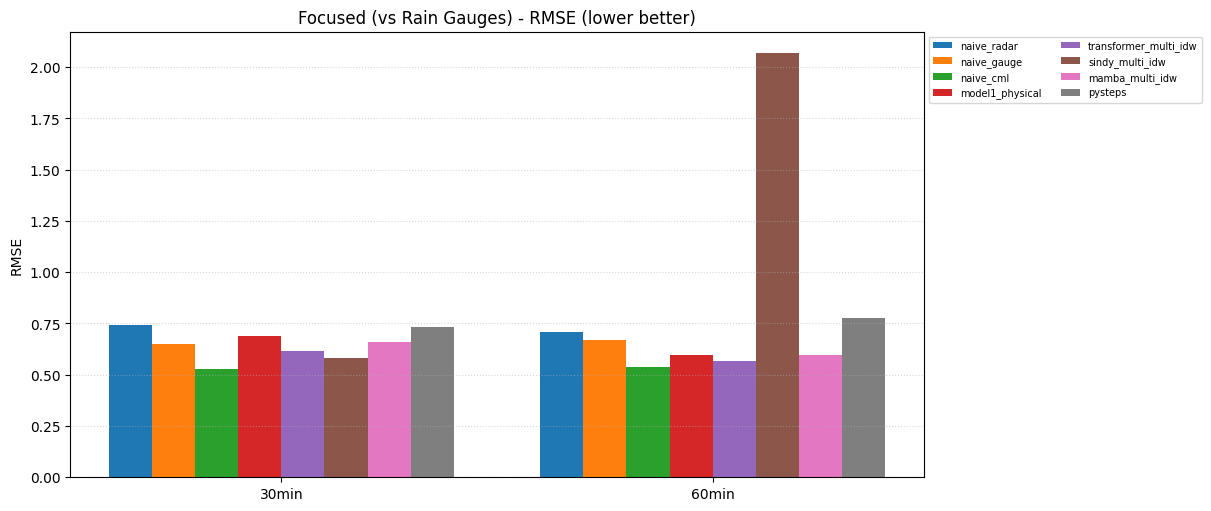


TOP 3 MODELS — RMSE (lower is better):
  h=30min:
    1. naive_cml                      RMSE=0.5272
    2. sindy_multi_idw                RMSE=0.5836
    3. transformer_multi_idw          RMSE=0.6180
  h=60min:
    1. naive_cml                      RMSE=0.5355
    2. transformer_multi_idw          RMSE=0.5647
    3. model1_physical                RMSE=0.5939



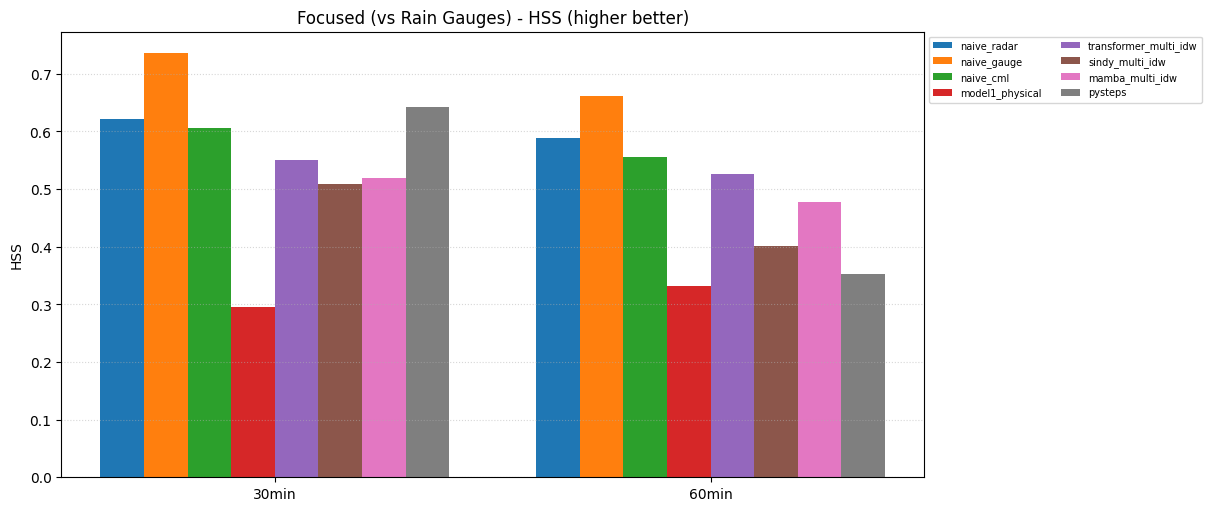


TOP 3 MODELS — HSS (higher is better):
  h=30min:
    1. naive_gauge                    HSS=0.7363
    2. pysteps                        HSS=0.6433
    3. naive_radar                    HSS=0.6223
  h=60min:
    1. naive_gauge                    HSS=0.6608
    2. naive_radar                    HSS=0.5885
    3. naive_cml                      HSS=0.5562



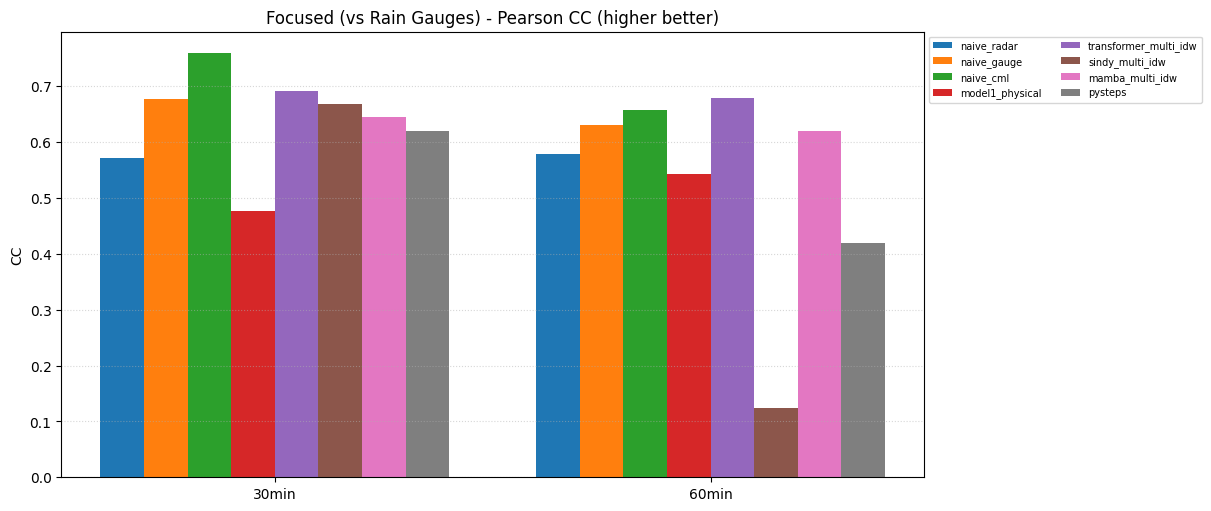


TOP 3 MODELS — CC (higher is better):
  h=30min:
    1. naive_cml                      CC=0.7598
    2. transformer_multi_idw          CC=0.6911
    3. naive_gauge                    CC=0.6780
  h=60min:
    1. transformer_multi_idw          CC=0.6782
    2. naive_cml                      CC=0.6570
    3. naive_gauge                    CC=0.6308



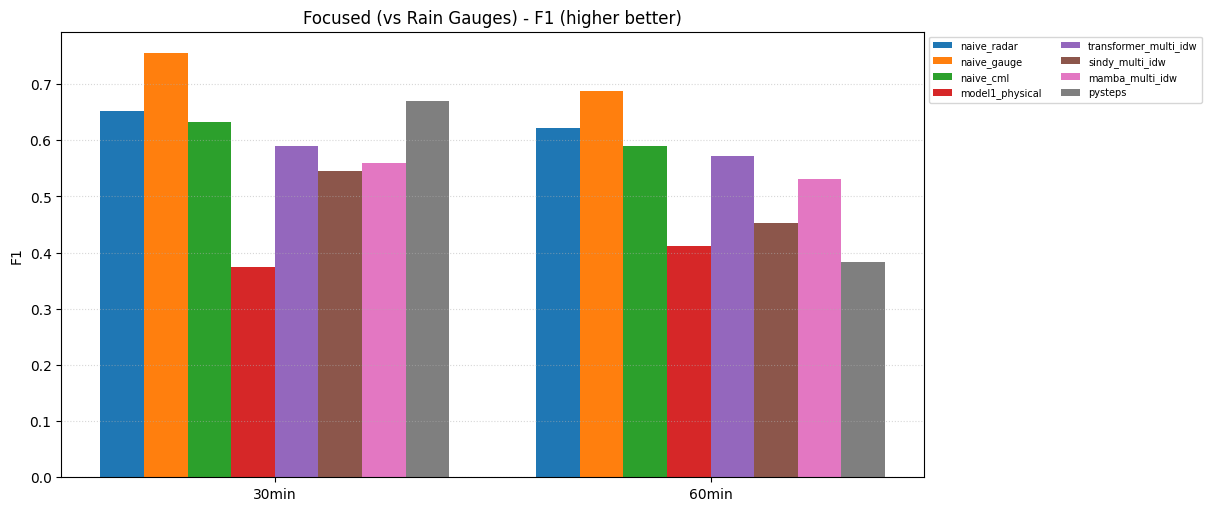


TOP 3 MODELS — F1 (higher is better):
  h=30min:
    1. naive_gauge                    F1=0.7554
    2. pysteps                        F1=0.6697
    3. naive_radar                    F1=0.6515
  h=60min:
    1. naive_gauge                    F1=0.6867
    2. naive_radar                    F1=0.6222
    3. naive_cml                      F1=0.5889

RANKING (mean over h=30, h=60, vs gauges):
                        RMSE    HSS     CC     F1
model                                            
naive_gauge           0.6578 0.6986 0.6544 0.7211
naive_radar           0.7237 0.6054 0.5752 0.6368
naive_cml             0.5313 0.5810 0.7084 0.6110
transformer_multi_idw 0.5913 0.5385 0.6847 0.5808
pysteps               0.7542 0.4984 0.5200 0.5262
mamba_multi_idw       0.6264 0.4977 0.6318 0.5453
sindy_multi_idw       1.3263 0.4546 0.3966 0.4986
model1_physical       0.6413 0.3135 0.5100 0.3930


In [ ]:
FOCUS_MODELS = [
    "naive_radar", "naive_gauge", "naive_cml", "model1_physical",
    "transformer_multi_idw", "sindy_multi_idw", "mamba_multi_idw",
    "pysteps",
]

df_focus_gauge = pd.concat([df_gauge_30, df_gauge_60], ignore_index=True)
df_focus_gauge = df_focus_gauge[df_focus_gauge["model"].isin(FOCUS_MODELS)].copy()
# Preserve the listed order for legend consistency
df_focus_gauge["model"] = pd.Categorical(df_focus_gauge["model"],
                                          categories=FOCUS_MODELS, ordered=True)
df_focus_gauge = df_focus_gauge.sort_values(["model", "horizon_min"]).reset_index(drop=True)

print(f"Focused model set ({len(FOCUS_MODELS)} models, 2 horizons):")
for m in FOCUS_MODELS:
    present = m in df_focus_gauge["model"].cat.categories and not df_focus_gauge[df_focus_gauge["model"] == m].empty
    print(f"  {m:<35s} {'OK' if present else 'MISSING'}")
print()

plot_metric_bars(df_focus_gauge, "RMSE",
                 "Focused (vs Rain Gauges) - RMSE (lower better)", True)
plot_metric_bars(df_focus_gauge, "HSS",
                 "Focused (vs Rain Gauges) - HSS (higher better)", False)
plot_metric_bars(df_focus_gauge, "CC",
                 "Focused (vs Rain Gauges) - Pearson CC (higher better)", False)
plot_metric_bars(df_focus_gauge, "F1",
                 "Focused (vs Rain Gauges) - F1 (higher better)", False)

# Mean-over-horizons ranking table (matches Part 6.7 style)
print("RANKING (mean over h=30, h=60, vs gauges):")
ranking_g = (df_focus_gauge.groupby("model", observed=True)[["RMSE", "HSS", "CC", "F1"]]
                            .mean()
                            .sort_values("HSS", ascending=False))
print(ranking_g.to_string(float_format="{:.4f}".format))


## Part 10.15 - Focused comparison vs radar

Same focused comparison as Part 10.14 but against the SMHI radar
field (cropped to the Gothenburg domain). Evaluation uses the
trailing-mean radar aggregation \texttt{radar\_gt\_30min} /
\texttt{radar\_gt\_60min} defined in Part 10.2.

**Inputs:** \texttt{df\_radar\_30}, \texttt{df\_radar\_60}.
**Outputs:** 4 figures (RMSE, HSS, CC, F1) and a ranking table.


Focused model set (8 models, 2 horizons):
  naive_radar                         OK
  naive_gauge                         OK
  naive_cml                           OK
  model1_physical                     OK
  transformer_multi_idw               OK
  sindy_multi_idw                     OK
  mamba_multi_idw                     OK
  pysteps                             OK



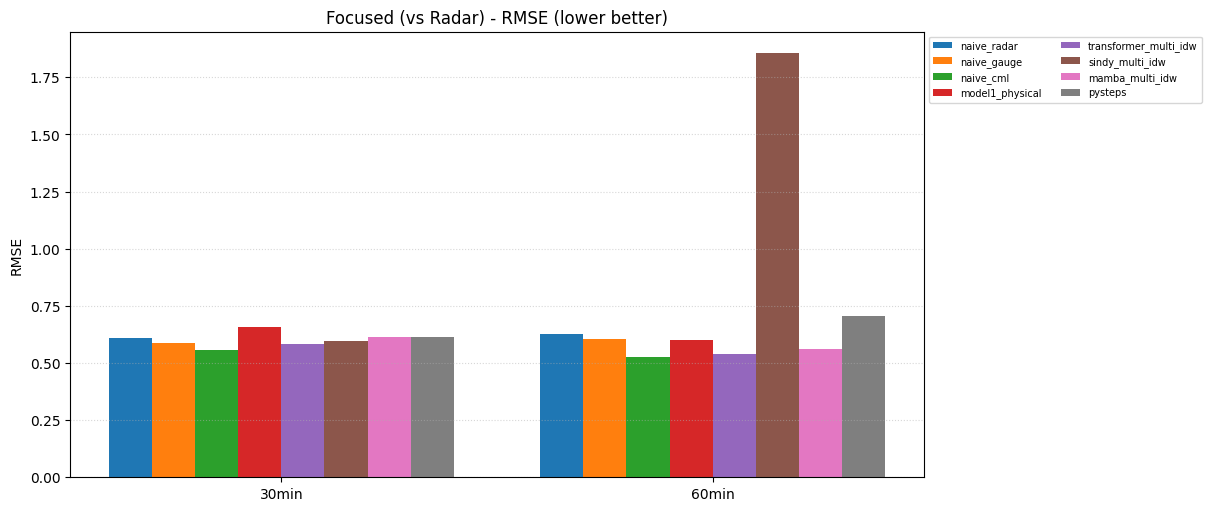


TOP 3 MODELS — RMSE (lower is better):
  h=30min:
    1. naive_cml                      RMSE=0.5586
    2. transformer_multi_idw          RMSE=0.5814
    3. naive_gauge                    RMSE=0.5875
  h=60min:
    1. naive_cml                      RMSE=0.5274
    2. transformer_multi_idw          RMSE=0.5372
    3. mamba_multi_idw                RMSE=0.5606



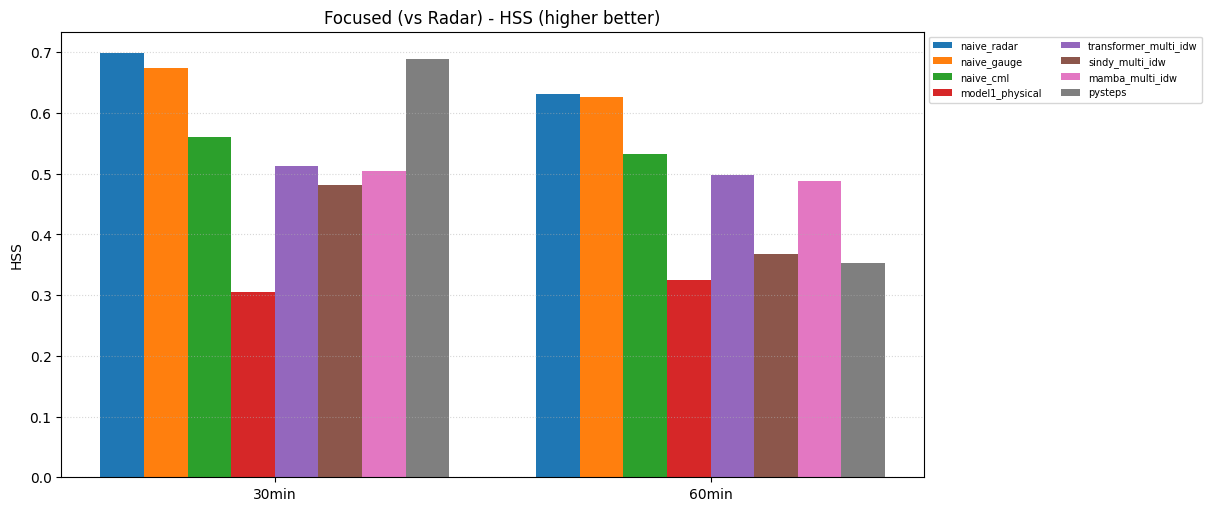


TOP 3 MODELS — HSS (higher is better):
  h=30min:
    1. naive_radar                    HSS=0.6990
    2. pysteps                        HSS=0.6891
    3. naive_gauge                    HSS=0.6735
  h=60min:
    1. naive_radar                    HSS=0.6315
    2. naive_gauge                    HSS=0.6258
    3. naive_cml                      HSS=0.5322



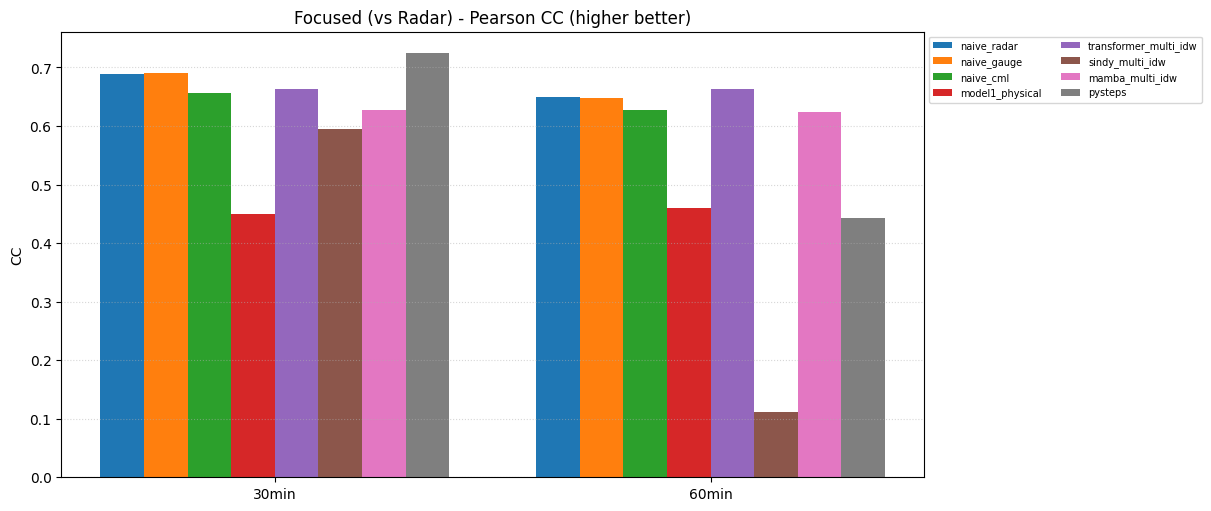


TOP 3 MODELS — CC (higher is better):
  h=30min:
    1. pysteps                        CC=0.7249
    2. naive_gauge                    CC=0.6901
    3. naive_radar                    CC=0.6882
  h=60min:
    1. transformer_multi_idw          CC=0.6626
    2. naive_radar                    CC=0.6500
    3. naive_gauge                    CC=0.6477



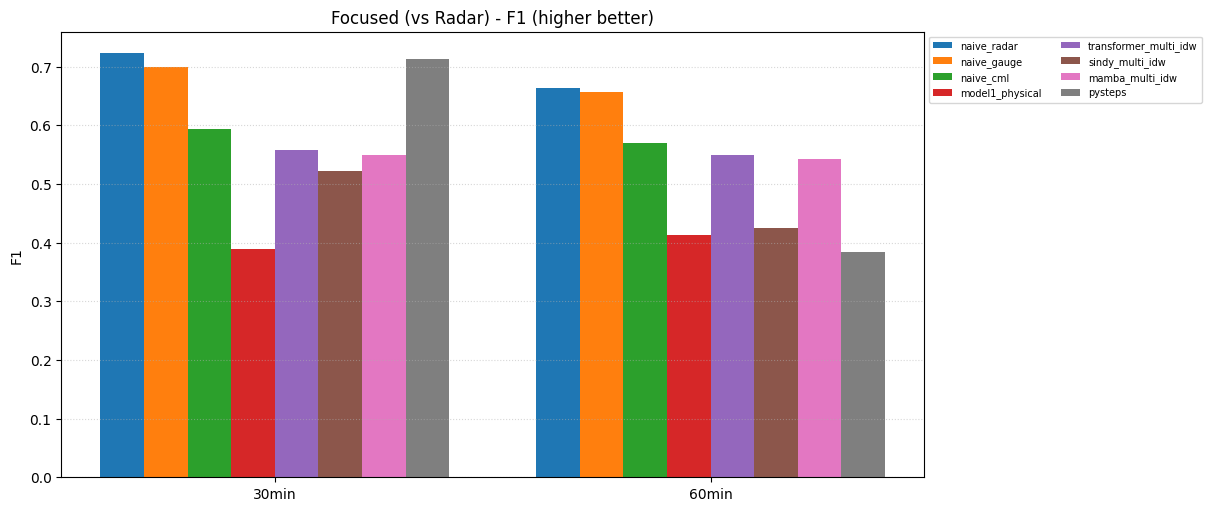


TOP 3 MODELS — F1 (higher is better):
  h=30min:
    1. naive_radar                    F1=0.7234
    2. pysteps                        F1=0.7126
    3. naive_gauge                    F1=0.6995
  h=60min:
    1. naive_radar                    F1=0.6628
    2. naive_gauge                    F1=0.6571
    3. naive_cml                      F1=0.5702

RANKING (mean over h=30, h=60, vs radar):
                        RMSE    HSS     CC     F1
model                                            
naive_radar           0.6161 0.6652 0.6691 0.6931
naive_gauge           0.5959 0.6496 0.6689 0.6783
naive_cml             0.5430 0.5461 0.6423 0.5820
pysteps               0.6578 0.5213 0.5837 0.5482
transformer_multi_idw 0.5593 0.5056 0.6630 0.5540
mamba_multi_idw       0.5877 0.4967 0.6263 0.5459
sindy_multi_idw       1.2253 0.4244 0.3534 0.4738
model1_physical       0.6286 0.3150 0.4549 0.4012


In [ ]:
df_focus_radar = pd.concat([df_radar_30, df_radar_60], ignore_index=True)
df_focus_radar = df_focus_radar[df_focus_radar["model"].isin(FOCUS_MODELS)].copy()
df_focus_radar["model"] = pd.Categorical(df_focus_radar["model"],
                                          categories=FOCUS_MODELS, ordered=True)
df_focus_radar = df_focus_radar.sort_values(["model", "horizon_min"]).reset_index(drop=True)

print(f"Focused model set ({len(FOCUS_MODELS)} models, 2 horizons):")
for m in FOCUS_MODELS:
    present = m in df_focus_radar["model"].cat.categories and not df_focus_radar[df_focus_radar["model"] == m].empty
    print(f"  {m:<35s} {'OK' if present else 'MISSING'}")
print()

plot_metric_bars(df_focus_radar, "RMSE",
                 "Focused (vs Radar) - RMSE (lower better)", True)
plot_metric_bars(df_focus_radar, "HSS",
                 "Focused (vs Radar) - HSS (higher better)", False)
plot_metric_bars(df_focus_radar, "CC",
                 "Focused (vs Radar) - Pearson CC (higher better)", False)
plot_metric_bars(df_focus_radar, "F1",
                 "Focused (vs Radar) - F1 (higher better)", False)

# Mean-over-horizons ranking table (matches Part 6.7 style)
print("RANKING (mean over h=30, h=60, vs radar):")
ranking_r = (df_focus_radar.groupby("model", observed=True)[["RMSE", "HSS", "CC", "F1"]]
                            .mean()
                            .sort_values("HSS", ascending=False))
print(ranking_r.to_string(float_format="{:.4f}".format))


## Part 10.13 - Chapter summary and file manifest

The remaining cell prints a manifest of every artefact produced by
this chapter: cached ground-truth aggregations, evaluation
DataFrames, and case-study figures. A compact top-3 table closes the
chapter.


In [ ]:
print("=" * 70)
print("PART 10 - File manifest")
print("=" * 70)

artefacts = [
    ("radar_gt_30min.npy",       RADAR_GT_30_PATH, "Radar trailing-mean GT, k=2 (30-min)"),
    ("radar_gt_60min.npy",       RADAR_GT_60_PATH, "Radar trailing-mean GT, k=4 (60-min)"),
]
for label, p, desc in artefacts:
    if exists(p):
        arr = np.load(p, mmap_mode="r")
        sz = os.path.getsize(p) / 1024**2
        print(f"  {label:<28s} shape={str(arr.shape):<22s}  {sz:>7.1f} MB   {desc}")

print()
print("Case-study figures:")
for ev, p in zip(event_timestamps, case_paths):
    if exists(p):
        sz = os.path.getsize(p) / 1024
        t_pd = pd.Timestamp(ev["time"])
        print(f"  {os.path.basename(p):<35s}  {sz:>7.1f} KB   "
              f"date={t_pd.date()}  h=30+60")

print()
print("Top-3 models at h=30 and h=60 (vs gauges, RMSE - lower is better):")
for h_label, df in [("h=30", df_gauge_30), ("h=60", df_gauge_60)]:
    top = df[["model", "RMSE"]].dropna().sort_values("RMSE").head(3)
    print(f"  {h_label}:")
    for rank, (_, r) in enumerate(top.iterrows(), 1):
        print(f"    {rank}. {r['model']:<32s} RMSE = {r['RMSE']:.4f}")

print()
print("Chapter 10 done.")


PART 10 - File manifest
  radar_gt_30min.npy           shape=(8832, 48, 37)             59.8 MB   Radar trailing-mean GT, k=2 (30-min)
  radar_gt_60min.npy           shape=(8832, 48, 37)             59.8 MB   Radar trailing-mean GT, k=4 (60-min)

Case-study figures:
  event_20150825_0645.png                192.6 KB   date=2015-08-25  h=30+60
  event_20150827_0200.png                190.5 KB   date=2015-08-27  h=30+60
  event_20150824_1415.png                186.1 KB   date=2015-08-24  h=30+60
  event_20150831_2000.png                180.1 KB   date=2015-08-31  h=30+60
  event_20150815_1515.png                191.5 KB   date=2015-08-15  h=30+60

Top-3 models at h=30 and h=60 (vs gauges, RMSE - lower is better):
  h=30:
    1. naive_cml                        RMSE = 0.5272
    2. sindy_multi_idw                  RMSE = 0.5836
    3. transformer_multi_idw            RMSE = 0.6180
  h=60:
    1. naive_cml                        RMSE = 0.5355
    2. transformer_multi_idw            RMSE = 0

# FINAL — Output manifest

Print every `.npy` and `.pt` file saved to Drive with shape and a one-line
description. Lets a new lab member (or you, 6 months from now) know
exactly what's on disk.


In [ ]:
manifest = []
def _describe(name):
    if name.startswith("radar_maps_15min"):    return "radar maps (15-min, mm/h)"
    if name.startswith("naive_radar_"):        return "naive radar persistence"
    if name.startswith("naive_gauge_"):        return "naive gauge IDW persistence"
    if name.startswith("naive_cml_"):          return "naive CML-NN persistence"
    if name == "model1_physical.npy":          return "physical CML (ITU-R) IDW maps"
    if name.startswith("model2_cml_estimation_maps"):
        return "CML NN estimation maps (IDW or GMZ)"
    if name.startswith("model2_per_link"):     return "per-CML NN predictions"
    if name.startswith("cml_rain_per_link"):   return "per-CML physical rain rates"
    if name == "idw_maps_full.npy":            return "full-period IDW maps (physical)"
    if name == "gmz_maps_full.npy":            return "full-period GMZ maps (physical)"
    if name.startswith("gauge_field_full"):    return "IDW gauge field full period"
    if name.startswith("idw_weights_"):        return "cached IDW weight matrix"
    if name.startswith("openmrg_"):            return "pynncml dataset pickle"
    if name.startswith("transformer_"):        return "Transformer prediction or checkpoint"
    if name.startswith("mamba_"):              return "Mamba prediction or checkpoint"
    if name.startswith("sindy_"):              return "SINDy prediction or fitted model"
    if name.startswith("pysteps_"):            return "pySTEPS prediction"
    if name == "model2_cml_estimation.pt":     return "CML estimation NN checkpoint"
    if name.endswith("_sweep_best.json"):      return "best sweep hyperparameters"
    if name == "lookback_probe_results.json":  return "lookback probe results"
    return "(see filename)"

print("=== MANIFEST: PROCESSED_DIR ===\n")
for f in sorted(os.listdir(PROCESSED_DIR)):
    p = os.path.join(PROCESSED_DIR, f)
    sz_mb = os.path.getsize(p) / 1024**2
    if f.endswith(".npy"):
        try:
            shape = np.load(p, mmap_mode="r").shape
        except Exception:
            shape = "?"
        print(f"  {f:<55s}  shape={str(shape):<28s}  {sz_mb:>7.1f} MB   {_describe(f)}")
    else:
        print(f"  {f:<55s}  {'(non-npy)':<35s}  {sz_mb:>7.1f} MB   {_describe(f)}")
print(f"\n=== MANIFEST: MODELS_DIR ===\n")
for f in sorted(os.listdir(MODELS_DIR)):
    p = os.path.join(MODELS_DIR, f)
    sz_mb = os.path.getsize(p) / 1024**2
    print(f"  {f:<55s}  {sz_mb:>7.1f} MB   {_describe(f)}")
print("\nDone.")

=== MANIFEST: PROCESSED_DIR ===

  cml_rain_per_link.npy                                    shape=(794880, 214)                   648.9 MB   per-CML physical rain rates
  cml_rain_per_link_times.npy                              shape=(794880,)                         6.1 MB   per-CML physical rain rates
  evaluation_report.json                                   (non-npy)                                0.1 MB   (see filename)
  evaluation_report.md                                     (non-npy)                                0.0 MB   (see filename)
  evaluation_report.zip                                    (non-npy)                                0.0 MB   (see filename)
  evaluation_report_inner.json                             (non-npy)                                0.0 MB   (see filename)
  evaluation_report_inner.md                               (non-npy)                                0.0 MB   (see filename)
  evaluation_report_inner.zip                              (non-npy)       